In [239]:
import os
current_path  = os.getcwd()
if current_path == "c:\\Users\\bryan\\OneDrive - Université Libre de Bruxelles\\Master 2 Ingénieur Civile\\Master Thesis\\Master-Thesis-Bryan-ML\\MSc_Bryan_Rincon":
    os.chdir("..")
    print(os.getcwd())
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fasteda import fast_eda
from openTSNE import TSNE
import random
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import math
from itertools import groupby
import ruptures as rpt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import OneClassSVM
import pickle
from tsfresh.feature_selection.relevance import calculate_relevance_table
from collections import Counter




c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML


# Datasets 

In [2]:
# File path to CSV file
VRBA_eruptions_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_discrete_2019-01-01_2025-01-01_AcousticVRBA.csv"
Rincon_de_la_Vieja_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_continuous_2019-01-01_2025-01-01.csv"
Rincon_path = "MSc_Bryan_Rincon/Datasets/Rincon 2014-2024.xlsx"
Lahares_path = "MSc_Bryan_Rincon/Datasets/Lahares_updated.csv"
RainChirps_path = "MSc_Bryan_Rincon/Datasets/RainChirps4km.csv"
Rain2019_2024_path = "MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv"
Rincon_filtered_path = "MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv"
# rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_0.8_4Hz_VORI.csv"
# dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI.csv"
rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv"
dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv"


# # Load the CSV file into a DataFrame
VRBA_eruptions_df = pd.read_csv(VRBA_eruptions_path)
Rincon_de_la_Vieja_df = pd.read_csv(Rincon_de_la_Vieja_path)
Rincon_original_df = pd.read_excel(Rincon_path)
Rincon_df = pd.read_csv(Rincon_filtered_path)
Lahares_df = pd.read_csv(Lahares_path, sep=';')
#RainChirps_df = pd.read_csv(RainChirps_path)
Rain2019_2024_df = pd.read_csv(Rain2019_2024_path)
rsam_VORI_df = pd.read_csv(rsam_VORI_path)
dsar_VORI_df = pd.read_csv(dsar_VORI_path)


## Delete path variables
del current_path, VRBA_eruptions_path, Rincon_de_la_Vieja_path, Rincon_path, Lahares_path, RainChirps_path, Rain2019_2024_path, Rincon_filtered_path, rsam_VORI_path, dsar_VORI_path 


# Data exploration

## Dataset Overview

We start by convert the different timestamps to a common format and exploring the dataset to understand its structure and content. Since we are focusing on one specific channel and station, we filter the dataset accordingly.

In [3]:
## Overview of the datasets

# #Convert relevant columns to datetime
VRBA_eruptions_df[['t1', 't2']] = VRBA_eruptions_df[['t1', 't2']].apply(pd.to_datetime, format='mixed')
Rincon_de_la_Vieja_df['time'] = pd.to_datetime(Rincon_de_la_Vieja_df['time'], format='mixed')
Rincon_original_df['Fecha'] = pd.to_datetime(Rincon_original_df['Fecha'], format='mixed')
Rincon_df['time'] = pd.to_datetime(Rincon_df['time'], format='mixed')
# RainChirps_df['Unnamed: 0'] = pd.to_datetime(RainChirps_df['Unnamed: 0'], format='mixed')
Rain2019_2024_df['Time'] = pd.to_datetime(Rain2019_2024_df['Time'], format='mixed')
Lahares_df[['Eruption time', 'Lahar time']] = Lahares_df[['Eruption time', 'Lahar time']].apply(pd.to_datetime, format='mixed')
rsam_VORI_df['timestamp'] = pd.to_datetime(rsam_VORI_df['timestamp'], format='mixed')
dsar_VORI_df['timestamp'] = pd.to_datetime(dsar_VORI_df['timestamp'], format='mixed')

# # Set the right index
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.set_index('time')
Rincon_df = Rincon_df.set_index('time').sort_index()
Rain2019_2024_df = Rain2019_2024_df.set_index('Time')
rsam_VORI_df = rsam_VORI_df.set_index('timestamp')
dsar_VORI_df =  dsar_VORI_df.set_index('timestamp')


# # The basic info and descriptive statistics of the DataFrames are shown below:
print("VRBA Eruptions DataFrame:")
print(VRBA_eruptions_df.info())
print(VRBA_eruptions_df.describe())


print("\nRincon de la Vieja Continuous DataFrame:")
print(Rincon_de_la_Vieja_df.info())
print(Rincon_de_la_Vieja_df.describe())

print("\nRincon DataFrame:")
print(Rincon_df.info())
print(Rincon_df.describe())

print("\nRain 2019-2024 DataFrame:")
print(Rain2019_2024_df.info())
print(Rain2019_2024_df.describe())

print("\nrsam_VORI Dataframe")
print(rsam_VORI_df.info())
print(rsam_VORI_df.describe())

print("\ndsar_VORI Dataframe")
print(dsar_VORI_df.info())
print(dsar_VORI_df.describe())



VRBA Eruptions DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_id       967 non-null    int64         
 1   label          967 non-null    object        
 2   station        967 non-null    object        
 3   sensor_type    967 non-null    object        
 4   t1             967 non-null    datetime64[ns]
 5   t2             967 non-null    datetime64[ns]
 6   amplitude_max  967 non-null    float64       
 7   amplitude_rms  967 non-null    float64       
 8   amplitude_p2p  967 non-null    float64       
 9   energy         967 non-null    float64       
 10  duration       967 non-null    float64       
 11  magnitude      967 non-null    float64       
dtypes: datetime64[ns](2), float64(6), int64(1), object(3)
memory usage: 90.8+ KB
None
            event_id                             t1  \
count     967

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       channel_id          dsar          rsam       trigger  freq_bands_mean  \
count   2501485.0  2.501484e+06  2.501485e+06  2.501482e+06     2.501463e+06   
mean          4.0  8.952695e-01  1.083555e+02  2.524579e-01     3.915977e+00   
std           0.0  7.107066e-01  4.359005e+03  6.272270e-01     7.259706e-01   
min           4.0  6.506897e-03  7.330034e-10  0.000000e+00     1.298668e+00   
25%           4.0  5.365507e-01  2.834283e+01  0.000000e+00     3.429077e+00   
50%           4.0  7.610639e-01  4.177987e+01  0.000000e+00     4.043785e+00   
75%           4.0  1.002964e+00  7.173440e+01  0.000000e+00     4.449928e+00   
max           4.0  2.484838e+02  2.822957e+06  1.200000e+01     7.871830e+00   

         freq_top_k    freq_index  spectral_kurtosis      tonality  
count  2.501472e+06  2.501483e+06       2.501483e+06  2.501479e+06  
mean   2.078415e+00           inf       1.878347e+01  2.039374e+01  
std    1.073341e+00           NaN       1.751674e+01  6.872862e+00  
min

In [4]:
# # Drop irrelevant columns
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.drop(columns=['station', 'channel'])
VRBA_eruptions_df = VRBA_eruptions_df.drop(columns=['event_id', 'label', 'sensor_type', 'station'])

# dsar_VORI_df = dsar_VORI_df.drop(columns=['Unnamed: 0'])
# rsam_VORI_df = rsam_VORI_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

### Precipitation Data

The precipitations data contains rainfall measurements over few years. We only keep the measaurements from 2019 to 2024 for our analysis. A filter is applied on the measurements to try to remove or at least to reduce the outliers

In [5]:
## Keep only the 2019-2024 data from RainChirps and change the column name
# Rain2019_2024_df = RainChirps_df[(RainChirps_df['Unnamed: 0'] > pd.to_datetime('2018-12-31')) & (RainChirps_df['Unnamed: 0']<= pd.to_datetime('2025-01-01')) ]
# Rain2019_2024_df = Rain2019_2024_df.rename(columns={'Unnamed: 0':'Time','(mm) Precipitation (CHIRPS) at -85.3366E,10.8315N, 2013-01-01 to 2025-01-01':'Precipitations'} )
# Rain2019_2024_df.to_csv('MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv', index=False)

In [6]:
Rain2019_2024_df.columns

Index(['Precipitations'], dtype='object')

C:\Users\bryan\AppData\Local\Temp\ipykernel_28632\3012765369.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


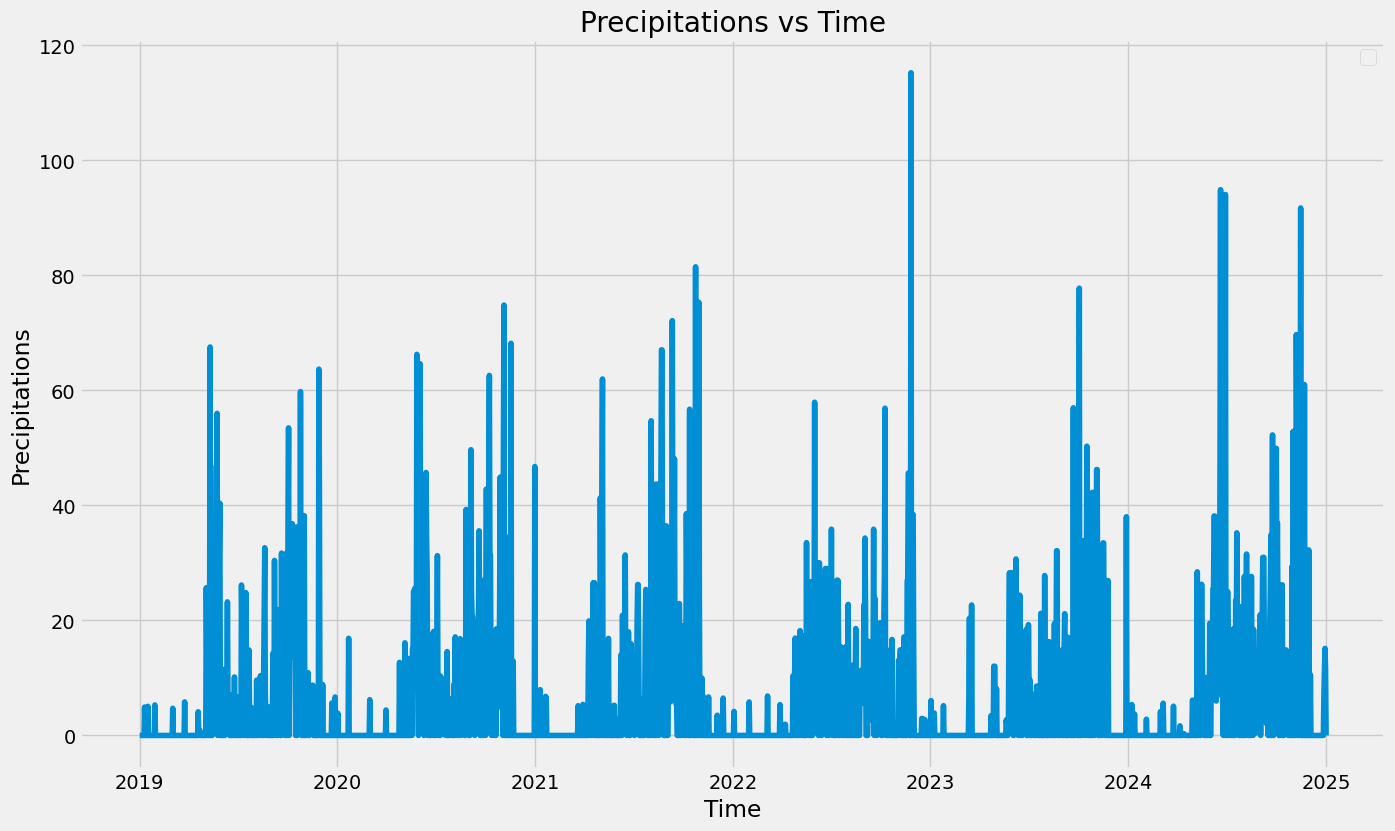

In [7]:
# Plot the precipitations around volcano
plt.figure(figsize=(15,9))
times = Rain2019_2024_df.index
precipitations = Rain2019_2024_df['Precipitations']
plt.plot(times, precipitations)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.legend()
plt.show()

Average precipitations during the dry season:  22.659412903225807
Average precipitations during the rainy season:  319.4603666666667


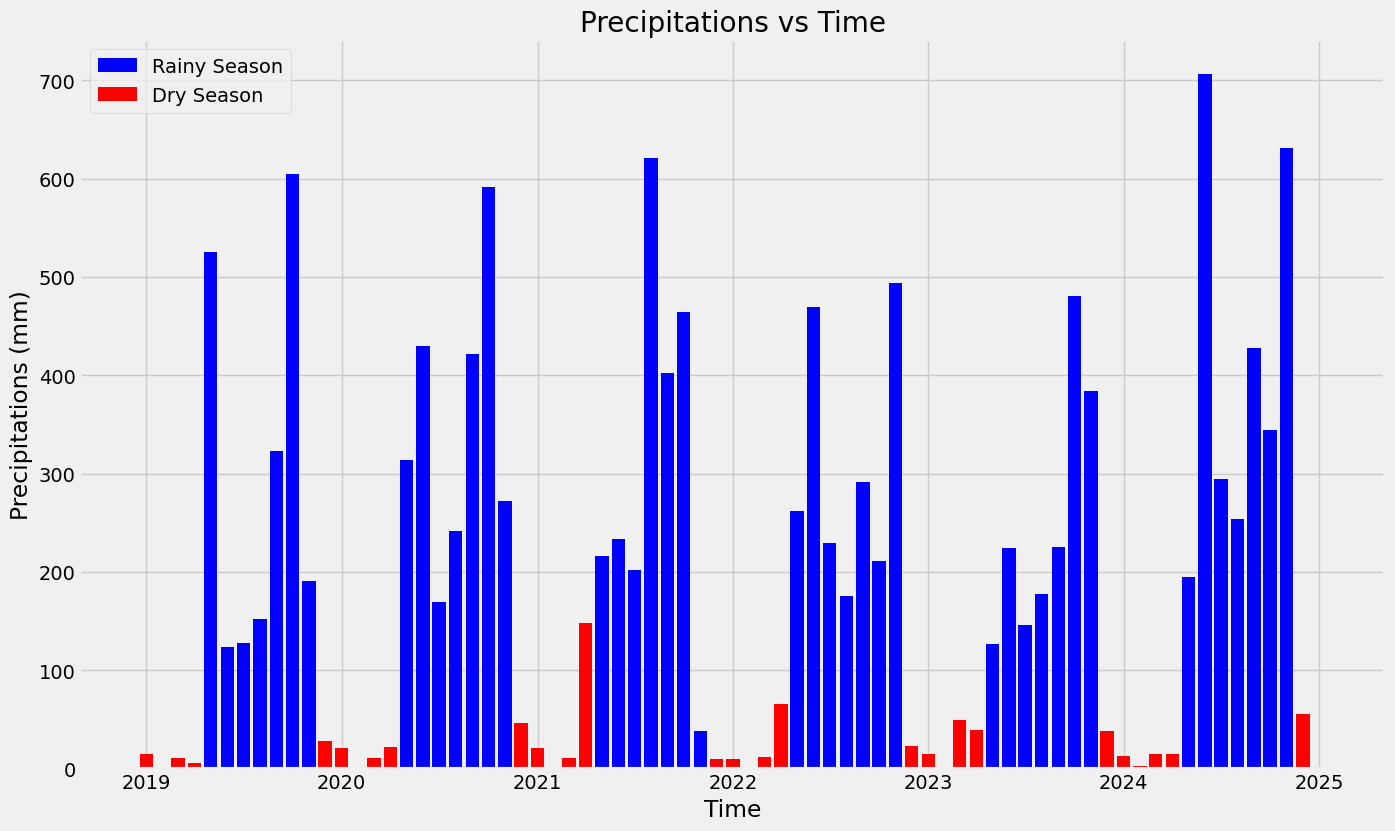

In [8]:
# Plot the precipitations distinguishing Dry and Rainy seasons
precipitations_per_month = Rain2019_2024_df.groupby(Rain2019_2024_df.index.to_period('M'))['Precipitations'].sum()
times = precipitations_per_month.index.to_timestamp()
values = precipitations_per_month.values

dry_season_months = [12, 1, 2, 3, 4]

is_dry = times.month.isin(dry_season_months)

dry_times = times[is_dry]
dry_values = values[is_dry]

rainy_times = times[~is_dry] 
rainy_values = values[~is_dry]


print("Average precipitations during the dry season: ", np.mean(dry_values))
print("Average precipitations during the rainy season: ", np.mean(rainy_values))

plt.figure(figsize=(15, 9))
plt.bar(rainy_times, rainy_values, color='blue', label='Rainy Season', width=25)
plt.bar(dry_times, dry_values, color='red', label='Dry Season', width=25)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations (mm)')
plt.legend()
plt.show()

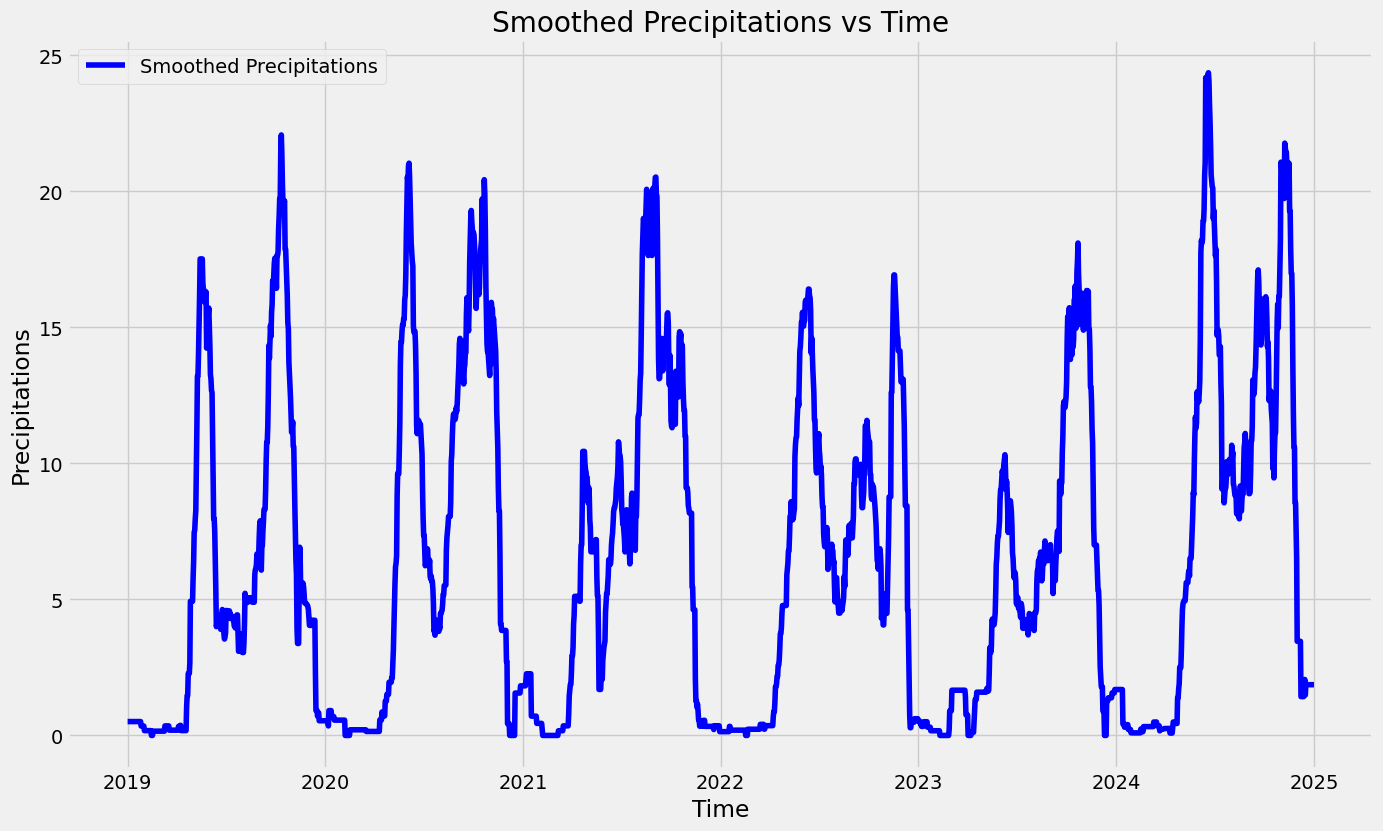

In [9]:
# Plot smoothened precipitations with a moving average

times = Rain2019_2024_df.index
precipitations_series = pd.Series(precipitations.values, index=times)
smoothed_precipitations = precipitations_series.rolling(window=30, center=True).mean()
smoothed_precipitations = smoothed_precipitations.bfill().ffill()
plt.figure(figsize=(15,9))
plt.plot(times, smoothed_precipitations, color='blue', label='Smoothed Precipitations')
plt.title('Smoothed Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.legend()
plt.show()


### Lahares Data

The different informations about the Lahares are added to the global dataset.
We have the following columns:
- Eruption time: Timestamp of the eruption that triggered the lahar.
- Lahar time: Timestamp of the lahar occurrence.
- Magnitude: Magnitude of the lahar event.

In [10]:
## Add Lahares to the VRBA DataFrame
print("\nLahares DataFrame:")
Lahares_df.info()

# Drop rows + Dates in the same format
Lahares_df = Lahares_df[Lahares_df['Eruption time'].dt.year >= 2019]
vrba_minutes = VRBA_eruptions_df["t1"].dt.floor('min')
lahar_minutes = Lahares_df["Eruption time"]

# Add new column to VRBA_eruptions_df to indicate if lahar occurred
VRBA_eruptions_df["Lahares"] = vrba_minutes.isin(lahar_minutes)

# Add new eruptions where Lahares occurred but not registered
lahares_dates_not_in_VRBA = lahar_minutes[~lahar_minutes.isin(vrba_minutes)]

mag_map = Lahares_df.set_index("Eruption time")["Eruption infrasound magnitude"]

new_rows = pd.DataFrame({
    "t1": lahares_dates_not_in_VRBA,
    "Lahares": True,
    "magnitude": lahares_dates_not_in_VRBA.map(mag_map).str.replace(',', '.').astype(float)
})

VRBA_eruptions_df = pd.concat(
    [VRBA_eruptions_df, new_rows],
    ignore_index=True
)

# Add the time difference before the lahar occurred

VRBA_eruptions_df = pd.merge_asof(
    VRBA_eruptions_df.sort_values('t1'),
    Lahares_df[['Eruption time', 'Time difference (min)']].sort_values('Eruption time'),
    left_on='t1',
    right_on='Eruption time',
    direction='backward',
    tolerance=pd.Timedelta('1Min')
).rename(
    columns={'Time difference (min)': 'Time before Lahar (min)'}
).drop(columns=['Eruption time'])

print(VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True])



Lahares DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Event                          22 non-null     int64         
 1   Eruption time                  22 non-null     datetime64[ns]
 2   Lahar time                     15 non-null     datetime64[ns]
 3   Time difference (min)          15 non-null     float64       
 4   Eruption infrasound magnitude  15 non-null     object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 1012.0+ bytes
                         t1                      t2  amplitude_max  \
0   2019-01-20 07:27:05.050 2019-01-20 07:29:11.950          5.916   
37  2020-01-30 18:13:42.427 2020-01-30 18:14:33.666          5.284   
94  2020-05-25 09:25:52.157 2020-05-25 09:26:35.065          2.599   
208 2021-06-28 11:42:04.132 2021-06-28 11:

In [11]:
lahares_dates_not_in_VRBA

11   2022-06-01 00:33:00
13   2022-01-30 19:08:00
16   2023-11-05 21:17:00
21   2023-02-06 15:05:00
Name: Eruption time, dtype: datetime64[ns]

### Eruptions Data 

In [12]:
VRBA_eruptions_df.describe()

,t1,t2,amplitude_max,amplitude_rms,amplitude_p2p,energy,duration,magnitude,Time before Lahar (min)
count,971,967,967.000000,967.000000,967.000000,9.670000e+02,967.000000,971.000000,15.000000
mean,2022-08-22 19:12:35.052091648,2022-08-22 11:15:50.756762880,0.308552,0.087465,0.648961,6.259377e+05,88.527620,2.824498,20.413333
min,2019-01-20 07:27:05.050000,2019-01-20 07:29:11.950000,0.003000,0.000000,0.005000,1.482800e+01,1.247000,0.784625,8.200000
25%,2022-01-27 21:04:07.139000064,2022-01-26 15:30:29.192000,0.050000,0.015000,0.107500,2.547747e+03,25.259000,2.284488,15.000000
50%,2023-01-06 14:19:38.534000128,2023-01-06 14:20:13.998000128,0.103000,0.032000,0.225000,1.218176e+04,49.121000,2.743239,19.000000
75%,2023-08-25 02:28:58.904000,2023-08-25 02:30:54.944499968,0.247500,0.081500,0.512000,8.081618e+04,117.497500,3.293549,26.500000
max,2024-12-31 03:05:51.038000,2024-12-31 03:07:12.098000,17.436000,3.242000,28.126000,1.280676e+08,1402.151000,5.431984,32.000000
std,NaN,NaN,0.867807,0.195260,1.646017,5.145145e+06,113.641528,0.743776,7.656357


Let's see how the information of the different eruption events are distributed over time.

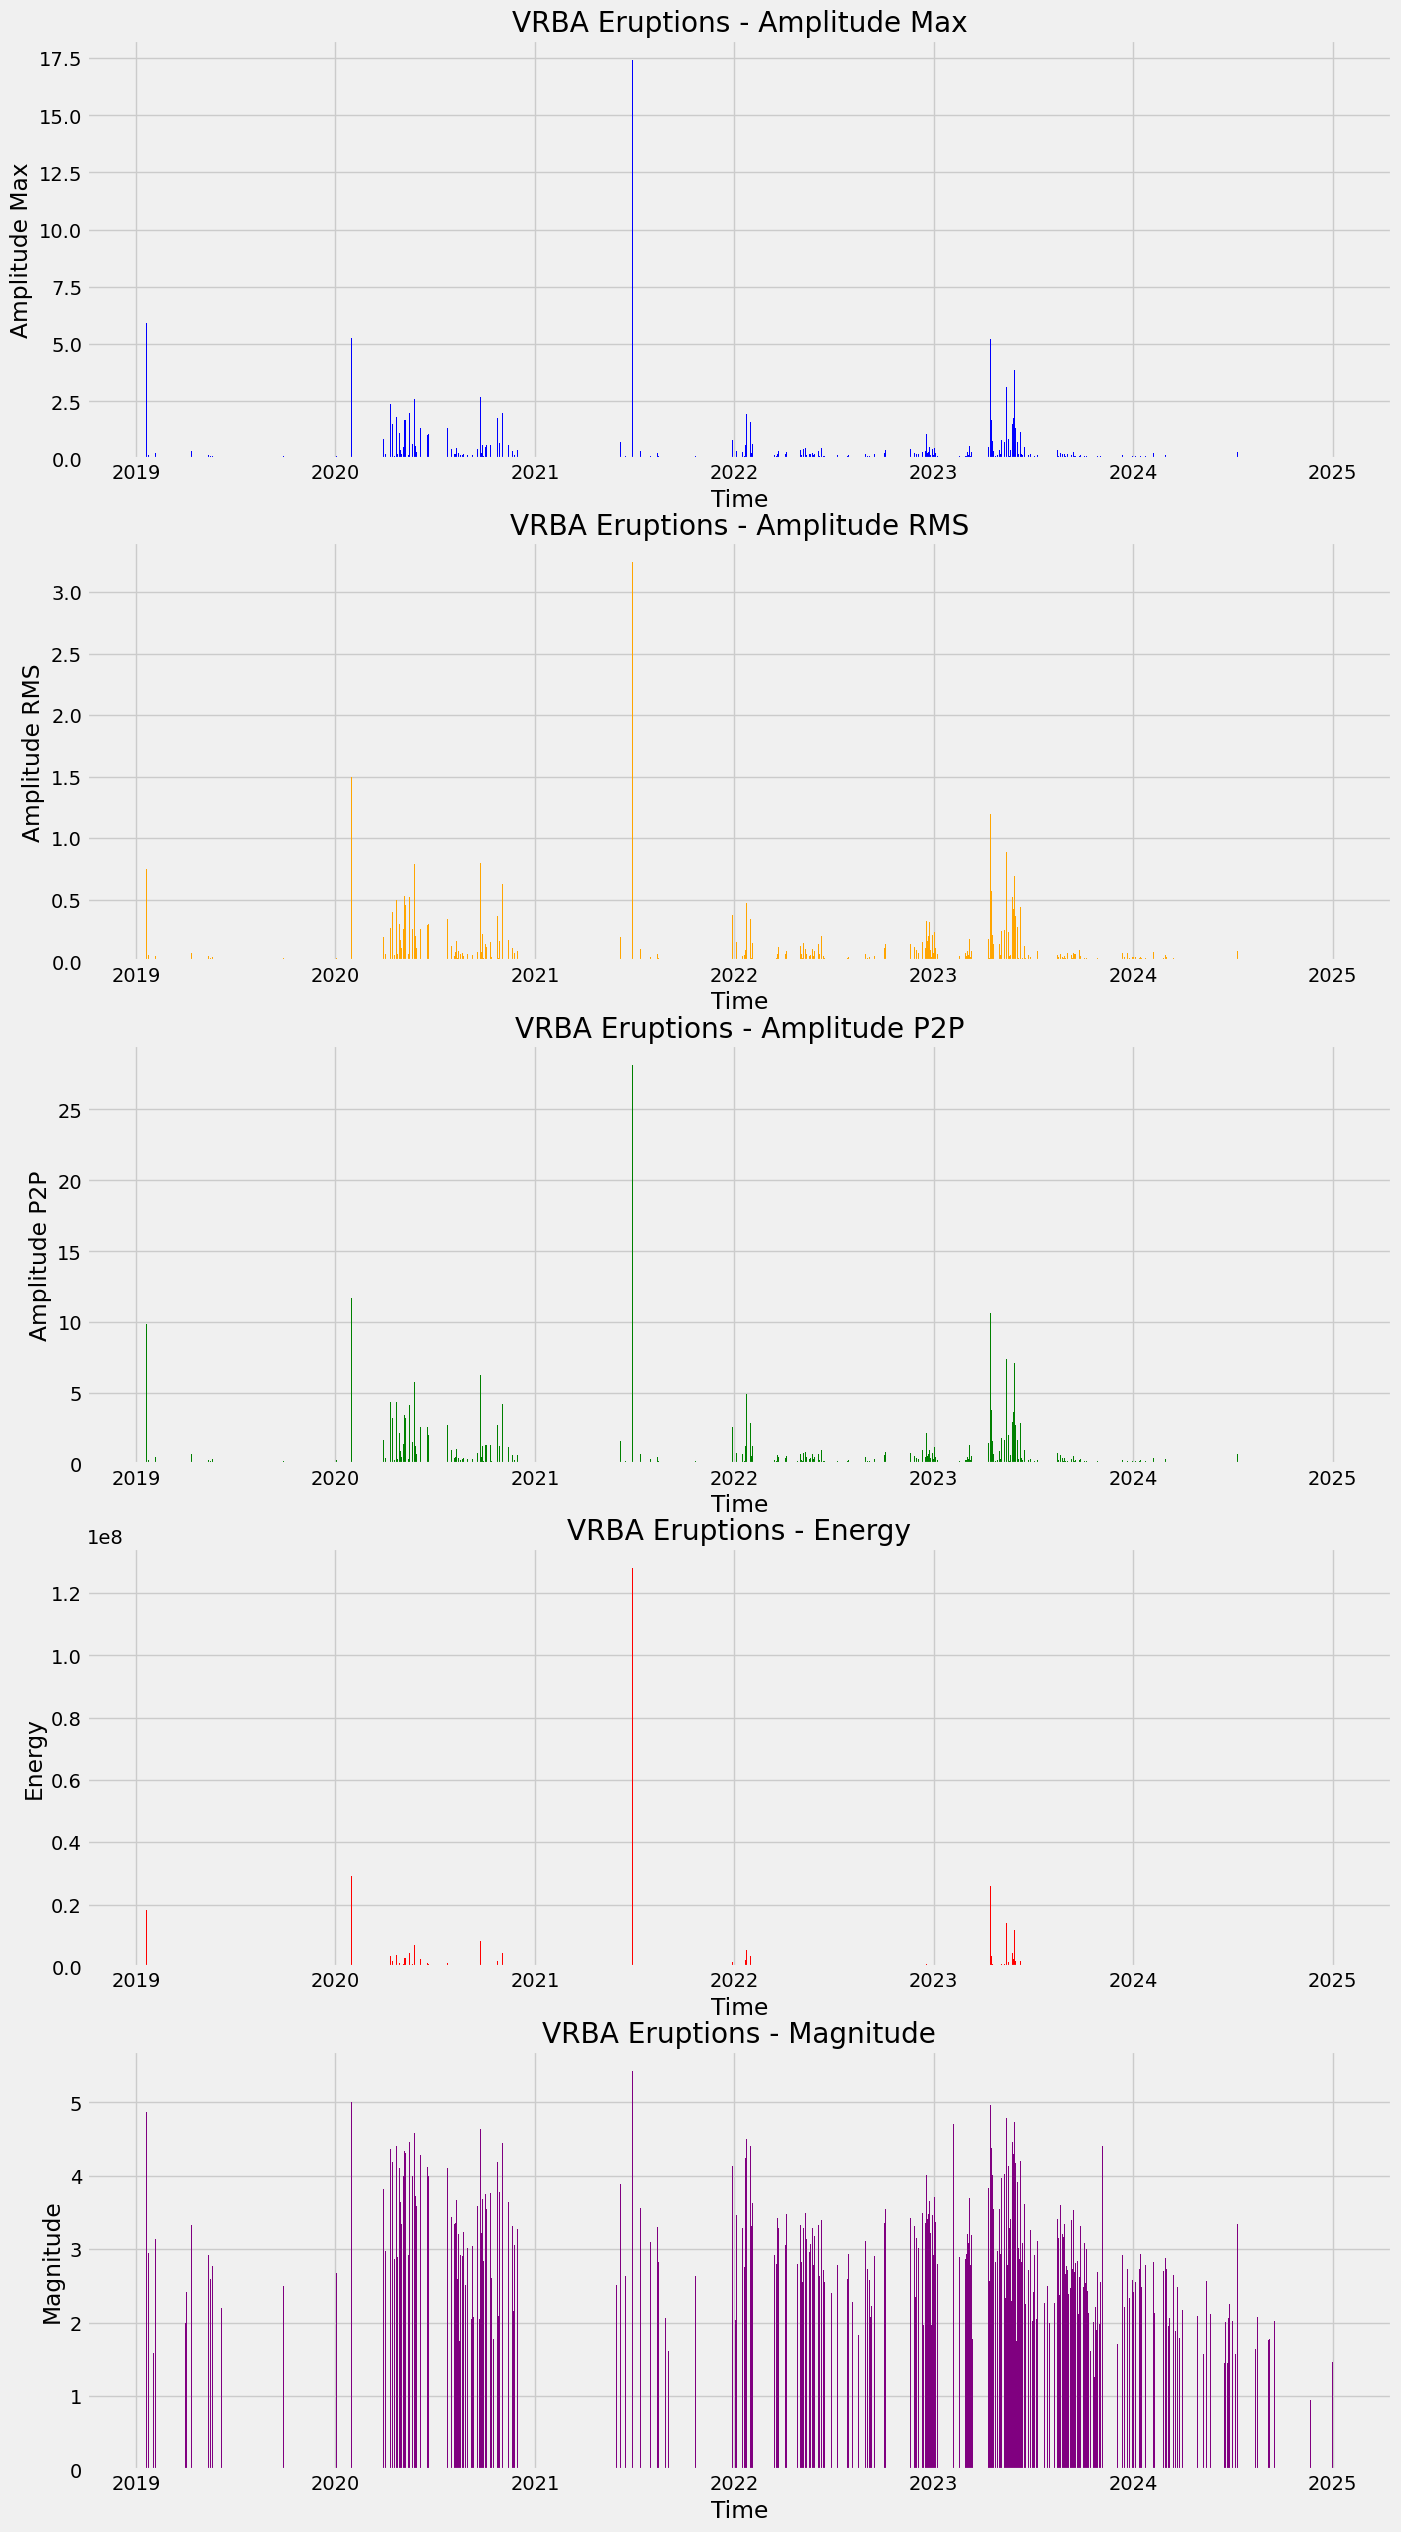

In [13]:
## Plot VRBA eruptions data

# The data is not in right order. We will sort it by t1, the start time of the eruption
VRBA_eruptions_df = VRBA_eruptions_df.sort_values(by='t1')
# # Add new columns showing the duration of the eruption
# VRBA_eruptions_df['duration'] = (VRBA_eruptions_df['t2'] - VRBA_eruptions_df['t1']).dt.total_seconds() # Duration in seconds


# Plot a bar graph of the VRBA eruptions
plt.figure(figsize=(15, 30))
plt.subplot(5, 1, 1)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_max'], color='blue')
plt.title('VRBA Eruptions - Amplitude Max')
plt.xlabel('Time')
plt.ylabel('Amplitude Max')
plt.subplot(5, 1, 2)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_rms'], color='orange')
plt.title('VRBA Eruptions - Amplitude RMS')
plt.xlabel('Time')
plt.ylabel('Amplitude RMS')
plt.subplot(5, 1, 3)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_p2p'], color='green')
plt.title('VRBA Eruptions - Amplitude P2P')
plt.xlabel('Time')
plt.ylabel('Amplitude P2P')
plt.subplot(5, 1, 4)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['energy'], color='red')
plt.title('VRBA Eruptions - Energy')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.subplot(5, 1, 5)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['magnitude'], color='purple')
plt.title('VRBA Eruptions - Magnitude')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.show()

Besides the magnitude, we can see that they follow a similar pattern. It could mean there is high correlation between them.

### Continuous Measurements Data

Let's see how the Rincon de la Vieja and Rincon data is distributed over time.

####  continuous Data

In [14]:
# rsam_VORI_df = rsam_VORI_df[(rsam_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(rsam_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]
# dsar_VORI_df = dsar_VORI_df[(dsar_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(dsar_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]

# rsam_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv', index=False)
# dsar_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv', index= False)


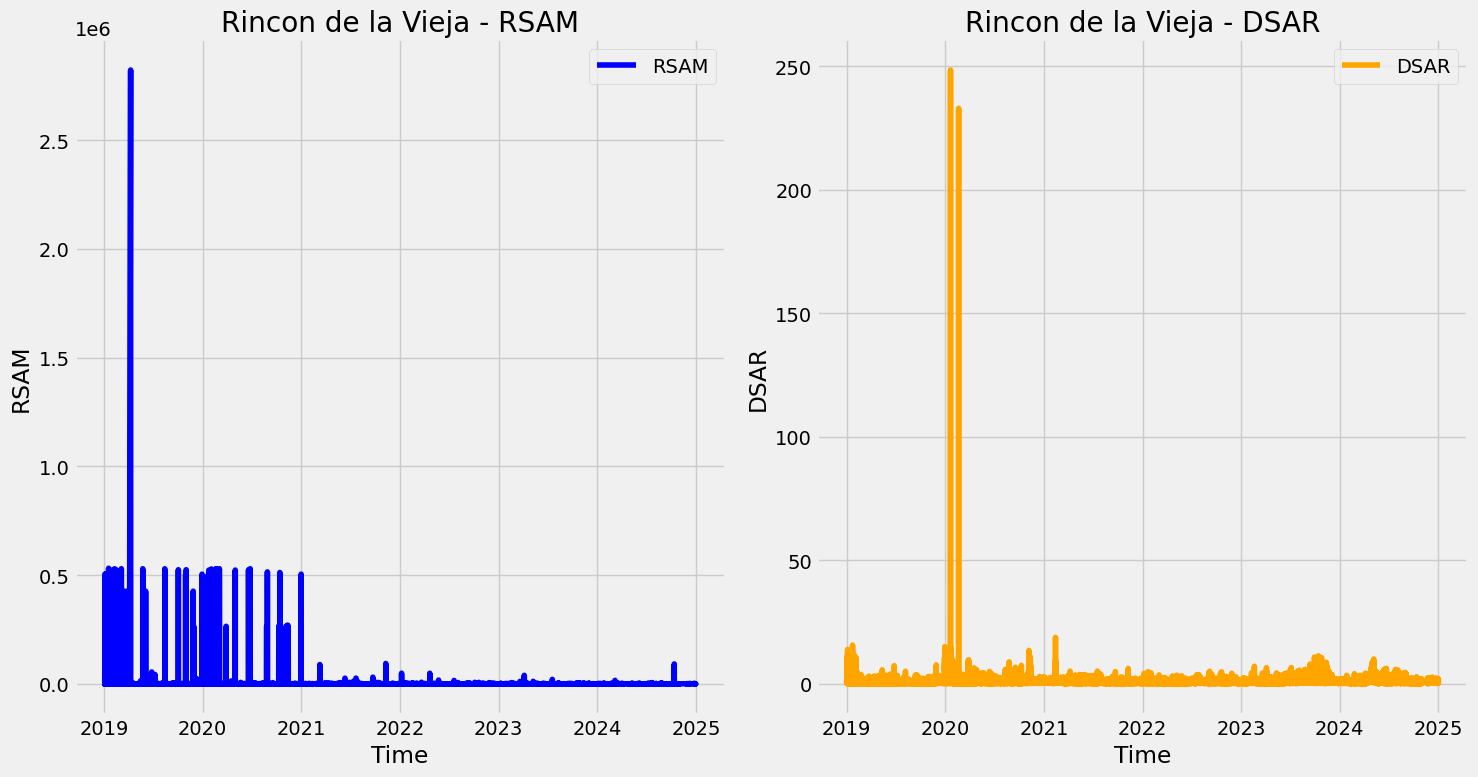

In [15]:
## Plot data from VRBA station
# [dsar , rsam, trigger  freq_bands_mean    freq_top_k    freq_index spectral_kurtosis      tonality]
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

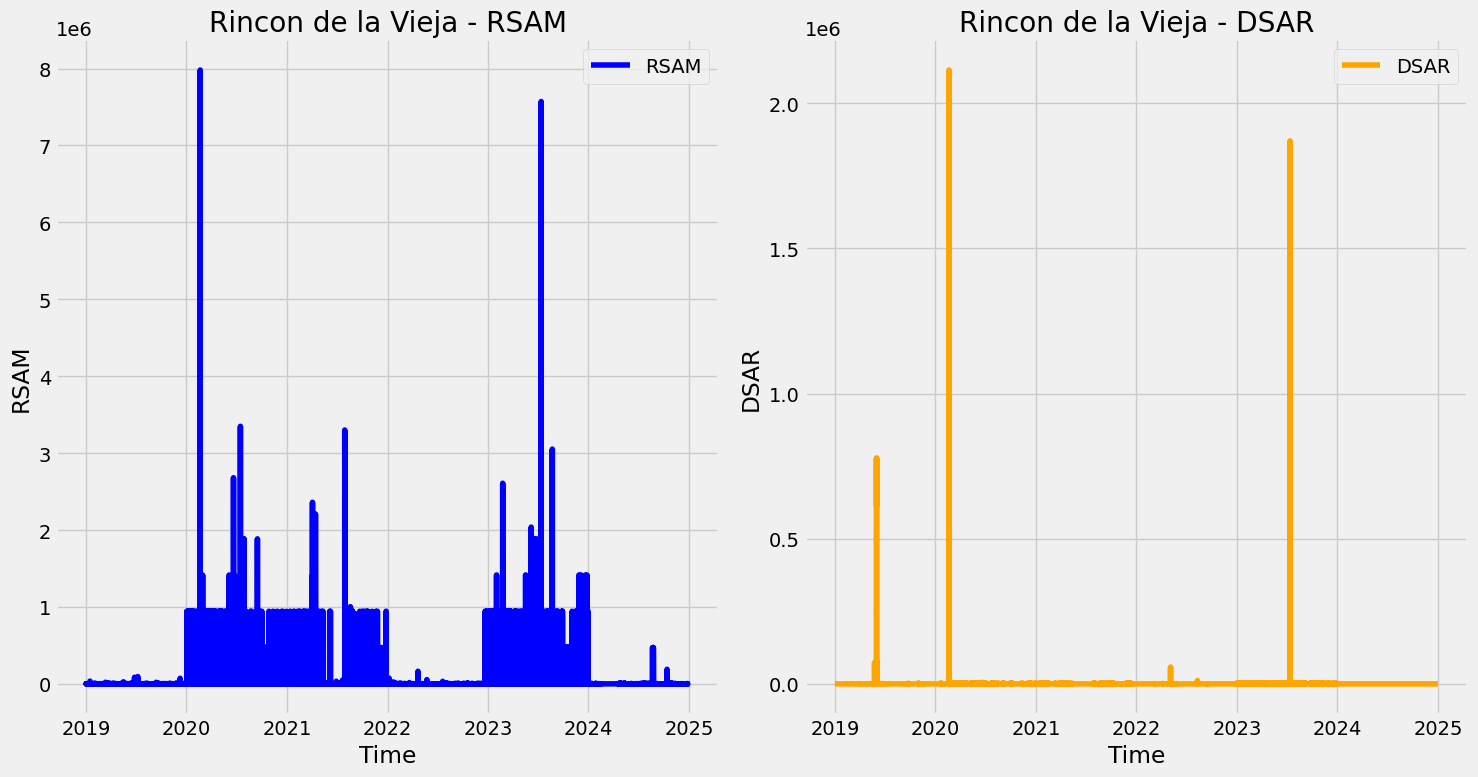

In [16]:
## Plot data from the VORI STATION
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rsam_VORI_df.index, rsam_VORI_df['value'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(dsar_VORI_df.index, dsar_VORI_df['value'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

We see some outliers and some missing values in the data. For the Rsam value, we will apply a trheshod to get rid of the outliers and the noise in the data. 

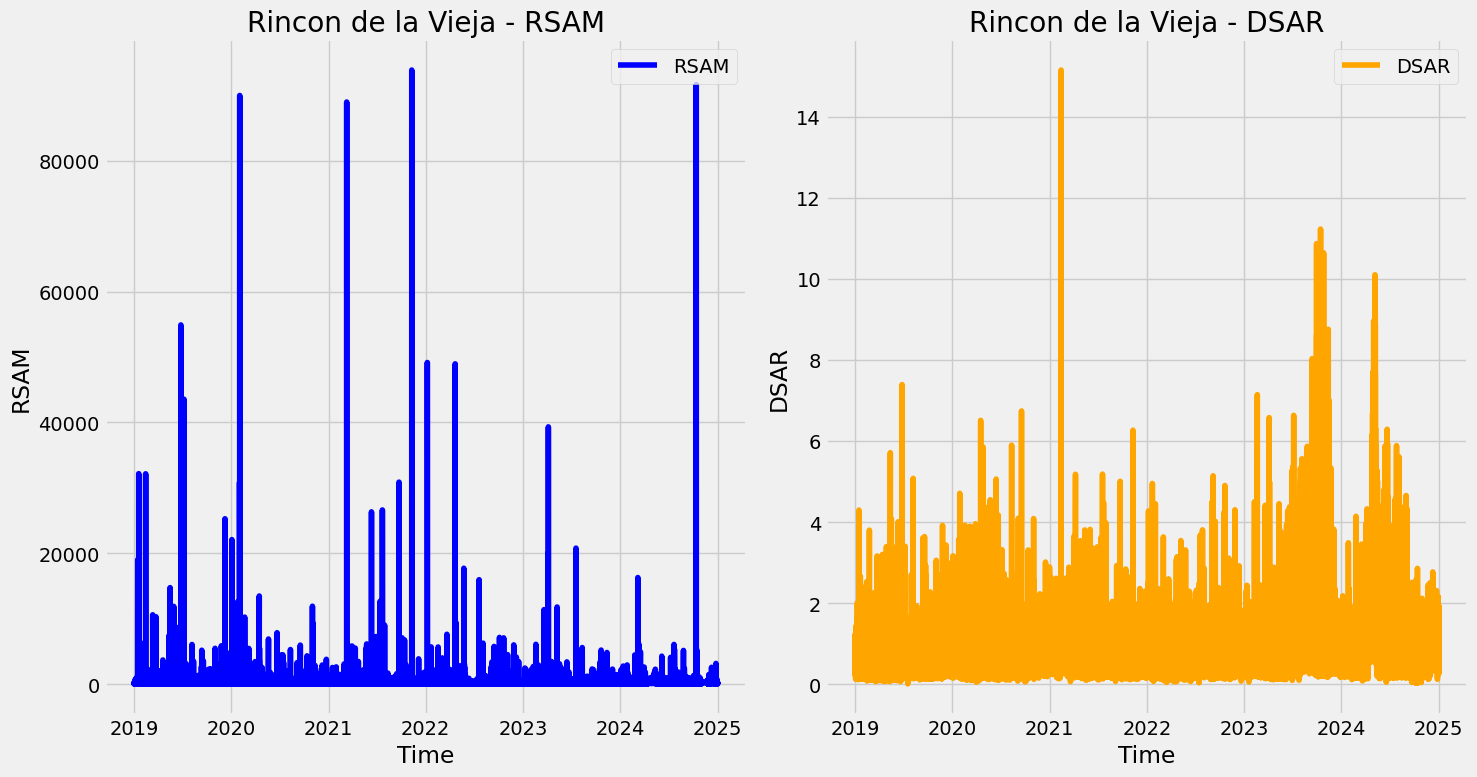

In [17]:
## Plot data with RSAM between 20 and 1e5

Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df[(20 < Rincon_de_la_Vieja_df['rsam']) & (Rincon_de_la_Vieja_df['rsam'] < 1e5)]

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


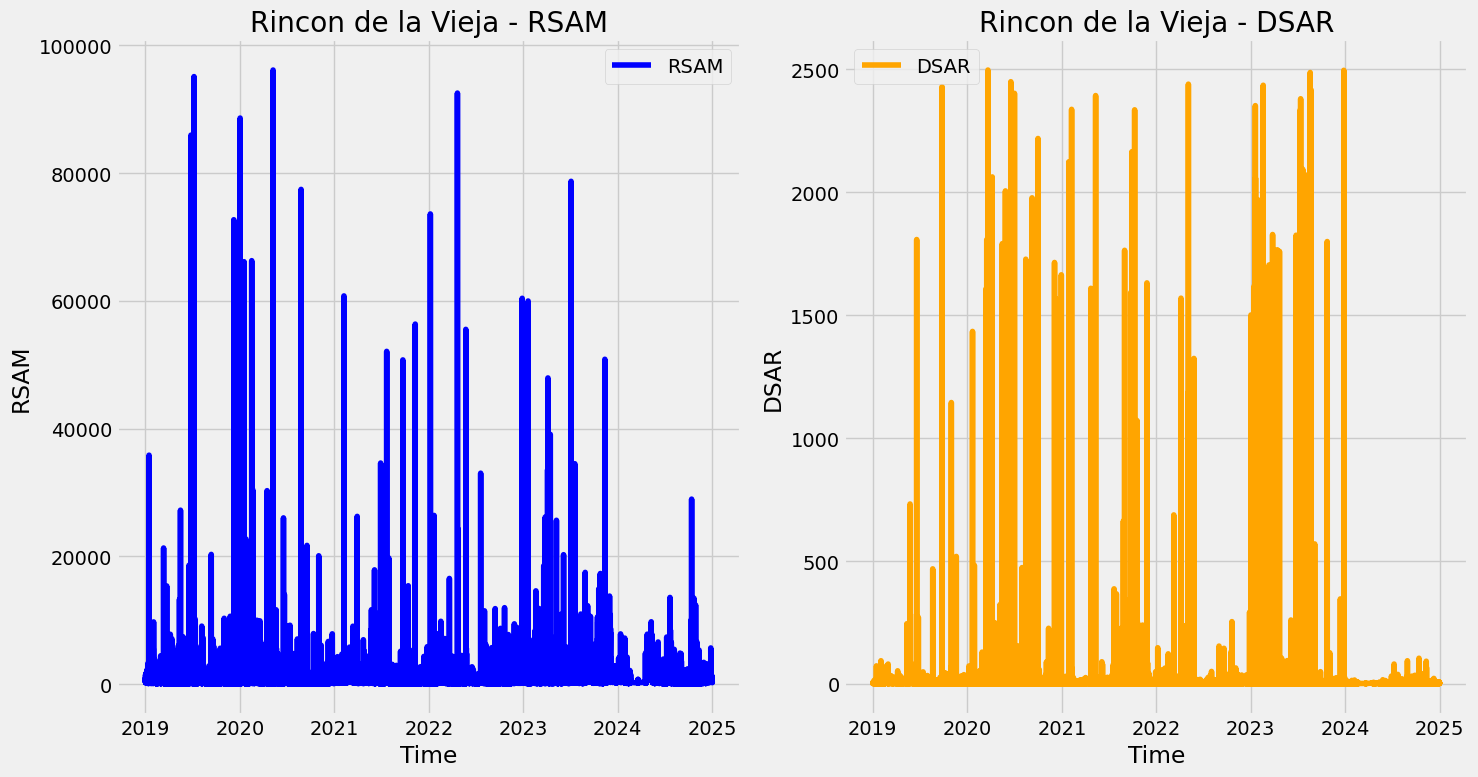

In [18]:
rsam_VORI_df = rsam_VORI_df[(20 < rsam_VORI_df['value']) & (rsam_VORI_df['value'] < 1e5)]
dsar_VORI2_df = dsar_VORI_df[ (dsar_VORI_df['value'] < 0.25e4)]



plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rsam_VORI_df.index, rsam_VORI_df['value'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(dsar_VORI2_df.index, dsar_VORI2_df['value'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
corr = rsam_VORI_df['value'].corr(Rincon_de_la_Vieja_df['rsam'])
print(corr)

0.6295246920083158


We are going to see how much data is missing in the Rincon de la Vieja continuous dataframe.

In [20]:
## Assessing missing data in Rincon de la Vieja continuous dataset


# Store the first and last time of data being recorded
# VRBA station
rsam_VRBA = Rincon_de_la_Vieja_df['rsam'][Rincon_de_la_Vieja_df['rsam'].notnull()]
dsar_VRBA = Rincon_de_la_Vieja_df['dsar'][Rincon_de_la_Vieja_df['dsar'].notnull()]
rsam_VRBA_first_time = rsam_VRBA.index.min()
dsar_VRBA_first_time = dsar_VRBA.index.min()
rsam_VRBA_last_time = rsam_VRBA.index.max() 
dsar_VRBA_last_time = dsar_VRBA.index.max()
print(f"rsam_VRBA data recorded from {rsam_VRBA_first_time} to {rsam_VRBA_last_time}")
print(f"dsar_VRBA data recorded from {dsar_VRBA_first_time} to {dsar_VRBA_last_time}")

# VORI station
rsam_VORI_first_time = rsam_VORI_df.index.min()
dsar_VORI_first_time = dsar_VORI_df.index.min()
rsam_VORI_last_time = rsam_VORI_df.index.max()
dsar_VORI_last_time = dsar_VORI_df.index.max()
print(f"rsam_VORI data recorded from {rsam_VORI_first_time} to {rsam_VORI_last_time}")
print(f"dsar_VORI data recorded from {dsar_VORI_first_time} to {dsar_VORI_last_time}")
print("\n")
# Compute the difference between the two timestamps
expected_points = (pd.to_datetime('2025-01-01') - pd.to_datetime('2019-01-01'))/pd.Timedelta('1min')

print(f" Supposed total duration of measured data: {expected_points} minutes")
print("\n")

# Calculate the actual number of data points recorded
actual_data_points0 =  rsam_VRBA.shape[0]
actual_data_points1 =  dsar_VRBA.shape[0]
actual_data_points2 = rsam_VORI_df.shape[0]
actual_data_points3 = dsar_VORI_df.shape[0]
print(f" Actual number of data points recorded for rsam_VRBA: {actual_data_points0}")# Calculate the expected number of data points for continuous recording every minute
print(f" Actual number of data points recorded for dsar_VRBA: {actual_data_points1}")
print(f" Actual number of data points recorded for rsam_VORI: {actual_data_points2}")
print(f" Actual number of data points recorded for dsar_VORI: {actual_data_points3}")
print("\n")

missing_data_points = expected_points - actual_data_points0
missing_data_points1 = expected_points - actual_data_points1
missing_data_points2 = expected_points - actual_data_points2
missing_data_points3 = expected_points - actual_data_points3
print(f" Missing data points for rsam_VRBA: {missing_data_points}")
print(f" Missing data points for dsar_VRBA: {missing_data_points1}")
print(f" Missing data points for rsam_VORI: {missing_data_points2}")
print(f" Missing data points for dsar_VORI: {missing_data_points3}")
print("\n")
# Calculate the percentage of missing data points
missing_percentage = (missing_data_points / expected_points) * 100
missing_percentage1 = (missing_data_points1 / expected_points) * 100
missing_percentage2 = (missing_data_points2 / expected_points) * 100
missing_percentage3 = (missing_data_points3 / expected_points) * 100
print(f" Percentage of missing data points for rsam_VRBA: {missing_percentage:.2f}%")
print(f" Percentage of missing data points for dsar_VRBA: {missing_percentage1:.2f}%")
print(f" Percentage of missing data points for rsam_VORI: {missing_percentage2:.2f}%")
print(f" Percentage of missing data points for dsar_VORI: {missing_percentage3:.2f}%")




rsam_VRBA data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
dsar_VRBA data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
rsam_VORI data recorded from 2019-01-01 00:01:00 to 2024-12-31 15:09:00
dsar_VORI data recorded from 2019-01-01 00:01:00 to 2024-12-31 15:09:00


 Supposed total duration of measured data: 3156480.0 minutes


 Actual number of data points recorded for rsam_VRBA: 2323244
 Actual number of data points recorded for dsar_VRBA: 2323244
 Actual number of data points recorded for rsam_VORI: 2869285
 Actual number of data points recorded for dsar_VORI: 2926267


 Missing data points for rsam_VRBA: 833236.0
 Missing data points for dsar_VRBA: 833236.0
 Missing data points for rsam_VORI: 287195.0
 Missing data points for dsar_VORI: 230213.0


 Percentage of missing data points for rsam_VRBA: 26.40%
 Percentage of missing data points for dsar_VRBA: 26.40%
 Percentage of missing data points for rsam_VORI: 9.10%
 Percentage of missing data points for dsar_V

We see that 26.40% of the data is missing in the Rincon de la Vieja continuous dataframe from the VRBA station. However, for the VORI station, only 9.10% of the data is missing for the rsam and 7.29% for the dsar.Let's see how the missing data points are spread over time.

In [21]:
# # Take 14 minutes to compile  ---> see csv file below

# # Copy of the time column to analyze missing data
# time_df = Rincon_de_la_Vieja_df[['time']].copy()
# # Creation of a dictionary to store missing time intervals (as key) and their counts (as value)
# min_missing = {}
# # Iterate through the time DataFrame to identify missing data points and calculating the time difference
# for i in range(1, time_df.shape[0]):
#     current_time = time_df.iloc[i]
#     previous_time = time_df.iloc[i - 1]
#     time_diff = (current_time - previous_time).dt.total_seconds().values[0] / 60  # Convert to minutes
#     if time_diff > 1:
#         if time_diff not in min_missing:
#             min_missing[time_diff] = 0
#         min_missing[time_diff] += 1
# print("\nMissing time intervals (in minutes) and their counts:")
# for interval, count in sorted(min_missing.items()):
#     print(f" {interval} minutes: {count} occurrences")

# # Store dictionary keys and values in a csv file
# missing_intervals_df = pd.DataFrame(list(min_missing.items()), columns=['Missing Interval (minutes)', 'Count'])
# missing_intervals_df.to_csv("MSc_Bryan_Rincon/Rincon_missing_intervals.csv", index=False)

# print(sum(min_missing.values()))

Pas necessaire(We have a lot of gaps in the data. There are a lot of huge gaps where data is missing till at max 20 days. Those gaps are too big to be filled with interpolation. Specific treatment will be needed for those gaps. But for the smaller gaps, we can use interpolation to fill in the missing data points.)

In [22]:
# # Filling the small gaps with interpolation

# Continuous_data_df = Rincon_de_la_Vieja_df.copy()
# # Identify gaps larger than 2 minutes
# Continuous_data_df['gap'] = Continuous_data_df['time'].diff() > pd.Timedelta(minutes=2)
# # Create a cumulative sum of the gaps to identify groups of continuous data
# Continuous_data_df['gap group'] = Continuous_data_df['gap'].cumsum()
# # Count the size of each gap group
# gap = Continuous_data_df['gap group'].value_counts().sort_index()
# print(f"Number of gap groups identified: {len(gap)}")
# # Identify correctable gaps
# correctable_gaps = gap[gap > 20]  # 20 minutes
# #print(correctable_gaps)
# print(f"Number of correctable gap groups (>{20} minutes): {len(correctable_gaps)}")


# # Continuous_data_df = Continuous_data_df.infer_objects()

# Continuous_group_data_df = Continuous_data_df[Continuous_data_df['gap group'].isin(correctable_gaps.index)]
# print(f"Data points in correctable gap groups: {Continuous_group_data_df.shape}")
# Continuous_group_data_df = Continuous_group_data_df.set_index('time')
# #print(Continuous_group_data_df.head())
# Continuous_group_data_df = Continuous_group_data_df.groupby('gap group', group_keys=False).apply(lambda g: g.asfreq('1min').interpolate())
# print(f"Data points after interpolation: {Continuous_group_data_df.shape}")
# Continuous_data_df = Continuous_data_df.set_index('time')
# df = Continuous_data_df.combine_first(Continuous_group_data_df)
# print(f"Total data points after filling small gaps: {df.shape}")
# print(f"Total data points before filling small gaps: {Continuous_data_df.shape}")

# print(df.describe())
# print(Rincon_de_la_Vieja_df.describe())


# # #Continuous_data_df = Continuous_data_df.reset_index(level=0, drop=True)
# # Continuous_data_df['time_diff'] = Continuous_data_df.index.diff()
# # print(Continuous_data_df['time_diff'].describe())



In [23]:
# Continuous_data_df['time_diff'] = Continuous_data_df.index.diff()
# print(Continuous_data_df['time_diff'].describe())

In [24]:
# Missing time intervals (in minutes) and their counts:
#  2.0 minutes: 148621 occurrences
#  3.0 minutes: 68946 occurrences
#  4.0 minutes: 33505 occurrences
#  5.0 minutes: 15593 occurrences
#  6.0 minutes: 7466 occurrences
#  7.0 minutes: 3834 occurrences
#  8.0 minutes: 1832 occurrences
#  9.0 minutes: 932 occurrences
#  10.0 minutes: 471 occurrences
#  11.0 minutes: 248 occurrences
#  12.0 minutes: 144 occurrences
#  13.0 minutes: 86 occurrences
#  14.0 minutes: 46 occurrences
#  15.0 minutes: 31 occurrences
#  16.0 minutes: 22 occurrences
#  17.0 minutes: 9 occurrences
#  18.0 minutes: 8 occurrences
#  19.0 minutes: 6 occurrences
#  20.0 minutes: 5 occurrences
#  21.0 minutes: 2 occurrences
#  22.0 minutes: 3 occurrences
#  23.0 minutes: 2 occurrences
#  24.0 minutes: 1 occurrences
#  25.0 minutes: 3 occurrences
#  26.0 minutes: 6 occurrences
#  27.0 minutes: 1 occurrences
#  28.0 minutes: 3 occurrences
#  29.0 minutes: 2 occurrences
#  30.0 minutes: 1 occurrences
#  31.0 minutes: 3 occurrences
#  32.0 minutes: 1 occurrences
#  33.0 minutes: 2 occurrences
#  35.0 minutes: 3 occurrences
#  37.0 minutes: 2 occurrences
#  38.0 minutes: 1 occurrences
#  39.0 minutes: 2 occurrences
#  40.0 minutes: 4 occurrences
#  41.0 minutes: 2 occurrences
#  42.0 minutes: 4 occurrences
#  43.0 minutes: 3 occurrences
#  44.0 minutes: 3 occurrences
#  46.0 minutes: 2 occurrences
#  47.0 minutes: 2 occurrences
#  48.0 minutes: 1 occurrences
#  49.0 minutes: 1 occurrences
#  50.0 minutes: 2 occurrences
#  51.0 minutes: 1 occurrences
#  52.0 minutes: 1 occurrences
#  53.0 minutes: 2 occurrences
#  55.0 minutes: 1 occurrences
#  56.0 minutes: 1 occurrences
#  57.0 minutes: 2 occurrences
#  58.0 minutes: 1 occurrences
#  60.0 minutes: 1 occurrences
#  61.0 minutes: 1 occurrences
#  63.0 minutes: 1 occurrences
#  65.0 minutes: 2 occurrences
#  67.0 minutes: 2 occurrences
#  70.0 minutes: 2 occurrences
#  71.0 minutes: 1 occurrences
#  79.0 minutes: 1 occurrences
#  80.0 minutes: 1 occurrences
#  82.0 minutes: 1 occurrences
#  84.0 minutes: 1 occurrences
#  86.0 minutes: 2 occurrences
#  87.0 minutes: 1 occurrences
#  89.0 minutes: 1 occurrences
#  92.0 minutes: 2 occurrences
#  93.0 minutes: 1 occurrences
#  95.0 minutes: 1 occurrences
#  96.0 minutes: 1 occurrences
#  101.0 minutes: 1 occurrences
#  103.0 minutes: 1 occurrences
#  106.0 minutes: 3 occurrences
#  107.0 minutes: 1 occurrences
#  108.0 minutes: 1 occurrences
#  109.0 minutes: 1 occurrences
#  111.0 minutes: 1 occurrences
#  114.0 minutes: 1 occurrences
#  117.0 minutes: 1 occurrences
#  125.0 minutes: 1 occurrences
#  126.0 minutes: 1 occurrences
#  132.0 minutes: 1 occurrences
#  137.0 minutes: 1 occurrences
#  138.0 minutes: 2 occurrences
#  141.0 minutes: 1 occurrences
#  142.0 minutes: 2 occurrences
#  145.0 minutes: 1 occurrences
#  148.0 minutes: 1 occurrences
#  153.0 minutes: 1 occurrences
#  156.0 minutes: 1 occurrences
#  159.0 minutes: 1 occurrences
#  163.0 minutes: 2 occurrences
#  170.0 minutes: 1 occurrences
#  173.0 minutes: 1 occurrences
#  175.0 minutes: 1 occurrences
#  176.0 minutes: 1 occurrences
#  186.0 minutes: 1 occurrences
#  187.0 minutes: 1 occurrences
#  190.0 minutes: 1 occurrences
#  192.0 minutes: 1 occurrences
#  199.0 minutes: 1 occurrences
#  211.0 minutes: 1 occurrences
#  213.0 minutes: 1 occurrences
#  217.0 minutes: 1 occurrences
#  218.0 minutes: 1 occurrences
#  229.0 minutes: 1 occurrences
#  238.0 minutes: 1 occurrences
#  239.0 minutes: 1 occurrences
#  247.0 minutes: 1 occurrences
#  249.0 minutes: 1 occurrences
#  265.0 minutes: 1 occurrences
#  266.0 minutes: 1 occurrences
#  275.0 minutes: 1 occurrences
#  276.0 minutes: 1 occurrences
#  283.0 minutes: 1 occurrences
#  285.0 minutes: 1 occurrences
#  290.0 minutes: 1 occurrences
#  296.0 minutes: 2 occurrences
#  301.0 minutes: 1 occurrences
#  304.0 minutes: 1 occurrences
#  322.0 minutes: 1 occurrences
#  324.0 minutes: 1 occurrences
#  331.0 minutes: 1 occurrences
#  333.0 minutes: 1 occurrences
#  337.0 minutes: 1 occurrences
#  338.0 minutes: 1 occurrences
#  339.0 minutes: 1 occurrences
#  343.0 minutes: 1 occurrences
#  346.0 minutes: 1 occurrences
#  356.0 minutes: 1 occurrences
#  358.0 minutes: 1 occurrences
#  370.0 minutes: 1 occurrences
#  381.0 minutes: 1 occurrences
#  384.0 minutes: 1 occurrences
#  390.0 minutes: 1 occurrences
#  392.0 minutes: 2 occurrences
#  410.0 minutes: 1 occurrences
#  440.0 minutes: 1 occurrences
#  450.0 minutes: 1 occurrences
#  454.0 minutes: 1 occurrences
#  459.0 minutes: 1 occurrences
#  461.0 minutes: 1 occurrences
#  518.0 minutes: 1 occurrences
#  574.0 minutes: 1 occurrences
#  584.0 minutes: 1 occurrences
#  592.0 minutes: 1 occurrences
#  625.0 minutes: 1 occurrences
#  626.0 minutes: 1 occurrences
#  635.0 minutes: 1 occurrences
#  636.0 minutes: 1 occurrences
#  644.0 minutes: 1 occurrences
#  659.0 minutes: 1 occurrences
#  760.0 minutes: 1 occurrences
#  788.0 minutes: 1 occurrences
#  812.0 minutes: 1 occurrences
#  827.0 minutes: 1 occurrences
#  837.0 minutes: 1 occurrences
#  847.0 minutes: 1 occurrences
#  864.0 minutes: 1 occurrences
#  935.0 minutes: 1 occurrences
#  1007.0 minutes: 1 occurrences
#  1012.0 minutes: 1 occurrences
#  1029.0 minutes: 1 occurrences
#  1053.0 minutes: 1 occurrences
#  1061.0 minutes: 1 occurrences
#  1212.0 minutes: 1 occurrences
#  1442.0 minutes: 2 occurrences
#  1796.0 minutes: 1 occurrences
#  2340.0 minutes: 1 occurrences
#  2575.0 minutes: 1 occurrences
#  2882.0 minutes: 1 occurrences
#  3404.0 minutes: 1 occurrences
#  4986.0 minutes: 1 occurrences
#  6122.0 minutes: 1 occurrences
#  6961.0 minutes: 1 occurrences
#  8813.0 minutes: 1 occurrences
#  28618.0 minutes: 1 occurrences

In [25]:
Rincon_df.columns

Index(['VT', 'LP', 'tornillo'], dtype='object')

#### Seismic and Geophysical Data

In [26]:
Rincon_original_df.reset_index(inplace=True)

In [27]:
Rincon_original_df.columns

Index(['index', 'Fecha', 'VT', 'LP', 'Tcorto', 'Tremor', 'tfreq', 'Erupcion',
       'efreq', 'dpresion', 'Amplitud', 'Damplitud', 'sene', 'iene', 'VASR',
       'tornillo', 'Deslizamiento', 'Exhalacion'],
      dtype='object')

In [28]:
Rincon_original_df = Rincon_original_df.rename(columns={'Fecha':'time'})
Rincon_original_df = Rincon_original_df[(Rincon_original_df['time'] >= pd.to_datetime('2019-01-01')) & (Rincon_original_df['time'] < pd.to_datetime('2025-01-01')) ]
print("\nRincon DataFrame after filtering 2019-2024:")
Rincon_original_df.info()


Rincon DataFrame after filtering 2019-2024:
<class 'pandas.core.frame.DataFrame'>
Index: 2191 entries, 1826 to 4016
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   index          2191 non-null   int64         
 1   time           2191 non-null   datetime64[ns]
 2   VT             2191 non-null   float64       
 3   LP             2191 non-null   float64       
 4   Tcorto         2155 non-null   float64       
 5   Tremor         1812 non-null   float64       
 6   tfreq          992 non-null    float64       
 7   Erupcion       1588 non-null   float64       
 8   efreq          170 non-null    float64       
 9   dpresion       549 non-null    float64       
 10  Amplitud       777 non-null    float64       
 11  Damplitud      466 non-null    object        
 12  sene           187 non-null    float64       
 13  iene           181 non-null    float64       
 14  VASR           185 non-null  

There is many features missing many values. I will take only features having 100% of data of the 2191 required (2024 - 2019 in days).

In [29]:
# ## Keep only features having less than 5% missing data
# Rincon_df = Rincon_df[['time','VT', 'LP', 'tornillo']]
# Rincon_df.to_csv('MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv', index=False)

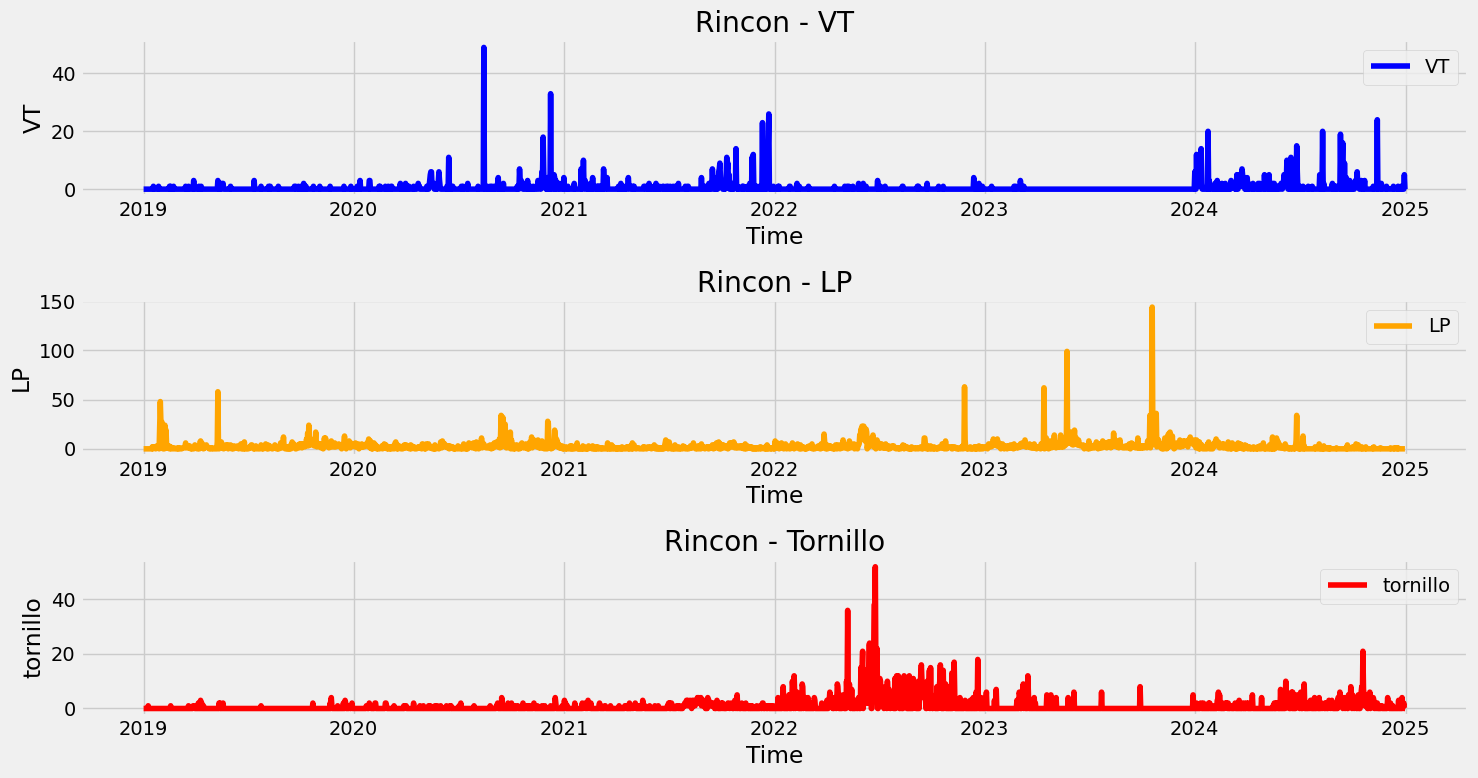

In [30]:
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(Rincon_df.index, Rincon_df['VT'], label='VT', color='blue')
plt.title('Rincon - VT')
plt.xlabel('Time')
plt.ylabel('VT')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(Rincon_df.index, Rincon_df['LP'], label='LP', color='orange')
plt.title('Rincon - LP')
plt.xlabel('Time')
plt.ylabel('LP')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(Rincon_df.index , Rincon_df['tornillo'], label='tornillo', color='red')
plt.title('Rincon - Tornillo')
plt.xlabel('Time')
plt.ylabel('tornillo')
plt.legend()
plt.tight_layout()
plt.show()

They doesnt seem to follow a specific pattern. There seems to be possible outliers . To handle them, I will apply a mean filtering technique to smooth the data and reduce their impact.

# Data preparation (features extraction,...)

## Eruption data features extraction

### Temporal Features

We can use the seasons in costa rica to categorize the eruptions in VRBA. The dry season is from December to April and the wet season is from May to November. We can create a new column in the VRBA eruptions dataframe that will tell us if the eruption happened in the dry or wet season.
https://costa-rica-guide.com/travel/weather/seasons-in-costa-rica/
Evenmore, we can extract the month and time of the day  of each eruption as new features.

In [31]:
def add_temporal_features(df):
    # 0 = Dry Season (Dec–Apr), 1 = Rainy Season (May–Nov)
    dry_months = {12, 1, 2, 3, 4}
    df = df.copy()
    df['season'] = np.where(df['t1'].dt.month.isin(dry_months), 0, 1).astype(int)

    # month feature
    df['month'] = df['t1'].dt.month
    # Cyclical month feature
    df['month norm'] = np.sin((df['t1'].dt.month - 1) * (2 * np.pi / 12))

    # time-of-day feature
    df['Time of the Day'] = df['t1'].dt.hour + df['t1'].dt.minute / 60
    # Cyclical time-of-day feature
    tod = df['t1'].dt.hour + df['t1'].dt.minute / 60
    df['Time of the Day norm'] = np.sin(tod * (2 * np.pi / 24))
    return df



### Analysis New features

Here, as we known that the energy, amplitude rms, amplitude max, amplitude p2p, duration and magnitude are computed after the eruption occured, these features cannot be used for prediction. Thus, we will analyze the correlation of the new features (season, month, time of the day) with the laahres to see if they can be useful for prediction. But they will be used as target variables for classification models.

In [32]:
# Prepare final DataFrames for features and target

feature_columns= ['season', 'month norm', 'Time of the Day norm', 'month', 'Time of the Day']
feature_norm_columns = ['season', 'month norm', 'Time of the Day norm']
# VRBA_all_features_df = VRBA_eruptions_df[['season', 'month', 'Time of the Day']].copy()
# VRBA_all_features_df.info()


target_columns = ['Lahares','duration','amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy_scaled', 'magnitude']
# VRBA_target_df = VRBA_eruptions_df[['Lahares','duration','amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy_scaled']].copy()
# VRBA_target_df.info()

# VRBA_eruptions_df.info()

### Continuous Measurements Features Extraction

#### Eruption chains

A lot of eruptions happens in a chain. Here we will identify those chains and create a new feature in the VRBA eruptions dataframe that will categorize if the eruption is part of a chain or not. An eruption is considered part of a chain if it happens within the window size (predefined) of another eruption.

In [33]:
## Find sequences of following eruptions
def find_eruption_chains(df, window_size):
    chains = []
    # Check if dataframe is empty
    if df.empty:
        return chains
    # Ensure data is sorted by time 
    df_sorted = df.sort_values('t1')
    # Initialize the first chain with the first eruption
    # current_chain stores the indices of the eruptions
    first_id = df_sorted.index[0] 
    current_chain = [int(first_id)]
    # Keep track of the 'last seen' time to compare against
    last_time = df_sorted.loc[first_id, 't1']
    # Iterate through the rest of the eruptions
    for i in range(1, len(df_sorted)):
        curr_id = df_sorted.index[i]
        curr_time = df_sorted.loc[curr_id, 't1']
        # Current Time vs. LAST ADDED Time 
        if curr_time - last_time <= window_size:
            # In the window of the previous eruption, add to chain
            current_chain.append(int(curr_id))
            last_time = curr_time 
        else:
            # Time gap is too big
            # Store the finished chain
            chains.append(current_chain)
            # Start a new chain with the current eruption
            current_chain = [int(curr_id)]
            last_time = curr_time
    # Append the final chain after the loop finishes
    chains.append(current_chain)
    head_chains = [chain[0] for chain in chains]
    return chains, head_chains


It might interresting to predict the head of the chain eruptions because they have the particularity of not being influenced by previous eruptions.

In [34]:
def find_days_of_low_magnitude_eruptions(chain, df,  window_size,magnitude_threshold=2.0):
    erup_time = pd.to_datetime(df.loc[chain, 't1']) 
    erup_magnitude = df.loc[chain, 'magnitude']
    
    low_magnitude_sequences = []
    low_magnitude_sequences_times = []
    
    low_mag_seq = []
    low_mag_seq_times = []
    
    # We keep track of the last strong eruption time to calculate the "true" gap duration when we encounter a new strong eruption
    last_strong_erup_time = erup_time.iloc[0] # Init with the time of the first eruption in the chain, but it will be updated as we go through the chain
    
    for i in range(len(chain)):
        current_time = erup_time.iloc[i]
        current_mag = erup_magnitude.iloc[i]
        
        if current_mag < magnitude_threshold:
            low_mag_seq.append(chain[i])
            low_mag_seq_times.append(current_time)
        else:
            # Find a strong eruption, we check if we had a sequence of low magnitude eruptions before
            if low_mag_seq:
                # Calculate the "true" gap duration from the last strong eruption to the current time (which is the time of the new strong eruption)
                true_gap_duration = current_time - last_strong_erup_time
                # Keep the sequence if the true gap duration is greater than or equal to the window size, otherwise ignore it
                if true_gap_duration >= window_size:
                    print(f"Low mag seq: {low_mag_seq_times[0].strftime('%Y-%m-%d')} to {low_mag_seq_times[-1].strftime('%Y-%m-%d')} | Gap Duration: {true_gap_duration} | Dropped: {len(low_mag_seq)}")
                    low_magnitude_sequences.append(low_mag_seq)
                    
                    low_magnitude_sequences_times.append(low_mag_seq_times)
                # else:
                #     print(f"Ignored small gap: {true_gap_duration} (Need {window_size.days} days)")
                    
                low_mag_seq = []
                low_mag_seq_times = []
            
            last_strong_erup_time = current_time
    # After the loop, we check if there is an ongoing sequence of low magnitude eruptions that we need to evaluate
    if low_mag_seq:
        # Calculate the "true" gap duration from the last strong eruption to the last low magnitude eruption time
        true_gap_duration = low_mag_seq_times[-1] - last_strong_erup_time
        
        if true_gap_duration >= window_size:
            print(f"Final Low mag seq: {low_mag_seq_times[0].strftime('%Y-%m-%d')} to {low_mag_seq_times[-1].strftime('%Y-%m-%d')} | Gap Duration: {true_gap_duration} | Dropped: {len(low_mag_seq)}")
            low_magnitude_sequences.append(low_mag_seq)
            low_magnitude_sequences_times.append(low_mag_seq_times)
        # else:
        #     print(f"Ignored final small gap: {true_gap_duration} (Need {window_size.days} days)")

    return erup_time, erup_magnitude, low_magnitude_sequences, low_magnitude_sequences_times



In [35]:
def apply_purged_grouping(df, window_size, time_col='t1', cut_dates=['2022-05-22', '2023-05-15', '2023-06-25', '2023-09-01', '2023-10-15']):
    """
    Forces hard cuts in time-series data to break up massive sequences.
    Drops data within the purge window and re-calculates isolated sequence IDs.
    """
    # Work on a copy to keep original data safe
    df_clean = df.copy()

    # Deleted Eruptions
    deleted_eruptions = []

    # Identify rows to drop (The Purge Zone)
    rows_to_drop = pd.Series(False, index=df_clean.index)
    
    for date_str in cut_dates:
        start_purge = pd.to_datetime(date_str)
        end_purge = start_purge + window_size
        
        # Find eruptions that fall exactly inside our dead zone
        in_purge_zone = (df_clean[time_col] >= start_purge) & (df_clean[time_col] <= end_purge)
        rows_to_drop = rows_to_drop | in_purge_zone
        deleted_eruptions.extend(df_clean[in_purge_zone].index.tolist())
        
    # Execute the Purge (Drop the rows)
    df_clean = df_clean[~rows_to_drop].copy()
    
    # Automatically generate the new Safe_Group_IDs
    # Any gap > purge_window_days automatically starts a new group.
    # Since we just forced artificial 5-day gaps, this clusters everything perfectly!
    time_diffs = df_clean[time_col].diff()
    
    # The first row is always the start of Group 0. Every gap > 5 days adds +1 to the ID.
    new_sequence_starts = time_diffs > window_size
    df_clean['Erup_Group_ID'] = new_sequence_starts.cumsum()
    
    # print("\n--- Summary ---")
    # print(f"Original eruptions: {len(df)}")
    # print(f"Eruptions safely kept: {len(df_clean)}")
    # print(f"Total isolated groups created: {df_clean['Erup_Group_ID'].nunique()} (No overlapping data!)")
    
    return df_clean, deleted_eruptions

In [36]:
# Eruptions that had lahar events
lahar_eruptions = VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True].index.tolist()
print(f"Eruptions with Lahares: {lahar_eruptions}")

Eruptions with Lahares: [0, 37, 94, 208, 240, 245, 326, 494, 536, 544, 576, 595, 606, 608, 838]


#### Seismic Data 

##### Eruption Windows 

Lets analyze the Rsam values from Rincon de la Vieja just before the eruptions in VRBA. We want to prevent populutation of an eruption at least 7 minutes before it happens. We will thus take an averge value and standard deviation of Rsam values from Rincon de la Vieja in the time window of 7 to 60 minutes before each eruption in VRBA. (POSSIBLE DE REDUIRE LINTERVALLE POUR PLUS DE PRECISION)

It has been established that signals of eruptions could append till 5 days  before the actual eruption. We will thus analyze the Rsam values from Rincon de la Vieja in the time window of 5 days to 7 minutes before each eruption in VRBA. We make sure to take care of the gaps in the countinuous data in order to avoid bias in the calculations. 

In [37]:
WINDOW_SIZE = pd.Timedelta(days=5) # pd.Timedelta(days=3)

In [38]:
def get_eruptions_windows_data(continuous_df, reference_df, window_size, maximum_observation_time_before_eruption,time_type = 'min'):
    
    # Security check
    increasing_index = continuous_df.index.is_monotonic_increasing
    datetime_index = isinstance(continuous_df.index, pd.DatetimeIndex)
    if not datetime_index :
        raise ValueError("The continuous DataFrame index must be a DatetimeIndex.")
    if not increasing_index:
        #print("Sorting continuous DataFrame by index...")
        continuous_df = continuous_df.sort_index()
     
    # Dictionaries to store results
    eruptions_windows_indices = {}

    max_obs_bfr_eruption = maximum_observation_time_before_eruption
    
    for index, row in reference_df.items():
        
        eruption_time = row.floor(time_type)

        start_time = eruption_time - window_size
        end_time = eruption_time - max_obs_bfr_eruption

        # Create a mask for the time window
        mask = (continuous_df.index >= start_time) & (continuous_df.index <= end_time)
        window_data = continuous_df.loc[mask]

        # Store indices 
        eruptions_windows_indices[index] = window_data.index.tolist()

    # Return both dictionaries
    return eruptions_windows_indices

In [39]:
def build_or_load_eruptions_windows_indices(
    datasets,
    eruption_times,
    window_size,
    output_dir='MSc_Bryan_Rincon/Eruptions indices',
    mode='load',
    max_obs_minutes=7,
    max_obs_days=1,
):
    """
    Automated extraction, computation, and loading of eruption windows for multiple datasets.
    
    Parameters:
    -----------
    datasets : dict
        Configuration dictionary mapping dataset names to their config.
        Example:
        {
            'eruptions_windows_indices_VRBA': {
                'df': Rincon_de_la_Vieja_df,
                'file_name': 'eruptions_windows_indices_VRBA.npy',
                'time_type': None,  # optional
            },
            'sei_geo_eruptions_windows_indices': {
                'df': Rincon_df,
                'file_name': 'sei_geo_eruptions_windows_indices.npy',
                'time_type': 'D',  # optional, for daily granularity
            }
        }
    
    eruption_times : pd.Series
        Series containing eruption time points (e.g., VRBA_eruptions_df['t1'])
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    output_dir : str, default 'MSc_Bryan_Rincon/Eruptions indices'
        Directory where numpy files are saved/loaded
    
    mode : str, default 'load'
        - 'load': Load pre-computed data from numpy files (fastest)
        - 'save': Compute and save to numpy files
        - 'compute': Compute without saving
    
    max_obs_minutes : int, default 7
        Minutes before eruption for standard observation window
    
    max_obs_days : int, default 1
        Days before eruption for daily-granularity datasets
    
    Returns:
    --------
    dict : Dictionary mapping dataset names to their eruptions_windows_indices
    
    Example Usage:
    --------------
    # First time: compute and save all datasets
    all_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_WINDOWS_CONFIG,
        eruption_times=VRBA_eruptions_df['t1'],
        window_size=WINDOW_SIZE,
        mode='save'
    )
    
    # Subsequent runs: load from disk (fast)
    all_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_WINDOWS_CONFIG,
        eruption_times=VRBA_eruptions_df['t1'],
        window_size=WINDOW_SIZE,
        mode='load'
    )
    
    # Extract individual results
    vrba_data = all_windows['eruptions_windows_indices_VRBA']
    rsam_data = all_windows['eruptions_windows_indices_rsam_VORI']
    dsar_data = all_windows['eruptions_windows_indices_dsar_VORI']
    sei_data = all_windows['sei_geo_eruptions_windows_indices']
    """
    
    results = {}
    max_obs_minutes_td = pd.Timedelta(minutes=max_obs_minutes)
    max_obs_days_td = pd.Timedelta(days=max_obs_days)

    for result_name, cfg in datasets.items():
        file_path = f"{output_dir}/{cfg['file_name']}"

        # Load mode: retrieve pre-computed data from disk
        if mode == 'load':
            results[result_name] = np.load(file_path, allow_pickle=True).item()
            continue

        # Compute or Save mode: determine which observation window to use
        time_type = cfg.get('time_type', None)
        max_obs = max_obs_days_td if time_type == 'D' else max_obs_minutes_td

        # Build kwargs for get_eruptions_windows_data
        kwargs = {
            'maximum_observation_time_before_eruption': max_obs,
        }
        if time_type == 'D':
            kwargs['time_type'] = 'D'

        # Call the extraction function
        windows = get_eruptions_windows_data(
            cfg['df'],
            eruption_times,
            window_size,
            **kwargs,
        )
        results[result_name] = windows

        # Save mode: persist to disk
        if mode == 'save':
            np.save(file_path, windows)
    return results

In [40]:
ERUPTION_WINDOWS_CONFIG = {
    'eruptions_windows_indices_VRBA': {
        'df': Rincon_de_la_Vieja_df,
        'file_name': 'eruptions_windows_indices_VRBA.npy',
    },
    'eruptions_windows_indices_rsam_VORI': {
        'df': rsam_VORI_df,
        'file_name': 'eruptions_windows_indices_rsam_VORI.npy',
    },
    'eruptions_windows_indices_dsar_VORI': {
        'df': dsar_VORI_df,
        'file_name': 'eruptions_windows_indices_dsar_VORI.npy',
    },
    'sei_geo_eruptions_windows_indices': {
        'df': Rincon_df,
        'file_name': 'sei_geo_eruptions_windows_indices.npy',
        'time_type': 'D',  # Use 1-day observation window
    },
}

 We can see that a lot of eruptions are poorly covered during the 5 days preceding the eruption for the VRBA station. The eruptions that are less covered will be less reliable for the analysis. However for the VORI station there seems to be better coverage of the eruptions during the 5 days preceding the eruption.

##### No Eruption Windows

We need to evaluate also window where nothing is happening to have a better idea of the difference between eruption and non-eruption windows. We will thus create random windows of 5 days duration in the Rincon de la Vieja continuous dataframe where no eruption is happening in VRBA. We will then apply the same feature extraction process on those windows.

In [41]:
# Exclude data points that are too close to eruptions
def get_surrounding_eruption_indices(continuous_df, eruption_df, neighbour_limit):

    surrounding_indices = {}
    
    for index, row in eruption_df.iterrows():
        eruption_time = row['t1'] 
     
        start_exclusion = eruption_time - neighbour_limit[0]
        end_exclusion = eruption_time + neighbour_limit[1]
        
        mask = (continuous_df.index >= start_exclusion) & (continuous_df.index <= end_exclusion)
        indices_to_exclude = continuous_df.index[mask].tolist()
        
        if indices_to_exclude:
            surrounding_indices[index] = indices_to_exclude
            
    return surrounding_indices

In [42]:
# List all data points left unused after excluding eruption windows
def get_unused_data_indices(df, eruptions_windows_indices):
    # Collect all indices currently used in eruption windows
    all_used_indices = set()
    for indices in eruptions_windows_indices.values():
        all_used_indices.update(indices)
    
    # Get all available indices from the DataFrame
    all_data_indices = set(df.index.tolist())
    
    # Find the difference (available - used) and sort them
    unused_indices = sorted(list(all_data_indices - all_used_indices))
    
    #print(f"Number of unused data points: {len(unused_indices)}")
    
    return unused_indices

In [43]:
# Group close non eruptions points together

def create_group_non_eruption_points(unused_indices, window_duration):

    if len(unused_indices) == 0:
        print("No unused data points to group.")
        return []

    sorted_indices = sorted(unused_indices)

    groups = []
    current_group = [sorted_indices[0]]


    for i in range(1, len(sorted_indices)):
        time_diff = sorted_indices[i] - sorted_indices[i-1]

        if time_diff > window_duration:
            groups.append(current_group)
            current_group = [sorted_indices[i]]
        else:
            current_group.append(sorted_indices[i])

    if current_group:
        groups.append(current_group)

    return groups

In [44]:
## Create Window of maximum WINDOW SIZE days of no-eruption data
def create_no_eruption_windows(groups, window_duration, offset, maximum_observation_time_before_eruption, max_chain_length=36, return_chains=False):

    no_eruptions_windows_indices = {}
    virtual_no_eruption_times = []
    
    # id for each window
    window_id = 0 

    # Security gap before virtual no-eruption time
    max_obs_bfr_eruption = maximum_observation_time_before_eruption

    # Store the chains of no-eruption windows for each group
    no_eruption_chains = []
    

    for group_id, group in enumerate(groups):
        # Skip empty groups
        if not group:
            continue 

        start_time = group[0]
        max_time = group[-1]

        current_start = start_time

        # window in the same group
        if current_start + window_duration > max_time:
            continue
        chain = []

        while current_start + window_duration <= max_time:
            # Virtual no-eruption 
            virtual_no_eruption_time = current_start + window_duration
        
            # Security end time
            security_end_time = virtual_no_eruption_time - max_obs_bfr_eruption
            
            # Get indices within the current window
            window_indices = [t for t in group if current_start <= t <= security_end_time]

            number_of_points = len(window_indices)

            # Skip empty windows
            if number_of_points == 0:
                current_start += offset
                continue

            # Store in dictionary with its window id
            no_eruptions_windows_indices[window_id] = window_indices

            # Store the virtual no-eruption time
            virtual_no_eruption_times.append(virtual_no_eruption_time)

            # Increment for next window
            chain.append(window_id)
            window_id += 1

            if len(chain) >= max_chain_length and  offset < window_duration:

                no_eruption_chains.append(chain)
                chain = []
                current_start += window_duration
            else :
                current_start += offset
        if chain:  # Check if there's an unfinished chain at the end of the group
            no_eruption_chains.append(chain)

    return no_eruptions_windows_indices, np.array(virtual_no_eruption_times), no_eruption_chains
  


In [45]:
def chain_stratified_undersampling(no_eruption_chains, no_erup_dict, target_nb):
    """
    Samples no-eruption windows while respecting isolated chains.
    The number of windows drawn from each chain is proportional to its length.
    """
    total_available_windows = sum(len(chain) for chain in no_eruption_chains)
    
    selected_keys = []
    
    if target_nb >= total_available_windows:
        print(f"Not enough total windows available. There are only {total_available_windows} available, keeping all.")
        return list(no_erup_dict.keys())

    
    # Iterate through each isolated chain
    for chain in no_eruption_chains:
        
        # Calculate the quota: How many windows should this chain provide?
        # (Chain size / Total available) * Target requirement
        proportion = len(chain) / total_available_windows
        quota = max(1, int(round(proportion * target_nb)))
        
        # If the chain is supposed to provide windows, extract them
        if quota > 0:
            # Safety check: Cannot extract more windows than the chain contains
            quota = min(quota, len(chain))
            
            # Systematic sampling WITHIN the chain (to maximize the gap between windows)
            indices = np.linspace(0, len(chain) - 1, quota, dtype=int)
            for idx in indices:
                selected_keys.append(chain[idx])

    # Final adjustment (due to rounding, we might end up with 398 or 402 instead of 400)
    # If there are slightly too many, randomly remove the excess
    if len(selected_keys) > target_nb:
        selected_keys = random.sample(selected_keys, target_nb)
    # If there are slightly too few, we could compensate (usually negligible)
        
    # Reconstruct the final dictionary
    # balanced_no_eruptions = {k: no_erup_dict[k] for k in selected_keys}
    
    print(f"Extraction complete: {len(selected_keys)} windows extracted from {len(no_eruption_chains)} chains.")
    return selected_keys  #balanced_no_eruptions

In [46]:

def build_or_load_no_eruption_windows_indices(
    datasets,
    eruptions_df,
    window_size,
    neighbour_limits,
    continuous_offset,
    max_obs_minutes=7,
    output_dir='MSc_Bryan_Rincon/Eruptions indices',
    mode='load',
    time_type= 'min',
):
    """
    Automated extraction, computation, and loading of non-eruption windows for multiple datasets.
    
    Parameters:
    -----------
    datasets : dict
        Configuration dictionary mapping dataset names to their config.
        Must include reference dataset (typically VRBA) for creating non-eruption groups.
        Example:
        {
            'no_eruption_windows_indices_VRBA': {
                'df': Rincon_de_la_Vieja_df,
                'file_name': 'no_eruption_windows_indices_VRBA.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
                'is_reference': True,  # Only one dataset should be True
            },
            'no_eruption_windows_indices_rsam_VORI': {
                'df': rsam_VORI_df,
                'file_name': 'no_eruption_windows_indices_rsam_VORI.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
            },
            'no_eruption_windows_indices_dsar_VORI': {
                'df': dsar_VORI_df,
                'file_name': 'no_eruption_windows_indices_dsar_VORI.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
            }
        }
    
    eruptions_df : pd.DataFrame
        DataFrame containing eruption information (typically VRBA_eruptions_df)
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    neighbour_limits : list of pd.Timedelta
        Time limits to exclude around eruptions [before_limit, after_limit]
        Example: [pd.Timedelta(days=14), pd.Timedelta(days=2)]
    
    continuous_offset : pd.Timedelta
        Offset for creating virtual non-eruption times
        Example: pd.Timedelta(days=4)
    
    max_obs_minutes : int, default 7
        Minutes before non-eruption times for observation window
    
    output_dir : str, default 'MSc_Bryan_Rincon/Eruptions indices'
        Directory where numpy files are saved/loaded
    
    mode : str, default 'load'
        - 'load': Load pre-computed data from numpy files (fastest)
        - 'save': Compute and save to numpy files
        - 'compute': Compute without saving
    
    Returns:
    --------
    dict : Dictionary mapping dataset names to their no_eruption_windows_indices
    dict : Dictionary of virtual non-eruption times used for computation
    """
    
    results = {}
    max_obs_td = pd.Timedelta(minutes=max_obs_minutes)
    virtual_no_eruption_times = None
    no_eruption_chains = None
    reference_unused_indices = None
    
    # Find the reference dataset (is_reference=True)
    reference_name = None
    reference_cfg = None
    for name, cfg in datasets.items():
        if cfg.get('is_reference', False):
            reference_name = name
            reference_cfg = cfg
            break
    
    if reference_name is None:
        raise ValueError("One dataset must have 'is_reference': True")
    
    # Load mode: retrieve pre-computed data from disk
    # if mode == 'load':
    #     for result_name, cfg in datasets.items():
    #         file_path = f"{output_dir}/{cfg['file_name']}"
    #         results[result_name] = np.load(file_path, allow_pickle=True).item()
    if mode == 'load':
        for result_name, cfg in datasets.items():
            file_path = f"{output_dir}/{cfg['file_name']}"
            # Charger depuis pickle au lieu de numpy
            pkl_path = file_path.replace('.npy', '.pkl')
            with open(pkl_path, 'rb') as f:
                results[result_name] = pickle.load(f)
        
        # Also load virtual times
        if reference_cfg.get('virtual_file_name', False):
            virtual_times_path = f"{output_dir}/{reference_cfg['virtual_file_name']}"
            virtual_no_eruption_times = np.load(virtual_times_path, allow_pickle=True)

        # Load no-eruption chains if needed
        if reference_cfg.get('no_eruption_chains_file_name', False):
            chains_path = f"{output_dir}/{reference_cfg['no_eruption_chains_file_name']}"
            with open(chains_path, 'rb') as f:
                no_eruption_chains = pickle.load(f)

        
        return results, virtual_no_eruption_times, no_eruption_chains
    
    # Compute mode: generate from scratch
    # Step 1: Get indices to exclude around eruptions (reference dataset only)
    nearby_eruption_indices = get_surrounding_eruption_indices(
        reference_cfg['df'],
        eruptions_df,
        neighbour_limits
    )
    
    # Step 2: Get unused data indices after exclusion
    reference_unused_indices = get_unused_data_indices(
        reference_cfg['df'],
        nearby_eruption_indices
    )
    
    # Step 3: Create groups of non-eruption points
    non_eruption_groups = create_group_non_eruption_points(
        reference_unused_indices,
        window_size
    )
    #print(f"Number of non-eruption data point groups: {len(non_eruption_groups)}")
    
    # Step 4: Create no-eruption windows for reference dataset
    no_eruption_windows_reference, virtual_no_eruption_times, no_eruption_chains = create_no_eruption_windows(
        non_eruption_groups,
        window_size,
        continuous_offset,
        maximum_observation_time_before_eruption=max_obs_td
    )
    #print(f"Number of no-eruption windows created: {len(no_eruption_windows_reference)}")
    
    results[reference_name] = no_eruption_windows_reference
    
    # Step 5: Get no-eruption windows for other datasets using virtual times
    for result_name, cfg in datasets.items():
        if cfg.get('is_reference', False):
            continue  # Already computed above
        
        windows = get_eruptions_windows_data(
            cfg['df'],
            pd.Series(virtual_no_eruption_times),
            window_size,
            maximum_observation_time_before_eruption=max_obs_td,
            time_type=time_type
        )
        results[result_name] = windows
    
    # Step 6: Save mode - persist all to disk
    # if mode == 'save':
    #     for result_name, data in results.items():
    #         cfg = datasets[result_name]
    #         file_path = f"{output_dir}/{cfg['file_name']}"
    #         np.save(file_path, data)

    # Step 6: Save mode - persist all to disk
    if mode == 'save':
        for result_name, data in results.items():
            cfg = datasets[result_name]
            file_path = f"{output_dir}/{cfg['file_name']}"
            # Remplacer np.save par pickle
            with open(file_path.replace('.npy', '.pkl'), 'wb') as f:
                pickle.dump(data, f)
    
    # Dans load, adapter aussi :
    # results[result_name] = pickle.load(open(file_path.replace('.npy', '.pkl'), 'rb'))
        
        # Also save virtual times
        if reference_cfg.get('virtual_file_name', False):
            virtual_times_path = f"{output_dir}/{reference_cfg['virtual_file_name']}"
            np.save(virtual_times_path, virtual_no_eruption_times)

        if reference_cfg.get('no_eruption_chains_file_name', False):
            chains_path = f"{output_dir}/{reference_cfg['no_eruption_chains_file_name']}"
            with open(chains_path, 'wb') as f:
                pickle.dump(no_eruption_chains, f)
    
    return results, virtual_no_eruption_times, no_eruption_chains

In [47]:
NO_ERUPTION_WINDOWS_CONFIG = {
    'no_eruption_windows_indices_VRBA': {
        'df': Rincon_de_la_Vieja_df,
        'file_name': 'no_eruption_windows_indices_VRBA.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',
        'is_reference': True,  # This dataset creates the non-eruption groups
    },
    'no_eruption_windows_indices_rsam_VORI': {
        'df': rsam_VORI_df,
        'file_name': 'no_eruption_windows_indices_rsam_VORI.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',

    },
    'no_eruption_windows_indices_dsar_VORI': {
        'df': dsar_VORI_df,
        'file_name': 'no_eruption_windows_indices_dsar_VORI.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',
    }
}

##### No overlapping Eruption and No Eruption Windows

As said before, the head of the chain eruptions could be interresting to predict because they are not influenced by previous eruptions. In this sense, for a balanced dataset, we need to select an equivalent number of no-eruption windows as head eruptions. As we allowed overlapping windows for the no-eruption windows, 

In [48]:
# Extract head eruption windows data
def extract_head_eruption_windows_data(eruptions_windows_indices_VRBA, eruptions_windows_indices_rsam_VORI, eruptions_windows_indices_dsar_VORI, sei_geo_eruptions_windows_indices, head_chains, print_number=False):
    # Implementation for extracting head eruption windows data
    head_eruptions_windows_indices_VRBA = {erup_id: eruptions_windows_indices_VRBA[erup_id] for erup_id in head_chains}
    head_eruptions_windows_indices_rsam_VORI = {erup_id: eruptions_windows_indices_rsam_VORI[erup_id] for erup_id in head_chains}
    head_eruptions_windows_indices_dsar_VORI = {erup_id: eruptions_windows_indices_dsar_VORI[erup_id] for erup_id in head_chains}
    head_sei_geo_eruptions_windows_indices = {erup_id: sei_geo_eruptions_windows_indices[erup_id] for erup_id in head_chains}
    if print_number:
        print(f"Number of head eruption windows: {len(head_eruptions_windows_indices_VRBA)}")

    return head_eruptions_windows_indices_VRBA, head_eruptions_windows_indices_rsam_VORI, head_eruptions_windows_indices_dsar_VORI, head_sei_geo_eruptions_windows_indices

# print(type(eruptions_windows_indices_dsar_VORI))
# head_eruptions_windows_indices_VRBA, head_eruptions_windows_indices_rsam_VORI, head_eruptions_windows_indices_dsar_VORI, head_sei_geo_eruptions_windows_indices = extract_head_eruption_windows_data(eruptions_windows_indices_VRBA, eruptions_windows_indices_rsam_VORI, eruptions_windows_indices_dsar_VORI, sei_geo_eruptions_windows_indices, head_chains, print_number=True)


##### Eruption and No Eruption Windows Features Extraction

Here we are going to write functions that will help select the useful informations in the windows.

First we create a function that will for each eruptions seperate continuous data stream with a tolerance of missing data points. For example if we have a window with data points [1,2,3,10,11,12] and a tolerance of 2, the function will return [[1,2,3],[10,11,12]] because the gap between 3 and 10 is more than 2. If the tolerance was 7, the function would return [[1,2,3,10,11,12]] because the gap is less than 7. It will help us for the next function where we are going to pass those groups trough a median filter to get a signal with less fluctuations.

In [49]:
## Median filter the RSAM data in each valid list of continuous data points per eruption window

MEDIAN_NUMBER = int(pd.Timedelta(days=1)/pd.Timedelta(minutes=1))
#MEDIAN_NUMBER = int(pd.Timedelta(hours=1)/pd.Timedelta(minutes=1)) 


def median_filter(valid_lists,continuous_df, metric):# Need a list of lists as input
    MEDIAN_NUMBER = int(pd.Timedelta(days=1)/pd.Timedelta(minutes=1))
    n = len(valid_lists)
    filtered = []
    for i in range(n):
        Rincon_metric = continuous_df[metric][continuous_df.index.isin(valid_lists[i])].copy()
        Rincon_metric = Rincon_metric.rolling(window=MEDIAN_NUMBER,min_periods=int(MEDIAN_NUMBER / 2), center=True).median()
        filtered.append(Rincon_metric)
    return filtered


In [50]:
# Separate window on subset of continuous data with a certain limit of missing data allowed
continuous_LIMIT_HOLE = pd.Timedelta(hours=1)  # Maximum allowed gap between data points
SEI_GEO_LIMIT_HOLE = pd.Timedelta(days=1)  # Maximum allowed gap between data points for SEI-GEO data       

def select_valid_lists(indices_list, limit_hole=continuous_LIMIT_HOLE):
    # Check if the list is empty
    if not indices_list:
        return []
    
    # Initiate lists
    valid_lists =[]
    current_group = [indices_list[0]]

    for i in range(1, len(indices_list)):
        current = indices_list[i]
        prev = current_group[-1]

        #  Check the gap
        if (current - prev) <= limit_hole: 
            # Gap is within limit: add to current group
            current_group.append(current)
        else :
            if limit_hole == continuous_LIMIT_HOLE:   
                # Gap is too big: group is finished.
                if len(current_group)>0.5*MEDIAN_NUMBER :
                    valid_lists.append(current_group)
            elif limit_hole == SEI_GEO_LIMIT_HOLE:
                valid_lists.append(current_group)
            # Start a new group with the current number
            current_group = [current]
            
    # Handle the last group remaining after the loop
    if limit_hole == continuous_LIMIT_HOLE:   
        if len(current_group)> 0.5*MEDIAN_NUMBER :
            valid_lists.append(current_group)
    elif limit_hole == SEI_GEO_LIMIT_HOLE:
        valid_lists.append(current_group)
    return valid_lists

We can see there is a majoritiy of one unified group of data points per window. It means that most of the eruptions have continuous measurement that did not get interrupted. However, few eruptions have multiple groups of data points meaning that there several non negligible gaps in the data points coverage.    

In [51]:
def get_window_coverage(indices_dict, window_duration, measure_frequency, station, maximum_observation_time_before_eruption=7, limit_hole=continuous_LIMIT_HOLE):
    """
    Filters eruption windows to keep only those exceeding a minimum data coverage percentage.
    
    Parameters:
    - indices_dict: Dictionary of raw indices for each window {id: [indices]}.
    - window_duration: Duration of the window (e.g., 5 days).
    - measure_frequency: Frequency of measurements (e.g., 1 minute).
    - coverage_threshold: Minimum percentage of data required (default 50).
    - station: Station name for reference.
    - maximum_observation_time_before_eruption: Time before eruption to consider.
    
    Returns:
    - coverage_filtered_indices: Dictionary with coverage info for each window.
    """
    coverage_filtered_indices = {}

    # Iterate through the dictionary 
    for eruption_id, window_indices in indices_dict.items():
        
        # Get valid continuous segments 
        valid_segments = select_valid_lists(window_indices, limit_hole=limit_hole)
        
        # Calculate total present data points
        total_data_points = sum(len(group) for group in valid_segments)
       
        # Calculate coverage percentage
        coverage_percentage = (total_data_points / ((window_duration - maximum_observation_time_before_eruption) / measure_frequency)) * 100
        
        
        coverage_filtered_indices[eruption_id] = {  
                                                    'indices' : window_indices,
                                                    'coverage_percentage' : coverage_percentage,
                                                    'station' : station
                                                }
          
    return coverage_filtered_indices

# MEASURE_FREQUENCY = pd.Timedelta(minutes=1)  
# # print("Getting eruption window data coverage...")
# # eruption_coverage_data_VRBA = get_window_coverage(eruptions_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# # eruption_coverage_rsam_data_VORI = get_window_coverage(eruptions_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# # eruption_coverage_dsar_data_VORI = get_window_coverage(eruptions_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# print("Getting no-eruption window data coverage...")
# no_eruption_coverage_data_VRBA = get_window_coverage(no_eruption_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# no_eruption_coverage_rsam_data_VORI = get_window_coverage(no_eruption_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# no_eruption_coverage_dsar_data_VORI = get_window_coverage(no_eruption_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# print("Getting head eruption window data coverage...")
# head_eruption_coverage_data_VRBA = get_window_coverage(head_eruptions_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_eruption_coverage_data_rsam_VORI = get_window_coverage(head_eruptions_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_eruption_coverage_data_dsar_VORI = get_window_coverage(head_eruptions_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# print("Getting head no-eruption window data coverage...")
# head_no_eruption_coverage_data_VRBA = get_window_coverage(head_no_eruption_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_no_eruption_coverage_data_rsam_VORI = get_window_coverage(head_no_eruption_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_no_eruption_coverage_data_dsar_VORI = get_window_coverage(head_no_eruption_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)


In [52]:
def build_window_coverage_data(
    window_datasets,
    window_size,
    measure_frequency,
    max_obs_minutes=7,
):
    """
    Automated computation of window coverage data for multiple window types and datasets.
    
    Parameters:
    -----------
    window_datasets : dict
        Configuration dictionary mapping window type names to their datasets.
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    measure_frequency : pd.Timedelta
        Measurement frequency for coverage calculation (e.g., pd.Timedelta(minutes=1))
    
    max_obs_minutes : int, default 7
        Minutes before eruptions for observation window
    
    Returns:
    --------
    dict : Nested dictionary organized as:
           {window_type: {dataset_name: coverage_data}}
    """
    
    results = {}
    max_obs_td = pd.Timedelta(minutes=max_obs_minutes)
    
    for window_type, datasets in window_datasets.items():
        results[window_type] = {}
        print(f"Getting {window_type} window data coverage...")
        
        for dataset_name, cfg in datasets.items():
            coverage_data = get_window_coverage(
                cfg['indices'],
                window_size,
                measure_frequency,
                station=cfg['station'],
                maximum_observation_time_before_eruption=max_obs_td,
            )
            results[window_type][dataset_name] = coverage_data
    
    return results

In [53]:
def count_high_coverage_windows(coverage_data, threshold=50):
    """
    Count the number of windows with coverage above a certain threshold.
    
    Parameters:
    -----------
    coverage_data : dict
        Dictionary with window IDs as keys and coverage info as values.
        Example: {0: {'indices': [...], 'coverage_percentage': 75.0, 'station': 'VRBA'}, ...}
    threshold : float
        Coverage percentage threshold to count windows.
        
    Returns:
    --------
    int
        Number of windows with coverage above the threshold.
    """
    count = 0
    for window_info in coverage_data.values():
        if window_info['coverage_percentage'] >= threshold:
            count += 1
    return count


def print_coverage_summary(coverage_datasets, thresholds=[50, 70, 99]):
    """
    Print coverage summary for multiple datasets at different thresholds.
    
    Parameters:
    -----------
    coverage_datasets : dict
        Dictionary with dataset names as keys and coverage data as values.
        Example: {'Eruption VRBA': eruption_coverage_data_VRBA, ...}
    thresholds : list
        List of coverage thresholds (in percent) to report.
    """
    for threshold in thresholds:
        print(f"=== Coverage >= {threshold}% ===")
        for name, data in coverage_datasets.items():
            high_coverage = count_high_coverage_windows(data, threshold=threshold)
            total = len(data)
            percentage = (high_coverage / total * 100) if total > 0 else 0
            print(f"{name}: {high_coverage} / {total} ({percentage:.1f}%)")
        print()

In [54]:
# Function to plot eruption windows data RSAM and DSAR
def get_filtered_window_data(eid, cov_vrba, cov_rsam_vori, cov_dsar_vori, show_stats=False, inverse_rsam=False):
    """
    Retrieves and filters RSAM and DSAR data for a specific eruption ID.
    """
    # Prepare raw index lists
    list_vrba = select_valid_lists(cov_vrba[eid]['indices'])
    list_rsam_vori = select_valid_lists(cov_rsam_vori[eid]['indices'])
    list_dsar_vori = select_valid_lists(cov_dsar_vori[eid]['indices'])

    if show_stats:
            print(f"Eruption Window ID: {eid} - VRBA valid segments: {len(list_vrba)}, VORI RSAM valid segments: {len(list_rsam_vori)}, VORI DSAR valid segments: {len(list_dsar_vori)}")

    # Apply median filter
    if not inverse_rsam :
        filt_rsam_vrba = median_filter(list_vrba, Rincon_de_la_Vieja_df, 'rsam')
        filt_rsam_vori = median_filter(list_rsam_vori, rsam_VORI_df, 'value')
    else:
        Inverse_rsam_VRBA_df = 1/Rincon_de_la_Vieja_df['rsam']
        Inverse_rsam_VORI_df = 1/rsam_VORI_df['value']
        filt_rsam_vrba = median_filter(list_vrba, Inverse_rsam_VRBA_df.to_frame(name='rsam'), 'rsam')
        filt_rsam_vori = median_filter(list_rsam_vori, Inverse_rsam_VORI_df.to_frame(name='value'), 'value')
    filt_dsar_vrba = median_filter(list_vrba, Rincon_de_la_Vieja_df, 'dsar')
    filt_dsar_vori = median_filter(list_dsar_vori, dsar_VORI_df, 'value')

    return filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori

def plot_peaks_on_segment(s, peak_info, annotate=True):
    """
    Plot peaks and troughs on a given signal segment.
    s : pandas Series
    peak_info : dict for one segment (peaks[eid][station][metric][segment_id])
    """

    # High peaks 
    h_idx = peak_info.get("h_index", [])
    if len(h_idx) > 0:
        plt.scatter(s.index[h_idx], s.values[h_idx], marker='x', color='red', label='Peaks')
        h_widths = peak_info.get("h_widths_plot", [])
        left_ips = np.clip(h_widths[2].astype(int), 0, len(s) - 1)
        right_ips = np.clip(h_widths[3].astype(int), 0, len(s) - 1)
        plt.hlines(h_widths[1],s.index[left_ips], s.index[right_ips], color='C3')

        if annotate:
            for i, idx in enumerate(h_idx):
                prom = peak_info["h_prominences"][i]
                t = s.index[idx]
                v = s.values[idx]

                plt.vlines(t, v - prom, v, color='orange', linestyle='--', alpha=0.7)
                plt.text(t, v + 0.05 * v, f'Prominence:{prom:.1f}', color='orange', ha='center')

    # Low troughs
    l_idx = peak_info.get("l_index", [])
    if len(l_idx) > 0:
        plt.scatter(s.index[l_idx], s.values[l_idx], marker='x', color='green')
        l_widths = peak_info.get("l_widths_plot", [])
        left_ips = np.clip(l_widths[2].astype(int), 0, len(s) - 1)
        right_ips = np.clip(l_widths[3].astype(int), 0, len(s) - 1)
        plt.hlines(-l_widths[1],s.index[left_ips], s.index[right_ips], color='purple', linestyle='-', alpha=0.7)
        if annotate:
            for i, idx in enumerate(l_idx):
                depth = peak_info["l_prominences"][i]
                t = s.index[idx]
                v = s.values[idx]

                plt.vlines(t, v, v + depth, color='purple', linestyle='--', alpha=0.7)
                plt.text(t, v - 0.05 * v, f'Drop: {depth:.1f}', color='purple', ha='center')


def plot_eruption_windows(erup_ids, cov_vrba, cov_rsam_vori, cov_dsar_vori, peaks = None, inverse_rsam=False):
    plt.style.use("default")
    plt.figure(figsize=(30, 5 * len(erup_ids)))

    # Color maps (using objects to avoid index errors)
    cmap_vrba = plt.cm.tab10
    cmap_rsam_vori = plt.cm.tab20b
    cmap_dsar_vori = plt.cm.Accent

    for i, eid in enumerate(erup_ids):
        # Get filtered data
        filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(eid, cov_vrba, cov_rsam_vori, cov_dsar_vori, inverse_rsam=inverse_rsam)

        # Plot RSAM
        plt.subplot(len(erup_ids), 2, 2*i + 1)
        has_plot = False
        
        for k, s in enumerate(filt_rsam_vrba):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'RSAM VRBA {k+1}', color=cmap_vrba(k % 10))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VRBA']['RSAM'][k], annotate=True)
                has_plot = True
                
        for k, s in enumerate(filt_rsam_vori):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'RSAM VORI {k+1}', color=cmap_rsam_vori(k % 20), linestyle='--')
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VORI']['RSAM'][k], annotate=True)
                has_plot = True

        plt.title(f'ID: {eid} (RSAM)')
        plt.ylabel('RSAM')
        if has_plot: plt.legend(fontsize='small')

        # Plot DSAR
        plt.subplot(len(erup_ids), 2, 2*i + 2)
        has_plot = False

        for k, s in enumerate(filt_dsar_vrba):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'DSAR VRBA {k+1}', color=cmap_vrba(k % 10))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VRBA']['DSAR'][k], annotate=True)
                has_plot = True

        for k, s in enumerate(filt_dsar_vori):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'DSAR VORI {k+1}', color=cmap_dsar_vori(k % 8))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VORI']['DSAR'][k], annotate=True)
                has_plot = True

        plt.title(f'ID: {eid} (DSAR)')
        plt.ylabel('DSAR')
        if has_plot: plt.legend(fontsize='small')

    plt.tight_layout()
    plt.show()

In [55]:
# Function to extract peak and trough information from metric data

def extract_metric_info(metric_clean, metric_inverted, h_selected, l_selected):
    high_peaks = {}
    high_peak_widths = {}
    h_prominences = {}
    high_peak_heights = {}

    low_trough = {}
    low_trough_widths = {}
    l_prominences = {}
    low_trough_heights = {}

    for (key, index) in h_selected:
        if key not in high_peaks:
            high_peaks[key] = []
            high_peak_widths[key] = []
            h_prominences[key] = []
            high_peak_heights[key] = []
        high_peaks[key].append(index)

        high_peak_widths[key] = signal.peak_widths(metric_clean[key], high_peaks[key], rel_height=1.0)
        # Find the prominence of the high peaks
        h_prominences[key] = signal.peak_prominences(metric_clean[key], high_peaks[key])[0]
        # Find the heights of the peaks
        high_peak_heights[key] = metric_clean[key][high_peaks[key]]

        
    for (key, index) in l_selected:
        if key not in low_trough:
            low_trough[key] = []
            low_trough_widths[key] = []
            l_prominences[key] = []
            low_trough_heights[key] = []
        low_trough[key].append(index)

        low_trough_widths[key] = signal.peak_widths(metric_inverted[key], low_trough[key], rel_height=1.0)
        # Find the depth of the drops
        l_prominences[key] = signal.peak_prominences(metric_inverted[key], low_trough[key])[0]
        # Find the heights of the troughs (negative values)
        low_trough_heights[key] = metric_clean[key][low_trough[key]]

    return high_peaks, high_peak_widths,h_prominences, high_peak_heights, low_trough,low_trough_widths,l_prominences, low_trough_heights

In [56]:
## Analyze RSAM data to find peaks and troughs

# Parameters for peak detection

DISTANCE_PEAKS = pd.Timedelta(days=0.5)/pd.Timedelta(minutes=1)  # Minimum distance between peaks in number of data points

HEIGHT_THRESHOLD = 80
def clean_dict(data_dict):
        cleaned = {}
        for k, v in data_dict.items():
            # If v is a tuple (raw scipy output), take the first item
            if isinstance(v, tuple):
                cleaned[k] = v[0]
            else:
                cleaned[k] = v
        return cleaned

def analyze_and_plot_metric(metrics_signals, dates):
    high_peaks_index = []
    low_trough_index = []
    high_peaks_values = []
    low_trough_values = []
    metric_clean = {}
    metric_inverted = {}
    dates_clean = {}

    
    for index, metric_signal in enumerate(metrics_signals):

        # Remove NaNs
        mask = metric_signal.notna().values
        metric_clean[index] = metric_signal.values[mask]
        dates_clean[index] = np.array(dates[index])[mask]

        # Create an inverted copy for minima detection
        metric_inverted[index] = -metric_clean[index]

        # Check if metric_clean is empty
        if len(metric_clean[index]) == 0:
            print("No valid metric data to analyze in this window.")
            continue
        else:
            # Find the peaks 
            peaks= signal.find_peaks(metric_clean[index], distance=DISTANCE_PEAKS)[0]
            # Strore information per peak
            for peak in peaks:
                high_peaks_index.append((index, peak))
                high_peaks_values.append(metric_clean[index][peak])

            # Find the troughs
            troughs = signal.find_peaks(metric_inverted[index], distance=DISTANCE_PEAKS)[0]
            # Store information per trough
            for trough in troughs:
                low_trough_index.append((index, trough))
                low_trough_values.append(metric_inverted[index][trough])

    # Stop if no peaks or troughs found
    if len(high_peaks_index) == 0 and len(low_trough_index) == 0:
        #print("No peaks or troughs found in the data.")
        return {}, {}, {}, {}, {}, {}, {}, {}

    # Select 10% highest peaks end lowest troughs
    if len(high_peaks_values) > 0:
        h_p = np.percentile(high_peaks_values, HEIGHT_THRESHOLD)
        h_mask = np.array(high_peaks_values) >= h_p
    else:
        h_mask = [] # Empty mask if no peaks

    if len(low_trough_values) > 0:
        l_p = np.percentile(low_trough_values, HEIGHT_THRESHOLD)
        l_mask = np.array(low_trough_values) >= l_p
    else:
        l_mask = [] # Empty mask if no troughs

    h_selected = [(segment,index) for (segment, index), m in zip(high_peaks_index, h_mask) if m]
    l_selected = [(segment,index) for (segment, index), m in zip(low_trough_index, l_mask) if m]

    high_peaks, high_peak_widths, h_prominences,  high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights = extract_metric_info(metric_clean, metric_inverted, h_selected, l_selected) 
        
    #high_peak_widths = clean_dict(high_peak_widths)
    h_prominences = clean_dict(h_prominences)
    #low_trough_widths = clean_dict(low_trough_widths)
    l_prominences = clean_dict(l_prominences)

    return high_peaks, high_peak_widths, h_prominences, high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights

In [57]:
def extract_metrics_info(window_id,indices_VRBA, indices_rsam_VORI, indices_dsar_VORI, plot=False):
    # Get filtered data for the window
    filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(window_id, indices_VRBA, indices_rsam_VORI, indices_dsar_VORI, show_stats=False)

    # Initialize storage for peaks and troughs information
    station_metric = [['VRBA','RSAM'], ['VRBA','DSAR'], ['VORI','RSAM'], ['VORI','DSAR']]

    peaks = {}
    if window_id not in peaks:
        peaks[window_id] = {}
    for station, metric in station_metric:
        peaks[window_id].setdefault(station, {})
        peaks[window_id][station].setdefault(metric, {})


    # Store peaks and troughs information for each metric
    for i, filter in enumerate([filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori]):
        high_peaks, high_peak_widths, h_prominences, high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights = analyze_and_plot_metric(filter, dates=[s.index for s in filter])
        for segment_id in range(len(filter)):
            peaks[window_id][station_metric[i][0]][station_metric[i][1]].setdefault(segment_id, {})
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_index"] = high_peaks.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_widths_plot"] = high_peak_widths.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_widths"] = clean_dict(high_peak_widths).get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_prominences"] = h_prominences.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_heights"] = high_peak_heights.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_index"] = low_troughs.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_widths_plot"] = low_trough_widths.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_widths"] = clean_dict(low_trough_widths).get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_heights"] = low_trough_heights.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_prominences"] = l_prominences.get(segment_id, [])

    # Plot eruption windows with peaks and troughs annotated
    if plot:
            plot_eruption_windows(
                erup_ids=[window_id],
                cov_vrba=indices_VRBA,
                cov_rsam_vori=indices_rsam_VORI,
                cov_dsar_vori=indices_dsar_VORI,
                peaks=peaks)
    return peaks



In [58]:
# Function to join all part data into a single array
def join_data(part_data):
    if len(part_data) > 0:
        join_data = np.concatenate(list(part_data.values()))
    else:
        join_data = np.array([])
    return join_data

Feature added following paper "Multitimescale Template Matching: Discovering Eruption Precursors across
Diverse Volcanic Settings
"

In [59]:
def calculate_simple_metrics(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, q_low=0.8, q_high=1, min_q=0.1):
    # Get the filtered data
    windows_rsam_VRBA = Rincon_de_la_Vieja_df['rsam'].loc[windows_indices_VRBA]
    windows_dsar_VRBA = Rincon_de_la_Vieja_df['dsar'].loc[windows_indices_VRBA]
    windows_rsam_VORI = rsam_VORI_df['value'].loc[window_indices_rsam_VORI]
    windows_dsar_VORI = dsar_VORI_df['value'].loc[window_indices_dsar_VORI]

    windows = [windows_rsam_VRBA, windows_dsar_VRBA, windows_rsam_VORI, windows_dsar_VORI]
    quantile_above_80_mean = []
    means = []
    stds = []
    medians = []
    var = []
    low_quantile_mean = []
    high_quantile_mean = []
    low_percentile = []

    for data in windows:
        # Remove NaN values
        data = np.array(data)
        data = data[~np.isnan(data)]
        
        # Check if we have enough data to find a quantile
        if len(data) == 0:
            quantile_above_80_mean.append(0.0)
            means.append(0.0)
            stds.append(0.0)
            medians.append(0.0)
            var.append(0.0)
            low_quantile_mean.append(0.0)
            high_quantile_mean.append(0.0)
            low_percentile.append(0.0)
            continue
            
        # Apply Quantile Filter
        low, high = np.quantile(data, [q_low, q_high])
        filtered = data[(data >= low) & (data <= high)]
        
        # Calculate Mean Difference. We need at least 2 points to have 1 difference value
        if len(filtered) >= 2:
            diffs = np.abs(np.diff(filtered))
            quantile_above_80_mean.append(np.mean(diffs))
        else:
            quantile_above_80_mean.append(0.0)

        # Calculate other simple metrics
        means.append(np.mean(data))
        stds.append(np.std(data))
        medians.append(np.median(data))
        var.append(np.var(data))

        # Calculate mean of values below a certain quantile
        sorted_data = np.sort(data)
        n_low = max(1, int(len(data) * min_q))  # At least 1 value
        n_high = max(1, int(len(data) * (1 - min_q)))  # At least 1 value
        lowest_values = sorted_data[:n_low]
        high_values = sorted_data[n_high:]
        if len(lowest_values) > 0:
            low_quantile_mean.append(np.mean(lowest_values))
        else:
            low_quantile_mean.append(0.0)
        if len(high_values) > 0:
            high_quantile_mean.append(np.mean(high_values))
        else:
            high_quantile_mean.append(0.0)
        low_percentile.append(np.percentile(data, min_q * 100))

    return quantile_above_80_mean, means, stds, medians, var, low_quantile_mean, high_quantile_mean, low_percentile # A regarder

In [60]:
def get_simple_ruptures_info(segment, min_size=360, pen=0.0):
    # # Detection (Pelt finds the breakpoints)
    # signal = segment.values.reshape(-1, 1)
    # algo = rpt.Pelt(model="l2", min_size=min_size).fit(signal)
    # pen = 10
    # pen = np.var(segment) * pen
    # result_indices = algo.predict(pen=pen)

    # Detection (Pelt finds the breakpoints)
    signal = segment.values.reshape(-1, 1)
    algo = rpt.Pelt(model="linear", min_size=min_size).fit(signal)
    result_indices = algo.predict(pen=pen)

    results = []
    start_idx = 0
    slope_threshold = None  # Will be set adaptively based on signal range and duration
    for end_idx in result_indices:
        # Create segment
        segment_data = segment.iloc[start_idx:end_idx]
        
        if len(segment_data) < 2:
            start_idx = end_idx
            continue
        # Time Information  
        t_start = segment_data.index[0]
        t_end = segment_data.index[-1]

        # Basic Statistics
        vals = segment_data.values
        mean_val = np.nanmean(vals) if len(vals) > 0 else 0.0
        std = np.std(vals)
        var = np.var(vals)

        # Metrics Calculation 
        # Convert to hours for slope calculation
        t_hours = (segment_data.index - t_start).total_seconds().values.reshape(-1, 1) / 3600.0

        # Fit linear regression to get slope
        slope, intercept = np.polyfit(t_hours.flatten(), vals, 1)

        # Adaptive threshold: plateau if slope is small relative to signal range
        if slope_threshold is None:
            signal_range = np.max(signal) - np.min(signal)
            total_duration = len(signal)
            # Expected slope if signal changed fully over entire duration
            max_expected_slope = signal_range / total_duration
            # Plateau threshold: 10% of max expected slope
            slope_threshold = 40 * max_expected_slope
    
        # Derivatives
        derivatives = np.gradient(vals, t_hours.flatten())
        mean_derivative = np.nanmean(derivatives) if len(derivatives) > 0 else 0.0
        mean_abs_derivative = np.nanmean(np.abs(derivatives)) if len(derivatives) > 0 else 0.0

        # Acceleration
        acceleration = np.gradient(derivatives, t_hours.flatten())
        mean_acceleration = np.nanmean(np.abs(acceleration)) if len(acceleration) > 0 else 0.0

        if slope > slope_threshold:
            current_state = "RAISING"
        elif slope < -slope_threshold:
            current_state = "FALLING"
        else:
            current_state = "STABLE"
        
        results.append({
            'state': current_state,
            'start': t_start,
            'end': t_end,
            'slope': slope,
            #'quality': [quality],
            'mean_derivative': mean_derivative,
            'mean_abs_derivative': mean_abs_derivative,
            'mean_acceleration': mean_acceleration,
            'mean_value': mean_val,
            'std': std,
            'var': var
        })
        
        start_idx = end_idx
        
    
    return results

In [61]:
def get_segments_ruptures_info(segment, min_size=360, pen=0.0):
    # Detection (Pelt finds the breakpoints)
    signal = segment.values.reshape(-1, 1)
    algo = rpt.Pelt(model="linear", min_size=min_size).fit(signal)
    result_indices = algo.predict(pen=pen)

    results = []
    start_idx = 0

    slope_threshold = None

    for end_idx in result_indices:
        # Create segment
        segment_data = segment.iloc[start_idx:end_idx]
        
        if len(segment_data) < 2:
            start_idx = end_idx
            continue

        # Basic Statistics
        vals = segment_data.values
        mean_val = np.nanmean(vals) if len(vals) > 0 else 0.0
        std = np.std(vals)
        var = np.var(vals)

        
        # Time Information 
        t_start = segment_data.index[0]
        t_end = segment_data.index[-1]
        
        # Metrics Calculation 
        # Convert to hours for slope calculation
        t_hours = (segment_data.index - t_start).total_seconds().values.reshape(-1, 1) / 3600.0
        

        # Derivative
        lr = LinearRegression().fit(t_hours, vals)
        r2 = lr.score(t_hours, vals)
        
        # Fit linear regression to get slope
        slope, intercept = np.polyfit(t_hours.flatten(), vals, 1)

        # Adaptive threshold: plateau if slope is small relative to signal range
        if slope_threshold is None:
            signal_range = np.max(signal) - np.min(signal)
            total_duration = len(signal)
            # Expected slope if signal changed fully over entire duration
            max_expected_slope = signal_range / total_duration
            # Plateau threshold: 10% of max expected slope
            slope_threshold = 40 * max_expected_slope
        
        if slope > slope_threshold:
            current_state = "RAISING"
        elif slope < -slope_threshold:
            current_state = "FALLING"
        else:
            current_state = "STABLE"


        if r2 > 0.8: quality = "LINEAR_TREND"
        elif r2 > 0.4: quality = "MODERATE_TREND"
        else: quality = "WEAK_TREND"

        # Simple initial merge (if state is identical to previous)
        merged = False
        if results:
            prev_result = results[-1]
            if prev_result['state'] == current_state:
                results[-1]['end'] = t_end
                results[-1]['quality'].append(quality)
                results[-1]['last_slope'] = slope 
                # Update mean value for the next comparison (simple average approximation)
                results[-1]['mean_value'] = (results[-1]['mean_value'] + mean_val) / 2
                merged = True

        if not merged:
            results.append({
                'state': current_state,
                'start': t_start,
                'end': t_end,
                'last_slope': slope,
                'quality': [quality],
                'mean_value': mean_val
            })
        
        start_idx = end_idx

    final_results = []
    
    for result in results:
        part_seg = segment.loc[result['start']:result['end']]

        # Duration in hours
        result['duration_hours'] = (result['end'] - result['start']).total_seconds() / 3600.0
        
        # Recalculate Mean 
        if len(part_seg) > 0:
            result['mean_value'] = np.nanmean(part_seg.values)
        else:
            result['mean_value'] = 0
        
        # Recalculate Slope on the final segment 
        t_hours = (part_seg.index - result['start']).total_seconds().values.reshape(-1, 1) / 3600.0 
        if len(t_hours) > 1:
            lr = LinearRegression().fit(t_hours, part_seg.values)
            result['slope'] = lr.coef_[0]
            result['r2'] = lr.score(t_hours, part_seg.values)
        else:
            result['slope'] = 0
            result['r2'] = 0

        # Derivatives
        t_absolute = (part_seg.index - part_seg.index[0]).total_seconds().to_numpy()
        derivatives = np.gradient(part_seg.values, t_absolute)
        result["mean_derivative"] = np.nanmean(derivatives) if len(derivatives) > 0 else 0.0
        result["mean_abs_derivative"] = np.nanmean(np.abs(derivatives)) if len(derivatives) > 0 else 0.0
        
        # Acceleration
        acceleration = np.gradient(derivatives, t_absolute)
        result["acceleration"] = np.nanmean(np.abs(acceleration)) if len(acceleration) > 0 else 0.0
        
        # Clean up temporary keys
        if 'last_slope' in result: del result['last_slope']
        
        final_results.append(result)
    
    return final_results

In [62]:
# quiescence_threshold_rsam_VRBA = np.percentile(Rincon_de_la_Vieja_df['rsam'], 20)
# quiescence_threshold_rsam_VORI = np.percentile(rsam_VORI_df['value'], 20)
dsar_threshold_VRBA = np.percentile(np.log(Rincon_de_la_Vieja_df['dsar'] + 1e-6), 80)
dsar_threshold_VORI = np.percentile(np.log(dsar_VORI_df['value'] + 1e-6), 80)
dsar_threshold = {'VRBA': dsar_threshold_VRBA, 'VORI': dsar_threshold_VORI}

In [63]:
def extract_literature_features(results_rsam, results_inv_rsam, results_log_dsar, metric, dsar_threshold):
    if any(len(x) == 0 for x in [results_rsam, results_inv_rsam, results_log_dsar]):
        return {}

    # Get the last segment info for inv RSAM and DSAR
    last_inv = results_inv_rsam[-1]
    last_dsar = results_log_dsar[-1]
    last_rsam = results_rsam[-1]
    
    features = {}
    dsar_threshold_VRBA = dsar_threshold['VRBA']
    dsar_threshold_VORI = dsar_threshold['VORI']
    
    # Cascading material failure (Ardid paper)
    is_dsar_high = (last_dsar['mean_value'] > dsar_threshold_VORI) if metric == "VORI" else (last_dsar['mean_value'] > dsar_threshold_VRBA)
    # Ardid paper - Inv RSAM quality
    q_map = {"LINEAR_TREND": 3, "MODERATE_TREND": 2, "WEAK_TREND": 1, "STABLE": 0}
    best_q = 0
    scores = [q_map.get(q, 0) for q in last_inv['quality']]
    best_q = max(scores) if scores else 0
        
    #features['inv_rsam_quality_acceleration'] = best_q if last_inv['state'] == "FALLING" else 0

    features['is_cascading_material_failure'] = 1 if (last_inv['state'] == "FALLING" and last_dsar['state'] == "RAISING" and is_dsar_high and best_q == 3) else 0

    # Possible Seal failure 
    #is_rsam_low  =(last_rsam['mean_value'] < quiescence_threshold_rsam_VORI) if metric == "VORI" else (last_rsam['mean_value'] < quiescence_threshold_rsam_VRBA)
    is_rsam_quiet = (last_rsam['state'] in ["FALLING", "STABLE"])# and is_rsam_low
    features['is_possible_seal_failure'] = 1 if (is_rsam_quiet and last_dsar['state'] == "RAISING" and is_dsar_high) else 0

    
    
    # Pressurization
    try :
        features['is_pressurizing'] = 1 if (last_dsar['state'] == "RAISING" or (last_dsar['state'] == "STABLE" and results_log_dsar[-2]['state'] == "RAISING" ) and is_dsar_high) else 0
    except :
        features['is_pressurizing'] = 1 if (last_dsar['state'] == "RAISING" and is_dsar_high) else 0
    
    # Slope Interaction (Signals divergence)
    denom = last_inv['slope'] if abs(last_inv['slope']) > 1e-9 else 1e-9  #Slope are at that order of magnitude
    features['slope_ratio'] = last_dsar['slope'] / denom

    # Count number of states changes
    features['num_state_changes_inv_rsam'] = len(results_inv_rsam)
    features['num_state_changes_log_dsar'] = len(results_log_dsar)

    # Quiescence detection
    features['is_hydrothermal_seal'] = 0
    features['falling_rsam_acceleration'] = 0
    features['falling_rsam_slope'] = 0
    features['falling_rsam_mean_derivative'] = 0
    features['falling_rsam_mean_abs_derivative'] = 0
    features['quiescence_rsam_duration'] = 0
    features['quiescence_rsam_drop_ratio'] = 0
    for i, result in enumerate(results_rsam):
        is_stable = (result['state'] == "STABLE")
        was_falling_before = (i > 0 and results_rsam[i-1]['state'] == "FALLING")
        # is_quiet_level = (result['mean_value'] < quiescence_threshold_rsam_VORI) if metric == "VORI" else (result['mean_value'] < quiescence_threshold_rsam_VRBA)
        # Calculate drop_ratio with multiple safety checks
        drop_ratio = 0
        if i > 2:
            # Safety check: Validate i-2 index and its values
            if results_rsam[i-2] is not None and 'mean_value' in results_rsam[i-2]:
                prev_prev_value = results_rsam[i-2]['mean_value']
                if not pd.isna(prev_prev_value) and prev_prev_value is not None:
                    denominator = (prev_prev_value + 1e-6)
                    if not pd.isna(denominator) and denominator != 0:
                        drop_ratio = (prev_prev_value - result['mean_value']) / denominator
                        # Safety check: Ensure drop_ratio is valid
                        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
                            drop_ratio = 0
        elif i > 0:
            # Safety check: Validate i-1 index and its values
            if results_rsam[i-1] is not None and 'mean_value' in results_rsam[i-1]:
                prev_value = results_rsam[i-1]['mean_value']
                if not pd.isna(prev_value) and prev_value is not None:
                    denominator = (prev_value + 1e-6)
                    if not pd.isna(denominator) and denominator != 0:
                        drop_ratio = (prev_value - result['mean_value']) / denominator
                        # Safety check: Ensure drop_ratio is valid
                        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
                            drop_ratio = 0
        
        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
            print(f"Warning: Invalid drop_ratio calculated at index {i} for window. Setting drop_ratio to 0.")
            drop_ratio = 0
        is_drop_significant = drop_ratio > 0.5
        is_quiet_duration_longer = (result['duration_hours'] >= features['quiescence_rsam_duration']) if features['quiescence_rsam_duration'] > 0 else True
        if is_stable and is_drop_significant and was_falling_before and is_quiet_duration_longer:
            features['is_hydrothermal_seal'] = 1
            features['falling_rsam_acceleration'] = results_rsam[i-1]['acceleration']
            features['falling_rsam_slope'] = results_rsam[i-1]['slope']
            features['falling_rsam_mean_derivative'] = results_rsam[i-1]['mean_derivative']
            features['falling_rsam_mean_abs_derivative'] = results_rsam[i-1]['mean_abs_derivative']
            features['quiescence_rsam_duration'] = result['duration_hours']
            features['quiescence_rsam_drop_ratio'] = drop_ratio
            
        if pd.isna(features['quiescence_rsam_drop_ratio']):
            raise ValueError("A NAN case has bypassed the safety checks, investigate the data and calculations for this case.")
        
    return features

In [64]:
def get_metrics_behavior(id, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, dsar_threshold: dict, plot=False):

    ALL_FEATURES = {
        "VRBA": {},
        "VORI": {},
    }

    all_features = {
        "is_cascading_material_failure" : 0,
        "is_possible_seal_failure" : 0,
        "inv_rsam_quality_acceleration" : 0,
        "is_pressurizing" : 0,
        "slope_ratio" : 0,
        "num_state_changes_inv_rsam" : 0,
        "num_state_changes_log_dsar" : 0,
        "is_hydrothermal_seal" : 0,
        "falling_rsam_acceleration" : 0,
        "falling_rsam_slope" : 0,
        "falling_rsam_mean_derivative" : 0,
        "falling_rsam_mean_abs_derivative" : 0,
        "quiescence_rsam_duration" : 0,
        "quiescence_rsam_drop_ratio" : 0
    }

    
    # Station and metric definitions
    station_metric = [['RSAM', 'VRBA'], ['DSAR', 'VRBA'], ['RSAM', 'VORI'], ['DSAR', 'VORI']]
    colors = ['blue', 'orange', 'green', 'red']
    
    ## Get filtered data
    filt_metrics = get_filtered_window_data(id, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, show_stats=False)

    for i, metric_data in enumerate(filt_metrics):
        current_metric = station_metric[i][0] # e.g., RSAM
        current_station = station_metric[i][1] # e.g., VRBA
        dict_key = f"{current_station}"
        
        ## Initialize arrays for station pair
        # We reset these when starting a new station (i=0 for VRBA, i=2 for VORI)
        if i % 2 == 0:
            slope_segments_rsam_final = np.array([])
            slope_segments_rsam_inv_final = np.array([])
            slope_segments_dsar_final = np.array([])


        if plot:
            print(f"Processing metric: {current_metric} at station {current_station} for window ID {id}")
            plt.figure(figsize=(15, 5))

        for segment_idx, segment in enumerate(metric_data):

            ## Remove NaN values
            mask = segment.notna().values
            if np.sum(mask) != len(segment):
                print(f"There were NaN values in the segment for id {id} with station {dict_key}.")
            
            segment = segment[mask]
            
            if len(segment) == 0:
                continue
            
            ## Process RSAM (Inverse)
            if current_metric == 'RSAM':
                inv = 1 / (segment + 1e-6)
                
                # Detect change points
                slope_segments_rsam_inv = get_segments_ruptures_info(inv)
                slope_segments_rsam = get_segments_ruptures_info(segment)
                #slope_segments_rsam_inv = get_simple_ruptures_info(inv)
                #slope_segments_rsam = get_simple_ruptures_info(segment)
                
                # Accumulate results
                slope_segments_rsam_final = np.concatenate((slope_segments_rsam_final, slope_segments_rsam))
                slope_segments_rsam_inv_final = np.concatenate((slope_segments_rsam_inv_final, slope_segments_rsam_inv))
                
                if plot:
                    for regime in slope_segments_rsam_inv:
                        #print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with m_derivative {regime['mean_derivative']:.8f} with m_abs_derivative {regime['mean_abs_derivative']:.8f} with acceleration {regime['acceleration']:.8f} with mean value {regime['mean_value']:.8f}")
                        print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with quality {regime['quality']} with mean value {regime['mean_value']:.8f}")
                    print(f"Analyzing segment n°{segment_idx+1} with {len(segment)} data points")
                    plt.plot(segment.index, inv.values, label=f'Segment {current_metric} {segment_idx+1}', color=colors[i])
                    for cp in slope_segments_rsam_inv:
                        plt.axvline(x=cp['start'], color=colors[i], linestyle='--', label='Change Point' if cp == slope_segments_rsam_inv[0] else "")

            ## Process DSAR (Log)
            elif current_metric == 'DSAR':
                segment_log = np.log(segment + 1e-6)
                
                # Detect change points
                slope_segments_dsar = get_segments_ruptures_info(segment_log)
                #slope_segments_dsar = get_simple_ruptures_info(segment_log)
                
                # Accumulate results
                slope_segments_dsar_final = np.concatenate((slope_segments_dsar_final, slope_segments_dsar))

                if plot:
                    for regime in slope_segments_dsar:
                        print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with quality {regime['quality']} with mean value {regime['mean_value']:.8f}")
                    print(f"Analyzing segment n°{segment_idx+1} with {len(segment)} data points")
                    plt.plot(segment.index, segment_log.values, label=f'Segment {current_metric} {current_station} {segment_idx+1}', color=colors[i])
                    for cp in slope_segments_dsar:
                        plt.axvline(x=cp['start'], color=colors[i], linestyle='--', label='Change Point' if cp == slope_segments_dsar[0] else "")

        ## Feature Extraction
        # We only extract features after processing DSAR (since it requires both RSAM and DSAR data)
        if current_metric == 'DSAR':
            # Extract combined features for the station
            features = extract_literature_features(slope_segments_rsam_final, slope_segments_rsam_inv_final, slope_segments_dsar_final, current_station, dsar_threshold)
            if features is not None:
                all_features.update(features)
            # Save to main dictionary using the composite key
            # Note: We assign these features to the specific DSAR key, or potentially both if needed
            ALL_FEATURES[dict_key] = {f"{k}": v for k, v in all_features.items()}

        ## Finalize Plot
        if plot:
            plt.title(f'Metric: {current_metric} {current_station} with Detected Change Points')
            plt.xlabel('Time')
            plt.ylabel('Value')
            plt.legend()
            plt.show()

    return ALL_FEATURES

##### Features Extraction Function

In [65]:
def extract_reduce(coverage_data_VRBA, coverage_rsam_data_VORI, coverage_dsar_data_VORI, behavioral_features):

    data = {}

    # Coverage Window
    data[f'Coverage Percentage VRBA'] = coverage_data_VRBA
    data[f'Coverage Percentage VORI RSAM'] = coverage_rsam_data_VORI
    data[f'Coverage Percentage VORI DSAR'] = coverage_dsar_data_VORI

    # Behavioral features
    for key, dic in behavioral_features.items():
        for feat_key, feat_value in dic.items():
            data[f'{feat_key} {key}'] = feat_value
            
    features = pd.DataFrame([data])
    
    return features


In [66]:
def get_behave_features_per_eruption(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI):
    all_features = []
    for i, key in enumerate(windows_indices_VRBA.keys()):
        if (i%100)==0:
            print(f"Processing eruption {i} / {len(windows_indices_VRBA)}") 
        behavior_features = get_metrics_behavior(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, dsar_threshold=dsar_threshold)
        features = extract_reduce(windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
        all_features.append(features)
    all_features_df = pd.concat(all_features, ignore_index=True)
    return all_features_df



##### All features Extraction

In [67]:
def extract_metrics_features_global(id, info, basic_metrics, coverage_data_VRBA, coverage_rsam_data_VORI, coverage_dsar_data_VORI, behavioral_features=None):


    station_metric = [['VRBA','RSAM'], ['VRBA','DSAR'], ['VORI','RSAM'], ['VORI','DSAR']]

    Data = {}

    for i, (station, metric) in enumerate(station_metric):

        #print(station, metric)
        
        # Get the dictionary of segments for this station/metric
        segments = info[id][station][metric] 

        # Extract dictionaries for each feature across all segments
        h_widths   = {seg_id: data["h_widths"] for seg_id, data in segments.items()}
        h_proms    = {seg_id: data["h_prominences"] for seg_id, data in segments.items()}
        h_heights  = {seg_id: data["h_heights"] for seg_id, data in segments.items()}
        
        l_widths   = {seg_id: data["l_widths"] for seg_id, data in segments.items()}
        l_proms    = {seg_id: data["l_prominences"] for seg_id, data in segments.items()}
        l_heights  = {seg_id: data["l_heights"] for seg_id, data in segments.items()}
      
        all_h_widths = join_data(h_widths)
        all_l_widths = join_data(l_widths)
        all_h_prominences = join_data(h_proms)
        all_l_prominences = join_data(l_proms)
        all_high_peak_heights = join_data(h_heights)
        all_low_trough_heights = join_data(l_heights)

        # Peaks data
        if len(all_h_prominences) > 0:
            Data[f'Number of peaks {metric}'+' '+f'{station}'] = len(all_h_prominences)
            Data[f'Avg Prominence {metric}'+' '+f'{station}'] = np.mean(all_h_prominences)
            Data[f'Max Prominence {metric}'+' '+f'{station}'] = np.max(all_h_prominences)
            Data[f'Std Prominence {metric}'+' '+f'{station}'] = np.std(all_h_prominences)
            Data[f'Avg h Width {metric}'+' '+f'{station}'] = np.mean(all_h_widths)  # all_h_widths contains the widths
            Data[f'Max h Width {metric}'+' '+f'{station}'] = np.max(all_h_widths)
            Data[f'Std h Width {metric}'+' '+f'{station}'] = np.std(all_h_widths)
            Data[f'Avg peak {metric}'+' '+f'{station}'] = np.mean(all_high_peak_heights)
            Data[f'Max peak {metric}'+' '+f'{station}'] = np.max(all_high_peak_heights)
            Data[f'Std peak {metric}'+' '+f'{station}'] = np.std(all_high_peak_heights)
        else:
            Data[f'Number of peaks {metric}'+' '+f'{station}'] = 0
            Data[f'Avg Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Max Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Std Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Avg h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Max h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Std h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Avg peak {metric}'+' '+f'{station}'] = 0
            Data[f'Max peak {metric}'+' '+f'{station}'] = 0
            Data[f'Std peak {metric}'+' '+f'{station}'] = 0

        # Troughs data
        if len(all_l_prominences) > 0:
            Data[f'Number of drops {metric}'+' '+f'{station}'] = len(all_l_prominences)
            Data[f'Avg Drop Depth {metric}'+' '+f'{station}'] = np.mean(all_l_prominences)
            Data[f'Max Drop Depth {metric}'+' '+f'{station}'] = np.max(all_l_prominences)
            Data[f'Std Drop Depth {metric}'+' '+f'{station}'] = np.std(all_l_prominences)
            Data[f'Avg l Width {metric}'+' '+f'{station}'] = np.mean(all_l_widths)  # all_l_widths contains the widths
            Data[f'Max l Width {metric}'+' '+f'{station}'] = np.max(all_l_widths)
            Data[f'Std l Width {metric}'+' '+f'{station}'] = np.std(all_l_widths)
            Data[f'Avg drop {metric}'+' '+f'{station}'] = np.mean(all_low_trough_heights)
            Data[f'Max drop {metric}'+' '+f'{station}'] = np.min(all_low_trough_heights)
            Data[f'Std drop {metric}'+' '+f'{station}'] = np.std(all_low_trough_heights)
        else:
            Data[f'Number of drops {metric}'+' '+f'{station}'] = 0
            Data[f'Avg Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Max Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Std Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Avg l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Max l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Std l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Avg drop {metric}'+' '+f'{station}'] = 0
            Data[f'Max drop {metric}'+' '+f'{station}'] = 0
            Data[f'Std drop {metric}'+' '+f'{station}'] = 0
        # Basic metrics
        Data[f'Quantile Changes {metric}'+' '+f'{station}'] = basic_metrics[0][i]
        Data[f'Avg Value {metric}'+' '+f'{station}'] = basic_metrics[1][i]
        Data[f'Std Value {metric}'+' '+f'{station}'] = basic_metrics[2][i]
        Data[f'Median Value {metric}'+' '+f'{station}'] = basic_metrics[3][i]
        Data[f'Var Value {metric}'+' '+f'{station}'] = basic_metrics[4][i]
        Data[f'Mean Min Values {metric}'+' '+f'{station}'] = basic_metrics[5][i]

    # Coverage Window
    Data[f'Coverage Percentage VRBA'] = coverage_data_VRBA
    Data[f'Coverage Percentage VORI RSAM'] = coverage_rsam_data_VORI
    Data[f'Coverage Percentage VORI DSAR'] = coverage_dsar_data_VORI

    # Behavioral features
    for key, dic in behavioral_features.items():
        for feat_key, feat_value in dic.items():
            Data[f'{feat_key} {key}'] = feat_value
        
    features = pd.DataFrame([Data])
    
    return features


In [68]:
def get_behave_features_per_eruption(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, head=False, plot= False):
    all_features = []
    for i, key in enumerate(windows_indices_VRBA.keys()):
        if (i%100)==0:
            print(f"Processing eruption {i} / {len(windows_indices_VRBA)}") 
        info = extract_metrics_info(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, plot=plot)
        basic_metrics = calculate_simple_metrics(windows_indices_VRBA[key]['indices'], window_indices_rsam_VORI[key]['indices'], window_indices_dsar_VORI[key]['indices'])
        #behavior_features = get_metrics_behavior(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI)
        features = extract_metrics_features_global(key, info, basic_metrics, windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'])#, behavior_features)
        #features = extract_reduce(windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
        all_features.append(features)
    all_features_df = pd.concat(all_features, ignore_index=True)
    return all_features_df

# Rsam_eruption_features_df = get_rsam_features_per_eruption(eruption_coverage_data_VRBA, eruption_coverage_rsam_data_VORI, eruption_coverage_dsar_data_VORI, plot= False)
# Rsam_head_eruption_features_df = get_behave_features_per_eruption(head_eruption_coverage_data_VRBA, head_eruption_coverage_data_rsam_VORI, head_eruption_coverage_data_dsar_VORI,plot= False)
# # Rsam_no_eruption_features_df = get_rsam_features_per_eruption(no_eruption_coverage_data_VRBA ,no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI, plot= False)
# Rsam_head_no_eruption_features_df = get_behave_features_per_eruption(no_eruption_coverage_data_VRBA, no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI, plot= False)
# # Store the features to a CSV file
# # Rsam_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_features_per_eruption.csv", index=False)
# # Rsam_no_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_no_eruption_features.csv", index=False)
# Rsam_head_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_features_per_head_eruption.csv", index=False)
# Rsam_head_no_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_head_no_eruption_features.csv", index=False)




##### All features Analysis

In [69]:
# Read the head eruption features from CSV file
Rsam_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_features_per_head_eruption.csv")
def prepare_eruption_features(df, eruption_coverage_data_VRBA, show = False):
    df['Type'] = 1
    df.index = eruption_coverage_data_VRBA.keys()
    if show:
        print(df.head())

# prepare_eruption_features(Rsam_features_df,head_eruption_coverage_data_VRBA, False )
# Rsam_features_df.head()

In [70]:
# ## Read the eruption features from CSV file
# Rsam_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_features_per_eruption.csv")
# Rsam_features_df['Type'] = 1  # 1 for eruption windows
# Rsam_features_df.index = eruption_coverage_data_VRBA.keys()
# Rsam_features_df.head()


In [71]:
# Read the no-eruption features from CSV file
Rsam_no_eruption_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_head_no_eruption_features.csv")
def prepare_no_eruption_features(df, no_eruption_coverage_data_VRBA, virtual_no_eruption_times, show=False):
    df['Type'] = 0  # 0 for no-eruption windows
    df['Lahares'] = 0  # No Lahares in no-eruption windows
    df['magnitude'] = 0  # No magnitude in no-eruption windows
    df['t1'] = pd.NaT  # Initialize t1 column with NaT
    for i, key in  enumerate(no_eruption_coverage_data_VRBA.keys()):
        df.at[i, 't1'] = virtual_no_eruption_times[key] # Assign a representative date for the no-eruption window
    df = add_temporal_features(df)
    # df.drop(columns=['t1'], inplace=True) 
    df.index = no_eruption_coverage_data_VRBA.keys()
    if show:
        print(df.head())
    return df

# Rsam_no_eruption_features_df = prepare_no_eruption_features(Rsam_no_eruption_features_df, no_eruption_coverage_data_VRBA, virtual_no_eruption_times, True)
# Rsam_no_eruption_features_df.head()

In [72]:
# # Read the no-eruption features from CSV file
# Rsam_no_eruption_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_no_eruption_features.csv")
# Rsam_no_eruption_features_df['Type'] = 0  # 0 for no-eruption windows
# Rsam_no_eruption_features_df['Lahares'] = '0'  # No Lahares in no-eruption windows
# Rsam_no_eruption_features_df['magnitude'] = 0  # No magnitude in no-eruption windows
# Rsam_no_eruption_features_df['t1'] = pd.NaT  # Initialize t1 column with NaT
# for i, key in  enumerate(no_eruption_coverage_data_VRBA.keys()):
#     Rsam_no_eruption_features_df.at[i, 't1'] = virtual_no_eruption_times[key] # Assign a representative date for the no-eruption window
# Rsam_no_eruption_features_df = add_temporal_features(Rsam_no_eruption_features_df)
# # Rsam_no_eruption_features_df.drop(columns=['t1'], inplace=True) 
# Rsam_no_eruption_features_df.index = no_eruption_coverage_data_VRBA.keys()
# Rsam_no_eruption_features_df.head()


In [73]:
# !Merge the RSAM features of eruptions with the VRBA eruptions DataFrame CHANGE IF HEAD
def merge_all_features(catalog_df, eruptions_features_df, no_eruption_features_df):
   # feature_columns= ['season', 'month norm', 'Time of the Day norm', 'month', 'Time of the Day']
   catalog_df = add_temporal_features(catalog_df)
   VRBA_features_df = catalog_df[feature_columns + ['t1', 'Lahares','magnitude']].merge(eruptions_features_df, left_index=True, right_index=True)
   VRBA_features_df['Lahares'] = VRBA_features_df['Lahares'].astype(int) 
   VRBA_features_df = pd.concat(
    [VRBA_features_df, no_eruption_features_df],
    ignore_index=True
   )
   return VRBA_features_df

# VRBA_features_df = merge_all_features(VRBA_eruptions_df,Rsam_features_df, Rsam_no_eruption_features_df)

#### Geophysical and Seismic Data Features Extraction

##### Eruption Window

In the same optic as for the continuous data, we are going to extract features from the geophysical and seismic data from Rincon in the time window of 5 days to 7 minutes before each eruption in VRBA. We select the same eruption windows as for the continuous data to have a consistent dataset. We will apply the same feature extraction process as for the continuous data.

##### No eruption Window Features Extraction

##### Eruption and Non Eruption Windows Features Extraction

In [74]:
# Function to extract geoseismic features from a given window of data
def extract_geoseismic_features(window, event_types):
    
    data = {}

    for event in event_types:
        # Get the series for the specific event type
        value = window[event]
        valid_values = value.dropna()
        
        # Total accumulation of events
        data[f"Sum_{event}"] = value.sum(skipna=True) if not valid_values.empty else 0
        
        # Current state of the volcano (ignoring missing data)
        # Drop NaNs and take the last one. If all are NaN, default to 0.
        data[f"Last_{event}"] = valid_values.iloc[-1] if not valid_values.empty else 0
        
        # Peak intensity 
        v_max = valid_values.max() if not valid_values.empty else 0
        v_min = valid_values.min() if not valid_values.empty else 0
        
        data[f"Max_{event}"] = v_max
        data[f"Delta_Max_Min_{event}"] = v_max - v_min

        if pd.isna(v_max) or pd.isna(v_min):
            raise ValueError(f"NaN values found in max/min calculation for event '{event}'")
        
        if event != 'tornillos' and event != 'Precipitations':  # Assuming these events don't have the same swarm behavior
            if len(valid_values) >= 3:
                if len(valid_values) == 3:
                    avg_days_1_2 = valid_values.iloc[0:2].mean()
                    day_3 = valid_values.iloc[2]
                    is_raising = 0
                    # Swarm detection logic: if the average of the first two days is 0 and the third day has events, it's a swarm. Otherwise, if the third day has more than twice the average of the first two days, it's a swarm.
                    if avg_days_1_2 == 0 and day_3 > 0:
                        is_raising = 1
                    else:
                        is_raising = 1 if day_3 > (2 * avg_days_1_2) else 0
                    
                    data[f"is_raising_{event}"] = is_raising
                
                elif len(valid_values)==4:
                    avg_days_1_3 = valid_values.iloc[0:3].mean()
                    day_4 = valid_values.iloc[3]
                    is_raising = 0
                    if avg_days_1_3 == 0 and day_4 > 0:
                        is_raising = 1
                    else:
                        is_raising = 1 if day_4 > (2 * avg_days_1_3) else 0
                    
                    data[f"is_raising_{event}"] = is_raising

                elif len(valid_values) == 5:
                    avg_days_1_4 = valid_values.iloc[0:3].mean()
                    last_days = valid_values.iloc[4:].mean()  # We take the average of the last two days to smooth out potential outliers
                    is_raising = 0
                    if avg_days_1_4 == 0 and last_days > 0:
                        is_raising = 1
                    else:
                        is_raising = 1 if last_days > (1.5 * avg_days_1_4) else 0
                    
                    data[f"is_raising_{event}"] = is_raising
            else:
                data[f"is_raising_{event}"] = 0  # Default to no raising if we don't have above 3 days of data


    return data  

In [75]:
def extract_geoseismic_features_per_event(windows_indices):
    all_features = []
    for i, key in enumerate(windows_indices.keys()):
        if (i%100)==0:
            print(f"Processing event {i} / {len(windows_indices)}") 
        data = windows_indices[key]
        window_data = Rincon_df.loc[data]
        sei_geo_columns = list(Rincon_df.columns)
        features = extract_geoseismic_features(window_data, sei_geo_columns)
        window_data_rain = Rain2019_2024_df.loc[data]
        rain_columns = list(Rain2019_2024_df.columns)
        rain_features = extract_geoseismic_features(window_data_rain, rain_columns)
        features.update(rain_features)
        all_features.append(features)
    all_features_df = pd.DataFrame(all_features)
    return all_features_df

# Train/test split

Now that the data is split, we are going to scale the features using a standard scaler. We will fit the scaler on the training data and then transform both the training and testing data to avoid data leakage.

## Prediction

## Leave one year out

We are going to use a leave-one-year-out cross-validation approach to evaluate the performance of our models. This means that we will train our model on data from all years except one, and then test it on the left-out year. We will repeat this process for each year in our dataset.

In [76]:
def create_test_leave_one_year_out_splits():
    splits = {}
    years = [2019, 2020, 2021, 2022, 2023, 2024]
    for test_year in years:
        train_years = [y for y in years if y != test_year]
        splits[test_year] = train_years
        print(f"Test Year: {test_year} | Train Years: {train_years}")
    return splits

In [77]:
train_test_years_splits = create_test_leave_one_year_out_splits()

Test Year: 2019 | Train Years: [2020, 2021, 2022, 2023, 2024]
Test Year: 2020 | Train Years: [2019, 2021, 2022, 2023, 2024]
Test Year: 2021 | Train Years: [2019, 2020, 2022, 2023, 2024]
Test Year: 2022 | Train Years: [2019, 2020, 2021, 2023, 2024]
Test Year: 2023 | Train Years: [2019, 2020, 2021, 2022, 2024]
Test Year: 2024 | Train Years: [2019, 2020, 2021, 2022, 2023]


In [78]:
# Function to select data for specific years
def select_dataset_years(df, years):
    return df[df.index.year.isin(years)]

In [79]:
# Create training datasets for each test year
Rincon_de_la_Vieja_training_df = {}
rsam_VORI_training_df = {}
dsar_VORI_training_df = {}
Rincon_training_df = {}
VRBA_eruptions_training_df = {}

# Test sets
Rincon_de_la_Vieja_test_df = {}
rsam_VORI_test_df = {}
dsar_VORI_test_df = {}
Rincon_test_df = {}
VRBA_eruptions_test_df = {}

for test_year, train_years in train_test_years_splits.items():
    Rincon_de_la_Vieja_training_df[test_year] = select_dataset_years(Rincon_de_la_Vieja_df, train_years)
    rsam_VORI_training_df[test_year] = select_dataset_years(rsam_VORI_df, train_years)
    dsar_VORI_training_df[test_year] = select_dataset_years(dsar_VORI_df, train_years)
    Rincon_training_df[test_year] = select_dataset_years(Rincon_df, train_years)
    VRBA_eruptions_training_df[test_year] = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year.isin(train_years)]

    # Create test datasets for each test year

    Rincon_de_la_Vieja_test_df[test_year] = select_dataset_years(Rincon_de_la_Vieja_df, [test_year])
    rsam_VORI_test_df[test_year] = select_dataset_years(rsam_VORI_df, [test_year])
    dsar_VORI_test_df[test_year] = select_dataset_years(dsar_VORI_df, [test_year])
    Rincon_test_df[test_year] = select_dataset_years(Rincon_df, [test_year])
    VRBA_eruptions_test_df[test_year] = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year == test_year]

training_datasets = {
    'Rincon_de_la_Vieja': Rincon_de_la_Vieja_training_df,
    'RSAM_VORI': rsam_VORI_training_df,
    'DSAR_VORI': dsar_VORI_training_df,
    'Rincon': Rincon_training_df,
    'VRBA_eruptions': VRBA_eruptions_training_df
}

test_datasets = {
    'Rincon_de_la_Vieja': Rincon_de_la_Vieja_test_df,
    'RSAM_VORI': rsam_VORI_test_df,
    'DSAR_VORI': dsar_VORI_test_df,
    'Rincon': Rincon_test_df,
    'VRBA_eruptions': VRBA_eruptions_test_df
}

### Windows Extraction

Now that we have the train/test splits, we are going to extract the corresponding windows of data for each split and apply the same feature extraction process as described before. We will then train our models on the training data and evaluate them on the testing data for each split.

In [80]:
# Create the configurations for head eruption and head no eruption windows based on the training datasets
def create_eruption_and_no_eruption_windows_configs(test_year, training_datasets, test_set=False):
    
    if test_set:
        prefixe = "test_"
    else:        
        prefixe = ""
    
    HEAD_ERUPTION_WINDOWS_CONFIG = {
        'eruptions_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}head_eruptions_windows_indices_VRBA_{test_year}.npy',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}head_eruptions_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}head_eruptions_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}sei_geo_head_eruptions_windows_indices_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        },
    }

    HEAD_NO_ERUPTION_WINDOWS_CONFIG = {
        'no_eruption_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}head_no_eruption_windows_indices_VRBA_{test_year}.npy',
            'virtual_file_name': f'{prefixe}virtual_head_no_eruption_windows_{test_year}.npy',
            'is_reference': True,  # This dataset creates the non-eruption groups
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}head_no_eruption_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}head_no_eruption_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_no_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}sei_geo_head_no_eruption_windows_indices_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        }
    }

    return HEAD_ERUPTION_WINDOWS_CONFIG, HEAD_NO_ERUPTION_WINDOWS_CONFIG

In [81]:
# Create the configurations for eruption and no eruption windows based on the training datasets
def create_eruption_and_no_eruption_5days_windows_configs(test_year, training_datasets, test_set = False):
    
    if test_set:
        prefixe = "test_"
    else:        
        prefixe = ""
    
    ERUPTION_WINDOWS_CONFIG = {
        'eruptions_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}eruptions_5days_windows_indices_VRBA_{test_year}.npy',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}eruptions_5days_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}eruptions_5days_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}sei_geo_eruptions_5days_windows_indices_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        },
    }

    NO_ERUPTION_WINDOWS_CONFIG = {
        'no_eruption_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_VRBA_{test_year}.npy',
            'virtual_file_name': f'{prefixe}virtual_no_eruption_5days_windows_indices_VRBA_{test_year}.npy',
            'no_eruption_chains_file_name': f'{prefixe}no_eruption_chains_{test_year}.npy',
            'is_reference': True,  # This dataset creates the non-eruption groups
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_no_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_sei_geo_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        }
    }

    return ERUPTION_WINDOWS_CONFIG,  NO_ERUPTION_WINDOWS_CONFIG

In [82]:
def create_eruption_and_no_eruption_windows_coverage_configs(test_year, training_windows_indices, test_set = False):
    HEAD_WINDOW_COVERAGE_CONFIG = {
    'head_eruption': {
        'eruptions_windows_indices_VRBA': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    'head_no_eruption': {
        'no_eruption_windows_indices_VRBA': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    }
    
    MEASURE_FREQUENCY = pd.Timedelta(minutes=1)
    return HEAD_WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY #, WINDOW_COVERAGE_CONFIG

In [83]:
def create_eruption_and_no_eruption_5days_windows_coverage_configs(test_year, training_windows_indices):
    WINDOW_COVERAGE_CONFIG = {
    'eruption': {
        'eruptions_windows_indices_VRBA': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    'no_eruption': {
        'no_eruption_windows_indices_VRBA': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    }
    
    MEASURE_FREQUENCY = pd.Timedelta(minutes=1)
    return WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY #, WINDOW_COVERAGE_CONFIG

In [172]:
# Extract head eruption window and head no eruption windows for each test year with 3 days observation window and specific configurations
def extract_windows_pipeline(test_year, training_datasets, test_set=False):
    # Eruption and no eruption windows configurations
    ERUPTION_CONFIG, HEAD_NO_ER_CONFIG = create_eruption_and_no_eruption_windows_configs(test_year, training_datasets)
    
    # Constants
    WINDOW_SIZE = pd.Timedelta(days=3)
    NEIGHBOUR_LIMITS = [pd.Timedelta(days=5), pd.Timedelta(days=4)]
    HEAD_OFFSET = pd.Timedelta(days=6)

    # Catolog of eruptions without the test year
    if not test_set:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year != test_year].copy()
    else:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year == test_year].copy()

    # Extract eruption windows
    all_eruption_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_CONFIG,
        eruption_times=eruptions_filtered['t1'],
        window_size=WINDOW_SIZE,
        mode='save',
    )  


    if not test_set:
        print(f"Number eruption windows : {len(all_eruption_windows['sei_geo_eruption_windows_indices'])}")
        # Extract head eruption windows
        _, head_chains = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)
        
        h_vrba, h_rsam, h_dsar, h_sei = extract_head_eruption_windows_data(
            all_eruption_windows['eruptions_windows_indices_VRBA'], 
            all_eruption_windows['eruptions_windows_indices_rsam_VORI'], 
            all_eruption_windows['eruptions_windows_indices_dsar_VORI'], 
            all_eruption_windows['sei_geo_eruption_windows_indices'], 
            head_chains, 
            print_number=True
        )

        all_head_eruption_windows = {
            'eruptions_windows_indices_VRBA': h_vrba,
            'eruptions_windows_indices_rsam_VORI': h_rsam,
            'eruptions_windows_indices_dsar_VORI': h_dsar,
            'sei_geo_eruption_windows_indices': h_sei
        }

        # Extract head no eruption windows
        all_head_no_eruption_windows, head_virtual_times, _= build_or_load_no_eruption_windows_indices(
            datasets=HEAD_NO_ER_CONFIG,
            eruptions_df=eruptions_filtered,
            window_size=WINDOW_SIZE,
            neighbour_limits=NEIGHBOUR_LIMITS,
            continuous_offset=HEAD_OFFSET,
            mode='save',
        )
        print(f"Number Head no eruption window : {len(head_virtual_times)}")

    else :
        print(f"Number test eruption windows : {len(all_eruption_windows['sei_geo_eruption_windows_indices'])}")
        # Extract eruption windows for the test set
        _, head_chains = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)
        h_vrba, h_rsam, h_dsar, h_sei = extract_head_eruption_windows_data(
            all_eruption_windows['eruptions_windows_indices_VRBA'], 
            all_eruption_windows['eruptions_windows_indices_rsam_VORI'], 
            all_eruption_windows['eruptions_windows_indices_dsar_VORI'], 
            all_eruption_windows['sei_geo_eruption_windows_indices'], 
            head_chains, 
            print_number=True
        )

        all_head_eruption_windows = {
            'eruptions_windows_indices_VRBA': h_vrba,
            'eruptions_windows_indices_rsam_VORI': h_rsam,
            'eruptions_windows_indices_dsar_VORI': h_dsar,
            'sei_geo_eruption_windows_indices': h_sei
        }

        # Extract head no eruption windows for the test set
        all_head_no_eruption_windows, head_virtual_times, _= build_or_load_no_eruption_windows_indices(
            datasets=HEAD_NO_ER_CONFIG,
            eruptions_df=eruptions_filtered,
            window_size=WINDOW_SIZE,
            neighbour_limits=NEIGHBOUR_LIMITS,
            continuous_offset=HEAD_OFFSET,
            mode='save',
        )
        print(f"Number test Head no eruption window : {len(head_virtual_times)}")




    return {
        'head_eruption': all_head_eruption_windows,
        'head_no_eruption': all_head_no_eruption_windows,
        'head_chains': head_chains,
        'head_virtual_times': head_virtual_times,
    }

# # Save the different windows indices for each test year
# training_windows_coverage = {}
# training_windows_indices = {}
# for test_year in train_test_years_splits.keys():
#     print(f"\nExtracting windows for test year: {test_year}")
    
#     # Store results in a local variable to process and then discard
#     current_year_data = extract_windows_pipeline(test_year, training_datasets)
    

#     training_windows_indices[test_year] = {
#         'head_eruption': {'sei_geo_eruption_windows_indices':current_year_data['head_eruption']['sei_geo_eruption_windows_indices']},
#         'head_no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['head_no_eruption']['sei_geo_no_eruption_windows_indices']},
#         'head_chains': current_year_data['head_chains'],
#         'head_virtual_times': current_year_data['head_virtual_times'],
#     }

#     # Window coverage configurations
#     # We pass the dictionary directly
#     WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_windows_coverage_configs(test_year, current_year_data)
    
#     # Calculate coverage for the extracted windows
#     coverage_results = build_window_coverage_data(
#         window_datasets=WINDOW_COVERAGE_CONFIG,
#         window_size=pd.Timedelta(days=3),
#         measure_frequency=MEASURE_FREQUENCY,
#         max_obs_minutes=7
#     )
    
#     # Store only what is necessary to save memory
#     training_windows_coverage[test_year] = {
#         'head_eruption': coverage_results['head_eruption'],
#         'head_no_eruption': coverage_results['head_no_eruption']
#     }
    
#     # Explicit memory cleanup for large temporary objects
#     del current_year_data
#     del coverage_results

In [ ]:
# Extract eruption window and no eruption windows for each test year with 5 days observation window and specific configurations
def extract_5days_windows_pipeline(test_year, training_datasets, test_set = False):
    # Eruption and no eruption windows configurations
    ERUPTION_CONFIG, NO_ER_CONFIG = create_eruption_and_no_eruption_5days_windows_configs(test_year, training_datasets, test_set)

    # Constants
    WINDOW_SIZE = pd.Timedelta(days=5)
    NEIGHBOUR_LIMITS = [pd.Timedelta(days=5), pd.Timedelta(days=4)]
    OFFSET = pd.Timedelta(days=0.3)
    OFFSET_TEST = pd.Timedelta(days=4)

    # Catolog of eruptions without the test year
    if not test_set:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year != test_year].copy()
    else:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year == test_year].copy()

    print("Initial number of eruptions: ", len(eruptions_filtered))

    if not test_set:
        # Eruptions to delete to not have long sequence of eruptions impossible to split
        eruptions_filtered_clean , eruptions_to_delete = apply_purged_grouping(
            df=eruptions_filtered,
            window_size=WINDOW_SIZE)
        print(f"Number of eruptions after filtering: {len(eruptions_filtered_clean)} | Number of eruptions deleted: {len(eruptions_to_delete)}")

        # Extract eruption windows
        all_eruption_windows = build_or_load_eruptions_windows_indices(
            datasets=ERUPTION_CONFIG,
            eruption_times=eruptions_filtered_clean['t1'],
            window_size=WINDOW_SIZE,
            mode='load',
        )

        nb_eruptions_windows = len(all_eruption_windows['eruptions_windows_indices_VRBA'])
        print(f"Number eruption windows : {nb_eruptions_windows}")
        chains, _ = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)

        all_no_eruption_windows, virtual_times, no_eruption_chains = build_or_load_no_eruption_windows_indices(
        datasets=NO_ER_CONFIG,
        eruptions_df=eruptions_filtered,
        window_size=WINDOW_SIZE,
        neighbour_limits=NEIGHBOUR_LIMITS,
        continuous_offset=OFFSET,
        mode='load',
    )
        print(f"Number no eruption chains : {len(no_eruption_chains)}")
        print(f"Number no eruption windows before selection: {len(all_no_eruption_windows['no_eruption_windows_indices_VRBA'])}")
        selected_no_eruption_windows_id = chain_stratified_undersampling(no_eruption_chains, all_no_eruption_windows['no_eruption_windows_indices_VRBA'], nb_eruptions_windows )

        if selected_no_eruption_windows_id :
            for key in all_no_eruption_windows.keys():
                all_no_eruption_windows[key] = {k: v for k, v in all_no_eruption_windows[key].items() if k in selected_no_eruption_windows_id}

            # virtual_times = virtual_times[np.array(selected_no_eruption_windows_id, dtype=int)]

        print(f"Number no eruption window : {len(all_no_eruption_windows['no_eruption_windows_indices_VRBA'])}")
    
    else:
        # Extract eruption windows
        all_eruption_windows = build_or_load_eruptions_windows_indices(
            datasets=ERUPTION_CONFIG,
            eruption_times=eruptions_filtered['t1'],
            window_size=WINDOW_SIZE,
            mode='load',
        )  
        nb_eruptions_windows = len(all_eruption_windows['eruptions_windows_indices_VRBA'])
        print(f"Number eruption windows : {nb_eruptions_windows}")
        chains, _ = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)

        # Extract no eruption windows matching all eruption windows
        all_no_eruption_windows, virtual_times, no_eruption_chains = build_or_load_no_eruption_windows_indices(
        datasets=NO_ER_CONFIG,
        eruptions_df=eruptions_filtered,
        window_size=WINDOW_SIZE,
        neighbour_limits=NEIGHBOUR_LIMITS,
        continuous_offset=OFFSET_TEST,
        mode='load',
        )
        print(f"Number no eruption chains : {len(no_eruption_chains)}")
        print(f"Number no eruption window : {len(all_no_eruption_windows['no_eruption_windows_indices_VRBA'])}")
    
    return  {
        'eruption': all_eruption_windows,
        'no_eruption': all_no_eruption_windows,
        'eruption_chains': chains,
        'no_eruption_chains': no_eruption_chains,
        'virtual_times': virtual_times
    }

# # Save the different windows indices for each test year with 5 days observation window and specific configurations
# for test_year in train_test_years_splits.keys():
#     print(f"\nExtracting windows for test year: {test_year}")
    
   

### Features Extraction

In [195]:
def extract_windows_features_pipeline(training_windows,training_windows_coverage, training_datasets, plot=False, test_set = False, dsar_threshold=None):
    all_training_features = {}
    for test_year in training_windows_coverage.keys():
        if not test_set:
            dsar_threshold_VRBA = np.percentile(np.log(training_datasets['Rincon_de_la_Vieja'][test_year]['dsar'] + 1e-6), 80)
            dsar_threshold_VORI = np.percentile(np.log(training_datasets['DSAR_VORI'][test_year]['value'] + 1e-6), 80)
            dsar_threshold = {'VRBA': dsar_threshold_VRBA, 'VORI': dsar_threshold_VORI}
        all_training_features[test_year] = {}
        print(f"\nExtracting features for test year: {test_year}")
        for window_type in training_windows_coverage[test_year].keys():
            print(f"Processing window type: {window_type}")
            types_indices_cov = list(training_windows_coverage[test_year][window_type].keys())
            types_indices_sei_geo = list(training_windows[test_year][window_type].keys())
            # if len(types_indices) != 2:
            #     raise ValueError(f"Warning: Expected 4 types of windows for {window_type} in test year {test_year}, but found {len(types_indices)}. Skipping feature extraction for this window type.")
                
            windows_indices_VRBA = training_windows_coverage[test_year][window_type][types_indices_cov[0]]
            windows_indices_rsam_VORI = training_windows_coverage[test_year][window_type][types_indices_cov[1]]
            windows_indices_dsar_VORI = training_windows_coverage[test_year][window_type][types_indices_cov[2]]
            windows_indices_sei_geo = training_windows[test_year][window_type][types_indices_sei_geo[0]]
            all_features = []
            for i, key in enumerate(windows_indices_VRBA.keys()):
                if (i%100)==0:
                    print(f"Processing window {i} of {len(windows_indices_VRBA)}")
                # Extract features for windows
                behavior_features = get_metrics_behavior(key, windows_indices_VRBA, windows_indices_rsam_VORI, windows_indices_dsar_VORI, dsar_threshold)
                info = extract_metrics_info(key, windows_indices_VRBA, windows_indices_rsam_VORI, windows_indices_dsar_VORI, plot=plot)
                basic_metrics = calculate_simple_metrics(windows_indices_VRBA[key]['indices'], windows_indices_rsam_VORI[key]['indices'], windows_indices_dsar_VORI[key]['indices'])
                features = extract_metrics_features_global(key, info, basic_metrics, windows_indices_VRBA[key]['coverage_percentage'], windows_indices_rsam_VORI[key]['coverage_percentage'], windows_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
                # Extract sei geo features
                data = windows_indices_sei_geo[key]

                window_data = Rincon_df.loc[data]
                sei_geo_columns = list(Rincon_df.columns)
                geo_dict = extract_geoseismic_features(window_data, sei_geo_columns)
                geo_df = pd.DataFrame([geo_dict]) 

                window_data_rain = Rain2019_2024_df.loc[data]
                rain_columns = list(Rain2019_2024_df.columns)
                rain_dict = extract_geoseismic_features(window_data_rain, rain_columns)
                rain_df = pd.DataFrame([rain_dict]) 
                features = pd.concat([features.reset_index(drop=True), geo_df, rain_df], axis=1)
                all_features.append(features)
            all_features_df = pd.concat(all_features, ignore_index=True)
            # print(all_features_df.head())
            # print(all_features_df.describe())
            # raise ValueError("Stopping execution after feature extraction for the first window type to check results.")
            if test_set:
                all_features_df.to_csv(f'MSc_Bryan_Rincon/Eruption features/test_{window_type}_features_{test_year}.csv', index=False)
            else:
                all_features_df.to_csv(f'MSc_Bryan_Rincon/Eruption features/{window_type}_features_{test_year}.csv', index=False)
            # all_training_features[test_year][window_type] = all_features_df
    return dsar_threshold
    
    
# Extracted features for the different windows
# training_features = extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False)



In [159]:
def assign_group_id(df, chains):
    df['group_id'] = -1  # Initialize with -1 for no group
    for i, chain in enumerate(chains):
        df.loc[df.index.isin(chain), 'group_id'] = i
    return df

In [193]:
def create_features_table(key,train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices,five_days_window = False, test_set = False):
    print(f"\nCreating features table for test year: {key}")

    if five_days_window:
        eruption_types = ['eruption','no_eruption', 'virtual_times']
        create_group_id = True # Set to True to create a group id column based on the chains, 
    else:
        eruption_types = ['head_eruption','head_no_eruption','head_virtual_times']
        create_group_id = False 

    #eruption_types = ['head_eruption','head_no_eruption','head_virtual_times']
    save_features_name = False
    features_name = None
    #for key in train_test_years_splits.keys():
    name_erup = f'{eruption_types[0]}_features_{key}.csv'
    name_no_erup = f'{eruption_types[1]}_features_{key}.csv'
    if test_set:
        df_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features/test_{name_erup}')
        df_no_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features/test_{name_no_erup}')
    else:
        df_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features/{name_erup}')
        df_no_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features/{name_no_erup}')
    if not save_features_name:
        features_name = df_erup.columns.tolist()
        print(f"Features columns saved")
        save_features_name = True
    prepare_eruption_features(df_erup, training_windows_coverage[key][eruption_types[0]]['eruptions_windows_indices_VRBA'], False)
    df_no_erup = prepare_no_eruption_features(df_no_erup, training_windows_coverage[key][eruption_types[1]]['no_eruption_windows_indices_VRBA'], training_windows_indices[key][eruption_types[2]],False)
    # Create group id column based on the chains
    if create_group_id:
        df_erup = assign_group_id(df_erup, training_windows_indices[key]['eruption_chains'])
        df_no_erup = assign_group_id(df_no_erup, training_windows_indices[key]['no_eruption_chains'])
        df_no_erup['group_id'] = df_no_erup['group_id'] + df_erup['group_id'].max() + 1  # Ensure unique group ids across both DataFrames
    Rincon_features_df = merge_all_features(training_datasets['VRBA_eruptions'][key], df_erup, df_no_erup)
        
    # Create stratification column based on eruption and season
    erup_label = np.where(Rincon_features_df['Type'] == 1, 'erup', 'no_erup')
    season_label = np.where(Rincon_features_df['season'] == 1, 'rainy', 'dry')        
    Rincon_features_df['Stratification'] = erup_label + '_' + season_label
    if test_set:
        Rincon_features_df.to_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_{eruption_types[0]}_features_{key}_test.csv', index=False)
    else:
        Rincon_features_df.to_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_{eruption_types[0]}_features_{key}.csv', index=False)
    return features_name

#features_name = create_features_table(train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices)

In [196]:
def fused_pipeline(test_year, training_datasets, five_days_window=True, test_set = False):
    training_windows_coverage = {}
    training_windows_indices = {}
    # Store results in a local variable to process and then discard
    if five_days_window:
        current_year_data = extract_5days_windows_pipeline(test_year, training_datasets, test_set)
        training_windows_indices[test_year] = {
            'eruption': {'sei_geo_eruption_windows_indices':current_year_data['eruption']['sei_geo_eruption_windows_indices']},
            'no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['no_eruption']['sei_geo_no_eruption_windows_indices']},
            'eruption_chains': current_year_data['eruption_chains'],
            'no_eruption_chains': current_year_data['no_eruption_chains'],
            'virtual_times': current_year_data['virtual_times']
        }
        WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_5days_windows_coverage_configs(test_year, current_year_data)
        # Calculate coverage for the extracted windows
        coverage_results = build_window_coverage_data(
            window_datasets=WINDOW_COVERAGE_CONFIG,
            window_size=pd.Timedelta(days=5),
            measure_frequency=MEASURE_FREQUENCY,
            max_obs_minutes=7
        )

        # Store only what is necessary to save memory
        training_windows_coverage[test_year] = {
            'eruption': coverage_results['eruption'],
            'no_eruption': coverage_results['no_eruption']
        }
    
    else:
        current_year_data = extract_windows_pipeline(test_year, training_datasets, test_set)
    
        training_windows_indices[test_year] = {
        'head_eruption': {'sei_geo_eruption_windows_indices':current_year_data['head_eruption']['sei_geo_eruption_windows_indices']},
        'head_no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['head_no_eruption']['sei_geo_no_eruption_windows_indices']},
        'head_chains': current_year_data['head_chains'],
        'head_virtual_times': current_year_data['head_virtual_times'],
        }

        WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_windows_coverage_configs(test_year, current_year_data)
        # Calculate coverage for the extracted windows
        coverage_results = build_window_coverage_data(
            window_datasets=WINDOW_COVERAGE_CONFIG,
            window_size=pd.Timedelta(days=3),
            measure_frequency=MEASURE_FREQUENCY,
            max_obs_minutes=7
        )
        
        training_windows_coverage[test_year] = {
            'head_eruption': coverage_results['head_eruption'],
            'head_no_eruption': coverage_results['head_no_eruption']
        }
    

    # Explicit memory cleanup for large temporary objects
    del current_year_data
    del coverage_results


    # Extract features for the extracted windows
    print(f"\nExtracting features for training  set without test year: {test_year}")
    if test_set == False:
        dsar_dict = extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False)
        dsar_thresholds[test_year] = dsar_dict
    else:
        extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False, test_set=test_set, dsar_threshold=dsar_thresholds[test_year])

    # Store the features to a CSV file and get the features name for the next steps
    return create_features_table(test_year, train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices, five_days_window=five_days_window, test_set=test_set)

dsar_thresholds = {}

# Head eruption and head no eruption windows with 3 days observation window

for test_year in train_test_years_splits.keys():
    print(f"\nExtracting features for training  set without test year: {test_year}")
    features_name = fused_pipeline(test_year, training_datasets,five_days_window=False)
    print(f"Extracted features columns for test year {test_year}: ", features_name)
    fused_pipeline(test_year, training_datasets,five_days_window=False, test_set = True)

# Head eruption and head no eruption windows with 5 days observation window

# for test_year in train_test_years_splits.keys():
#     print(f"\nExtracting features for training  set without test year: {test_year}")
#     features_name = fused_pipeline(test_year, training_datasets,five_days_window=True)
#     print(f"Extracted features columns for test year {test_year}: ", features_name)
#     fused_pipeline(test_year, training_datasets,five_days_window=True, test_set = True)


# Store the features into a file
pd.to_pickle(features_name, 'MSc_Bryan_Rincon/Rincon features/features_name.pkl')


print("Pipeline executed successfully for all test years.")
# print("Extracted features columns: ", features_name)



Extracting features for training  set without test year: 2019
Number eruption windows : 936
Number of head eruption windows: 116
Number Head no eruption window : 81
Getting head_eruption window data coverage...
Getting head_no_eruption window data coverage...

Extracting features for training  set without test year: 2019

Extracting features for test year: 2019
Processing window type: head_eruption
Processing window 0 of 116
Processing window 100 of 116
Processing window type: head_no_eruption
Processing window 0 of 81

Creating features table for test year: 2019
Features columns saved
Extracted features columns for test year 2019:  ['Number of peaks RSAM VRBA', 'Avg Prominence RSAM VRBA', 'Max Prominence RSAM VRBA', 'Std Prominence RSAM VRBA', 'Avg h Width RSAM VRBA', 'Max h Width RSAM VRBA', 'Std h Width RSAM VRBA', 'Avg peak RSAM VRBA', 'Max peak RSAM VRBA', 'Std peak RSAM VRBA', 'Number of drops RSAM VRBA', 'Avg Drop Depth RSAM VRBA', 'Max Drop Depth RSAM VRBA', 'Std Drop Depth RS

### Train / Validation Splits

Now that we have all the window, we are going to split it to do a train/validation split. To do so, we will do a stratified shuffle keeping 80% for training and 20% for validation. As we want the model to be as effective during dry and rainy season and also when theres less eruption and vice versa , we do a stratified split on one the 4 possibilities : eruption in rainy season, eruption in dry season, no eruption in rainy season and no eruption in dry season.

#### Features gestion

In [197]:
##  Column Definition for Modeling and Analysis 

# Read the features name from the file
features_name = pd.read_pickle('MSc_Bryan_Rincon/Rincon features/features_name.pkl')

# Target labels and core temporal features
head_target_columns = ['Type', 'magnitude','Lahares']
target_columns     = ['Type', 'magnitude', 'Lahares','group_id']
temporal_features      = ['season']

# Features that might introduce bias (to be tested in future iterations)
SENSITIVE_FEATURES = ['month', 'Time of the Day', 'month norm', 'Time of the Day norm']

# Data quality features (usually excluded from training)
coverage_features  = [
    'Coverage Percentage VRBA', 
    'Coverage Percentage VORI RSAM', 
    'Coverage Percentage VORI DSAR'
]

# Extracting feature groups based on the station they are derived from and the rest
VORI_features   = [f for f in features_name if 'VORI' in f and 'Coverage' not in f]
VRBA_features   = [f for f in features_name if 'VRBA' in f and 'Coverage' not in f]
common_features = [f for f in features_name if 'VORI' not in f and 'VRBA' not in f] 

# Logging feature distribution
print(f"VORI features: {len(VORI_features)} | "
      f"VRBA features: {len(VRBA_features)} | "
      f"Common features: {len(common_features)}")

##  Exclusion Lists (Drop) for Modeling

# Standard drop list (Metadata + Coverage)
base_drop = ['Stratification', 't1'] + coverage_features

# Keep sensitive features
drop_columns  = base_drop

# Remove sensitive features to evaluate performance impact/bias
drop_columns2 = base_drop + SENSITIVE_FEATURES

VORI features: 66 | VRBA features: 66 | Common features: 19


In [198]:
# Function to identify binary columns in a DataFrame
def get_binary_columns(df):
    binary_cols = []
    for col in df.columns:
        unique_values = set(df[col].dropna().unique())
        if len(unique_values) <= 2:
            binary_cols.append(col)
            
    return binary_cols

#### Stratified Shuffle Split
Because the windows are independent of each other, we can do a stratified shuffle split to have a good representation of the different classes in both the training and validation sets.

In [204]:
## (Head eruption features) Prepare training and validation datasets for each test year and feature set
x_train_VORI = {}
x_train_VRBA = {}

y_train_VORI = {}
y_train_VRBA = {}

x_val_VORI = {}
x_val_VRBA = {}

y_val_VORI = {}
y_val_VRBA = {}

coverage_train = {}
coverage_val = {}

time_val = {}

# Stratified split of the data for each test year, ensuring the same distribution of eruption types and seasons in both training and validation sets
for key in train_test_years_splits.keys():
    Rincon_features_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_head_eruption_features_{key}.csv')
    train, val = train_test_split(
        Rincon_features_df,
        test_size = 0.2,
        random_state=42,
        stratify=Rincon_features_df['Stratification']
    )

    train = train.copy()
    val = val.copy()

    coverage_train[key] = train[coverage_features]
    coverage_val[key] = val[coverage_features]

    time_val[key] = val['t1']
    
    no_variance_cols = [col for col in train.columns if train[col].nunique() <= 1]

    train = train.drop(columns=drop_columns)
    val = val.drop(columns=drop_columns)

    if no_variance_cols:
        print(f"Columns with no variance in training set for test year {key}: {no_variance_cols}")
        train = train.drop(columns=no_variance_cols)
        val = val.drop(columns=no_variance_cols)

    # Identify binary columns to exclude from scaling
    binary_columns_train = get_binary_columns(train)
    others_columns_train = list(set(train.columns) - set(binary_columns_train))

    # Scale only the non-binary features to preserve the integrity of binary variables
    scaler = StandardScaler()

    train[others_columns_train] = scaler.fit_transform(train[others_columns_train])
    val[others_columns_train] = scaler.transform(val[others_columns_train])

    # Prepare separate datasets for VORI and VRBA features, ensuring to include common and temporal features in both 
    x_train_VORI[key] = train[list(set(VORI_features + common_features + temporal_features)-set(no_variance_cols))]
    y_train_VORI[key] = train[head_target_columns]

    x_val_VORI[key] = val[list(set(VORI_features + common_features + temporal_features)-set(no_variance_cols))]
    y_val_VORI[key] = val[head_target_columns]

    x_train_VRBA[key] = train[list(set(VRBA_features + common_features + temporal_features)-set(no_variance_cols))]
    y_train_VRBA[key] = train[head_target_columns]

    x_val_VRBA[key] = val[list(set(VRBA_features + common_features + temporal_features)-set(no_variance_cols))]
    y_val_VRBA[key] = val[head_target_columns]




Columns with no variance in training set for test year 2019: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2020: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2021: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2022: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2023: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2024: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']


40

#### Group stratified Shuffle Split
As we have many windows that are part of the same eruption chain, we can join them in a group to be sure when doing the cross validation that we dont have windows from the same eruption chain in both the training and validation sets. 

In [ ]:
## (Eruption features) Prepare training and validation datasets for each test year and feature set
x_train_5_VORI = {}
x_train_5_VRBA = {}

y_train_5_VORI = {}
y_train_5_VRBA = {}

x_val_5_VORI = {}
x_val_5_VRBA = {}

y_val_5_VORI = {}
y_val_5_VRBA = {}

coverage_5days_train = {}
coverage_5days_val = {}

time_5days_val = {}
# Stratified Group split: preserves both group integrity and eruption/non-eruption distribution
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for key in train_test_years_splits.keys():
    print(f"\nProcessing test year: {key} with Stratified Group K-Fold")
    Rincon_features_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_eruption_features_{key}.csv')
    
    # Use the first fold for train/val split (80/20 equivalent)
    X_full = Rincon_features_df
    y_strat = Rincon_features_df['Stratification']
    groups = Rincon_features_df['group_id']
    
    train_idx, val_idx = next(sgkf.split(X_full, y_strat, groups))

    train = Rincon_features_df.iloc[train_idx].copy()
    val = Rincon_features_df.iloc[val_idx].copy()

    print(f'training size: {len(train)} | validation size: {len(val)} ')
    
    coverage_5days_train[key] = train[coverage_features]
    coverage_5days_val[key] = val[coverage_features]

    time_5days_val[key] = val['t1']
    
    train = train.drop(columns=drop_columns2)
    val = val.drop(columns=drop_columns2)

    # Print columns with no variance in the training set
    no_variance_cols = [col for col in train.columns if train[col].nunique() <= 1]
    if no_variance_cols:
        print(f"Columns with no variance in training set for test year {key}: {no_variance_cols}")
        train = train.drop(columns=no_variance_cols)
        val = val.drop(columns=no_variance_cols)

    # Identify binary columns to exclude from scaling
    binary_columns_train = get_binary_columns(train)
    others_columns_train = list(set(train.columns) - set(binary_columns_train)-set(target_columns))
    # Scale only the non-binary features
    scaler = StandardScaler()
    train[others_columns_train] = scaler.fit_transform(train[others_columns_train])
    val[others_columns_train] = scaler.transform(val[others_columns_train])
    
    # Prepare separate datasets for VORI and VRBA features

    x_train_5_VORI[key] = train[list(set(VORI_features + common_features + temporal_features)-set(no_variance_cols))]
    y_train_5_VORI[key] = train[target_columns]

    x_val_5_VORI[key] = val[list(set(VORI_features + common_features + temporal_features)-set(no_variance_cols))]
    y_val_5_VORI[key] = val[target_columns]

    x_train_5_VRBA[key] = train[list(set(VRBA_features + common_features + temporal_features)-set(no_variance_cols))]
    y_train_5_VRBA[key] = train[target_columns]

    x_val_5_VRBA[key] = val[list(set(VRBA_features + common_features + temporal_features)-set(no_variance_cols))]
    y_val_5_VRBA[key] = val[target_columns]
        


Processing test year: 2019 with Stratified Group K-Fold
training size: 1506 | validation size: 314 
Columns with no variance in training set for test year 2019: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns in training set for test year 2019: ['season', 'Lahares', 'magnitude', 'Number of peaks RSAM VRBA', 'Avg Prominence RSAM VRBA', 'Max Prominence RSAM VRBA', 'Std Prominence RSAM VRBA', 'Avg h Width RSAM VRBA', 'Max h Width RSAM VRBA', 'Std h Width RSAM VRBA', 'Avg peak RSAM VRBA', 'Max peak RSAM VRBA', 'Std peak RSAM VRBA', 'Number of drops RSAM VRBA', 'Avg Drop Depth RSAM VRBA', 'Max Drop Depth RSAM VRBA', 'Std Drop Depth RSAM VRBA', 'Avg l Width RSAM VRBA', 'Max l Width RSAM VRBA', 'Std l Width RSAM VRBA', 'Avg drop RSAM VRBA', 'Max drop RSAM VRBA', 'Std drop RSAM VRBA', 'Quantile Changes RSAM VRBA', 'Avg Value RSAM VRBA', 'Std Value RSAM VRBA', 'Median Value RSAM VRBA', 'Var Value RSAM VRBA', 'Mean Min Values RSAM VRBA', 'Number of peaks DSA

#### Coorelation

DataFrame Head:


,Std h Width RSAM VORI,Quantile Changes DSAR VORI,Std Prominence RSAM VORI,falling_rsam_acceleration VORI,falling_rsam_mean_abs_derivative VORI,Std Drop Depth RSAM VORI,Var Value DSAR VORI,Median Value RSAM VORI,Std drop RSAM VORI,Avg h Width DSAR VORI,Avg Prominence RSAM VORI,Quantile Changes RSAM VORI,quiescence_rsam_drop_ratio VORI,Max h Width RSAM VORI,Max peak DSAR VORI,falling_rsam_slope VORI,Avg h Width RSAM VORI,Avg Drop Depth RSAM VORI,Avg drop DSAR VORI,is_cascading_material_failure VORI,Std Value DSAR VORI,Avg Value RSAM VORI,is_possible_seal_failure VORI,Avg l Width RSAM VORI,Avg Value DSAR VORI,slope_ratio VORI,Max drop DSAR VORI,Median Value DSAR VORI,Std Value RSAM VORI,Max l Width DSAR VORI,Number of peaks RSAM VORI,num_state_changes_inv_rsam VORI,Avg drop RSAM VORI,Type,magnitude,Lahares,group_id
0,-1.023916,-0.278442,-0.528793,-0.178819,-0.180992,-0.538092,-0.126852,-0.608239,-0.326756,1.447932,-0.512132,3.878374,-0.292253,-1.142264,-0.107221,0.177584,-1.043076,-0.445960,0.988309,0,-0.265831,-0.609224,0,-1.200881,-0.121980,-0.009172,1.095294,0.537647,5.657073,-1.236253,-1.690571,-1.397502,-0.717588,1,2.680264,0,0
1,-0.538739,-0.211390,-0.389706,-0.178819,-0.180992,0.149016,-0.126070,-0.679090,-0.156004,-1.047724,-0.445321,0.314273,-0.292253,-0.779909,2.430843,0.177584,-0.831289,0.087680,0.204109,0,-0.187977,-0.616200,0,0.599202,-0.075048,-0.028336,0.192991,0.598431,-0.025911,1.042424,0.417045,-0.344657,-0.707616,1,2.710196,0,1
2,-0.212279,-0.211562,0.228039,0.697858,0.731756,0.379235,-0.126068,-0.706880,0.225675,-0.017581,0.455647,0.093085,4.797097,0.533210,2.256265,-0.768630,0.999556,-0.019238,0.204109,0,-0.187919,-0.647756,0,0.286679,-0.069991,-0.009561,0.192991,0.622642,-0.197748,1.150263,0.417045,0.181766,-0.854691,1,5.002912,1,1


DataFrame Tail:


,Std h Width RSAM VORI,Quantile Changes DSAR VORI,Std Prominence RSAM VORI,falling_rsam_acceleration VORI,falling_rsam_mean_abs_derivative VORI,Std Drop Depth RSAM VORI,Var Value DSAR VORI,Median Value RSAM VORI,Std drop RSAM VORI,Avg h Width DSAR VORI,Avg Prominence RSAM VORI,Quantile Changes RSAM VORI,quiescence_rsam_drop_ratio VORI,Max h Width RSAM VORI,Max peak DSAR VORI,falling_rsam_slope VORI,Avg h Width RSAM VORI,Avg Drop Depth RSAM VORI,Avg drop DSAR VORI,is_cascading_material_failure VORI,Std Value DSAR VORI,Avg Value RSAM VORI,is_possible_seal_failure VORI,Avg l Width RSAM VORI,Avg Value DSAR VORI,slope_ratio VORI,Max drop DSAR VORI,Median Value DSAR VORI,Std Value RSAM VORI,Max l Width DSAR VORI,Number of peaks RSAM VORI,num_state_changes_inv_rsam VORI,Avg drop RSAM VORI,Type,magnitude,Lahares,group_id
1817,-1.023916,-0.280751,-0.528793,-0.178819,-0.180992,-0.538092,-0.126852,0.628215,-0.326756,-0.568223,-0.206426,-0.446444,-0.292253,-1.069715,-0.145294,0.177584,-0.928527,-0.443479,0.468508,0,-0.265302,0.576802,0,-1.199052,-0.129032,-0.007226,0.578471,0.287465,-0.138144,-1.235157,-1.690571,-1.923925,0.641803,0,0.0,0,102
1818,-1.023916,-0.281009,-0.528793,-0.178819,-0.180992,-0.538092,-0.126852,0.525966,-0.326756,-0.915183,-0.206426,-0.467522,-0.292253,-1.069715,-0.145294,0.177584,-0.928527,-0.387637,0.558663,0,-0.265413,0.517317,0,-0.862567,-0.128853,7.210795,0.578471,0.306008,-0.156082,-1.171000,-1.690571,-0.871079,0.541612,0,0.0,0,102
1819,-1.023916,-0.280108,-0.528793,-0.178819,-0.180992,-0.538092,-0.126852,0.518601,-0.326756,-1.262142,-0.206426,-0.469024,-0.292253,-1.069715,-0.194836,0.177584,-0.928527,-0.410152,0.468508,0,-0.265339,0.513849,0,-0.978328,-0.129848,0.028498,0.578471,0.272648,-0.171087,-1.235157,-1.690571,-1.923925,0.546302,0,0.0,0,102


----------------------------------------------------------------------------------------------------
Missing values:


,0


----------------------------------------------------------------------------------------------------
Shape of DataFrame:

(1506, 37)

----------------------------------------------------------------------------------------------------
DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
Index: 1506 entries, 0 to 1819
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Std h Width RSAM VORI                  1506 non-null   float64
 1   Quantile Changes DSAR VORI             1506 non-null   float64
 2   Std Prominence RSAM VORI               1506 non-null   float64
 3   falling_rsam_acceleration VORI         1506 non-null   float64
 4   falling_rsam_mean_abs_derivative VORI  1506 non-null   float64
 5   Std Drop Depth RSAM VORI               1506 non-null   float64
 6   Var Value DSAR VORI                    1506 non-null   float64
 7   Median Value RSAM VORI       

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\fasteda\__init__.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  full_info.iloc[:,:-2] = full_info.iloc[:,:-2].applymap(lambda x: format(x, '.3f') \
c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\fasteda\__init__.py:86: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Std h Width RSAM VORI                    1506
Quantile Changes DSAR VORI               1506
Std Prominence RSAM VORI                 1506
falling_rsam_acceleration VORI           1506
falling_rsam_mean_abs_derivative VORI    1506
Std Drop Depth RSAM VORI                 1506
Var Value DSAR VORI                      1506
Median Value RSAM VORI                   1506
Std drop RSAM VORI                       1506
Avg h Width DSAR VORI                    1506
Avg Prominence RSAM VORI                 1506
Quantile Changes RSAM VORI          

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
Std h Width RSAM VORI,1506,0,-0.208,1,-1.024,-0.961,-0.208,0.625,3.25,0.913256,0.143770
Quantile Changes DSAR VORI,1506,-0,-0.27,1,-0.293,-0.278,-0.27,-0.011,8.146,6.836092,50.528739
Std Prominence RSAM VORI,1506,0,-0.33,1,-0.529,-0.51,-0.33,0.086,12.265,5.760974,50.796137
falling_rsam_acceleration VORI,1506,0,-0.179,1,-0.179,-0.179,-0.179,-0.179,12.314,8.317853,77.022266
falling_rsam_mean_abs_derivative VORI,1506,0,-0.181,1,-0.181,-0.181,-0.181,-0.181,11.941,8.170976,74.771472
Std Drop Depth RSAM VORI,1506,0,-0.343,1,-0.538,-0.524,-0.343,0.118,18.044,6.475457,81.862726
Var Value DSAR VORI,1506,0,-0.127,1,-0.127,-0.127,-0.127,-0.114,8.963,8.658085,73.757409
Median Value RSAM VORI,1506,0,-0.266,1,-1.098,-0.539,-0.266,0.237,10.119,4.098865,31.714705
Std drop RSAM VORI,1506,0,-0.212,1,-0.327,-0.294,-0.212,-0.031,28.321,17.740200,450.776418
Avg h Width DSAR VORI,1506,-0,-0.116,1,-1.269,-0.837,-0.116,0.678,4.439,0.697877,0.222823


----------------------------------------------------------------------------------------------------
DataFrame Correlation:



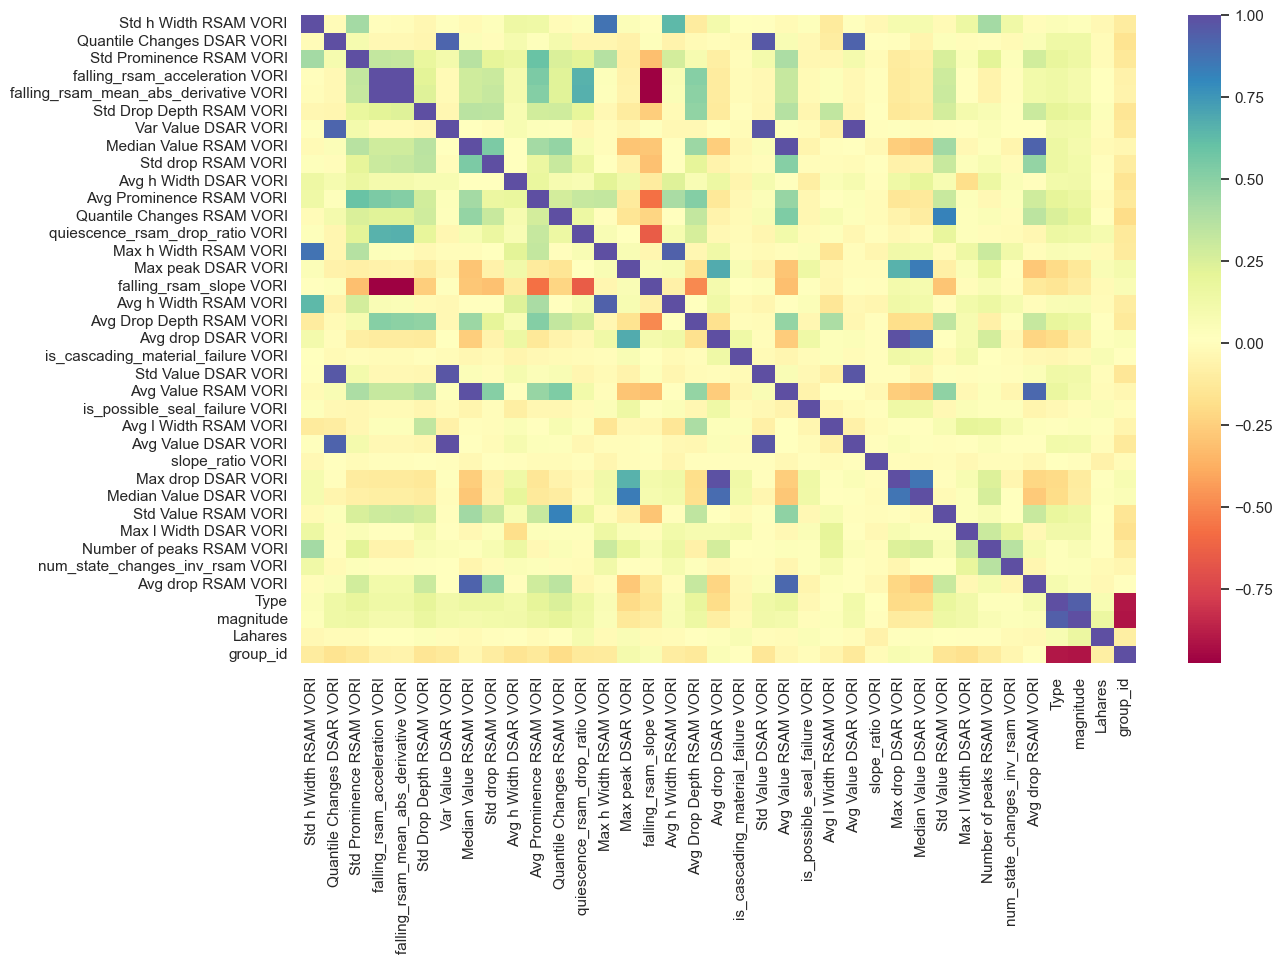

----------------------------------------------------------------------------------------------------
Histogram(s) & Boxplot(s):



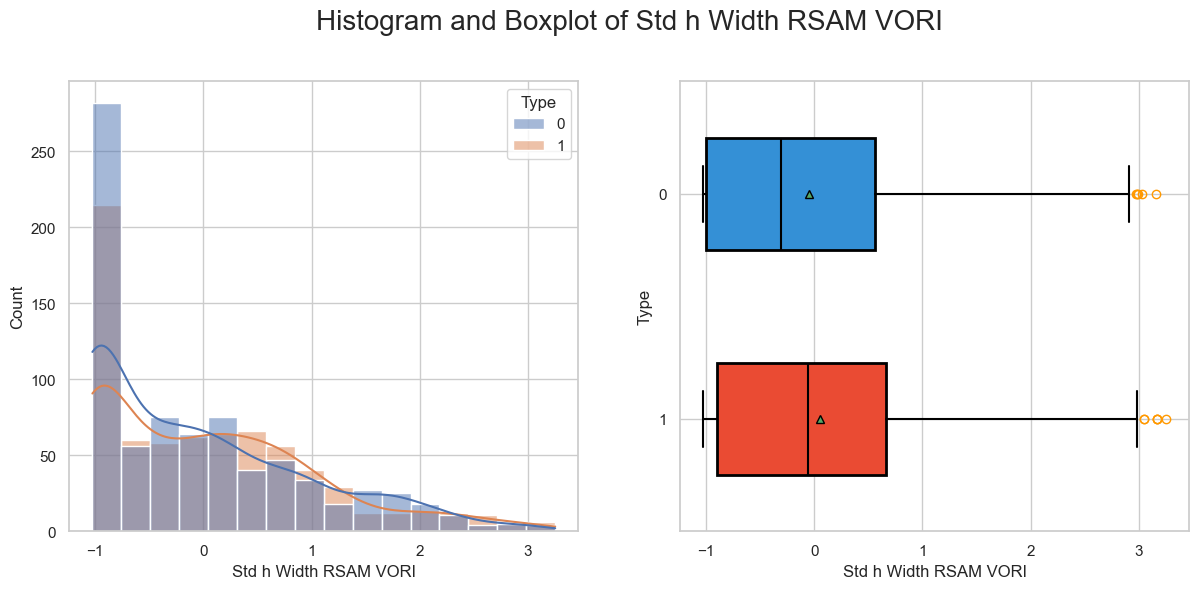

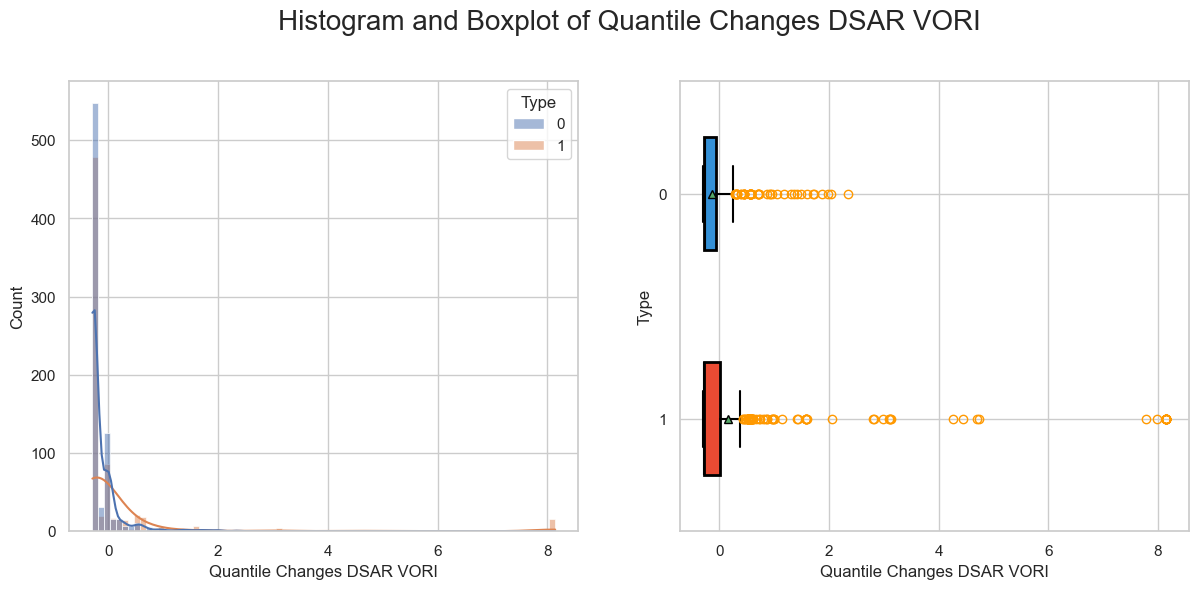

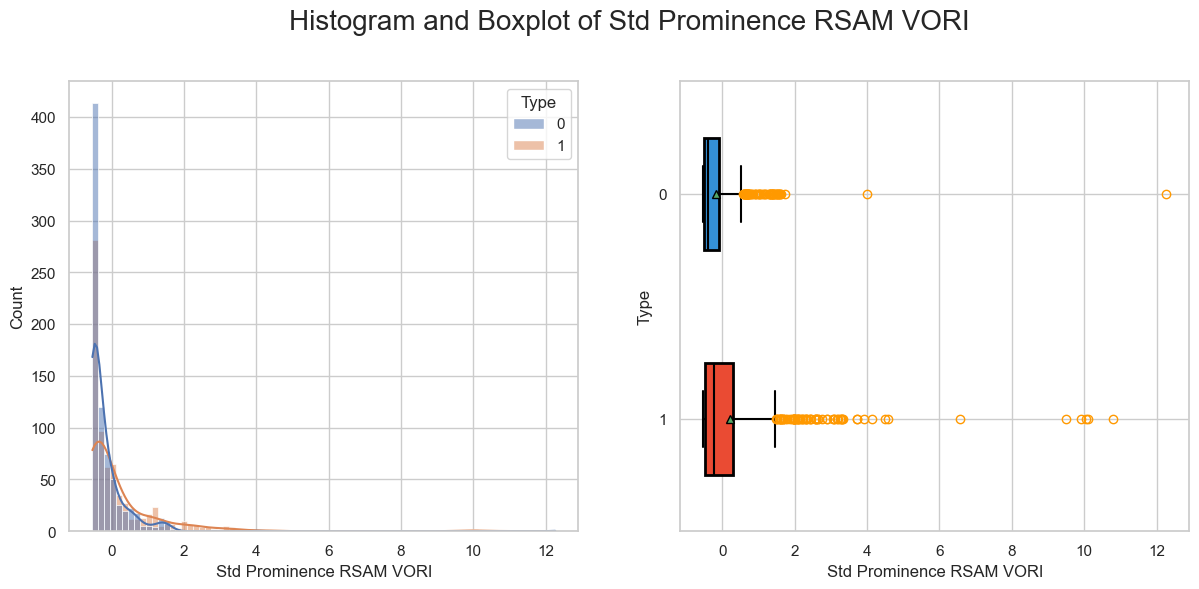

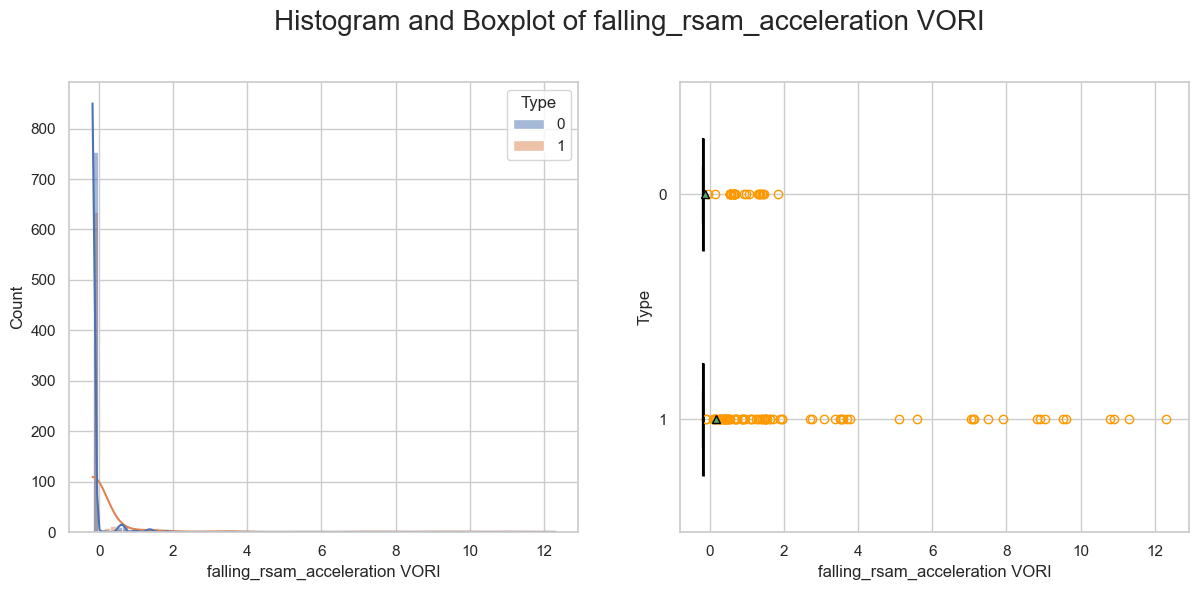

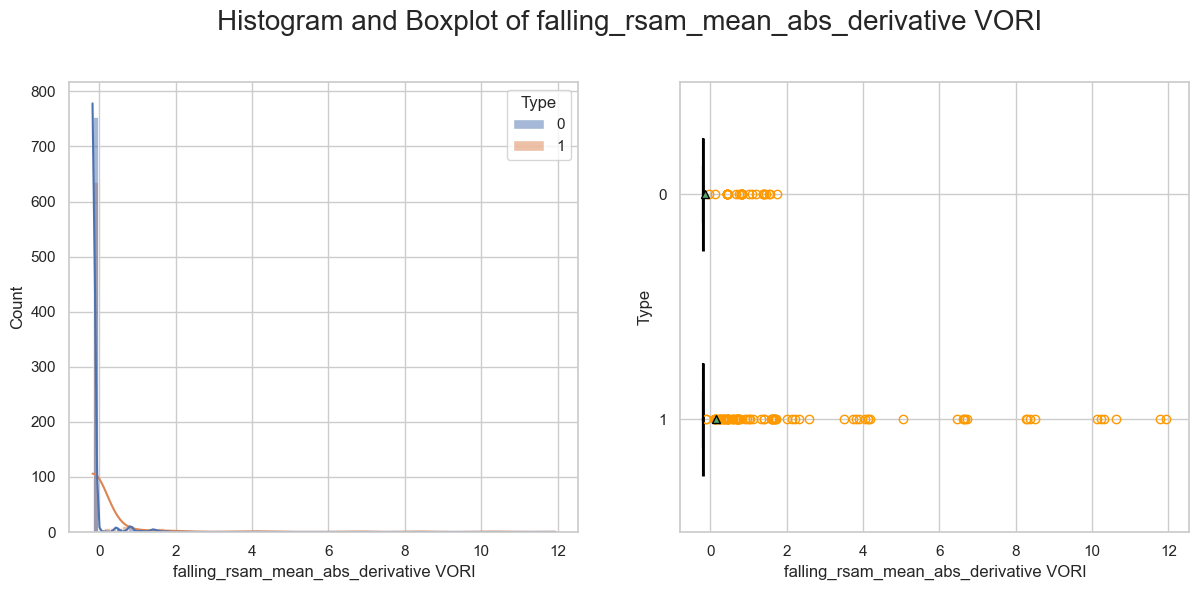

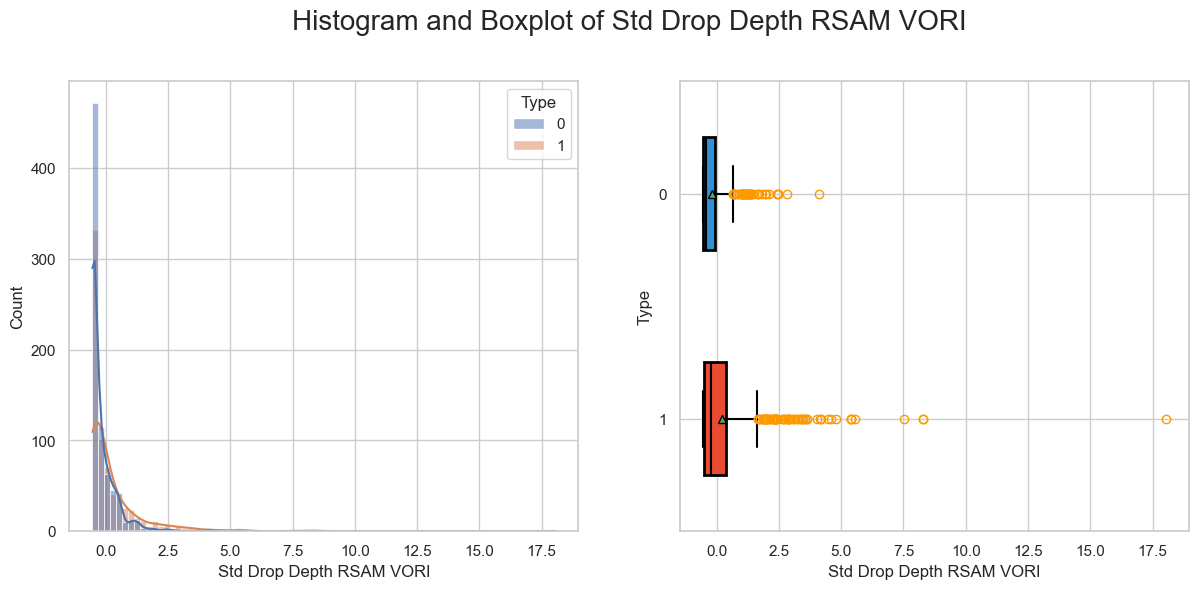

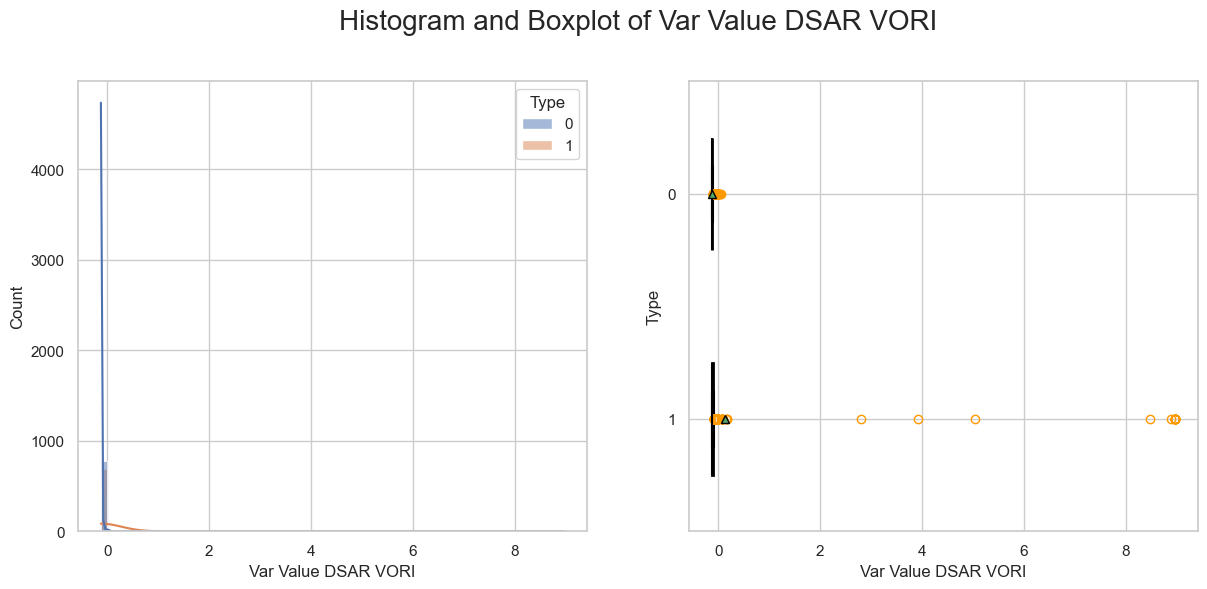

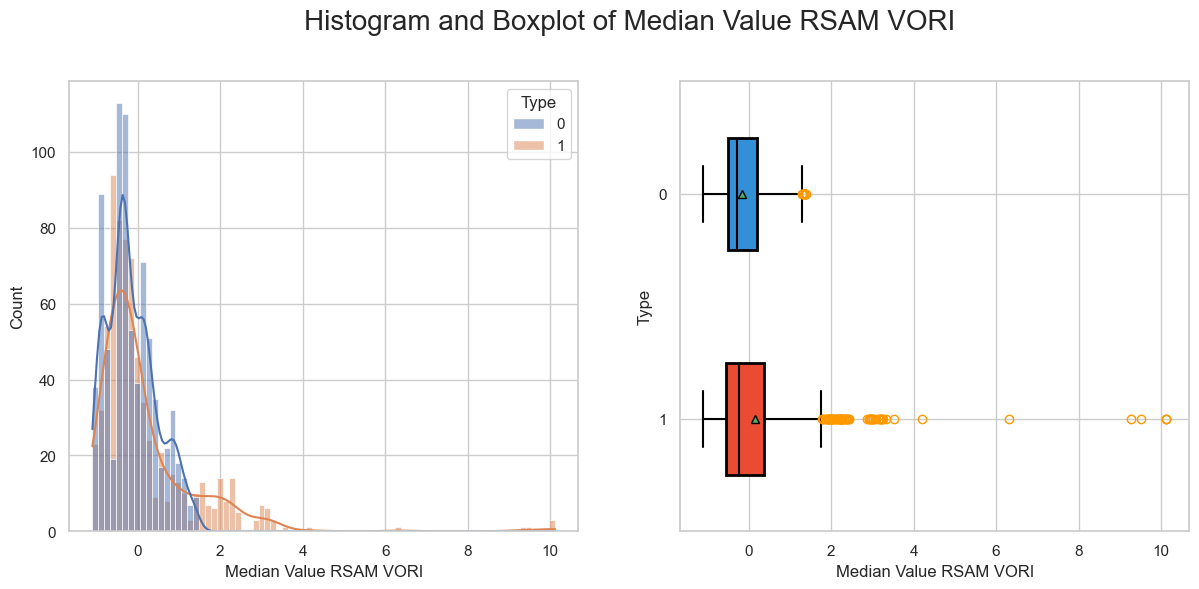

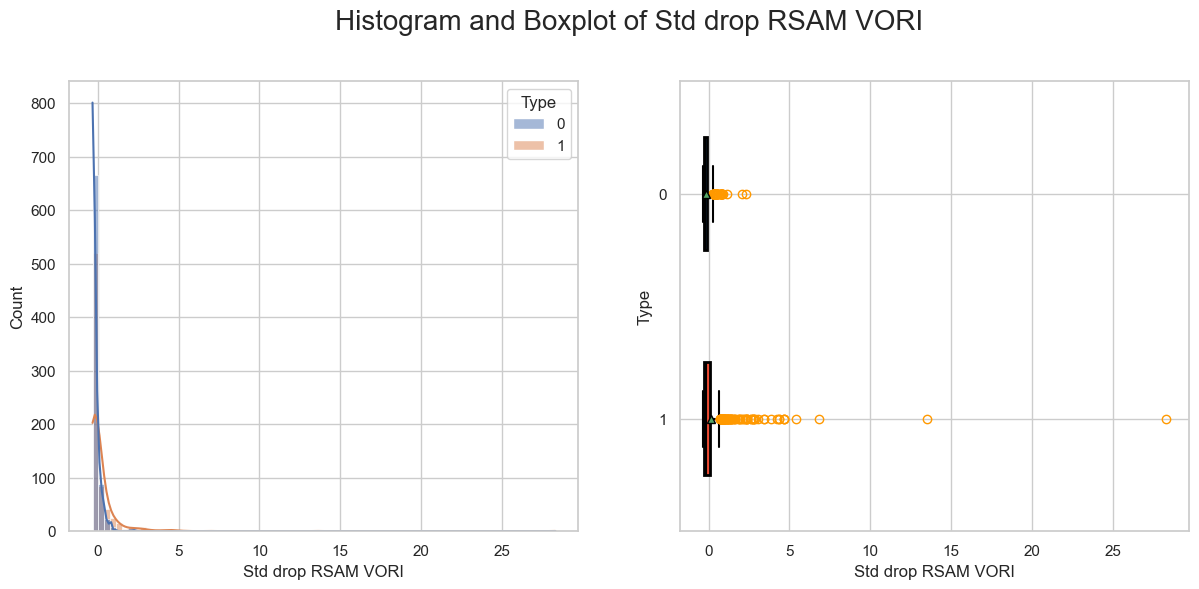

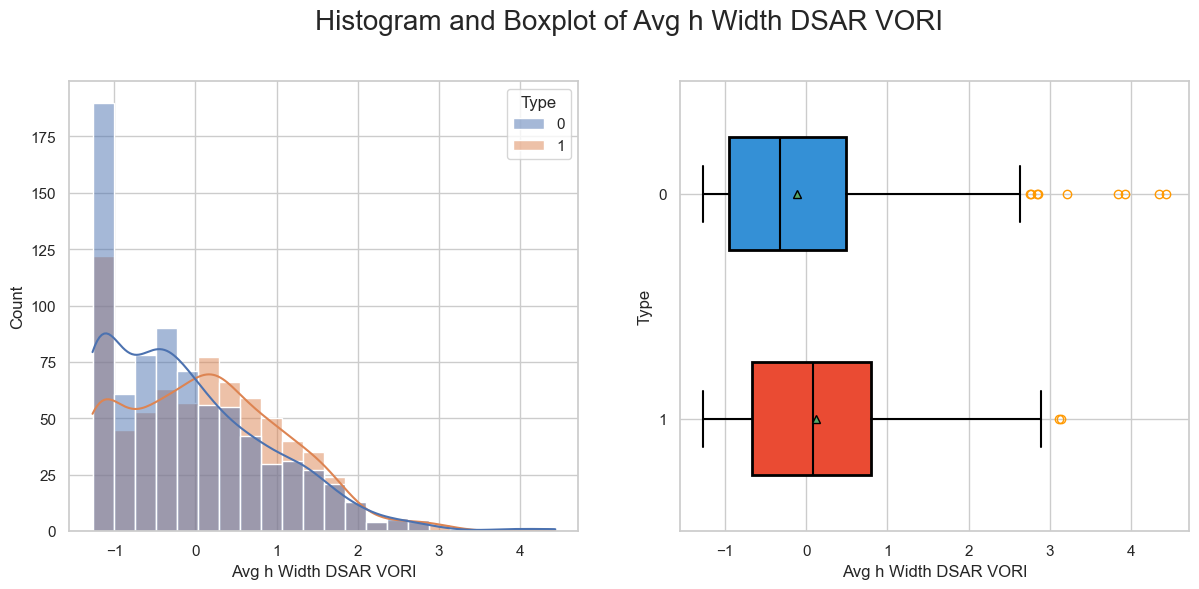

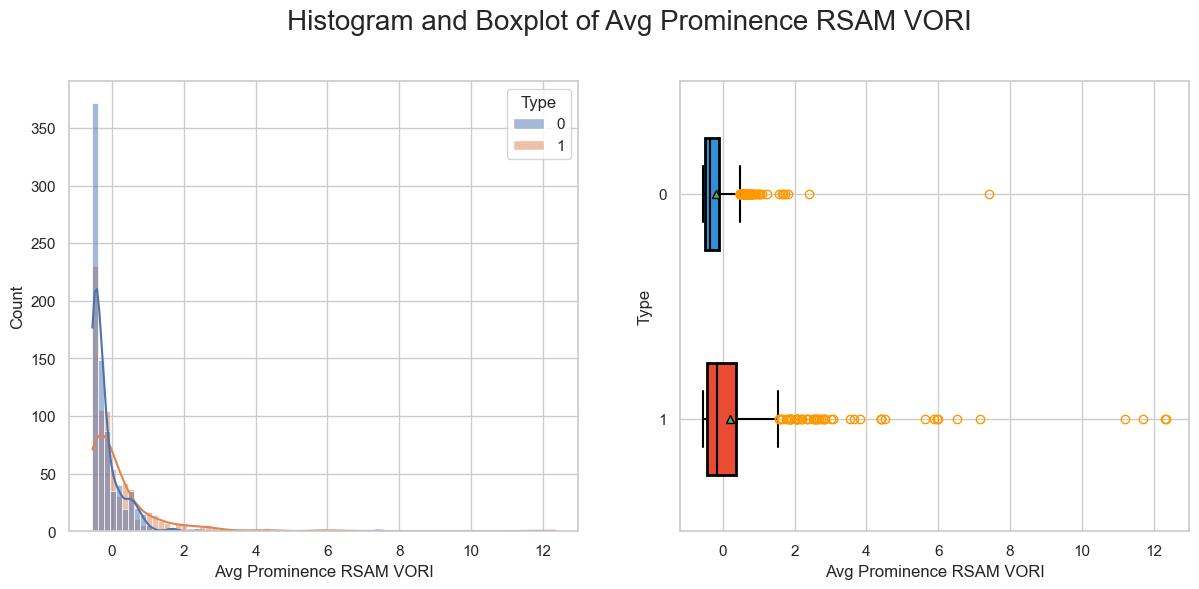

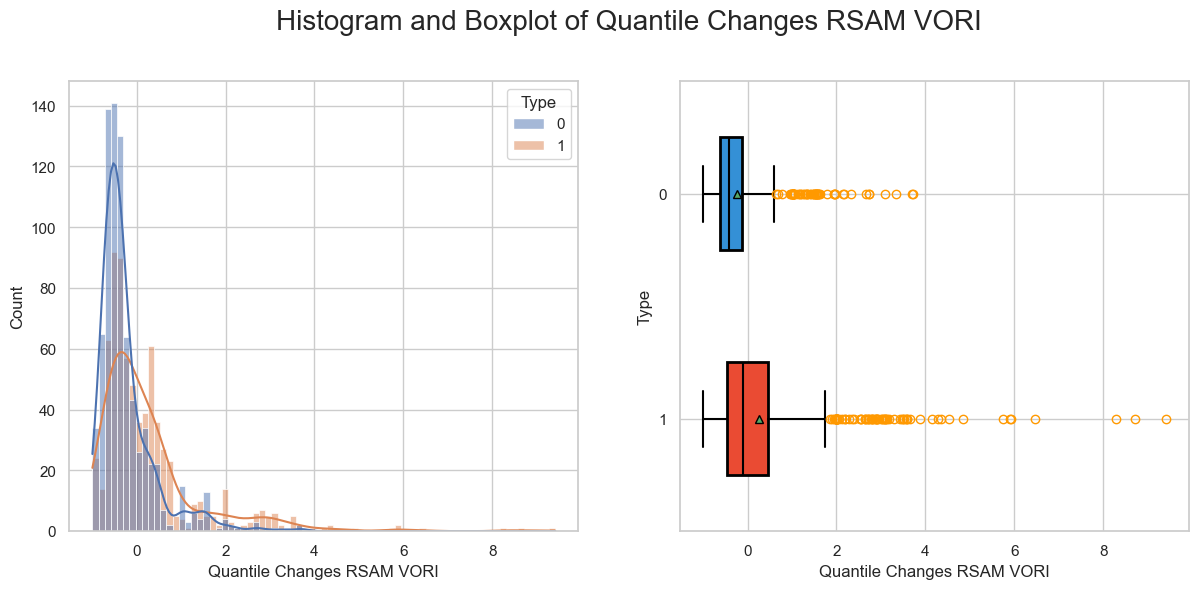

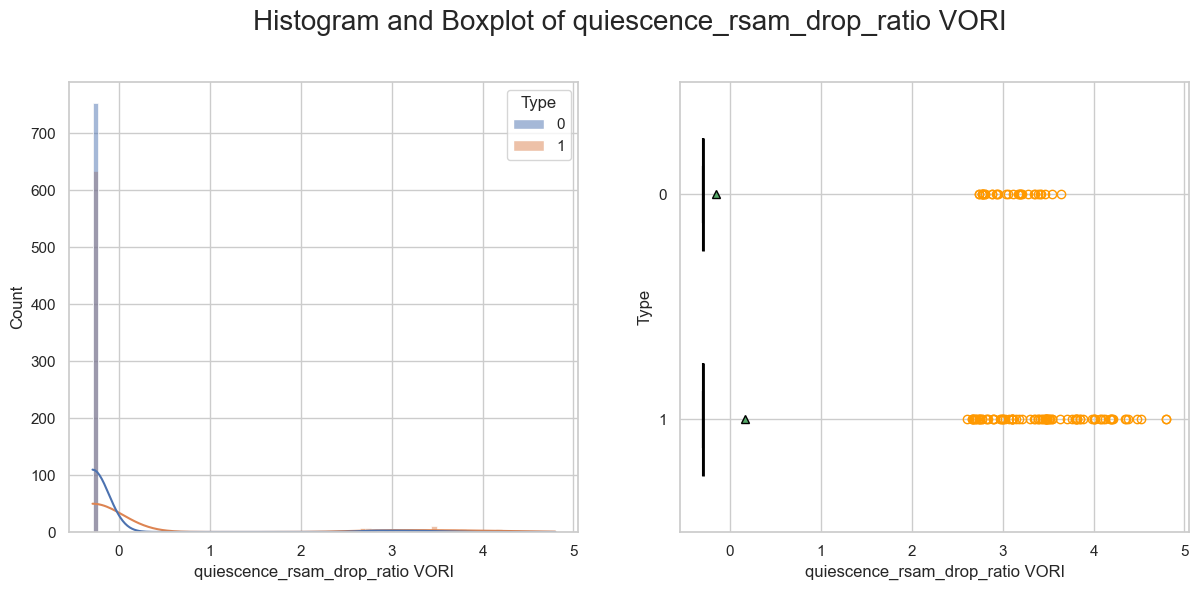

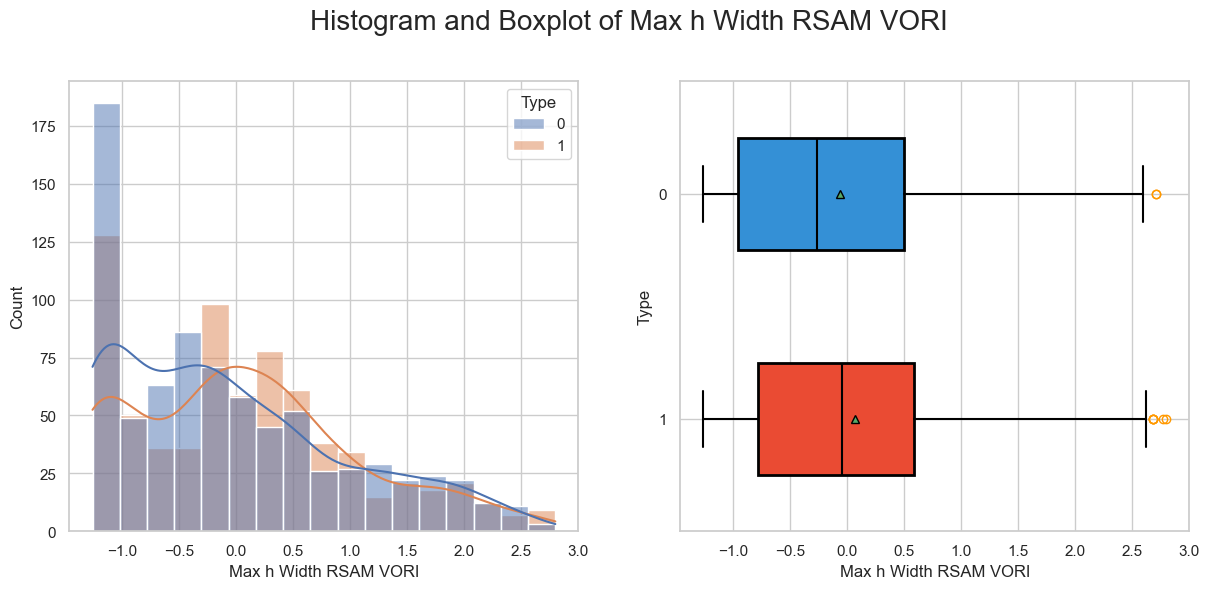

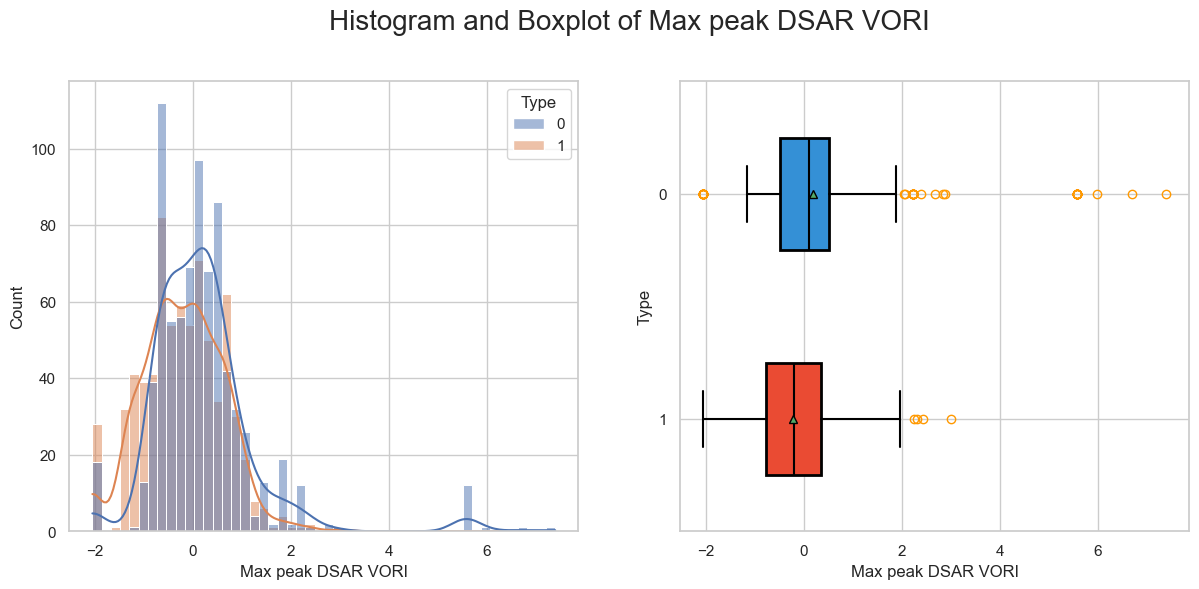

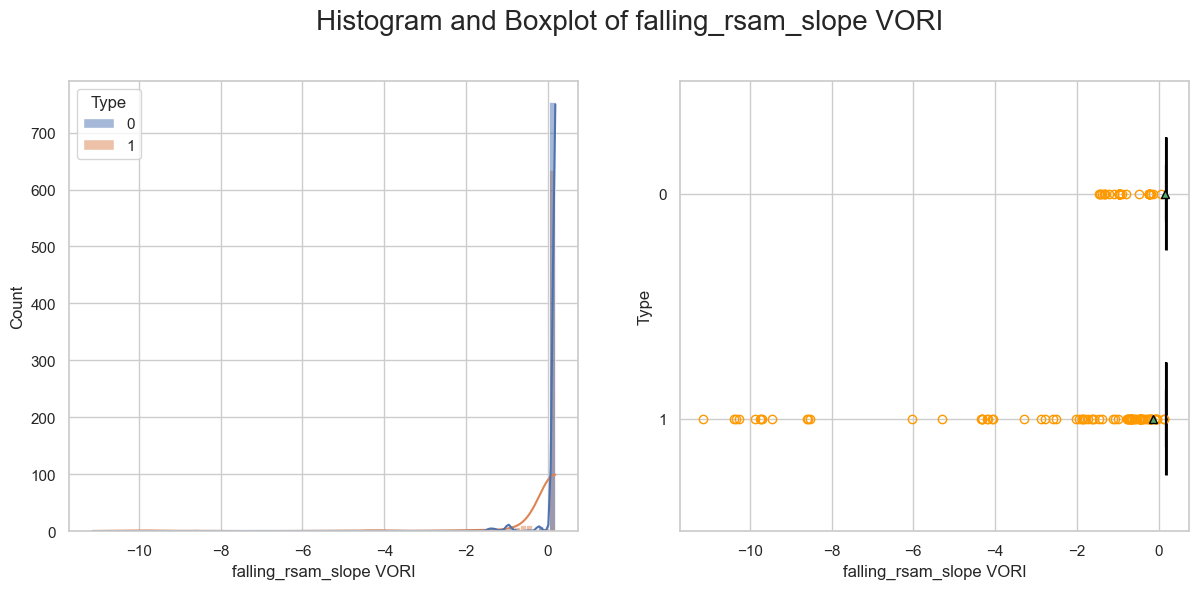

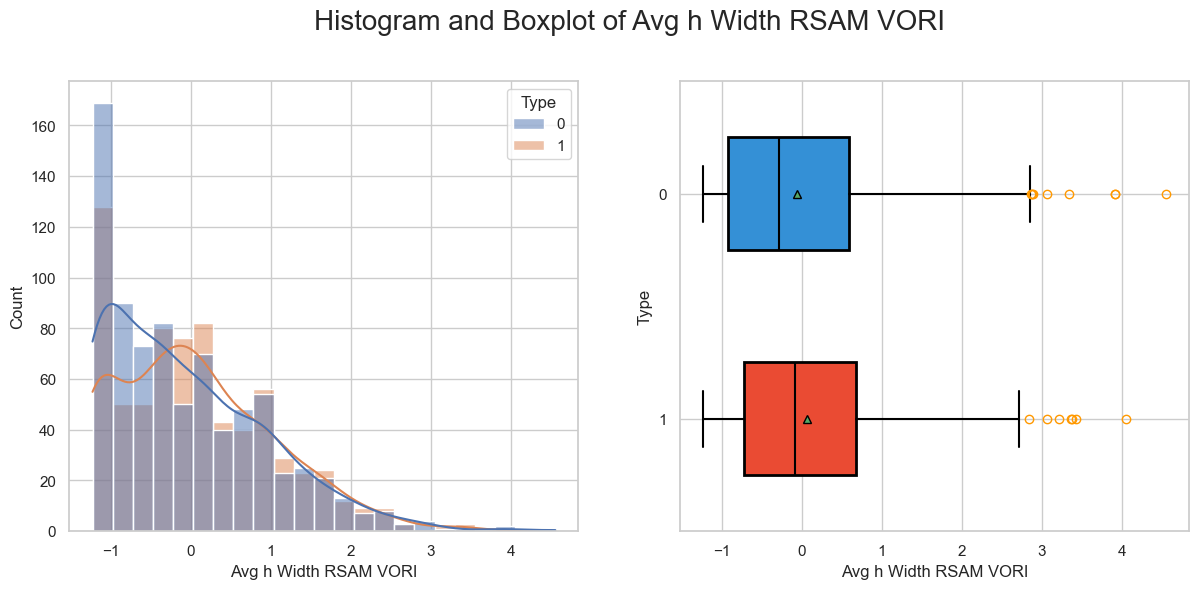

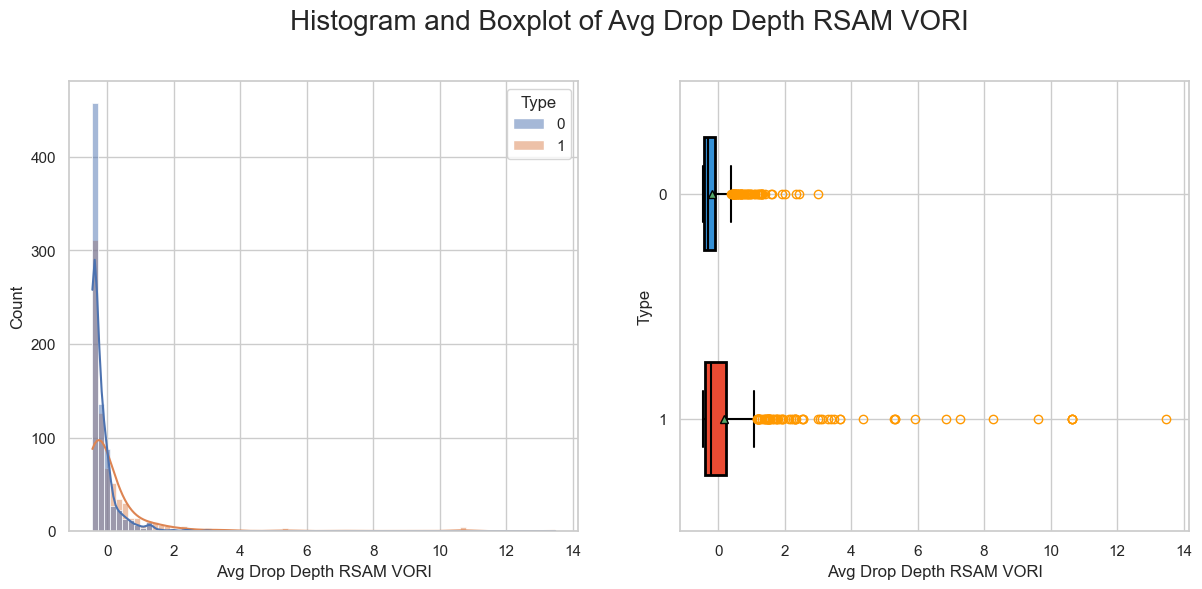

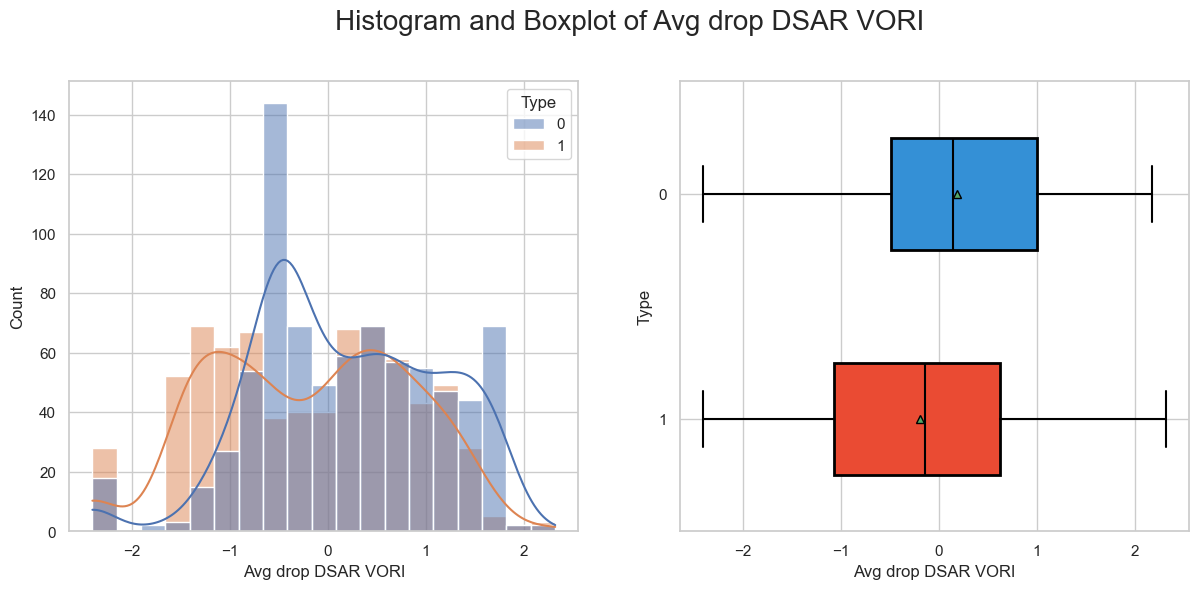

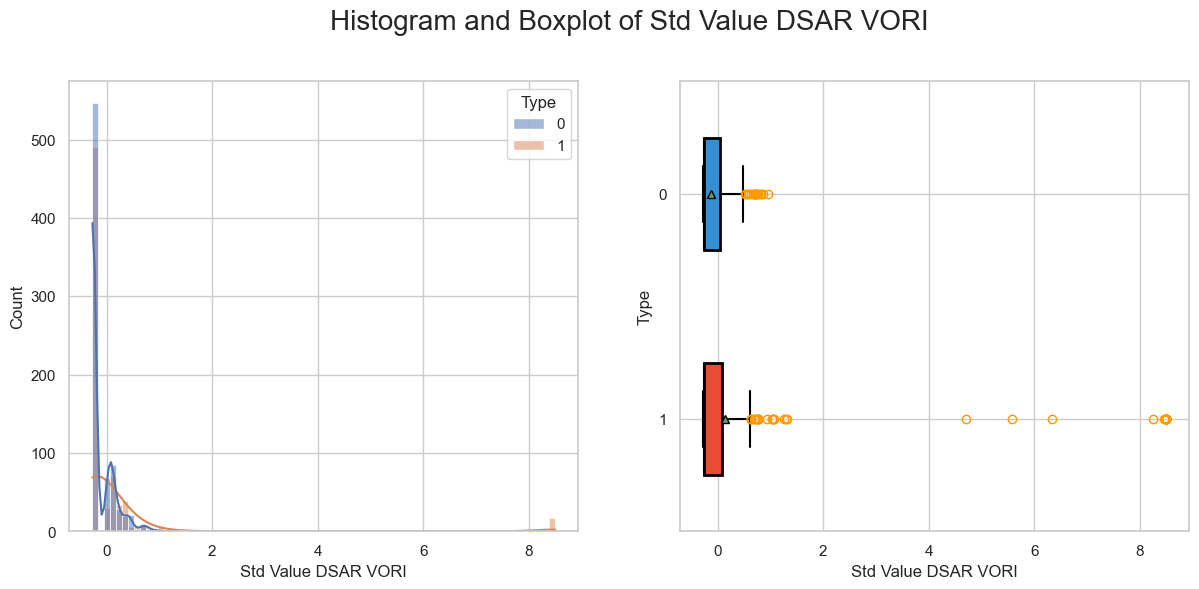

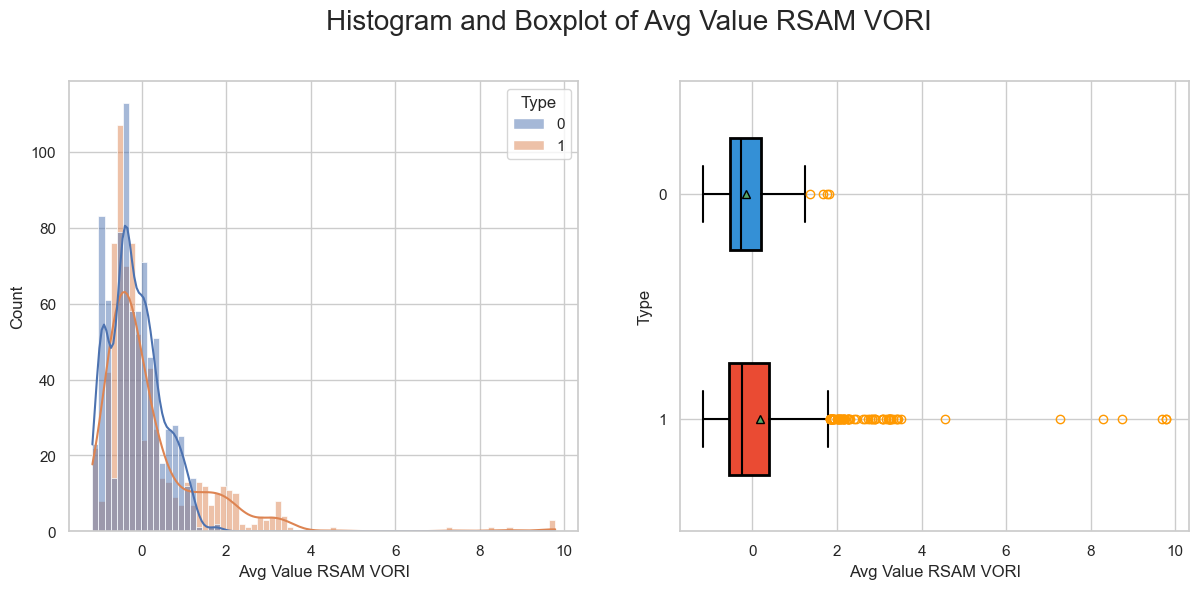

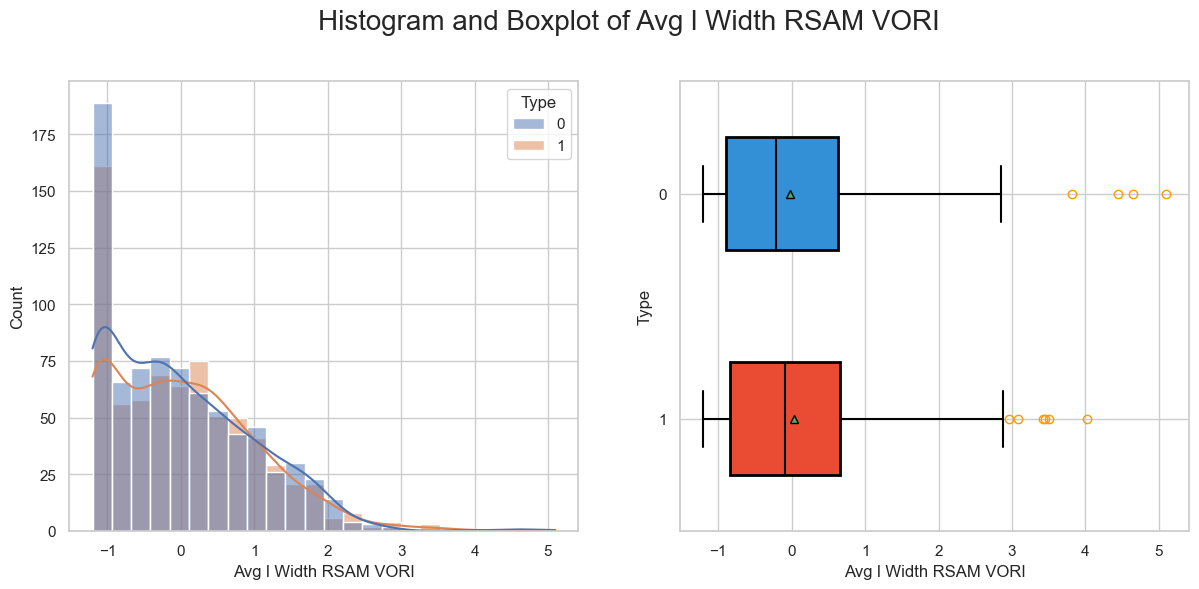

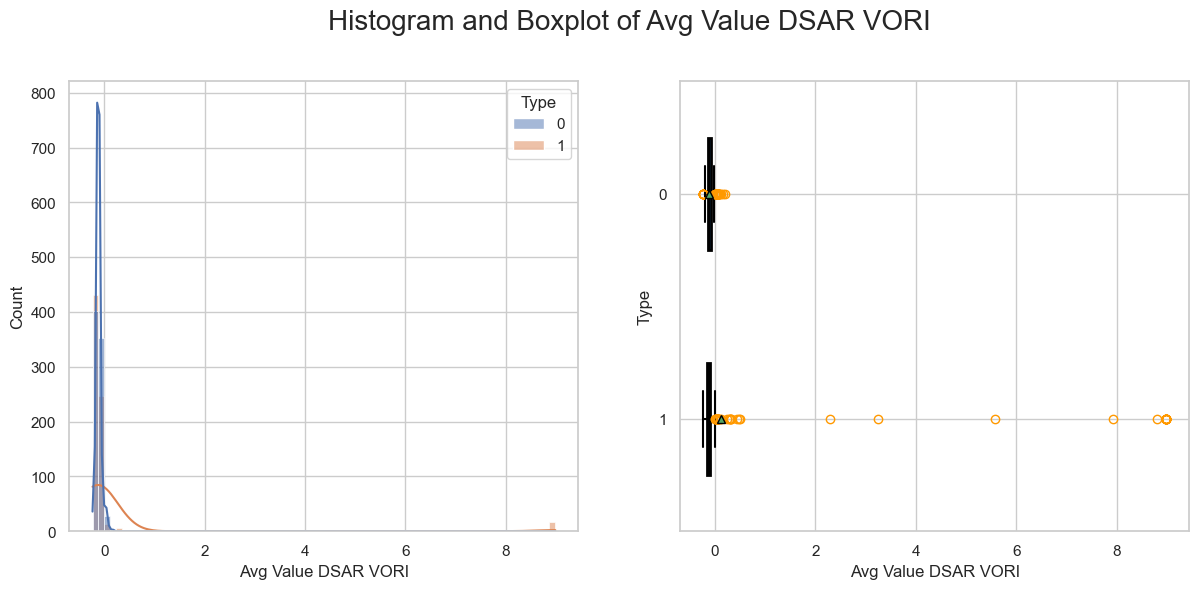

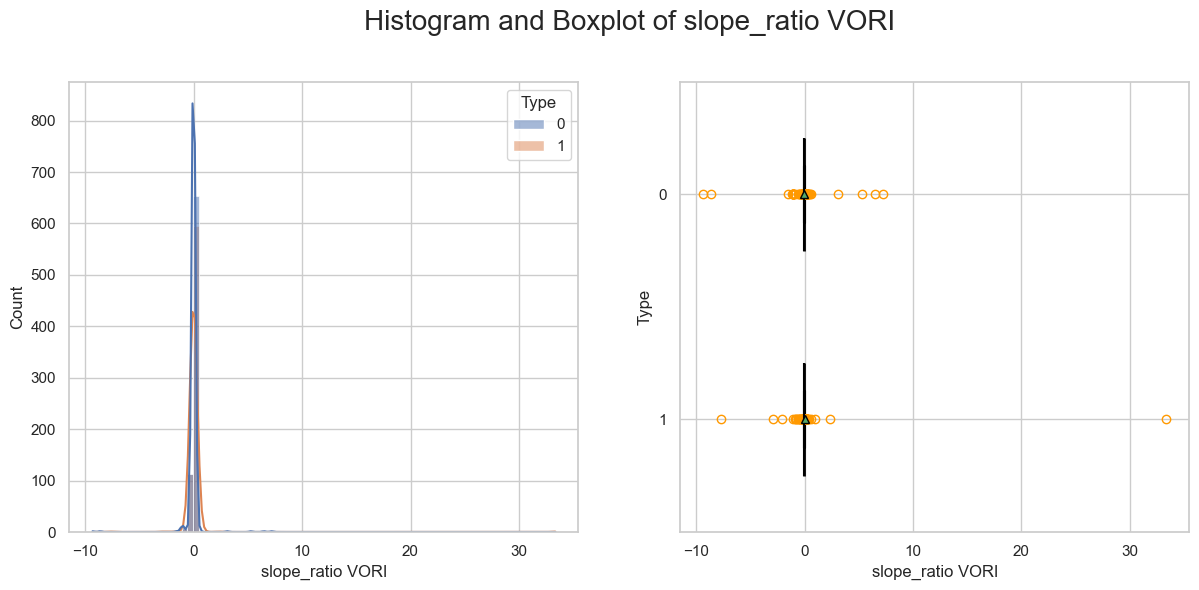

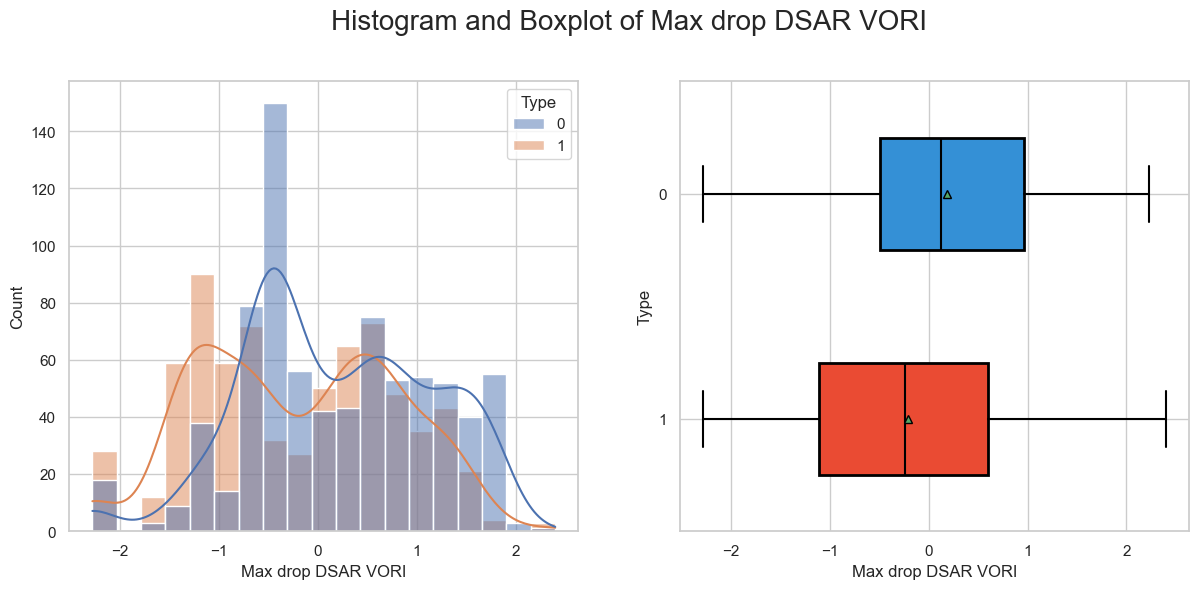

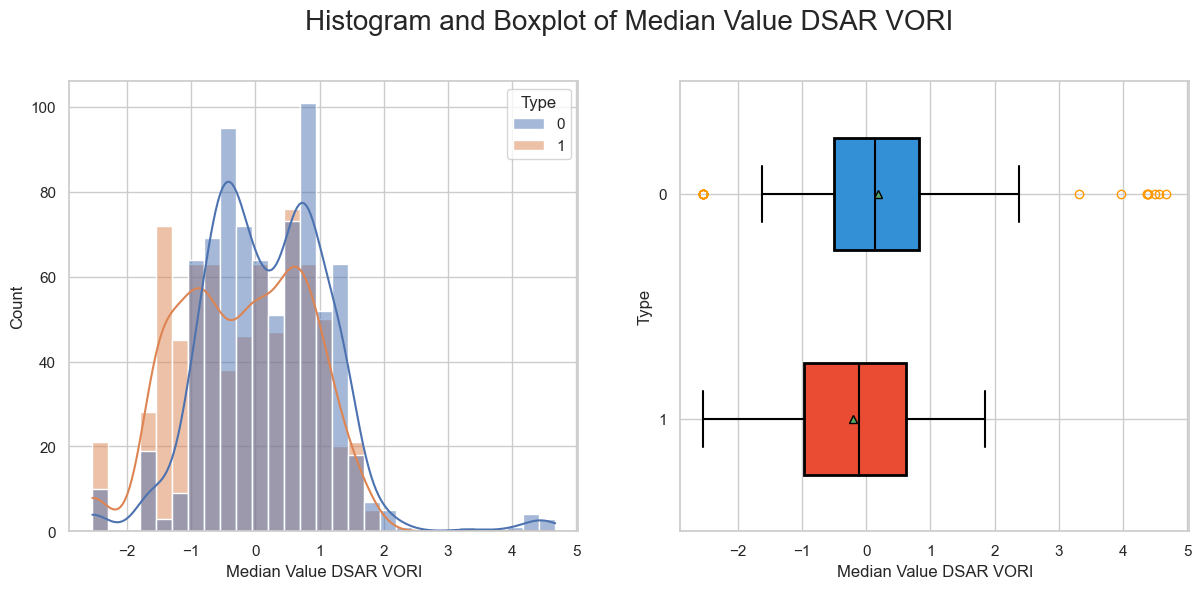

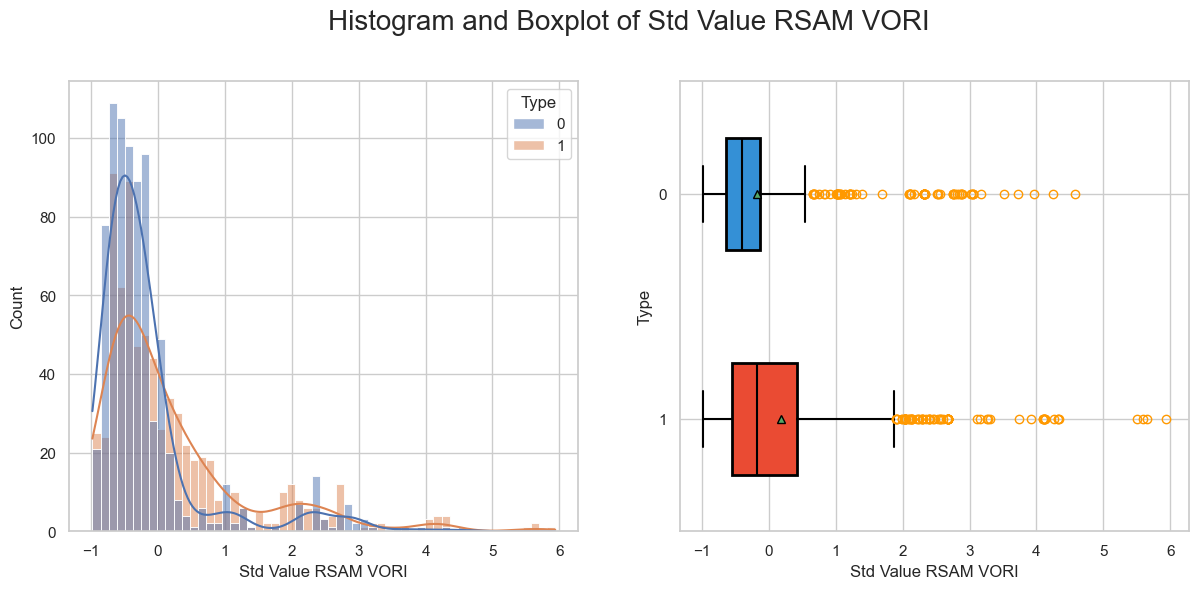

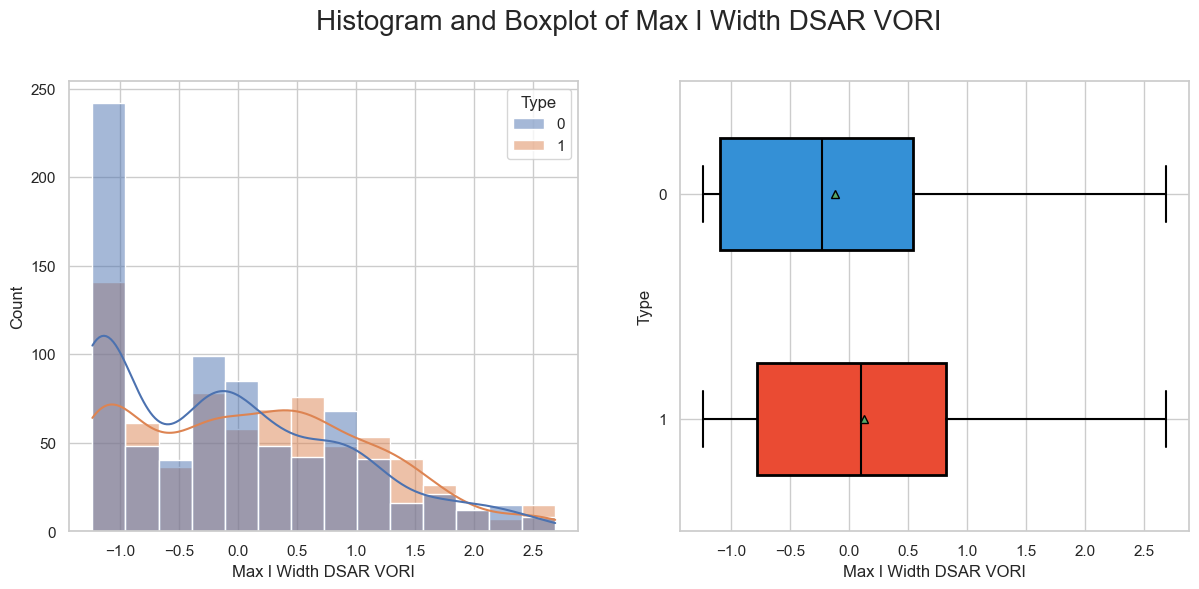

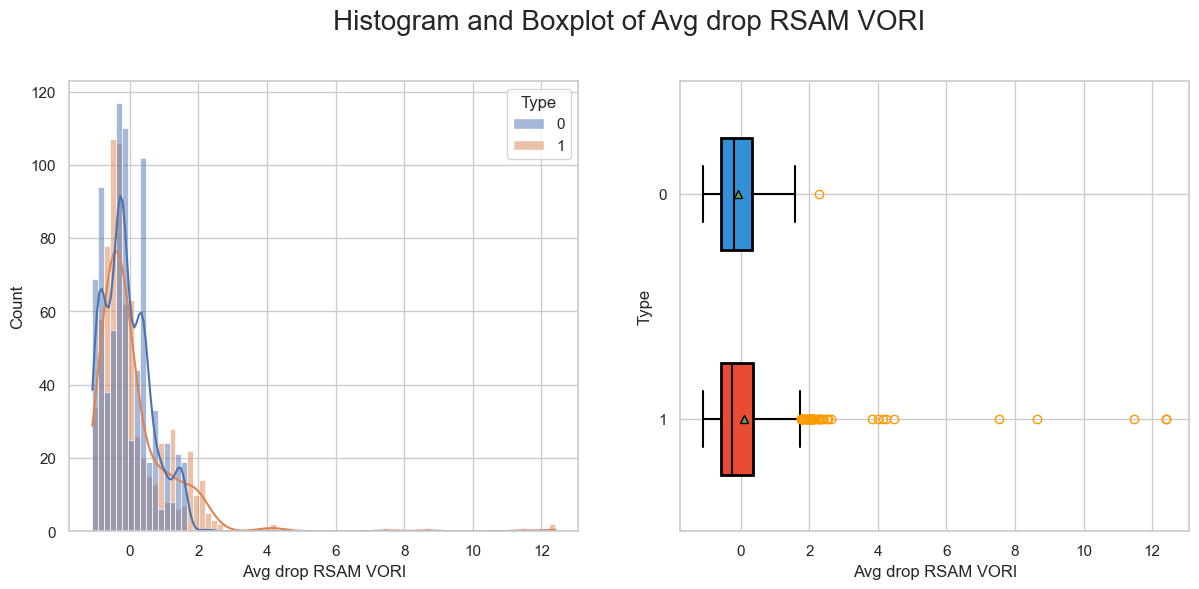

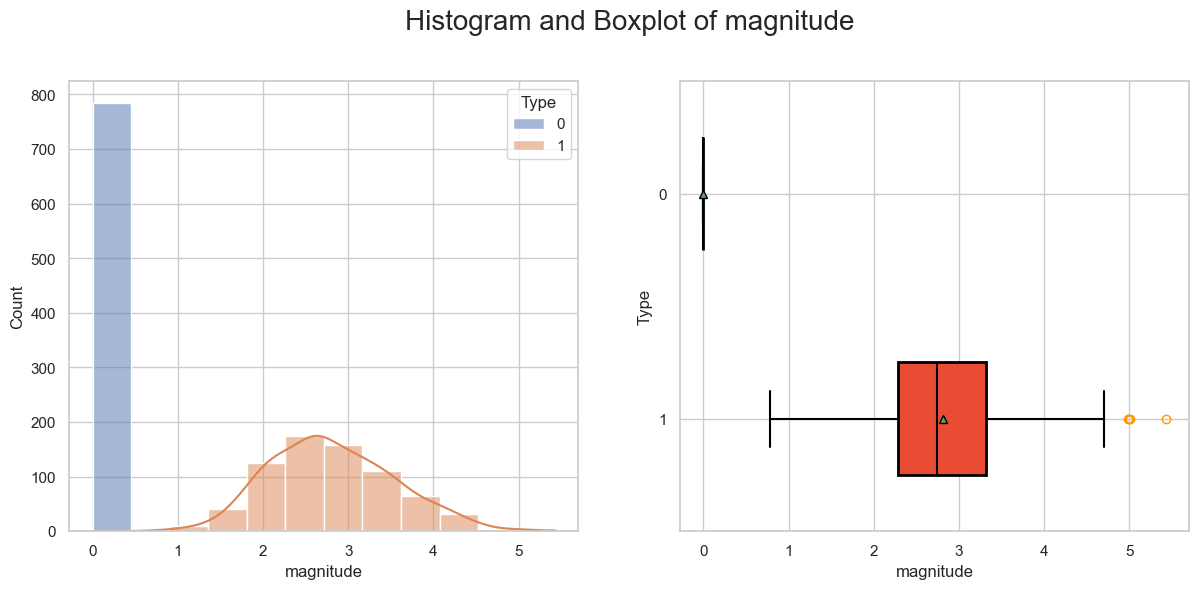

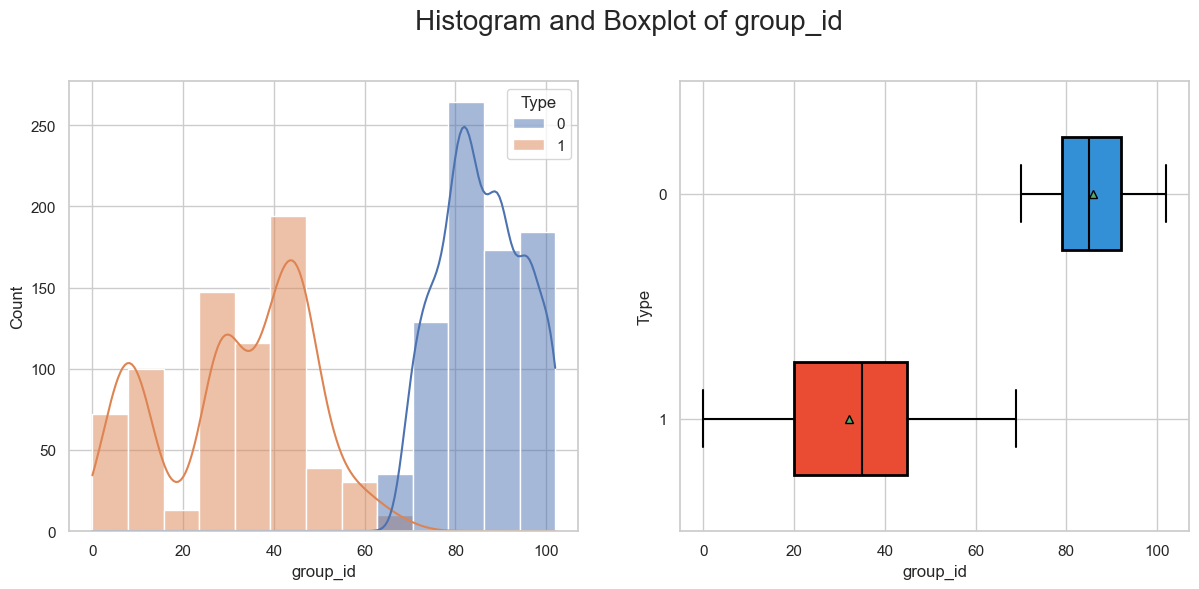

----------------------------------------------------------------------------------------------------
Countplot(s):



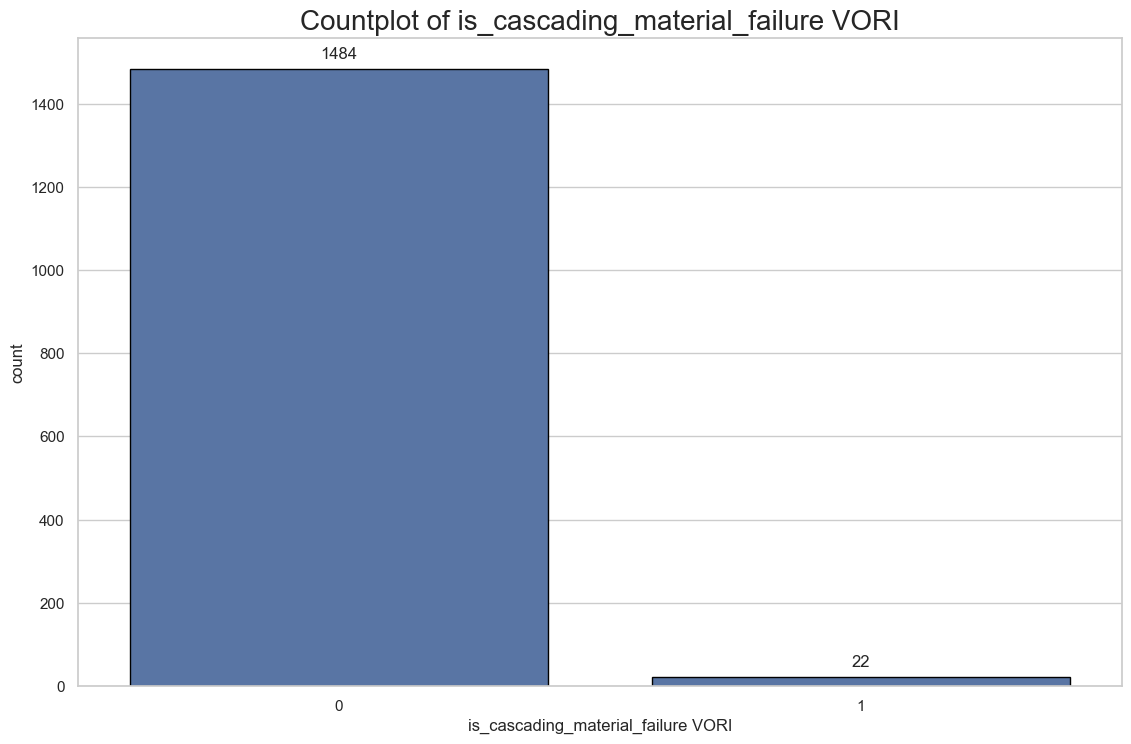

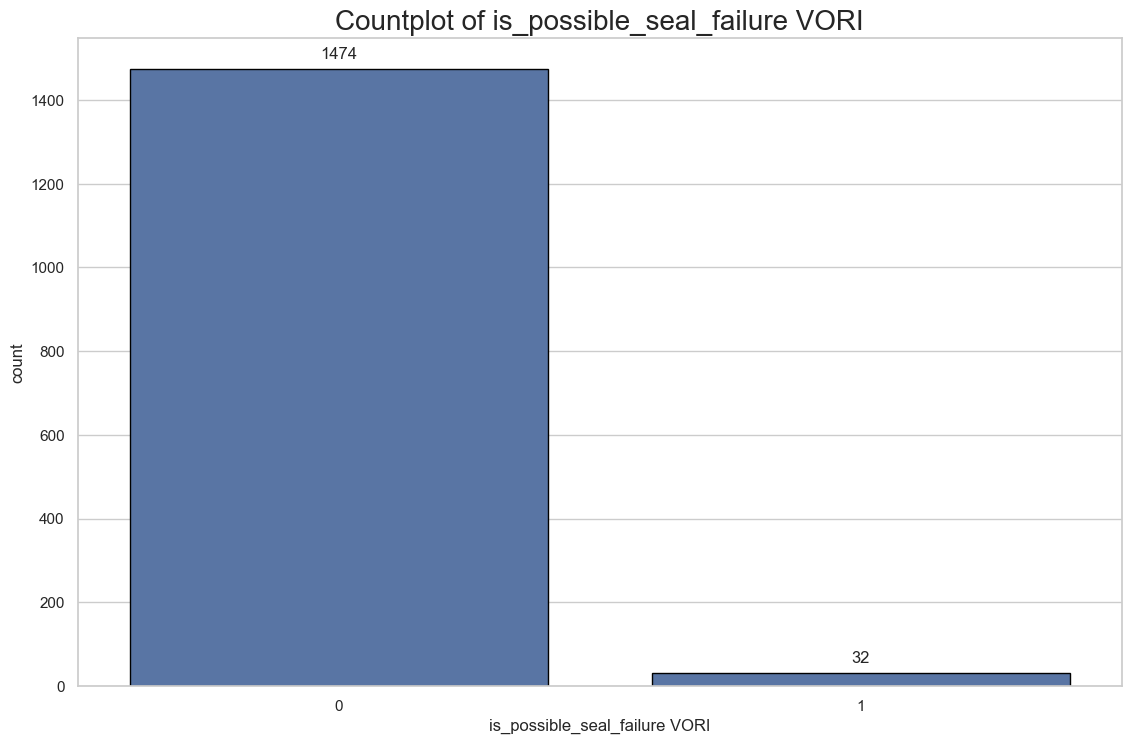

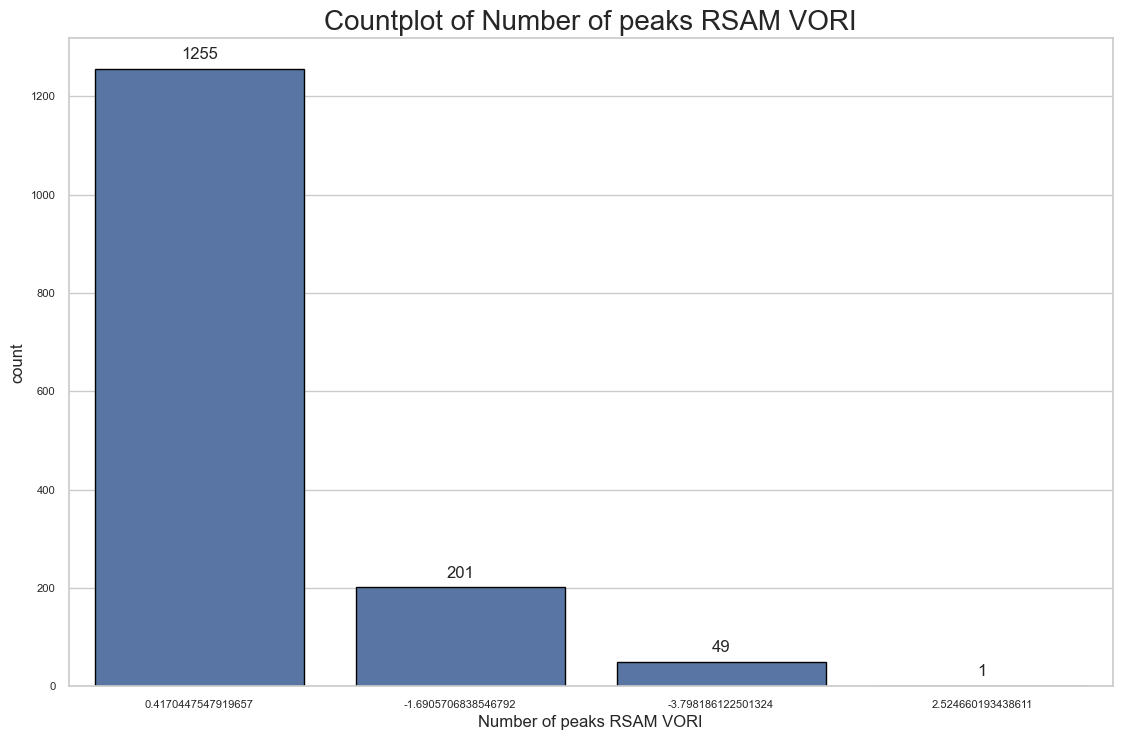

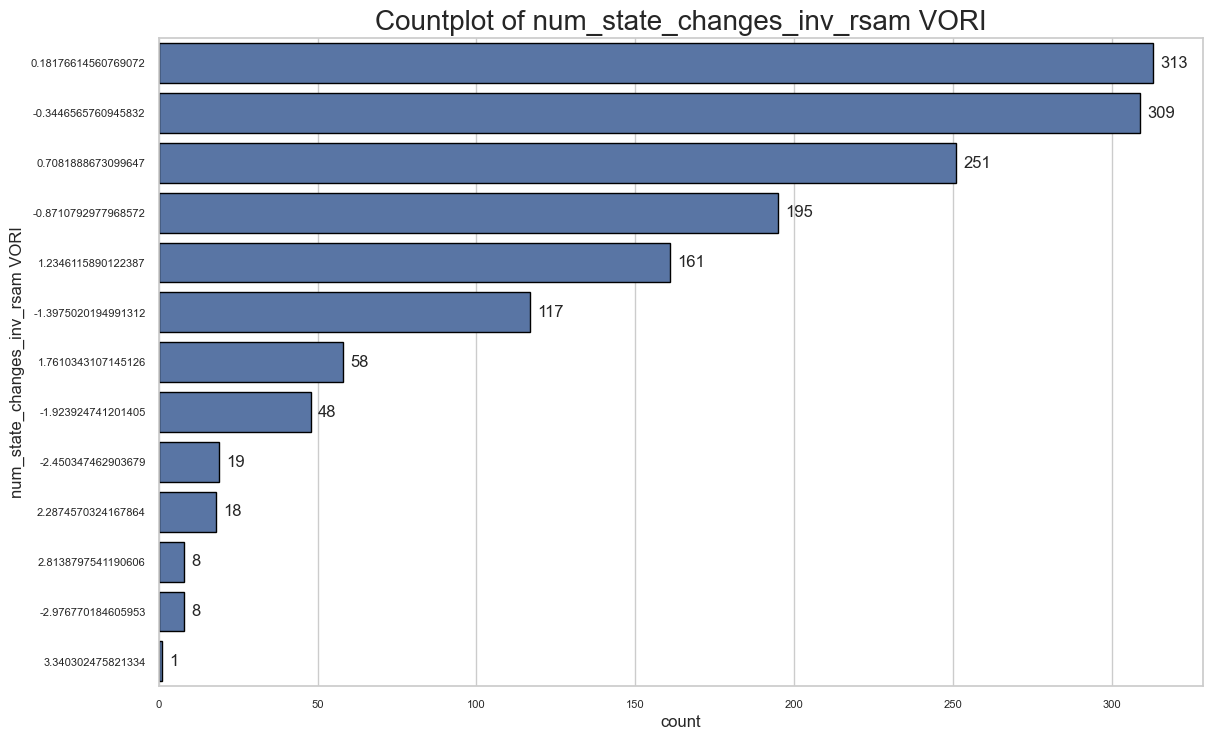

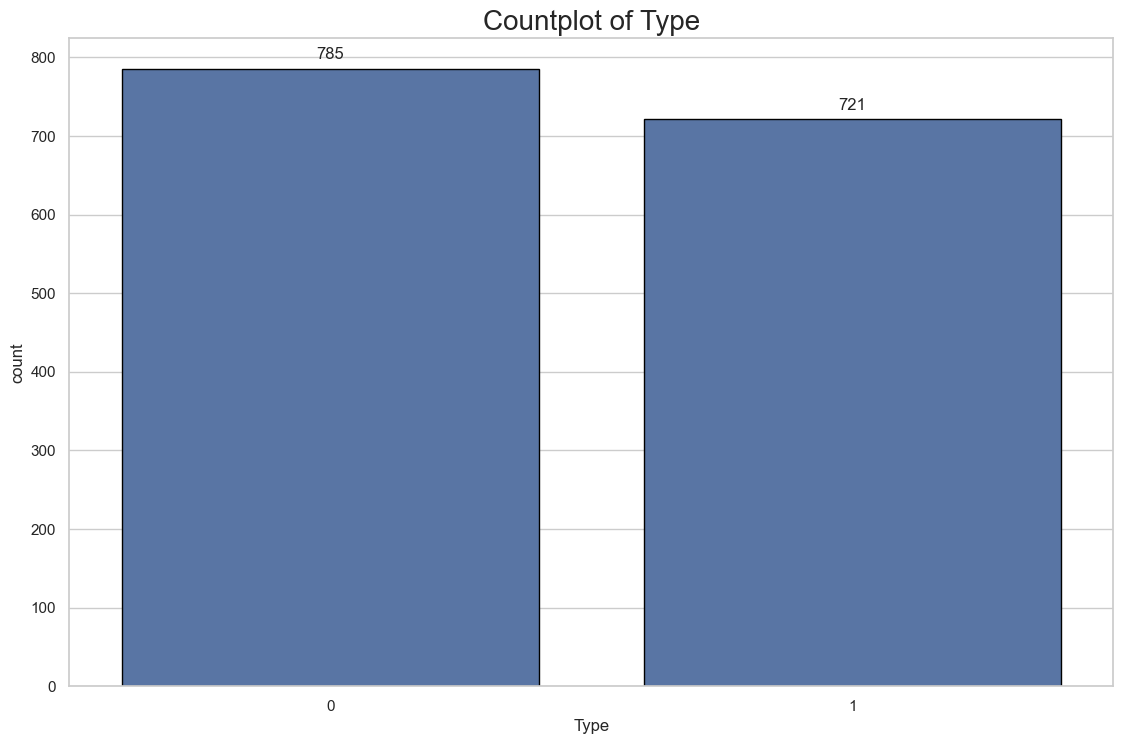

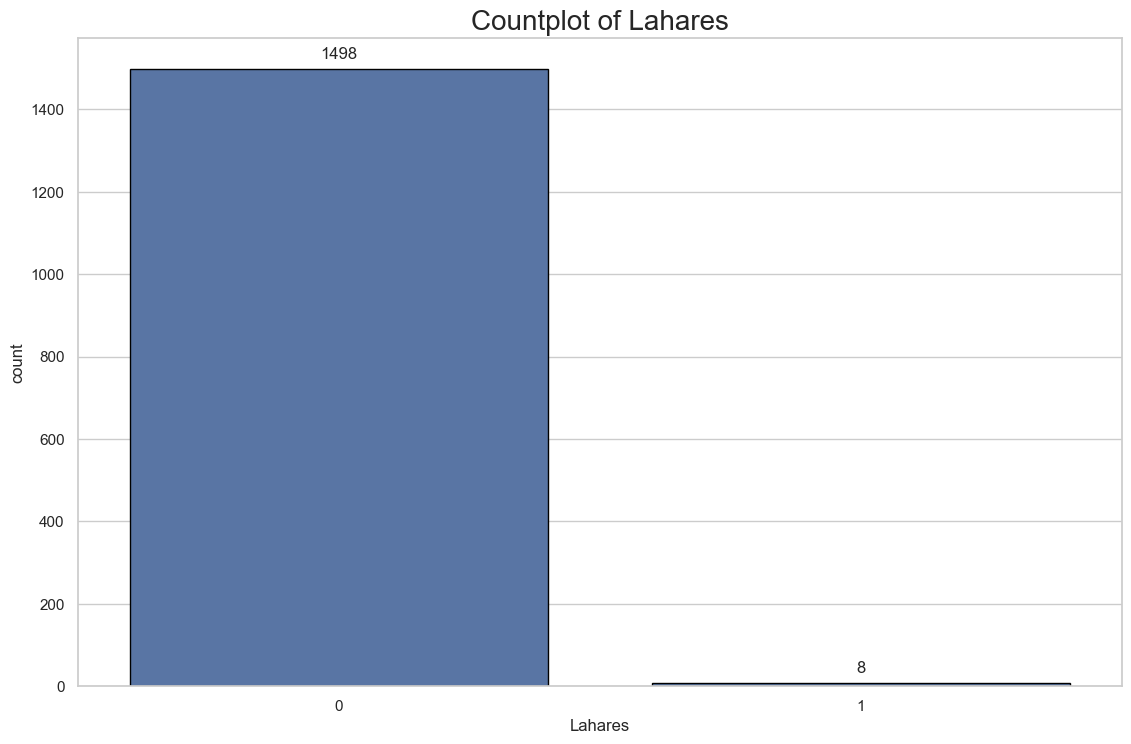

In [381]:
# Correlation

train_5_VORI = pd.concat([x_train_5_VORI[key], y_train_5_VORI[key]], axis=1)
train_5_VRBA = pd.concat([x_train_5_VRBA[key], y_train_5_VRBA[key]], axis=1)

fast_eda(train_5_VORI[list(set(VORI_features)-set(no_variance_cols))[:33]+ target_columns], target= 'Type')


In [ ]:
def get_top_correlations(df, station_name):
  
    corr_matrix = df.corr().abs()
    
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Convertir la matrice en une liste, supprimer les valeurs vides, et trier
    sorted_corrs = upper_tri.unstack().dropna().sort_values(ascending=False)
    
    # Convertir en DataFrame pour un affichage propre
    df_corrs = pd.DataFrame(sorted_corrs).reset_index()
    df_corrs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    
    # Afficher le top 20 des plus fortes corrélations
    print(df_corrs[df_corrs['Correlation'] > 0.9])
    print("\n")
    
    return df_corrs



# Sinon, si ce sont déjà des DataFrames complets :
correlations_vori = get_top_correlations(x_train_5_VORI[key], "VORI")
correlations_vrba = get_top_correlations(x_train_5_VRBA[key], "VRBA")

--- Top Correlations for VORI ---
                            Feature 1                              Feature 2  \
0                    Delta_Max_Min_VT                                 Max_VT   
1                 Avg Value DSAR VORI                    Var Value DSAR VORI   
2              Delta_Max_Min_tornillo                           Max_tornillo   
3      falling_rsam_acceleration VORI  falling_rsam_mean_abs_derivative VORI   
4   falling_rsam_mean_derivative VORI  falling_rsam_mean_abs_derivative VORI   
5                    Delta_Max_Min_LP                                 Max_LP   
6           is_hydrothermal_seal VORI        quiescence_rsam_drop_ratio VORI   
7                  Avg peak RSAM VORI                     Max peak RSAM VORI   
8                 Avg Value RSAM VORI                 Median Value RSAM VORI   
9                  Avg peak DSAR VORI                     Max peak DSAR VORI   
10  falling_rsam_mean_derivative VORI         falling_rsam_acceleration VORI   
11    

### Model

#### Random Forest Classifier optimization

In [206]:
# The Recall is prioritize to detect the maximum number of eruptions
f2_scorer = make_scorer(fbeta_score, beta=2)

# Define the hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 500],             
    'max_depth': [3, 5, 7, 10],                       
    'min_samples_split': [2, 5, 10, 20],                  
    'min_samples_leaf': [1, 2, 4, 8],                    
    'max_features': ['sqrt', 'log2', 0.5, 0.8],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample'] 
}

sgkf_search = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

best_models_VORI = {}
best_models_VRBA = {}

best_5days_models_VORI = {}
best_5days_models_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\nOptimizing Random Forest for test year: {key}")
    
    # VORI model optimization
    # 3 days observation window
    rf_3_VORI = RandomForestClassifier(random_state=42)
    random_search_VORI = RandomizedSearchCV(
        estimator=rf_3_VORI,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=5,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    random_search_VORI.fit(x_train_VORI[key], y_train_VORI[key]['Type'])
    best_models_VORI[key] = random_search_VORI.best_estimator_
    print(f"Best parameters for VORI 3 days (test year {key}): {random_search_VORI.best_params_}")

    # 5 days observation window
    rf_5_VORI = RandomForestClassifier(random_state=42)
    random_search_VORI = RandomizedSearchCV(
        estimator=rf_5_VORI,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=sgkf_search,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    groups_train = y_train_5_VORI[key]['group_id']

    random_search_VORI.fit(x_train_5_VORI[key], y_train_5_VORI[key]['Type'], groups=groups_train)
    best_5days_models_VORI[key] = random_search_VORI.best_estimator_
    print(f"Best parameters for VORI 5 days (test year {key}): {random_search_VORI.best_params_}")

    # VRBA model optimization
    rf_3_VRBA = RandomForestClassifier(random_state=42)
    random_search_VRBA = RandomizedSearchCV(
        estimator=rf_3_VRBA,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=5,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    random_search_VRBA.fit(x_train_VRBA[key], y_train_VRBA[key]['Type'])
    best_models_VRBA[key] = random_search_VRBA.best_estimator_
    print(f"Best parameters for VRBA 3 days (test year {key}): {random_search_VRBA.best_params_}")

    rf_5_VRBA = RandomForestClassifier(random_state=42)
    random_search_VRBA = RandomizedSearchCV(
        estimator=rf_5_VRBA,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=sgkf_search,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    groups_train = y_train_5_VRBA[key]['group_id']
    random_search_VRBA.fit(x_train_5_VRBA[key], y_train_5_VRBA[key]['Type'], groups=groups_train)
    best_5days_models_VRBA[key] = random_search_VRBA.best_estimator_
    print(f"Best parameters for VRBA 5 days (test year {key}): {random_search_VRBA.best_params_}")

    


Optimizing Random Forest for test year: 2019
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 3 days (test year 2019): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2019): {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': False}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 3 days (test year 2019): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 7, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 5 days (test year 2019): {'n

In [207]:
# Show detailed evaluation reports for the best models of each station and test year, including confusion matrices, 
# classification reports, feature importance, and error analysis based on eruption magnitude.

def print_truth_table_analysis(key, y_pred_summary, station, y_true, five_days=False, return_time = False):
    print(f"\n Summary for {station} ")
    idx_both_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1)& (y_true == 1)
    idx_both_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
    idx_both_fp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)
    idx_both_fn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)


    if five_days:
        coverage = coverage_5days_val[key]
        time = time_5days_val[key]
    else:
        coverage = coverage_val[key]
        time = time_val[key]
        ## Calculate mean coverage for each group
        # Both Detected (TP)
    vori_rsam_for_both_tp = coverage.loc[idx_both_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_tp = coverage.loc[idx_both_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_both_tp = coverage.loc[idx_both_tp, 'Coverage Percentage VRBA']
        # Both Detected (TN)
    vori_rsam_for_both_tn = coverage.loc[idx_both_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_tn = coverage.loc[idx_both_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_both_tn = coverage.loc[idx_both_tn, 'Coverage Percentage VRBA']
        # Both Missed (FN)  
    vori_rsam_for_both_fn = coverage.loc[idx_both_fn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_fn = coverage.loc[idx_both_fn, 'Coverage Percentage VORI DSAR']
    vrba_for_both_fn = coverage.loc[idx_both_fn, 'Coverage Percentage VRBA']
        # Both False Positives (FP)
    vori_rsam_for_both_fp = coverage.loc[idx_both_fp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_fp = coverage.loc[idx_both_fp, 'Coverage Percentage VORI DSAR']
    vrba_for_both_fp = coverage.loc[idx_both_fp, 'Coverage Percentage VRBA']

        
    print(f"Both Detected (TP): {idx_both_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_tp.mean():.2f}±{vori_rsam_for_both_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_tp.mean():.2f}±{vori_dsar_for_both_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_tp.mean():.2f}±{vrba_for_both_tp.std():.2f}%")
    print(f"Both Missed (FN): {idx_both_fn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_fn.mean():.2f}±{vori_rsam_for_both_fn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_fn.mean():.2f}±{vori_dsar_for_both_fn.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_fn.mean():.2f}±{vrba_for_both_fn.std():.2f}%")
    print(f"Both False Positives (FP): {idx_both_fp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_fp.mean():.2f}±{vori_rsam_for_both_fp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_fp.mean():.2f}±{vori_dsar_for_both_fp.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_fp.mean():.2f}±{vrba_for_both_fp.std():.2f}%")
    print(f"Both True Negatives (TN): {idx_both_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_tn.mean():.2f}±{vori_rsam_for_both_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_tn.mean():.2f}±{vori_dsar_for_both_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_tn.mean():.2f}±{vrba_for_both_tn.std():.2f}%")

        
    idx_vori_only_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)
    idx_vrba_only_tp = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 1)
    idx_vrba_only_tn = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
    idx_vori_only_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)

        ## Calculate mean coverage for each group
        # VORI only detected true events (TP)
    vori_rsam_for_vori_only_tp = coverage.loc[idx_vori_only_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vori_only_tp = coverage.loc[idx_vori_only_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_vori_only_tp = coverage.loc[idx_vori_only_tp, 'Coverage Percentage VRBA']
        # VRBA only detected true events (TP)
    vori_rsam_for_vrba_only_tp = coverage.loc[idx_vrba_only_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vrba_only_tp = coverage.loc[idx_vrba_only_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_vrba_only_tp = coverage.loc[idx_vrba_only_tp, 'Coverage Percentage VRBA']
        # VORI only detected true negatives (TN)
    vori_rsam_for_vori_only_tn = coverage.loc[idx_vori_only_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vori_only_tn = coverage.loc[idx_vori_only_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_vori_only_tn = coverage.loc[idx_vori_only_tn, 'Coverage Percentage VRBA']
        # VRBA only detected true negatives (TN)
    vori_rsam_for_vrba_only_tn = coverage.loc[idx_vrba_only_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vrba_only_tn = coverage.loc[idx_vrba_only_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_vrba_only_tn = coverage.loc[idx_vrba_only_tn, 'Coverage Percentage VRBA']
    

    print(f"VORI Detected Without VRBA (TP): {idx_vori_only_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vori_only_tp.mean():.2f}+-{vori_rsam_for_vori_only_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vori_only_tp.mean():.2f}+-{vori_dsar_for_vori_only_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_vori_only_tp.mean():.2f}+-{vrba_for_vori_only_tp.std():.2f}%")
    print(f"VRBA Detected Without VORI (TP): {idx_vrba_only_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vrba_only_tp.mean():.2f}+-{vori_rsam_for_vrba_only_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vrba_only_tp.mean():.2f}+-{vori_dsar_for_vrba_only_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_vrba_only_tp.mean():.2f}+-{vrba_for_vrba_only_tp.std():.2f}%")
    print(f"VORI Detected Without VRBA (TN): {idx_vori_only_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vori_only_tn.mean():.2f}+-{vori_rsam_for_vori_only_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vori_only_tn.mean():.2f}+-{vori_dsar_for_vori_only_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_vori_only_tn.mean():.2f}+-{vrba_for_vori_only_tn.std():.2f}%")
    print(f"VRBA Detected Without VORI (TN): {idx_vrba_only_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vrba_only_tn.mean():.2f}+-{vori_rsam_for_vrba_only_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vrba_only_tn.mean():.2f}+-{vori_dsar_for_vrba_only_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_vrba_only_tn.mean():.2f}+-{vrba_for_vrba_only_tn.std():.2f}%")
        
    if return_time:
        time_both_tp = time.values[idx_both_tp]
        time_both_tn = time.values[idx_both_tn]
        time_both_fn = time.values[idx_both_fn]
        time_both_fp = time.values[idx_both_fp]
        time_vori_only_tp = time.values[idx_vori_only_tp]
        time_vrba_only_tp = time.values[idx_vrba_only_tp]
        time_vori_only_tn = time.values[idx_vori_only_tn]
        time_vrba_only_tn = time.values[idx_vrba_only_tn]
        
        time_return = {
            'both_tp': time_both_tp,
            'both_tn': time_both_tn,
            'both_fn': time_both_fn,
            'both_fp': time_both_fp,
            'vori_only_tp': time_vori_only_tp,
            'vrba_only_tp': time_vrba_only_tp,
            'vori_only_tn': time_vori_only_tn,
            'vrba_only_tn': time_vrba_only_tn
        }

        coverage_return = {
            'both_tp': vori_rsam_for_both_tp,
            'both_tn': vori_rsam_for_both_tn,
            'both_fn': vori_rsam_for_both_fn,
            'both_fp': vori_rsam_for_both_fp,
            'vori_only_tp': vori_rsam_for_vori_only_tp,
            'vrba_only_tp': vori_rsam_for_vrba_only_tp,
            'vori_only_tn': vori_rsam_for_vori_only_tn,
            'vrba_only_tn': vori_rsam_for_vrba_only_tn
        }

        return time_return, coverage_return
    


def print_report_best_model_per_year_out_of_dataset(
        best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI, 
        best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA, 
        train_test_years_splits, best_features=None, five_days=False, return_time = False
    ):

    features_classement = {}

    if return_time:
        time_analysis_results = {}
        coverage_analysis_results = {}

    
    for key in train_test_years_splits.keys():
        print(f"\n{'='*60}")
        not_tested_years = [y for y in train_test_years_splits.keys() if y != key]
        print(f" EVALUATION TRAIN Dataset {not_tested_years} without test year {key} ")

        # Group station configurations: (Name, Models, Features, X_train, X_val, y_train, y_val)
        configs = [
            ("VORI", best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI),
            ("VRBA", best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA)
        ]

        y_pred_summary = {}
        features_classement[key] = {}

        for station, models, features_dict, x_train, x_val, y_train, y_val in configs:
            print(f"\n    STATION: {station}    ")
            
            y_true = y_val[key]['Type']
            
            # Model Preparation & Predictions 
            if best_features is not None:
                sel_features = features_dict[key] 
                
                # Clone and fit on the subset to prevent data leakage
                model = clone(models[key])
                model.fit(x_train[key][sel_features], y_train[key]['Type'])
                
                y_pred = model.predict(x_val[key][sel_features])
                current_columns = sel_features
            else:
                # Use the pre-trained model directly
                model = models[key]
                y_pred = model.predict(x_val[key])
                current_columns = x_val[key].columns

            y_pred_summary[station] = y_pred

            # Basic Metrics
            print("\n Confusion Matrix ")
            print(confusion_matrix(y_true, y_pred))
            
            print("\n Classification Report ")
            print(classification_report(y_true, y_pred, zero_division=0))
            
            # Feature Importance
            print(f"\n Top Features ({station}) ")
            # Map importances to the active feature set
            importances = pd.Series(model.feature_importances_, index=current_columns)
            features_classement[key][station] = importances.sort_values(ascending=False)
            print(features_classement[key][station].head(20))

            # Error & Magnitude Analysis 
            print_error_and_magnitude_analysis(key, y_val, y_true, y_pred, five_days=five_days)
            
            print("-" * 40)
    
        ### Summary of both stations
        if return_time:
            time_analysis_results[key], coverage_analysis_results[key] = print_truth_table_analysis(key, y_pred_summary, station, y_true, five_days=five_days, return_time=return_time)
        else:
            print_truth_table_analysis(key, y_pred_summary, station, y_true, five_days=five_days)
    
    if return_time:
        return coverage_analysis_results, time_analysis_results, features_classement

def print_error_and_magnitude_analysis(key, y_val, y_true, y_pred, five_days=False):
    # Error & Magnitude Analysis
    print(f"\n Error & Magnitude Analysis ")
            
    # Identify True Positives (TP) and False Negatives (FN)
    is_event = (y_true == 1)
    idx_tp = is_event & (y_pred == 1)
    idx_fn = is_event & (y_pred == 0)


    # Extract magnitudes for missed vs detected events
    mag_tp = y_val[key].loc[idx_tp, 'magnitude']
    mag_fn = y_val[key].loc[idx_fn, 'magnitude']

    print(f"Mean Magnitude (Detected - TP): {mag_tp.mean():.2f} ± {mag_tp.std():.2f}")
    print(f"Mean Magnitude (Missed - FN):   {mag_fn.mean():.2f} ± {mag_fn.std():.2f}")

    if mag_fn.mean() < mag_tp.mean():
        print("High magnitude events were more detected")
    else:
        print("Low magnitude events were more detected")

    
    # Isolate Lahar events
    is_lahars = (y_val[key]['Lahares'] == 1)
    idx_tp_lahars = idx_tp & is_lahars
    idx_fn_lahars = idx_fn & is_lahars

    # Extract magnitudes and time for missed vs detected Lahar events
    mag_tp_lahars = y_val[key].loc[idx_tp_lahars, 'magnitude']
    mag_fn_lahars = y_val[key].loc[idx_fn_lahars, 'magnitude']
    if five_days:
        time = time_5days_val[key]
    else:
        time = time_val[key]
    time_tp_lahars = time.values[idx_tp_lahars]
    time_fn_lahars = time.values[idx_fn_lahars]
    
    print(f"Detected Lahars (TP): {idx_tp_lahars.sum()} | Missed Lahars (FN): {idx_fn_lahars.sum()}")
    if idx_tp_lahars.sum() > 0:
        print(f"\n Detected Lahar Events (TP) - Magnitude and Time")
        for i,idx in enumerate(mag_tp_lahars.index):
            print(f"Detected Lahar Event - Magnitude: {y_val[key].loc[idx, 'magnitude']:.2f}, Time: {time_tp_lahars[i]}")
    if idx_fn_lahars.sum() > 0:
        print(f"\n Missed Lahar Events (FN) - Magnitude and Time")
        for i,idx in enumerate(mag_fn_lahars.index):
            print(f"Missed Lahar Event - Magnitude: {y_val[key].loc[idx, 'magnitude']:.2f}, Time: {time_fn_lahars[i]}")



In [208]:
# Result head windows for best model per year
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI, None, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, None, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features=None  # Set to None to use the full feature set for evaluation
)



 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[10  6]
 [ 4 20]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        16
           1       0.77      0.83      0.80        24

    accuracy                           0.75        40
   macro avg       0.74      0.73      0.73        40
weighted avg       0.75      0.75      0.75        40


 Top Features (VORI) 
Sum_LP                          0.048800
Quantile Changes RSAM VORI      0.037442
Mean Min Values DSAR VORI       0.034192
Quantile Changes DSAR VORI      0.033753
Max_LP                          0.030739
Std Value RSAM VORI             0.030694
slope_ratio VORI                0.028767
Max peak DSAR VORI              0.028726
Mean Min Values RSAM VORI       0.027619
Avg peak DSAR VORI              0.026173
Sum_Precipitations              0.025422
Delta_Max_Min_Precipitations  

In [209]:
# Result windows for best model per year
print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI, None, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, None, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features=None , # Set to None to use the full feature set for evaluation
    five_days=True
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 88  37]
 [  5 184]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.95      0.70      0.81       125
           1       0.83      0.97      0.90       189

    accuracy                           0.87       314
   macro avg       0.89      0.84      0.85       314
weighted avg       0.88      0.87      0.86       314


 Top Features (VORI) 
Sum_LP                          0.069925
Max_LP                          0.068467
Delta_Max_Min_LP                0.046298
Mean Min Values RSAM VORI       0.036527
Avg Value RSAM VORI             0.034691
Quantile Changes RSAM VORI      0.031282
Max peak RSAM VORI              0.029799
Last_LP                         0.028201
Max drop DSAR VORI              0.027556
Avg drop DSAR VORI              0.026853
Avg peak RSAM VORI              0.026686
Mean Min Values DSAR VORI 

Now that we have the bests models for each station, we are going to do feature selection to see if it is possible to get a better performance with less features. 

#### Wrapper Feature Selection

##### Wrapper Forward Selection

In [210]:
# Wrapper forward selection
class VolcanicFeatureForwardSelector(BaseEstimator, TransformerMixin):
    def __init__(self, beta=2, n_splits=3):
        self.selected_features_ = []  # Stores COLUMN NAMES, not indices
        self.beta = beta
        self.n_splits = n_splits

    def fit(self, X, y, best_models=None):
        # X must be a Pandas DataFrame to preserve physical variable names
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        columns = list(X.columns)
        n = len(columns)
        
        memory_score = 0
        memory_std = float('inf')

        if best_models is None:
            raise ValueError("Error: best_models must be provided for feature selection.")

        for round_i in range(n):
            # Candidates are column names that are not selected yet
            candidates = list(set(columns) - set(self.selected_features_))
            
            def analyze_feature(c):
                features_to_include = self.selected_features_ + [c]
                fold_scores = []
                
                # Temporary conversion to numpy array for faster splitting
                X_subset = X[features_to_include].values
                y_array = y.values.ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y
                
                for train_index, test_index in skf.split(X_subset, y_array):
                    X_tr, X_ts = X_subset[train_index], X_subset[test_index]
                    Y_tr, Y_ts = y_array[train_index], y_array[test_index]
                    
                    model = clone(best_models)
                    
                    model.fit(X_tr, Y_tr)
                    Y_hat_ts = model.predict(X_ts)
                    
                    # Compute the F2-score
                    score = fbeta_score(Y_ts, Y_hat_ts, beta=self.beta, zero_division=0)
                    fold_scores.append(score)
                    
                return np.mean(fold_scores), fold_scores, c

            # Run analysis in parallel
            results = Parallel(n_jobs=-1)(delayed(analyze_feature)(c) for c in candidates)
            
            # Select the candidate that MAXIMIZES F2-score (x[0])
            best_candidate_info = max(results, key=lambda x: x[0])
            cv_score, fold_scores, best_candidate = best_candidate_info
            candidate_std = np.std(fold_scores)
            
            # Stopping logic: are we starting to lose performance (F2)?
            if memory_score == 0:
                memory_score = cv_score
                memory_std = candidate_std
            else:
                # If F2-score decreases, we are likely adding noise; stop here
                if cv_score < memory_score or (cv_score == memory_score and candidate_std > memory_std):
                    print("=> The score decreased")
                    break
                else:
                    memory_score = cv_score
                    memory_std = candidate_std

            self.selected_features_.append(best_candidate)
            print(f"Round {round_i+1} | Added: {best_candidate} | CV F2-Score = {round(cv_score,4)} | Std Dev = {round(candidate_std,4)}")
            
        return self

    def transform(self, X, y=None):
        # Return a filtered DataFrame, suitable for thesis usage
        return X[self.selected_features_]

In [211]:
# (Head windows) Test the forward selection selector for both VORI and VRBA datasets
best_features_fw_VORI = {}
best_features_fw_VRBA = {}
selector_fw_VORI = {}
selector_fw_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI
    selector_fw_VORI[key] = VolcanicFeatureForwardSelector()
    selector_fw_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]['Type'], best_models=best_models_VORI[key])
    best_features_fw_VORI[key] = selector_fw_VORI[key].selected_features_
    print(f"Selected features for VORI (test year {key}): {best_features_fw_VORI[key]}")
    # VRBA
    selector_fw_VRBA[key] = VolcanicFeatureForwardSelector()
    selector_fw_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]['Type'], best_models=best_models_VRBA[key])
    best_features_fw_VRBA[key] = selector_fw_VRBA[key].selected_features_
    print(f"Selected features for VRBA (test year {key}): {best_features_fw_VRBA[key]}")

print_report_best_model_per_year_out_of_dataset(
    best_models_VORI, best_features_fw_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, best_features_fw_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='SelectFromModel'  # Set to None to use the full feature set for evaluation
)


------------------------------------------------------------
Feature selection for test year: 2019
Round 1 | Added: is_cascading_material_failure VORI | CV F2-Score = 0.8717 | Std Dev = 0.0104
=> The score decreased
Selected features for VORI (test year 2019): ['is_cascading_material_failure VORI']
Round 1 | Added: Std h Width RSAM VRBA | CV F2-Score = 0.8812 | Std Dev = 0.0008
Round 2 | Added: is_cascading_material_failure VRBA | CV F2-Score = 0.8847 | Std Dev = 0.0029
Round 3 | Added: Std Drop Depth RSAM VRBA | CV F2-Score = 0.8847 | Std Dev = 0.0029
Round 4 | Added: Std Prominence RSAM VRBA | CV F2-Score = 0.8847 | Std Dev = 0.0029
Round 5 | Added: Std h Width DSAR VRBA | CV F2-Score = 0.8847 | Std Dev = 0.0029
Round 6 | Added: Std l Width RSAM VRBA | CV F2-Score = 0.8847 | Std Dev = 0.0029
Round 7 | Added: Std drop RSAM VRBA | CV F2-Score = 0.8847 | Std Dev = 0.0029
=> The score decreased
Selected features for VRBA (test year 2019): ['Std h Width RSAM VRBA', 'is_cascading_material

In [212]:
# (Eruption Window) Test the forward selection selector for both VORI and VRBA datasets
best_features_fw_5days_VORI = {}
best_features_fw_5days_VRBA = {}
selector_fw_5days_VORI = {}
selector_fw_5days_VRBA = {} 


for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI
    selector_fw_5days_VORI[key] = VolcanicFeatureForwardSelector()
    selector_fw_5days_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]['Type'], best_models=best_models_VORI[key])
    best_features_fw_5days_VORI[key] = selector_fw_5days_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_fw_5days_VORI[key]}")
    # VRBA
    selector_fw_5days_VRBA[key] = VolcanicFeatureForwardSelector()
    selector_fw_5days_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]['Type'], best_models=best_models_VRBA[key])
    best_features_fw_5days_VRBA[key] = selector_fw_5days_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_fw_5days_VRBA[key]}")

print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI, best_features_fw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, best_features_fw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='SelectFromModel'  # Set to None to use the full feature set for evaluation
)


------------------------------------------------------------
Feature selection for test year: 2019
Round 1 | Added: is_cascading_material_failure VORI | CV F2-Score = 0.8717 | Std Dev = 0.0104
=> The score decreased


AttributeError: 'VolcanicFeatureForwardSelector' object has no attribute 'best_features_ever_'

The model became lazy by seeing that with few features, it only has to predict eruption all the time and it will get a good f2 score. Thus, it would maybe be better to look at the backward feature selection instead of the forward one. With backward feature selection, we start with all the features and we remove them one by one. We remove the feature that has the least impact on the performance of the model. We stop when we see a significant drop in the performance of the model or when we have a certain number of features left.

#### Wrapper Backward Selection

In [ ]:
# Wrapper backward elimination with tolerance-based stopping criterion
class VolcanicBackwardFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, beta=2, n_splits=3, tolerance=0.99):
        self.selected_features_ = []
        self.best_features_ever_ = [] # To store the absolute peak
        self.beta = beta
        self.n_splits = n_splits
        self.tolerance = tolerance

    def _get_score(self, X, y, model, skf):
        """Helper to compute CV score for a given subset."""
        fold_scores = []
        y_array = y.values.ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y
        
        for train_idx, test_idx in skf.split(X, y_array):
            X_tr, X_ts = X.values[train_idx], X.values[test_idx]
            y_tr, y_ts = y_array[train_idx], y_array[test_idx]
            
            m = clone(model)
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_ts)
            fold_scores.append(fbeta_score(y_ts, y_pred, beta=self.beta, zero_division=0))
        
        return np.mean(fold_scores), np.std(fold_scores)

    def fit(self, X, y, best_models=None):
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        self.selected_features_ = list(X.columns)
        print(f"Initial number of features: {len(self.selected_features_)}")
        
        # Initial evaluation
        memory_score, memory_std = self._get_score(X[self.selected_features_], y, best_models, skf)
        
        self.best_score_ever_ = memory_score
        self.best_features_ever_ = list(self.selected_features_)
        
        print(f"Initial Score (Full Set): {round(memory_score, 4)}")

        for round_i in range(len(X.columns) - 1):
            candidates = self.selected_features_
            
            def analyze_removal(c):
                subset = [f for f in self.selected_features_ if f != c]
                score_mean, score_std = self._get_score(X[subset], y, best_models, skf)
                return score_mean, score_std, c

            results = Parallel(n_jobs=-1)(delayed(analyze_removal)(c) for c in candidates)
            best_cv, best_std, to_remove = max(results, key=lambda x: x[0])

            # Stopping Criterion with tolerance
            if best_cv < (memory_score * self.tolerance):
                print(f"-> Stopping: Score drop exceeds tolerance ({best_cv:.4f} < {memory_score * self.tolerance:.4f}) ---")
                break

            # Update current state
            memory_score = best_cv
            self.selected_features_.remove(to_remove)
            
            # Keep track of the absolute best
            if best_cv > self.best_score_ever_:
                self.best_score_ever_ = best_cv
                self.best_features_ever_ = list(self.selected_features_)

                print(f"Round {round_i+1} | Removed: {to_remove} | New F2: {round(memory_score, 4)}")
            
            elif best_cv < self.best_score_ever_*0.8:
                print("Warning: Significant score drop detected.")
                break
            elif len(self.selected_features_) <= 20 :
                print("Warning: Number of features is getting low, consider stopping.")
                break
            
        print(f"Final number of features: {len(self.best_features_ever_)} | Best F2 Score: {round(self.best_score_ever_, 4)}")
        return self

    def transform(self, X):
        return X[self.best_features_ever_]

In [ ]:
# (Head Window) Test the backward elimination selector for both VORI and VRBA datasets
best_features_bckw_VORI = {}
best_features_bckw_VRBA = {}
selector_bckw_VORI = {}
selector_bckw_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI
    selector_bckw_VORI[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]['Type'], best_models=best_models_VORI[key])
    best_features_bckw_VORI[key] = selector_bckw_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_bckw_VORI[key]}")
    # VRBA
    selector_bckw_VRBA[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]['Type'], best_models=best_models_VRBA[key])
    best_features_bckw_VRBA[key] = selector_bckw_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_bckw_VRBA[key]}")



print_report_best_model_per_year_out_of_dataset(
    best_models_VORI, best_features_bckw_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, best_features_bckw_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected'  
)
    

In [ ]:
# (Eruption Window) Test the backward elimination selector for both VORI and VRBA datasets
best_features_bckw_5days_VORI = {}
best_features_bckw_5days_VRBA = {}
selector_bckw_5days_VORI = {}
selector_bckw_5days_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI
    selector_bckw_5days_VORI[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_5days_VORI[key].fit(x_train_5_VORI[key], y_train_5_VORI[key]['Type'], best_models=best_5days_models_VORI[key])
    best_features_bckw_5days_VORI[key] = selector_bckw_5days_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_bckw_5days_VORI[key]}")
    # VRBA
    selector_bckw_5days_VRBA[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_5days_VRBA[key].fit(x_train_5_VRBA[key], y_train_5_VRBA[key]['Type'], best_models=best_5days_models_VRBA[key])
    best_features_bckw_5days_VRBA[key] = selector_bckw_5days_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_bckw_5days_VRBA[key]}")

print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI, best_features_bckw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, best_features_bckw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected',
    five_days=True  
)
    

#### SelectFromModel Feature Selection

In [213]:
# Use internal logic to extract the best features
def select_important_features(best_features_VORI, best_features_VRBA, best_models_VORI, best_models_VRBA, x_train_VORI, x_train_VRBA):
    for key in train_test_years_splits.keys():
        print(f"\n" + "="*50)
        print(f"FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: {key}")
        print("="*50)

    # Loop through both stations
        for station, best_models_dict, x_train_dict, best_features_dict in [
            ("VORI", best_models_VORI, x_train_VORI, best_features_VORI),
            ("VRBA", best_models_VRBA, x_train_VRBA, best_features_VRBA)
            ]:

            best_model = best_models_dict[key]
        
            # Configure the selector 
            # prefit=True: uses existing feature importances (fast)
            # threshold='mean': keeps features with importance > average
            selector = SelectFromModel(best_model, threshold='mean', prefit=True)
        
            # Get the boolean selection mask
            selection_mask = selector.get_support()
        
            # Extract physical feature names
            original_columns = x_train_dict[key].columns
            selected_columns = original_columns[selection_mask].tolist()
        
            # Store for final evaluation
            best_features_dict[key] = selected_columns
        
            print(f"\n[ STATION {station} ]")
            print(f"Features kept: {len(selected_columns)} out of {len(original_columns)}")
        
            # Display the top surviving features for a physical sanity check
            surviving_importances = pd.Series(
            best_model.feature_importances_[selection_mask], 
            index=selected_columns
            ).sort_values(ascending=False)
        
            print(f"Top 20 selected features:\n{surviving_importances.head(20)}")
    return best_features_VORI, best_features_VRBA



In [214]:
# Dictionaries to store the selected feature names
best_features_VORI, best_features_VRBA = select_important_features({}, {}, best_models_VORI, best_models_VRBA, x_train_VORI, x_train_VRBA)



FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2019

[ STATION VORI ]
Features kept: 36 out of 85
Top 20 selected features:
Sum_LP                          0.048800
Quantile Changes RSAM VORI      0.037442
Mean Min Values DSAR VORI       0.034192
Quantile Changes DSAR VORI      0.033753
Max_LP                          0.030739
Std Value RSAM VORI             0.030694
slope_ratio VORI                0.028767
Max peak DSAR VORI              0.028726
Mean Min Values RSAM VORI       0.027619
Avg peak DSAR VORI              0.026173
Sum_Precipitations              0.025422
Delta_Max_Min_Precipitations    0.025218
Avg Value RSAM VORI             0.022934
Var Value RSAM VORI             0.022879
Avg h Width DSAR VORI           0.022247
Avg drop DSAR VORI              0.021974
Max drop DSAR VORI              0.021227
Median Value RSAM VORI          0.020964
Avg Drop Depth DSAR VORI        0.019031
Max Prominence RSAM VORI        0.018652
dtype: float64

[ STATION VRBA ]
Features kept: 39 out of 

In [215]:
# Dictionaries to store the selected feature names
best_features_5days_VORI, best_features_5days_VRBA = select_important_features({}, {}, best_5days_models_VORI, best_5days_models_VRBA, x_train_5_VORI, x_train_5_VRBA)




FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2019

[ STATION VORI ]
Features kept: 31 out of 85
Top 20 selected features:
Sum_LP                          0.069925
Max_LP                          0.068467
Delta_Max_Min_LP                0.046298
Mean Min Values RSAM VORI       0.036527
Avg Value RSAM VORI             0.034691
Quantile Changes RSAM VORI      0.031282
Max peak RSAM VORI              0.029799
Last_LP                         0.028201
Max drop DSAR VORI              0.027556
Avg drop DSAR VORI              0.026853
Avg peak RSAM VORI              0.026686
Mean Min Values DSAR VORI       0.024737
Max_tornillo                    0.024725
Median Value RSAM VORI          0.023427
Avg drop RSAM VORI              0.021361
Max peak DSAR VORI              0.020999
Delta_Max_Min_Precipitations    0.020943
Sum_Precipitations              0.020870
Median Value DSAR VORI          0.020027
Max_Precipitations              0.019803
dtype: float64

[ STATION VRBA ]
Features kept: 14 out of 

In [216]:
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected'  
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[11  5]
 [ 7 17]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.61      0.69      0.65        16
           1       0.77      0.71      0.74        24

    accuracy                           0.70        40
   macro avg       0.69      0.70      0.69        40
weighted avg       0.71      0.70      0.70        40


 Top Features (VORI) 
Quantile Changes RSAM VORI    0.058067
Max drop DSAR VORI            0.053305
Sum_LP                        0.051905
slope_ratio VORI              0.046797
Quantile Changes DSAR VORI    0.039491
Avg h Width DSAR VORI         0.035439
Std Value RSAM VORI           0.034799
Mean Min Values DSAR VORI     0.034180
Mean Min Values RSAM VORI     0.033869
Sum_Precipitations            0.029703
Avg h Width RSAM VORI         0.028817
Avg drop RSAM VORI            0.027709
Avg l Width D

In [217]:
print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI, best_features_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, best_features_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=True 
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 91  34]
 [ 11 178]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       125
           1       0.84      0.94      0.89       189

    accuracy                           0.86       314
   macro avg       0.87      0.83      0.84       314
weighted avg       0.86      0.86      0.85       314


 Top Features (VORI) 
Sum_LP                        0.100828
Max_LP                        0.077198
Delta_Max_Min_LP              0.058909
Mean Min Values RSAM VORI     0.050856
Max peak RSAM VORI            0.044243
Quantile Changes RSAM VORI    0.038918
Avg Value RSAM VORI           0.038091
Max drop DSAR VORI            0.036463
Avg peak RSAM VORI            0.033616
Last_LP                       0.033483
Avg drop DSAR VORI            0.032208
Median Value RSAM VORI        0.031956
Max_torni

### Comparison of the different models and feature selection techniques

In [218]:
def get_crossval_summary_normalized(
        best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI, 
        best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA, 
        train_test_years_splits, best_features=None, model_name="Current_Model"
    ):
    
    results_individual = []
    results_combined = []

    for key in train_test_years_splits.keys():
        y_true = y_val_VORI[key]['Type'] 
        
        # --- CALCUL DES SUPPORTS ---
        support_0 = (y_true == 0).sum() # Nombre total de non-événements réels
        support_1 = (y_true == 1).sum() # Nombre total d'événements réels
        
        configs = [
            ("VORI", best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI),
            ("VRBA", best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA)
        ]

        y_pred_summary = {}

        # 1. Évaluation individuelle avec NORMALISATION
        for station, models, features_dict, x_train, x_val, y_train, y_val in configs:
            
            if best_features is not None:
                sel_features = features_dict[key] 
                model = clone(models[key])
                model.fit(x_train[key][sel_features], y_train[key]['Type'])
                y_pred = model.predict(x_val[key][sel_features])
            else:
                model = models[key]
                y_pred = model.predict(x_val[key])

            y_pred_summary[station] = y_pred

            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            acc = accuracy_score(y_true, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
            
            # Normalisation individuelle (Taux entre 0 et 1)
            tpr = tp / support_1 if support_1 > 0 else 0  # Équivalent au Recall
            fnr = fn / support_1 if support_1 > 0 else 0  # Taux de ratés
            tnr = tn / support_0 if support_0 > 0 else 0  # Spécificité
            fpr = fp / support_0 if support_0 > 0 else 0  # Taux de fausses alertes

            results_individual.append({
                'Model_Name': model_name,'Test_Year': key,
                f'Accuracy {station}': acc, f'Precision {station}': precision, f'Recall {station}': recall, f'F1_Score {station}': f1,
                # On garde les valeurs absolues à titre indicatif
                f'TP {station}': tp, f'TN {station}': tn, f'FP {station}': fp, f'FN {station}': fn,
                # Et on ajoute les taux normalisés (en %)
                f'TP_{station}_%': tpr * 100, f'FN_{station}_%': fnr * 100, 
                f'TN_{station}_%': tnr * 100, f'FP_{station}_%': fpr * 100
            })

        # 2. Évaluation combinée avec NORMALISATION
        idx_both_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1) & (y_true == 1)
        idx_both_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
        idx_both_fp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)
        idx_both_fn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)

        idx_vori_only_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)
        idx_vrba_only_tp = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 1)
        idx_vrba_only_tn = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
        idx_vori_only_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)

        # Diviser par le bon support selon qu'il s'agit d'un vrai événement (1) ou non (0)
        results_combined.append({
            'Model_Name': model_name, 'Test_Year': key,
            # Taux de détections/ratés sur les VRAIS événements (Support = support_1)
            'Both_TP_%': (idx_both_tp.sum() / support_1) * 100 if support_1 > 0 else 0,
            'Both_FN_%': (idx_both_fn.sum() / support_1) * 100 if support_1 > 0 else 0,
            'VORI_only_Rate_%': (idx_vori_only_tp.sum() / support_1) * 100 if support_1 > 0 else 0,
            'VRBA_only_Rate_%': (idx_vrba_only_tp.sum() / support_1) * 100 if support_1 > 0 else 0,
            
            # Taux d'alarmes/silences sur les FAUX événements (Support = support_0)
            'Both_TN_Rate_%': (idx_both_tn.sum() / support_0) * 100 if support_0 > 0 else 0,
            'Both_FP_Rate_%': (idx_both_fp.sum() / support_0) * 100 if support_0 > 0 else 0,
            'VORI_only_TN_Rate_%': (idx_vori_only_tn.sum() / support_0) * 100 if support_0 > 0 else 0,
            'VRBA_only_TN_Rate_%': (idx_vrba_only_tn.sum() / support_0) * 100 if support_0 > 0 else 0
        })

    # Conversion et calcul des moyennes
    df_indiv = pd.DataFrame(results_individual)
    df_comb = pd.DataFrame(results_combined)
    
    df_indiv_means = df_indiv.groupby(['Model_Name']).mean(numeric_only=True).reset_index()
    df_indiv_means = df_indiv_means.drop(columns=['Test_Year'])
    
    df_comb_means = df_comb.groupby(['Model_Name']).mean(numeric_only=True).reset_index()
    df_comb_means = df_comb_means.drop(columns=['Test_Year'])
    
    # Merge the two dataframes for a comprehensive summary
    df_summary = pd.merge(df_indiv_means, df_comb_means, on='Model_Name', how='left')
    return df_summary

In [219]:
all_summaries = []

# Random Forest + No Feature Selection
summary_rf = get_crossval_summary_normalized(best_models_VORI, None, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, None, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features=None , model_name="RF_NO_FS")
all_summaries.append(summary_rf)

# Random Forest + SelectFromModel
summary_rf_sfm = get_crossval_summary_normalized(best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_SFM")
all_summaries.append(summary_rf_sfm)

# # Random Forest + Forward Selection
# summary_rf_fw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_fw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_fw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_FW")
# all_summaries.append(summary_rf_fw)

# # Random Forest + Backward Elimination
# summary_rf_bckw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_bckw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_bckw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_BCKW")
# all_summaries.append(summary_rf_bckw)


leaderboard = pd.concat(all_summaries, ignore_index=True)
leaderboard.to_csv("leaderboard_summary_3days.csv", index=False)
leaderboard2 = pd.read_csv("leaderboard_summary_3days.csv")

leaderboard2


# # Trier par Recall pour voir le modèle qui rate le moins d'événements
# leaderboard_sorted = leaderboard.sort_values(by=['Recall VRBA'], ascending=[True, False])
# print(leaderboard_sorted)

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
0,RF_NO_FS,0.571951,0.583063,0.606280,0.593120,13.500000,10.333333,9.500000,8.500000,60.628019,39.371981,52.836400,47.163600,0.664482,0.668428,0.692013,0.677686,15.333333,12.333333,7.500000,6.666667,69.201252,30.798748,62.247475,37.752525,49.459816,19.630545,11.168204,19.741436,40.737734,25.653860,12.098665,21.509740
1,RF_SFM,0.578857,0.596540,0.591507,0.593513,13.166667,11.000000,8.833333,8.833333,59.150747,40.849253,56.186869,43.813131,0.644230,0.644690,0.670273,0.652767,14.833333,12.000000,7.833333,7.166667,67.027339,32.972661,60.128066,39.871934,45.666996,19.488911,13.483751,21.360343,40.381494,24.066558,15.805375,19.746573


In [220]:
all_summaries = []

# Random Forest + No Feature Selection
summary_rf = get_crossval_summary_normalized(best_5days_models_VORI, None, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, None, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features=None , model_name="RF_NO_FS")
all_summaries.append(summary_rf)

# Random Forest + SelectFromModel
summary_rf_sfm = get_crossval_summary_normalized(best_5days_models_VORI, best_features_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, best_features_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_SFM")
all_summaries.append(summary_rf_sfm)

# # Random Forest + Forward Selection
# summary_rf_fw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_fw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_fw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_FW")
# all_summaries.append(summary_rf_fw)

# # Random Forest + Backward Elimination
# summary_rf_bckw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_bckw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_bckw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_BCKW")
# all_summaries.append(summary_rf_bckw)


leaderboard = pd.concat(all_summaries, ignore_index=True)
# leaderboard = pd.read_csv("leaderboard_summary.csv")

leaderboard


# # Trier par Recall pour voir le modèle qui rate le moins d'événements
# leaderboard_sorted = leaderboard.sort_values(by=['Recall VRBA'], ascending=[True, False])
# print(leaderboard_sorted)

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
0,RF_NO_FS,0.727125,0.635326,0.674067,0.634697,74.833333,86.0,31.166667,22.666667,67.406725,32.593275,74.204807,25.795193,0.758632,0.687313,0.683479,0.672655,76.333333,87.833333,29.333333,21.166667,68.347893,31.652107,77.507934,22.492066,54.132558,18.377940,13.274167,14.215336,63.875877,12.163136,10.328930,13.632057
1,RF_SFM,0.732892,0.657221,0.708400,0.657880,75.666667,84.5,32.666667,21.833333,70.839990,29.160010,73.335695,26.664305,0.767398,0.700863,0.706744,0.689783,79.166667,85.833333,31.333333,18.333333,70.674353,29.325647,76.361968,23.638032,56.500697,14.986354,14.339293,14.173656,62.562238,12.864575,10.773457,13.799730


In [221]:
all_summaries = []

# Random Forest + No Feature Selection
summary_rf = get_crossval_summary_normalized(best_5days_models_VORI, None, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, None, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features=None , model_name="RF_NO_FS")
all_summaries.append(summary_rf)

# Random Forest + SelectFromModel
summary_rf_sfm = get_crossval_summary_normalized(best_5days_models_VORI, best_features_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, best_features_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_SFM")
all_summaries.append(summary_rf_sfm)

# # Random Forest + Forward Selection
# summary_rf_fw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_fw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_fw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_FW")
# all_summaries.append(summary_rf_fw)

# # Random Forest + Backward Elimination
# summary_rf_bckw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_bckw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_bckw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_BCKW")
# all_summaries.append(summary_rf_bckw)


leaderboard = pd.concat(all_summaries, ignore_index=True)
# leaderboard = pd.read_csv("leaderboard_summary.csv")

leaderboard


# # Trier par Recall pour voir le modèle qui rate le moins d'événements
# leaderboard_sorted = leaderboard.sort_values(by=['Recall VRBA'], ascending=[True, False])
# print(leaderboard_sorted)

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
0,RF_NO_FS,0.727125,0.635326,0.674067,0.634697,74.833333,86.0,31.166667,22.666667,67.406725,32.593275,74.204807,25.795193,0.758632,0.687313,0.683479,0.672655,76.333333,87.833333,29.333333,21.166667,68.347893,31.652107,77.507934,22.492066,54.132558,18.377940,13.274167,14.215336,63.875877,12.163136,10.328930,13.632057
1,RF_SFM,0.732892,0.657221,0.708400,0.657880,75.666667,84.5,32.666667,21.833333,70.839990,29.160010,73.335695,26.664305,0.767398,0.700863,0.706744,0.689783,79.166667,85.833333,31.333333,18.333333,70.674353,29.325647,76.361968,23.638032,56.500697,14.986354,14.339293,14.173656,62.562238,12.864575,10.773457,13.799730


In [222]:
# all_summaries = []

# # Random Forest + No Feature Selection
# summary_rf = get_crossval_summary_normalized(best_5days_models_VORI, None, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, None, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features=None , model_name="RF_NO_FS")
# all_summaries.append(summary_rf)

# # Random Forest + SelectFromModel
# summary_rf_sfm = get_crossval_summary_normalized(best_5days_models_VORI, best_features_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_SFM")
# all_summaries.append(summary_rf_sfm)

# # Random Forest + Forward Selection
# summary_rf_fw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_fw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_fw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_FW")
# all_summaries.append(summary_rf_fw)

# # Random Forest + Backward Elimination
# summary_rf_bckw = get_crossval_summary_normalized(best_5days_models_VORI, best_features_bckw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
#     best_5days_models_VRBA, best_features_bckw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
#     train_test_years_splits,
#     best_features='selected' , model_name="RF_BCKW")
# all_summaries.append(summary_rf_bckw)


# leaderboard = pd.concat(all_summaries, ignore_index=True)
leaderboard = pd.read_csv("leaderboard_summary.csv")

leaderboard


# # Trier par Recall pour voir le modèle qui rate le moins d'événements
# leaderboard_sorted = leaderboard.sort_values(by=['Recall VRBA'], ascending=[True, False])
# print(leaderboard_sorted)

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TPR_VORI_%,FNR_VORI_%,TNR_VORI_%,FPR_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TPR_VRBA_%,FNR_VRBA_%,TNR_VRBA_%,FPR_VRBA_%,Both_TP_Rate_%,Both_FN_Rate_%,VORI_only_TP_Rate_%,VRBA_only_TP_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
0,RF_NO_FS,0.634444,0.736341,0.647142,0.659515,122.166667,90.666667,40.833333,80.166667,64.714170,35.285830,70.700302,29.299698,0.748162,0.831734,0.759287,0.773326,149.166667,99.000000,32.500000,53.166667,75.928668,24.071332,78.182589,21.817411,57.999743,17.356905,6.714428,17.928925,62.329407,13.446517,8.370895,15.853181
1,RF_SFM,0.655445,0.737473,0.695782,0.687886,132.666667,85.166667,46.333333,69.666667,69.578234,30.421766,68.296076,31.703924,0.727000,0.814708,0.744289,0.753562,144.666667,96.000000,35.500000,57.666667,74.428936,25.571064,76.185190,23.814810,60.835813,16.828642,8.742421,13.593123,57.543268,13.062001,10.752809,18.641923
2,RF_BCKW,0.632556,0.727196,0.653273,0.661700,126.166667,86.333333,45.166667,76.166667,65.327278,34.672722,68.486923,31.513077,0.730683,0.809097,0.749634,0.755654,146.666667,98.333333,33.166667,55.666667,74.963423,25.036577,76.820462,23.179538,56.872728,16.582027,8.454550,18.090695,57.449069,12.141684,11.037854,19.371393


### Best model evaluation

Random Forest with Select from model feature selection technique seems to be the best model with a good balance between precision and recall. It is the model that has the best f2 score which is the metric we are interested in as we want to have a good recall without having a too bad precision. Lets see what the eruption not detected have in common to see if we can find a pattern that could help us improve the model.

In [223]:
coverage_analysis, time_analysis_results, features_classement = print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI, best_features_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA, best_features_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=True , return_time=True
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 91  34]
 [ 11 178]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       125
           1       0.84      0.94      0.89       189

    accuracy                           0.86       314
   macro avg       0.87      0.83      0.84       314
weighted avg       0.86      0.86      0.85       314


 Top Features (VORI) 
Sum_LP                        0.100828
Max_LP                        0.077198
Delta_Max_Min_LP              0.058909
Mean Min Values RSAM VORI     0.050856
Max peak RSAM VORI            0.044243
Quantile Changes RSAM VORI    0.038918
Avg Value RSAM VORI           0.038091
Max drop DSAR VORI            0.036463
Avg peak RSAM VORI            0.033616
Last_LP                       0.033483
Avg drop DSAR VORI            0.032208
Median Value RSAM VORI        0.031956
Max_torni

Here we create a Truth table to see for each window, what the differents model have classified the differetn eruptions and non eruptions event.

In [224]:
records = []

# For each model store the date of non eruptions or eruptions, category of the classification , and the model year
for year, categories_dict in time_analysis_results.items():
    for category, dates in categories_dict.items():
        for date in dates:
            records.append({
                'Date': date, 
                'Category': category,
                'key': year
            })

# Transform the records into a DataFrame and gather together to create a truth table
df_all = pd.DataFrame(records)
df_all['Date'] = pd.to_datetime(df_all['Date']) 
df_counts = pd.crosstab(df_all['Date'], df_all['Category'])
df_counts['Total_Votes'] = df_counts.sum(axis=1)
df_counts.to_csv('truth_table_analysis.csv')

print(df_counts.head())

Category                       both_fn  both_fp  both_tn  both_tp  \
Date                                                                
2019-01-06 00:01:00.000000000        0        0        0        0   
2019-01-06 07:12:59.999999999        0        0        1        0   
2019-01-06 14:24:59.999999998        0        0        1        0   
2019-01-06 21:36:59.999999997        0        0        1        0   
2019-01-07 04:48:59.999999996        0        0        1        0   

Category                       vori_only_tn  vori_only_tp  vrba_only_tn  \
Date                                                                      
2019-01-06 00:01:00.000000000             0             0             1   
2019-01-06 07:12:59.999999999             0             0             0   
2019-01-06 14:24:59.999999998             0             0             0   
2019-01-06 21:36:59.999999997             0             0             0   
2019-01-07 04:48:59.999999996             0             0         

Here we want per category to have track of the models that have predict a date the same way

In [225]:
# Flattening your nested dictionary into records
records = []
for year, categories_dict in time_analysis_results.items():
    for category, dates in categories_dict.items():
        for date in dates:
            records.append({
                'Date': date, 
                'Category': category,
                'key': year
            })

# Create the initial DataFrame
df_all = pd.DataFrame(records)
df_all['Date'] = pd.to_datetime(df_all['Date'])

# Group by Date and Category, then collect all matching years into a list
df_grouped_features = df_all.groupby(['Date', 'Category'])['key'].agg(list).reset_index()

# Column to see how many models/years contributed to this specific event
df_grouped_features['Model_Count'] = df_grouped_features['key'].apply(len)

df_grouped_features = df_grouped_features.rename(columns={'key': 'Model_Years'})

print(df_grouped_features.head())



                           Date      Category Model_Years  Model_Count
0 2019-01-06 00:01:00.000000000  vrba_only_tn      [2021]            1
1 2019-01-06 07:12:59.999999999       both_tn      [2021]            1
2 2019-01-06 14:24:59.999999998       both_tn      [2021]            1
3 2019-01-06 21:36:59.999999997       both_tn      [2021]            1
4 2019-01-07 04:48:59.999999996       both_tn      [2021]            1


The goal here is to retrieve the best features classified by the different models and store them in a dictionary

In [247]:
def get_stations_best_features(model_years, target_station, feature_dict, top_n=10):
    """
    Extracts top features for a specific station (VORI or VRBA) for the given years,
    regardless of whether the model succeeded, failed, or missed the event.
    """
    # check if model_years is a list, if not return an empty list
    if not isinstance(model_years, list):
        raise ValueError("Expecting a list of model years")
    
    aggregated_importance = {}
    
    for model_year in model_years:

        model_year_key = int(model_year) 

        if model_year_key in feature_dict:
            station_dict = feature_dict[model_year_key]
            
            # Extract features for the target station regardless of row category
            if target_station in station_dict:
                feature_series = station_dict[target_station]
                
                for feature_name, importance_value in feature_series.items():
                    if feature_name not in aggregated_importance:
                        aggregated_importance[feature_name] = 0
                    aggregated_importance[feature_name] += float(importance_value)
                    
    # Sort features by total accumulated importance value
    sorted_features = sorted(aggregated_importance.items(), key=lambda x: x[1], reverse=True)
    
    # Return the top n feature names for this station
    return [feature_name for feature_name, importance in sorted_features[:top_n]]

# Apply the function to get top features for both stations
df_grouped_features['Top_Features_VORI'] = df_grouped_features.apply(
    lambda row: get_stations_best_features(
        row['Model_Years'], 'VORI', features_classement, top_n=None
    ), axis=1
)

df_grouped_features['Top_Features_VRBA'] = df_grouped_features.apply(
    lambda row: get_stations_best_features(
        row['Model_Years'], 'VRBA', features_classement, top_n=None
    ), axis=1
)

# Display the layout
print(df_grouped_features[['Category', 'Model_Years', 'Top_Features_VORI', 'Top_Features_VRBA']].head())



#df_grouped_features.to_csv('features_classement_analysis_swarm2.csv', index=False)

       Category Model_Years  \
0  vrba_only_tn      [2021]   
1       both_tn      [2021]   
2       both_tn      [2021]   
3       both_tn      [2021]   
4       both_tn      [2021]   

                                   Top_Features_VORI  \
0  [Avg drop DSAR VORI, Max drop DSAR VORI, Std V...   
1  [Avg drop DSAR VORI, Max drop DSAR VORI, Std V...   
2  [Avg drop DSAR VORI, Max drop DSAR VORI, Std V...   
3  [Avg drop DSAR VORI, Max drop DSAR VORI, Std V...   
4  [Avg drop DSAR VORI, Max drop DSAR VORI, Std V...   

                                   Top_Features_VRBA  
0  [Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...  
1  [Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...  
2  [Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...  
3  [Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...  
4  [Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...  


In [248]:
# Dates often classified as 'both_tp'

truth_table_df = pd.read_csv('truth_table_analysis_swarm2.csv', index_col='Date', parse_dates=True)

dates_both_tp = truth_table_df[truth_table_df['both_tp'] >= 2].index.tolist()
dates_both_tp2 = truth_table_df[(truth_table_df['both_tp'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"Eruptions detected by both stations: {len(dates_both_tp)}")
print(f"Eruptions detected by both stations (with only 1 vote): {len(dates_both_tp2)}")


# Dates often classified as 'both_fn'
dates_both_fn = truth_table_df[truth_table_df['both_fn'] >= 2].index.tolist()
dates_both_fn2 = truth_table_df[(truth_table_df['both_fn'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"Eruptions missed by both stations: {len(dates_both_fn)}")
print(f"Eruptions missed by both stations (with only 1 vote): {len(dates_both_fn2)}")

# Dates often classified as 'vori_only_tp'
dates_vori_only_tp = truth_table_df[truth_table_df['vori_only_tp'] >= 2].index.tolist()
dates_vori_only_tp2 = truth_table_df[(truth_table_df['vori_only_tp'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"Eruptions detected mainly by VORI: {len(dates_vori_only_tp)}")
print(f"Eruptions detected mainly by VORI (with only 1 vote): {len(dates_vori_only_tp2)}")

# Dates often classified as 'vrba_only_tp'
dates_vrba_only_tp = truth_table_df[truth_table_df['vrba_only_tp'] >= 2].index.tolist()
dates_vrba_only_tp2 = truth_table_df[(truth_table_df['vrba_only_tp'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"Eruptions detected mainly by VRBA: {len(dates_vrba_only_tp)}")
print(f"Eruptions detected mainly by VRBA (with only 1 vote): {len(dates_vrba_only_tp2)}")

# Dates often classified as 'vori_only_tn'
dates_vori_only_tn = truth_table_df[truth_table_df['vori_only_tn'] >= 2].index.tolist()
dates_vori_only_tn2 = truth_table_df[(truth_table_df['vori_only_tn'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"Eruptions missed mainly by VORI: {len(dates_vori_only_tn)}")
print(f"Eruptions missed mainly by VORI (with only 1 vote): {len(dates_vori_only_tn2)}")

# Dates often classified as 'vrba_only_tn'
dates_vrba_only_tn = truth_table_df[truth_table_df['vrba_only_tn'] >= 2].index.tolist()
dates_vrba_only_tn2 = truth_table_df[(truth_table_df['vrba_only_tn'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"Eruptions missed mainly by VRBA: {len(dates_vrba_only_tn)}")
print(f"Eruptions missed mainly by VRBA (with only 1 vote): {len(dates_vrba_only_tn2)}")

# Dates often classified as 'both_fp'
dates_both_fp = truth_table_df[truth_table_df['both_fp'] >= 2].index.tolist()
dates_both_fp2 = truth_table_df[(truth_table_df['both_fp'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"False alarms for both stations: {len(dates_both_fp)}")
print(f"False alarms for both stations (with only 1 vote): {len(dates_both_fp2)}")

# Dates often classified as 'both_tn'
dates_both_tn = truth_table_df[truth_table_df['both_tn'] >= 2].index.tolist()
dates_both_tn2 = truth_table_df[(truth_table_df['both_tn'] == 1) & (truth_table_df['Total_Votes']==1)].index.tolist()
print(f"Correct rejections for both stations: {len(dates_both_tn)}")
print(f"Correct rejections for both stations (with only 1 vote): {len(dates_both_tn2)}")

# Dates with high agreement (e.g., at least 4 out of 5 datasets agree on the same category)
dates_high_agreement = truth_table_df[truth_table_df.max(axis=1) >= 3].index.tolist()

print(f"Eruptions with high agreement: {len(dates_high_agreement)}")

# Dates with low agreement (e.g., never more than 2 datasets agree)
dates_low_agreement = truth_table_df[(truth_table_df.max(axis=1) <= 2) & (truth_table_df['Total_Votes'] != 1)].index.tolist()
print(f"Eruptions with low agreement: {len(dates_low_agreement)}")



FileNotFoundError: [Errno 2] No such file or directory: 'truth_table_analysis_swarm2.csv'

In [249]:
# Dates often classified as 'both_tp'

truth_table_df = pd.read_csv('features_classement_analysis_swarm2.csv', index_col='Date', parse_dates=True)

minimum = 1

dates_both_tp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_tp')]
dates_both_tp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_tp.csv')
print(f"Eruptions detected by both stations: {len(dates_both_tp.index)}")

# Dates often classified as 'both_fn'
dates_both_fn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_fn')]
dates_both_fn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_fn.csv')
print(f"Eruptions missed by both stations: {len(dates_both_fn.index)}")

# Dates often classified as 'vori_only_tp'
dates_vori_only_tp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vori_only_tp')]
dates_vori_only_tp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vori_only_tp.csv')
print(f"Eruptions detected by VORI: {len(dates_vori_only_tp.index)}")

# Dates often classified as 'vrba_only_tp'
dates_vrba_only_tp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vrba_only_tp')]
dates_vrba_only_tp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vrba_only_tp.csv')
print(f"Eruptions detected by VRBA: {len(dates_vrba_only_tp.index)}")

# Dates often classified as 'vori_only_tn'
dates_vori_only_tn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vori_only_tn')]
dates_vori_only_tn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vori_only_tn.csv')
print(f"Non Eruptions correctly detected by VORI: {len(dates_vori_only_tn.index)}")

# Dates often classified as 'vrba_only_tn'
dates_vrba_only_tn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vrba_only_tn')]
dates_vrba_only_tn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vrba_only_tn.csv')
print(f"Non Eruptions correctly detected by VRBA: {len(dates_vrba_only_tn.index)}")

# Dates often classified as 'both_fp'
dates_both_fp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_fp')]
dates_both_fp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_fp.csv')
print(f"False alarms for both stations: {len(dates_both_fp.index)}")

# Dates often classified as 'both_tn'
dates_both_tn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_tn')]
dates_both_tn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_tn.csv')
print(f"Non Eruptions correctly rejected by both stations: {len(dates_both_tn.index)}")





Eruptions detected by both stations: 398
Eruptions missed by both stations: 55
Eruptions detected by VORI: 41
Eruptions detected by VRBA: 55
Non Eruptions correctly detected by VORI: 75
Non Eruptions correctly detected by VRBA: 85
False alarms for both stations: 110
Non Eruptions correctly rejected by both stations: 389


In [250]:
def get_station_features_with_scores(model_years, target_station, feature_dict, top_n=25):
    """
    Extracts top features AND their importance scores.
    Returns a dictionary: {'Feature_Name': Total_Importance_Score}
    """
    if not isinstance(model_years, list):
        raise ValueError("Expecting a list of model years")
        
    aggregated_importance = {}
    
    for model_year in model_years:
        model_year_key = int(model_year)
        if model_year_key in feature_dict:
            station_dict = feature_dict[model_year_key]
            if target_station in station_dict:
                feature_series = station_dict[target_station]
                
                for feature_name, importance_value in feature_series.items():
                    if feature_name not in aggregated_importance:
                        aggregated_importance[feature_name] = 0
                    aggregated_importance[feature_name] += float(importance_value)
                    
    # Sort by importance
    sorted_features = sorted(aggregated_importance.items(), key=lambda x: x[1], reverse=True)
    
    # Return as a dictionary {feature: score} up to top_n
    return {feat: score for feat, score in sorted_features[:top_n]}

In [251]:
# Generate dictionaries containing both the feature name and its numeric score
df_grouped_features['Dict_VORI'] = df_grouped_features.apply(
    lambda row: get_station_features_with_scores(row['Model_Years'], 'VORI', features_classement, top_n=25), axis=1
)

df_grouped_features['Dict_VRBA'] = df_grouped_features.apply(
    lambda row: get_station_features_with_scores(row['Model_Years'], 'VRBA', features_classement, top_n=25), axis=1
)

def get_final_scores(category, dict_vori, dict_vrba):    
    return dict(Counter(dict_vori) + Counter(dict_vrba))

df_grouped_features['Combined_Feature_Scores'] = df_grouped_features.apply(
    lambda row: get_final_scores(row['Category'], row['Dict_VORI'], row['Dict_VRBA']), axis=1
)

In [255]:
df_grouped_features.head()

,Date,Category,Model_Years,Model_Count,Top_Features_VORI,Top_Features_VRBA,Dict_VORI,Dict_VRBA,Combined_Feature_Scores
0,2019-01-06 00:01:00.000000000,vrba_only_tn,[2021],1,"[Avg drop DSAR VORI, Max drop DSAR VORI, Std V...","[Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M...","{'Avg peak DSAR VRBA': 0.14039319901429712, 'M...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M..."
1,2019-01-06 07:12:59.999999999,both_tn,[2021],1,"[Avg drop DSAR VORI, Max drop DSAR VORI, Std V...","[Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M...","{'Avg peak DSAR VRBA': 0.14039319901429712, 'M...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M..."
2,2019-01-06 14:24:59.999999998,both_tn,[2021],1,"[Avg drop DSAR VORI, Max drop DSAR VORI, Std V...","[Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M...","{'Avg peak DSAR VRBA': 0.14039319901429712, 'M...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M..."
3,2019-01-06 21:36:59.999999997,both_tn,[2021],1,"[Avg drop DSAR VORI, Max drop DSAR VORI, Std V...","[Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M...","{'Avg peak DSAR VRBA': 0.14039319901429712, 'M...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M..."
4,2019-01-07 04:48:59.999999996,both_tn,[2021],1,"[Avg drop DSAR VORI, Max drop DSAR VORI, Std V...","[Avg peak DSAR VRBA, Max peak DSAR VRBA, Avg V...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M...","{'Avg peak DSAR VRBA': 0.14039319901429712, 'M...","{'Avg drop DSAR VORI': 0.09958943159956446, 'M..."


In [ ]:
from tsfresh.feature_selection.relevance import calculate_relevance_table

# Choose the binary comparison you want to make (e.g., TP vs Missed Eruptions)
target_classes = [['both_tp', 'both_fn'],['both_tn', 'both_fp'], ['vori_only_tp', 'vrba_only_tn'], ['vrba_only_tp', 'vori_only_tn']]
p_results = {}
for target in target_classes:
    print(f"\n\n=== STATISTICAL TEST: {target[0]} vs {target[1]} ===")

    df_subset = df_grouped_features[df_grouped_features['Category'].isin(target)].copy()

    # Build the Feature Matrix (X)
    # pd.DataFrame automatically turns a column of dictionaries into separate columns!
    X = pd.DataFrame(df_subset['Combined_Feature_Scores'].tolist(), index=df_subset['Date'])

    # Fill missing features with 0.0 (if a feature wasn't in the top 25 for an event, its score is 0)
    X = X.fillna(0.0)

    # Build the Target Vector (y)
    y = df_subset.set_index('Date')['Category']

    # Verify alignment
    assert X.index.equals(y.index), "Index mismatch between X and y!"

    #Run the Statistical Test
    relevance_table = calculate_relevance_table(X, y, ml_task='classification')

    test_name = f"{target[0]}_vs_{target[1]}"
    p_results[test_name] = relevance_table[relevance_table['relevant'] == True][['p_value']]
    # Display the statistically significant features
    significant_features = relevance_table[relevance_table['relevant'] == True].sort_values('p_value')
    print(significant_features['p_value'].head(10))  # Show top 10 significant features



=== STATISTICAL TEST: both_tp vs both_fn ===
feature
Median Value RSAM VRBA       6.141693e-21
Avg Value RSAM VRBA          2.282021e-20
Std Value DSAR VRBA          5.224611e-20
Median Value DSAR VRBA       1.184311e-18
Sum_Precipitations           8.165282e-18
Max drop RSAM VRBA           2.600810e-17
Std Value RSAM VORI          3.373016e-17
Avg drop RSAM VRBA           3.634002e-17
Mean Min Values RSAM VRBA    9.250364e-15
Var Value RSAM VORI          1.588683e-14
Name: p_value, dtype: float64


=== STATISTICAL TEST: both_tn vs both_fp ===
feature
Median Value DSAR VRBA        1.697962e-17
Var Value RSAM VORI           8.559514e-17
Median Value RSAM VRBA        5.430958e-16
Sum_Precipitations            1.569137e-15
Avg Value RSAM VRBA           1.506863e-13
Avg Prominence RSAM VORI      3.619046e-13
Quantile Changes DSAR VRBA    6.614625e-12
Max drop DSAR VORI            1.229096e-11
Avg Value DSAR VORI           2.843323e-11
Avg drop RSAM VRBA            6.899612e-11
Name: p_va

For both_tp vs both_fn, we see that the main features telling if both stations missed the eruption or not is mainly based on the behavior of the RSAM and DSAR VRBA trhough their simple metrics median, avg and std values. One Capital that shows up is the sum_precipitations showing that is an inmportant feature to the station to really the diffference between an eruptions or not. One feature is also the maximum drop RSAM of VRBA showing link with the drop before the eruptions.The highest VORI feature shows that the Var in an imortant feature showing that a chang in the global behavior in vori could either shown that an eruption is coming.

For both_tn vs both_fp, what makes the two stations to be sure that it is not an eruptions and launch an alarm is here even more dependent on the precipitations.It shows a clear indicator of a parameter that could influence badly the assumptions of the model. As other feature we can see the variance of the RSAM signal at the vori station with the avvg prominence of the picks in the signal as well as Max drop and the average value of the DSAR at the vori signal.  At the VRBA station, we see that the Median value of the rsam and dsar signal seems to really differ when comparing the two. It could means that Certain no eruption point could have a significant change in intensity in the signal while still being a no eruptions making the model beleive its an eruption. It seems also that there's an important changment in the higher quantiles of those two category wich should be the same.

For vori_only_tp vs vrba_only_tn, where either vori correctly predict or vrba correctly predict and the other's wrong. As a main difference between the two , we can see it is mainly driven by the study of peaks in the different signals. For the VRBA station, the Maximum peak obtain in DSAR signal seems to be higly different between the two. The avg drop depth of the dsar signal , avg peak rsam. We see also that the Sum of VT (earthquakes) and Sum_tornillo show a good difference between the two. It is a feature to strongly observe for the prediction.

For vrba_only_tp vs vori_only_tn, we see at the VRBA station that the global value of the RSAM (avg and median) and DSAR (Median and std) seems to influenciate the prediction. As a top features, we find the Avg drop Rsam VRBA (4.379544e-09) shows that the global state of sudden quiescence in the signal plays a role in the prediction. For the VORI stations, std var showing that the variability is a factor important.A new factor her is the Mean min values showing that theres a significative difference between the lowest point in the signal minimum dsar value




1. both_tp vs both_fn

For both_tp vs both_fn, the features that best distinguish eruptions correctly detected by both stations from those missed by both are mainly related to the behavior of the RSAM and DSAR signals at the VRBA station. The most significant features correspond to simple statistical descriptors such as the median, average, and standard deviation, suggesting that the overall behavior of the signals differs between the two groups. Several additional RSAM-derived features, including the maximum drop, average drop, and mean minimum values, also appear among the most significant variables, indicating that changes in the evolution of the RSAM signal may play an important role in distinguishing detected from missed eruptions.

An interesting observation is that Sum_Precipitations is one of the five most significant features. This suggests that precipitation may influence the signal characteristics or the model predictions and therefore should not be ignored when interpreting the results. However, further analyses would be required to understand the nature of this relationship.

At the VORI station, the most relevant features are mainly related to signal variability, particularly the standard deviation and variance of the RSAM signal. Additional features such as the average DSAR value, average RSAM peak, median RSAM, and quantile changes also appear among the significant variables. Together, these results suggest that changes in the overall variability of the VORI signal are associated with the distinction between correctly detected and missed eruptions. Finally, the appearance of variables such as Last_LP, Sum_tornillo, and Max_VT indicates that discrete seismic events may also contribute to this separation, although their role remains less prominent than the continuous RSAM and DSAR measurements.

2. both_tn vs both_fp

For both_tn vs both_fp, the comparison highlights the characteristics that distinguish periods correctly classified as quiescent from those where both stations produce a false alarm. Similar to the previous comparison, the strongest differences are observed in the median values of the RSAM and DSAR signals at VRBA, suggesting that the overall level of these signals differs between true negatives and false positives.

One of the most striking observations is again the importance of Sum_Precipitations, which appears among the most significant features. This recurring result suggests that precipitation is consistently associated with the distinction between true negatives and false positives and may therefore influence either the recorded signals or the behavior of the classifiers. However, the present analysis does not allow any conclusion regarding the underlying mechanism.

The VORI station is mainly represented by features describing the variability and morphology of the signals, including the variance and standard deviation of RSAM, the average prominence of RSAM peaks, the maximum DSAR drop, and the average DSAR value. Several quantile-based features also appear among the most significant variables for both stations. This indicates that not only the average signal level but also the distribution of the signal values differs between correctly classified quiescent periods and false alarms. Additional LP- and VT-related variables are also statistically significant, suggesting that discrete seismic activity may contribute to the differences observed between these two categories.

3. vori_only_tp vs vrba_only_tn

For vori_only_tp vs vrba_only_tn, where VORI correctly predicts the eruption while VRBA predicts quiescence, the most discriminative features are less related to the global signal level and more related to localized characteristics such as signal peaks.

The most significant feature is the maximum DSAR peak at VRBA, followed by the average DSAR drop depth, average RSAM peak, and average DSAR peak. These observations indicate that peak-related features differ substantially between the two groups even when VRBA does not classify the event as eruptive.

Unlike the previous comparisons, discrete seismic activity becomes much more prominent. Both the sum of volcano-tectonic earthquakes (Sum_VT) and the sum of tornillo events appear among the most significant features. On the VORI side, several variables related to the average RSAM and DSAR values, maximum RSAM drop, maximum RSAM prominence, and DSAR variability are also significant. Overall, this comparison suggests that isolated detections by VORI are associated with differences in transient signal characteristics together with the occurrence of specific seismic events.

4. vrba_only_tp vs vori_only_tn

For vrba_only_tp vs vori_only_tn, where VRBA correctly predicts the eruption while VORI predicts quiescence, the most important features are again dominated by the overall behavior of the RSAM and DSAR signals at VRBA. The average RSAM value, median RSAM, median DSAR, and standard deviation of DSAR are all among the most significant variables, indicating that differences in the global characteristics of the VRBA signals are strongly associated with this comparison.

Among the top-ranked features, the average RSAM drop is particularly interesting, together with the maximum RSAM drop and maximum DSAR drop, suggesting that changes in the temporal evolution of the VRBA signals differ between the two groups. Whether these differences correspond to specific pre-eruptive behaviors would require additional investigation.

For the VORI station, the most relevant variables are again related to signal variability, including the standard deviation and variance of the RSAM signal. In addition, the mean minimum DSAR value, maximum DSAR peak, median DSAR, and several average-value features are statistically significant, indicating that even though VORI does not correctly classify these eruptions, measurable differences remain present in its signals.

Finally, Sum_Precipitations appears once again among the significant variables, reinforcing the observation that environmental conditions repeatedly emerge as an important factor across multiple comparisons. Although this recurring pattern is noteworthy, further analyses would be needed to determine whether precipitation directly affects the recorded signals or whether it is correlated with other processes influencing the classification.

Lets now create a function to observe the top 3 feature and plot them

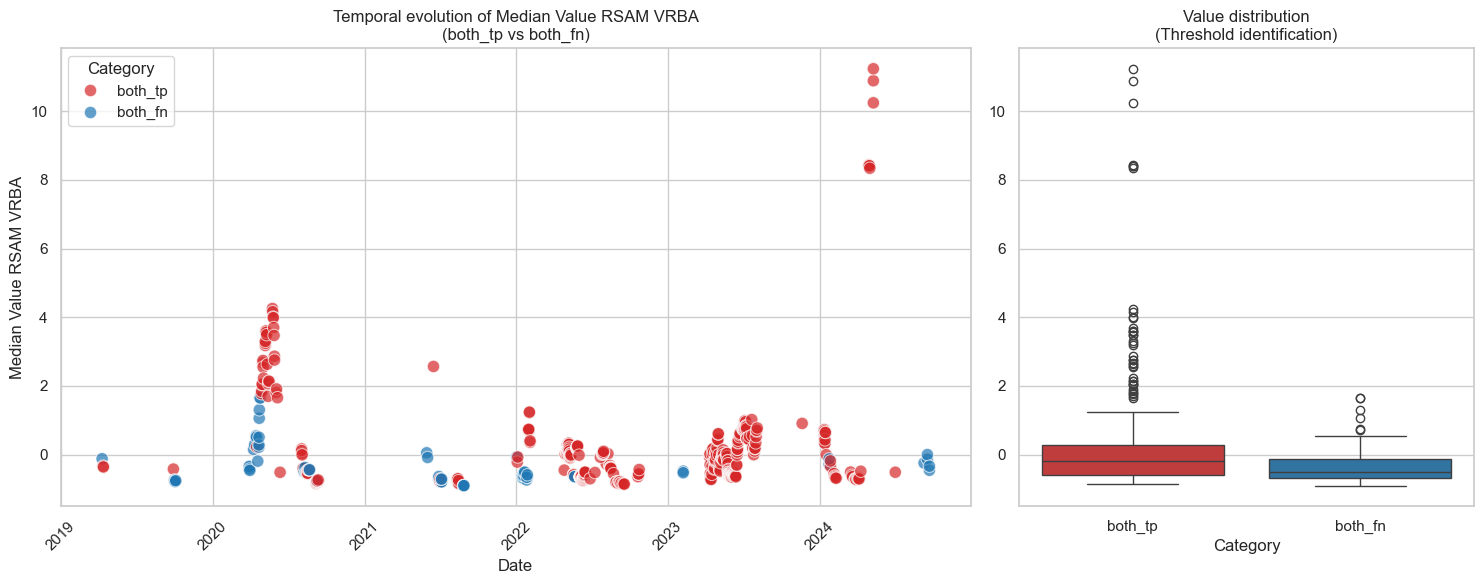

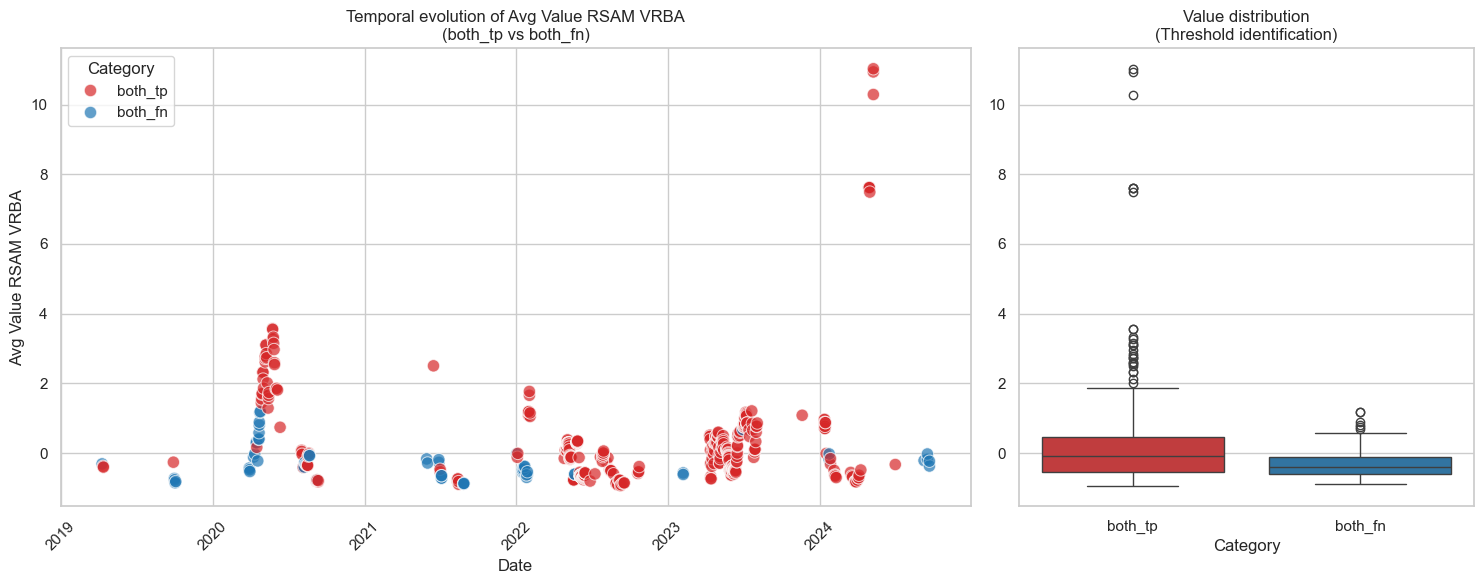

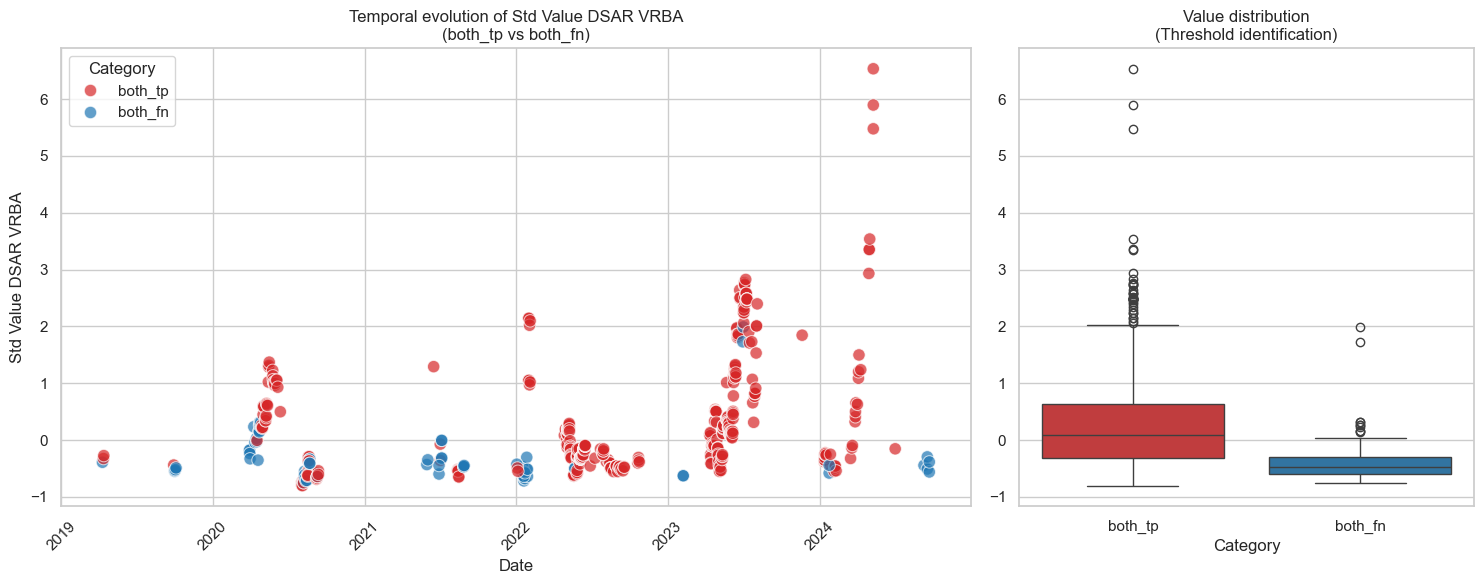

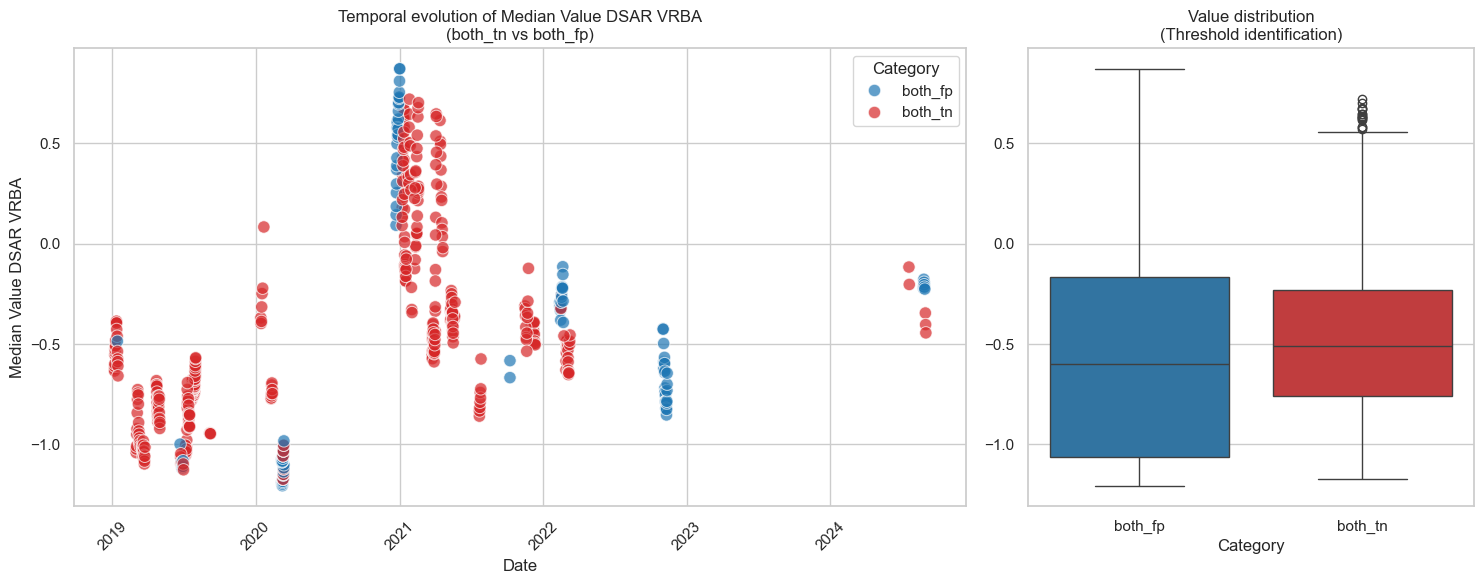

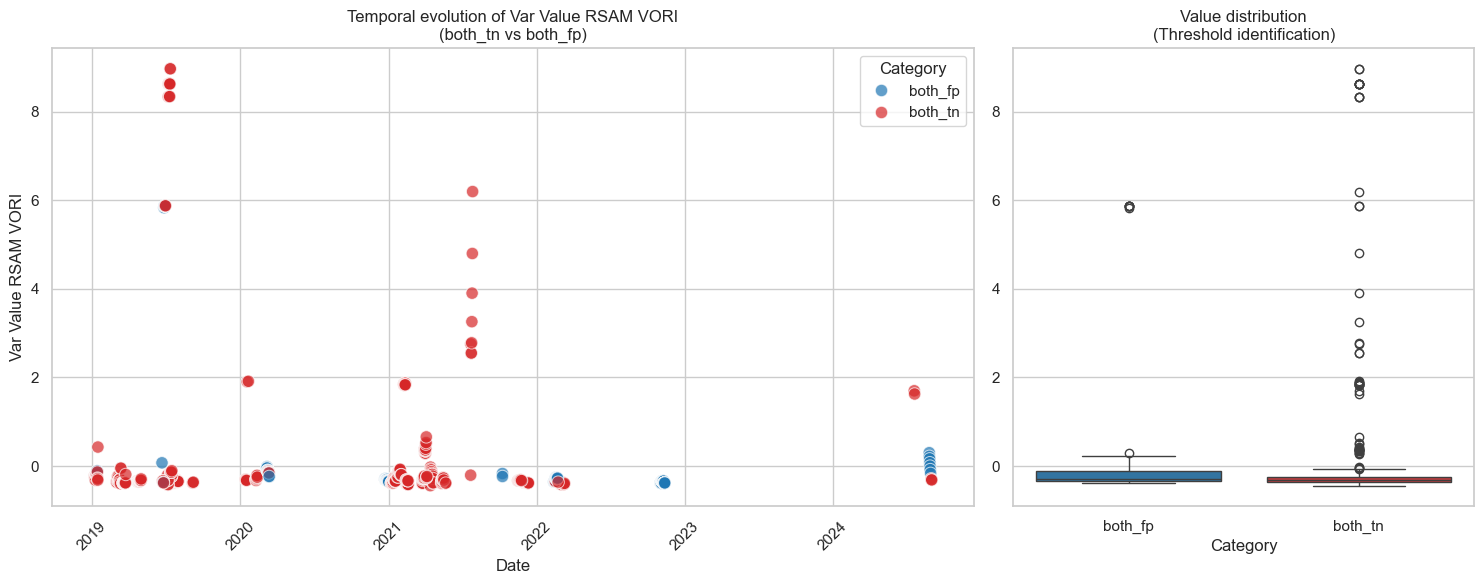

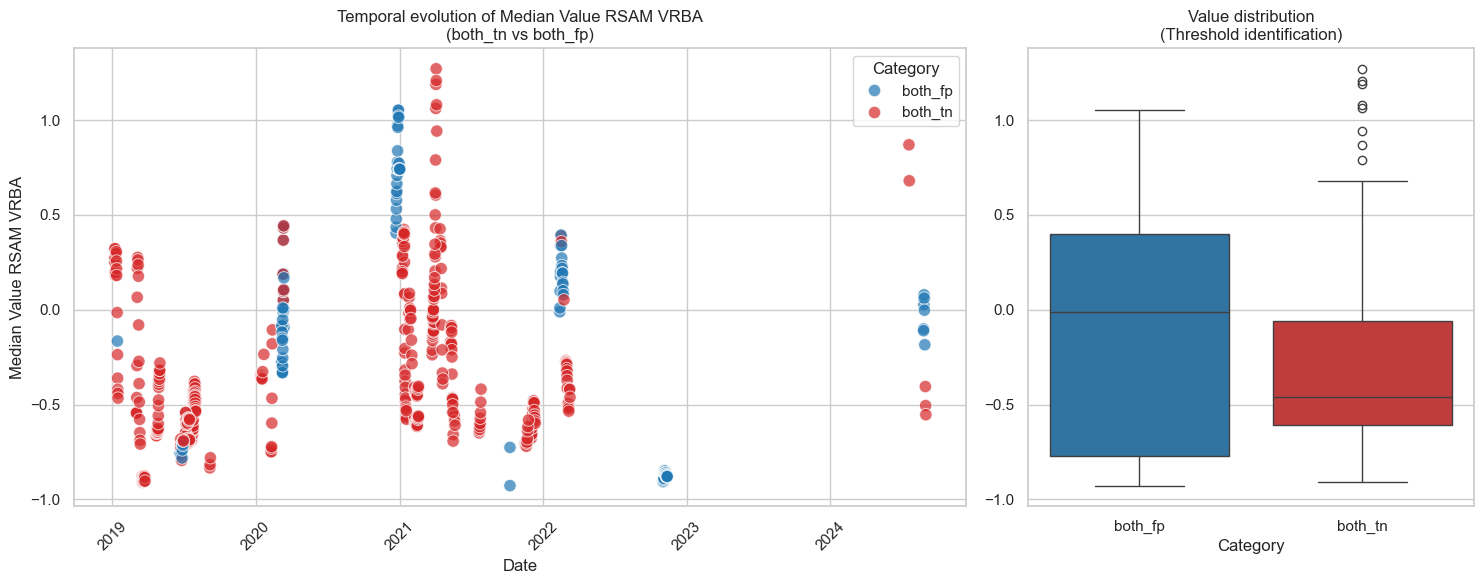

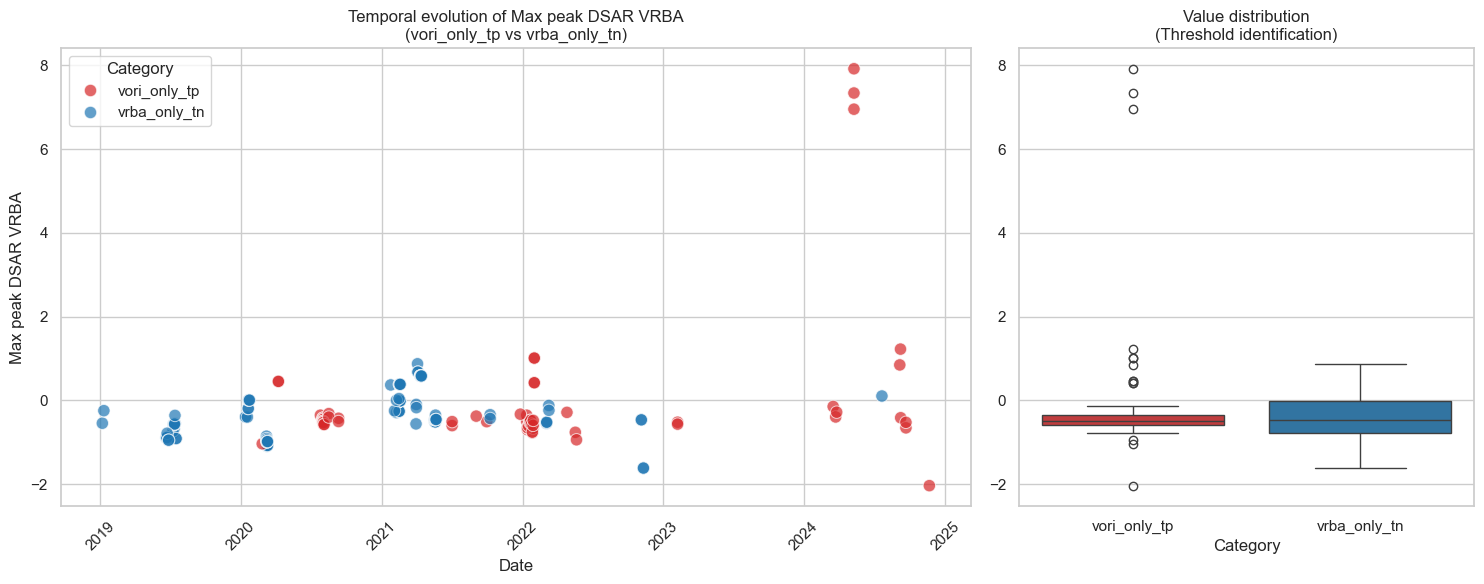

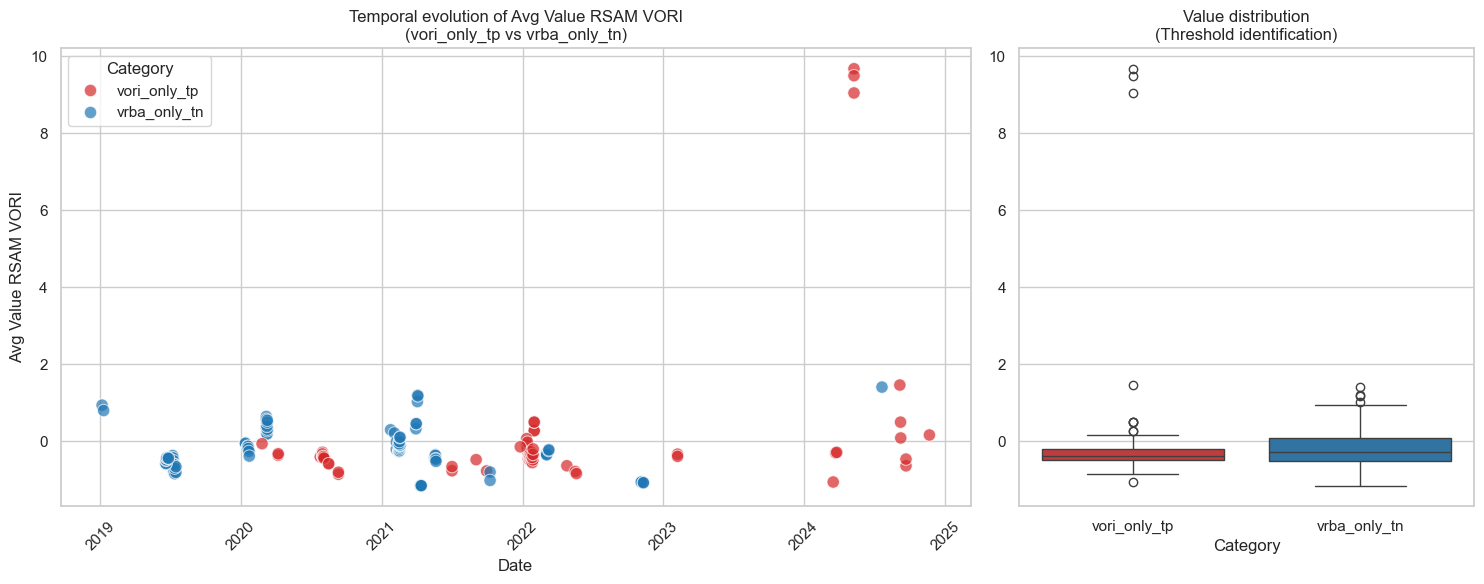

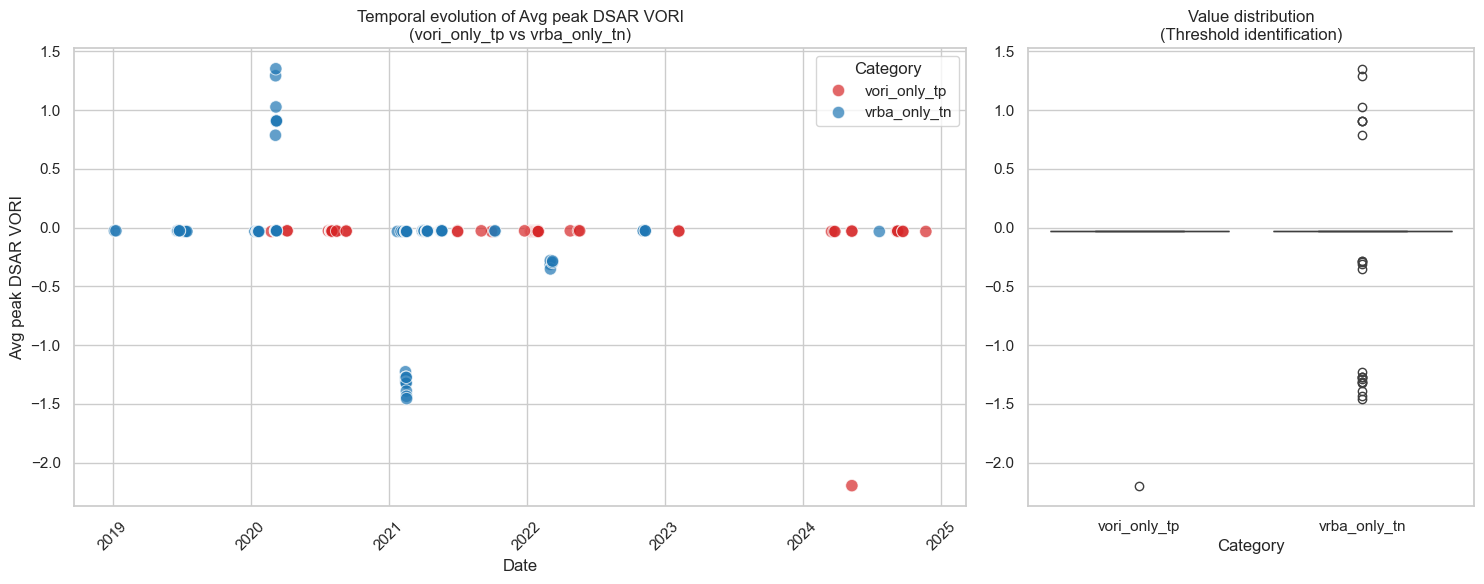

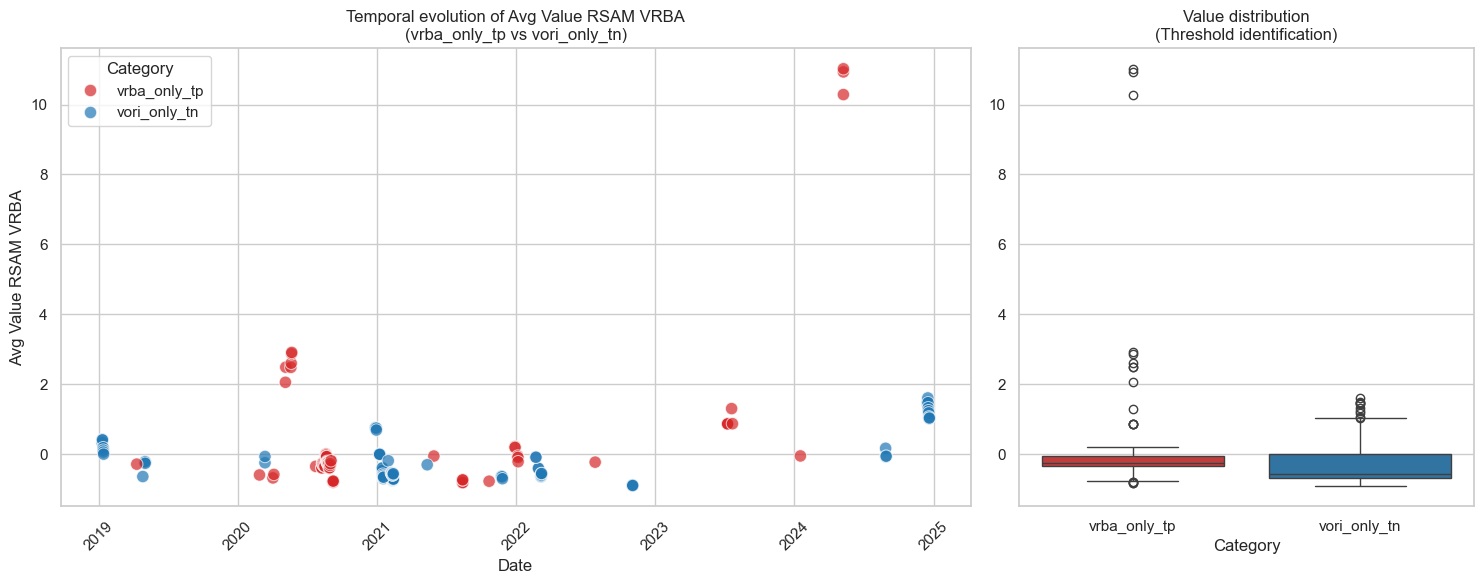

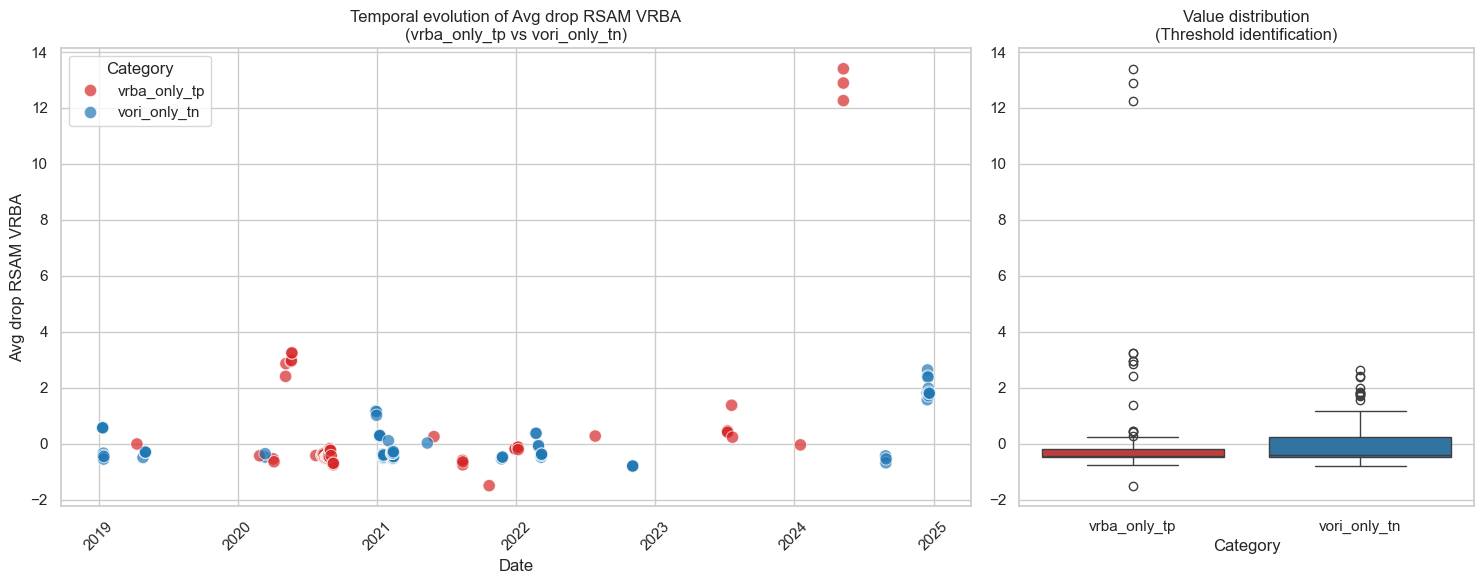

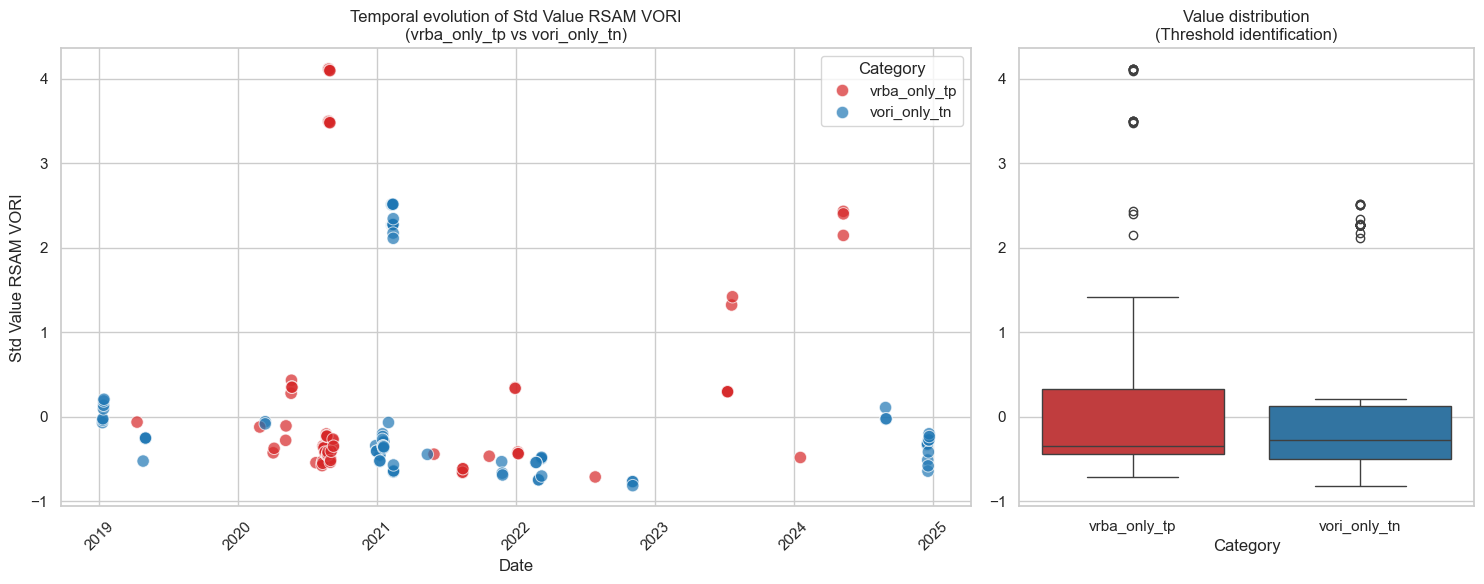

In [323]:
def plot_top_features_per_cases(summary_df, p_results, target_classes, x_val_VORI, x_val_VRBA, time_val, top_n=3):
    
    # Set visual style for the thesis plots
    sns.set_theme(style="whitegrid")
    
    for target in target_classes:
        category_1, category_2 = target[0], target[1]
        test_name = f"{category_1}_vs_{category_2}"
        
        # Check if the comparison test exists in the statistical results
        if test_name not in p_results:
            raise ValueError(f"Statistical test results for {test_name} not found in p_results.")
            
   
        relevant_features = p_results[test_name].head(top_n).index.to_list()
  
        # Consolidate all validation data into a single DataFrame to facilitate plotting
        all_data = []
        for validation_set in x_val_VORI.keys():
            
            # Extract dates for the current validation set
            dates = time_val[validation_set]

            # Combine VRBA and VORI to have all available columns in one place
            df_combined = pd.concat([x_val_VORI[validation_set], x_val_VRBA[validation_set]], axis=1)

            df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

            df_combined['Date'] = dates
            
            # Keep only the date and the specific relevant features to save memory
            cols_to_keep = ['Date'] + [f for f in relevant_features if f in df_combined.columns]
            df_combined = df_combined[cols_to_keep]
            all_data.append(df_combined)
            
        # Create the global dataset by combining all validation sets
        full_val_df = pd.concat(all_data, ignore_index=True)

        # FIX: Ensure both 'Date' columns are proper datetime64[ns] objects before merging
        full_val_df['Date'] = pd.to_datetime(full_val_df['Date'])
        
        # Isolate the summary dates and safely convert them to avoid SettingWithCopyWarning
        summary_dates = summary_df[['Date', 'Category']].copy()
        summary_dates['Date'] = pd.to_datetime(summary_dates['Date'])
        
        # Merge safely now that both columns share the exact same datatype
        plot_df = pd.merge(full_val_df, summary_dates, on='Date', how='inner')
        
        # Filter the dataset to keep only the two categories currently being compared
        plot_df = plot_df[plot_df['Category'].isin([category_1, category_2])]

        # Generate plots for each relevant feature
        for feature in relevant_features:
            if feature not in plot_df.columns:
                continue
                
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})
            
            # Time series scatter plot to visualize chronological distribution
            sns.scatterplot(
                data=plot_df, x='Date', y=feature, hue='Category', 
                palette={category_1: '#d62728', category_2: '#1f77b4'}, 
                s=80, alpha=0.7, ax=ax1
            )
            ax1.set_title(f"Temporal evolution of {feature}\n({category_1} vs {category_2})")
            ax1.tick_params(axis='x', rotation=45)
            
            # Boxplot to identify potential physical thresholds between classes
            sns.boxplot(
                data=plot_df, x='Category', y=feature, hue='Category',
                palette={category_1: '#d62728', category_2: '#1f77b4'},
                ax=ax2, legend=False
            )
            ax2.set_title(f"Value distribution\n(Threshold identification)")
            ax2.set_ylabel("") # Hide the Y-axis label for a cleaner look
            
            plt.tight_layout()
            plt.savefig(f"MSc_Bryan_Rincon/Plot P values/{feature}_{category_1}_vs_{category_2}.png")
            plt.show()

plot_top_features_per_cases(df_grouped_features, p_results, target_classes, x_val_5_VORI, x_val_5_VRBA, time_5days_val, top_n=3)

1. Systemic Detection vs. Systemic Failure (both_tp vs both_fn)

The statistical comparison between eruptions correctly identified by both stations and those completely missed highlights the fundamental baseline required for successful detection. The most highly discriminating features are overwhelmingly linked to the continuous seismic and acoustic energy at the VRBA station, specifically Median Value RSAM VRBA (p = 6.14e-21) and Std Value DSAR VRBA. This indicates that systemic detection relies heavily on a clear, macroscopic elevation in background noise. If VRBA does not register a deviation in its median or average energy levels, the entire monitoring network is likely to miss the event.

Furthermore, pre-eruptive physical precursors are statistically validated by the strong relevance of Max drop RSAM VRBA, suggesting that a sudden decrease in seismic energy prior to an event is a critical signature learned by the models. While VRBA dominates the top indicators, the VORI station provides essential complementary data. The high significance of Std Value RSAM VORI and Var Value RSAM VORI demonstrates that global behavioral shifts (variance and standard deviation) at the VORI site are critical secondary indicators of an impending eruption. Finally, the presence of Sum_Precipitations among the top five features underscores that external environmental factors strongly modulate the signal, and models must account for weather data to accurately classify true positive events.

2. True Quiescence vs. Systemic False Alarms (both_tn vs both_fp)

Analyzing the conditions under which both stations agree to launch a false alarm reveals critical vulnerabilities in the monitoring network, primarily driven by environmental noise. When the network correctly identifies a period of quiescence versus when it falsely flags an eruption, Sum_Precipitations acts as a massive confounding variable (p = 1.56e-15). This provides clear evidence that heavy rainfall likely increases the seismic background noise, imitating the geophysical signatures (such as tremor or lahar initiation) that the models associate with an eruption.

This environmental interference causes a ripple effect across the models' assumptions. During systemic false alarms, we observe significant anomalous shifts in the core metrics of both stations, notably Median Value DSAR VRBA (the most significant feature overall) and Var Value RSAM VORI. Essentially, external noise induces a significant change in signal intensity and variance during a period of true quiescence. The models detect these sudden shifts—including variations in the higher quantiles (Quantile Changes DSAR VRBA) which should theoretically remain stable during quiescence—and are deceived into misclassifying the weather-induced noise as a volcanic event.

3. Arbitrating VORI's Isolated Alerts (vori_only_tp vs vrba_only_tn)
Evaluating isolated alerts from the VORI station reveals how the monitoring network distinguishes a true localized precursor from a localized false alarm. When VORI correctly flags an eruption while VRBA predicts quiescence, the discrimination is heavily driven by transient signal peaks and discrete seismic events rather than continuous energy shifts.

Interestingly, the most statistically significant confirming feature is Max peak DSAR VRBA (p = 5.00e-6). This demonstrates a powerful cross-validation mechanism: even when the VRBA model fails to classify the overall window as an eruption, a localized acoustic peak at the VRBA station physically validates VORI's alert. Furthermore, this scenario is uniquely characterized by the appearance of distinct geological fractures and fluid movements. The sums of Volcano-Tectonic earthquakes (Sum_VT, p = 3.10e-5) and tornillo events (Sum_tornillo, p = 1.12e-4) act as critical geophysical confirmations. If VORI triggers an isolated alert without the presence of these specific discrete seismic events or corresponding acoustic peaks at VRBA, the alert is highly likely to be a false positive.

4. Arbitrating VRBA's Isolated Alerts (vrba_only_tp vs vori_only_tn)
Conversely, when the VRBA station triggers an isolated alert, the arbitration logic shifts from transient peaks to sustained energy baselines and environmental vetoes. The most critical indicators validating a VRBA-only true positive are the continuous energy metrics at the station itself, specifically Avg Value RSAM VRBA (p = 5.17e-10) and Avg drop RSAM VRBA (p = 4.37e-09). A legitimate isolated alert from VRBA requires a fundamental, sustained deviation in its seismic background noise compared to normal quiescence.

However, validating this alert requires analyzing the secondary station and external environmental factors to rule out false positives. The network relies on VORI's signal variance (Std Value RSAM VORI, p = 5.71e-08, and Var Value RSAM VORI) as a secondary confirmation; even if VORI does not detect the eruption outright, its background signal must show heightened agitation. Most importantly, Sum_Precipitations emerges again as a highly significant discriminatory feature (p = 7.20e-06). This serves as a critical meteorological veto: if VRBA registers an isolated increase in RSAM energy during a period of heavy rainfall while VORI remains relatively stable, the meta-model can confidently classify the event as weather-induced noise rather than an impending eruption.

Lahars features analysis

Lets first look to all the lahars that have predicted through the models

In [309]:
# All the lahares date
Lahares_df['Eruption time']

7    2019-01-20 07:27:00
8    2020-01-30 18:13:00
9    2020-05-25 09:25:00
10   2021-06-28 11:42:00
11   2022-06-01 00:33:00
12   2022-01-23 08:24:00
13   2022-01-30 19:08:00
14   2023-04-14 15:35:00
15   2023-04-21 21:50:00
16   2023-11-05 21:17:00
17   2023-05-14 08:58:00
18   2023-05-25 20:35:00
19   2023-05-28 03:34:00
20   2023-05-29 08:44:00
21   2023-02-06 15:05:00
Name: Eruption time, dtype: datetime64[ns]

In [312]:
lahares_dates = Lahares_df['Eruption time']

lahares_summary = df_counts[df_counts.index.floor('min').isin(pd.to_datetime(lahares_dates))].copy()

print(lahares_summary)

Category                 both_fn  both_fp  both_tn  both_tp  vori_only_tn  \
Date                                                                        
2020-05-25 09:25:52.157        0        0        0        1             0   
2021-06-28 11:42:04.132        2        0        0        0             0   
2022-01-23 08:24:45.682        0        0        0        0             0   
2022-01-30 19:08:00.000        0        0        0        1             0   
2022-06-01 00:33:00.000        0        0        0        1             0   
2023-02-06 15:05:00.000        1        0        0        0             0   
2023-04-14 15:35:36.445        0        0        0        1             0   
2023-04-21 21:50:10.251        0        0        0        1             0   
2023-05-14 08:58:05.785        0        0        0        1             0   
2023-05-25 20:35:31.649        0        0        0        1             0   
2023-05-28 03:34:53.507        0        0        0        1             0   

In [316]:
lahares_summary_cat = lahares_summary.drop(columns=['Total_Votes']).copy()
lahares_category_columns = lahares_summary_cat.columns[lahares_summary_cat.sum() > 0].tolist()
del(lahares_summary_cat)
print(lahares_category_columns)

['both_fn', 'both_tp', 'vori_only_tp']


In [336]:
# Initialize an empty list to store the temporary dataframes
liste_dfs = []

for cat in lahares_category_columns:
    # Extract the relevant dates for the current category
    cat_dates = lahares_summary[lahares_summary[cat] > 0].index.tolist()
    
    # Filter the features dataframe based on the category and corresponding dates
    df_grouped_features_cat = df_grouped_features[
        (df_grouped_features['Category'] == cat) & 
        (df_grouped_features['Date'].isin(cat_dates))
    ].copy()
    
    # Append the filtered dataframe to the list
    liste_dfs.append(df_grouped_features_cat)

# Concatenate all collected dataframes into a single dataframe
# Using ignore_index=True to ensure a clean, continuous index
df_lahares_final = pd.concat(liste_dfs, ignore_index=True)
df_lahares_final.to_csv('MSc_Bryan_Rincon/Truth_table/lahares_summary_features.csv', index=False)
# Output the final combined dataframe
print(df_lahares_final)

                      Date      Category   Model_Years  Model_Count  \
0  2021-06-28 11:42:04.132       both_fn  [2020, 2023]            2   
1  2023-02-06 15:05:00.000       both_fn        [2020]            1   
2  2020-05-25 09:25:52.157       both_tp        [2024]            1   
3  2022-01-30 19:08:00.000       both_tp        [2020]            1   
4  2022-06-01 00:33:00.000       both_tp        [2021]            1   
5  2023-04-14 15:35:36.445       both_tp        [2019]            1   
6  2023-04-21 21:50:10.251       both_tp        [2019]            1   
7  2023-05-14 08:58:05.785       both_tp        [2019]            1   
8  2023-05-25 20:35:31.649       both_tp        [2019]            1   
9  2023-05-28 03:34:53.507       both_tp        [2019]            1   
10 2023-05-29 08:44:09.899       both_tp        [2019]            1   
11 2022-01-23 08:24:45.682  vori_only_tp  [2020, 2023]            2   
12 2022-01-30 19:08:00.000  vori_only_tp        [2023]            1   
13 202

In [337]:
# df_lahares_final = pd.read_csv('MSc_Bryan_Rincon/Truth_table/lahares_summary_features.csv', index_col=0, parse_dates=True)
# If '#' taken dont forget to parse

lahares_cat_dict = {}
for cat in lahares_category_columns:
    lahares_cat_dict[cat] = df_lahares_final[df_lahares_final['Category'] == cat].copy()
    print(f"Category: {cat}, Number of records: {len(lahares_cat_dict[cat])}")

Category: both_fn, Number of records: 2
Category: both_tp, Number of records: 9
Category: vori_only_tp, Number of records: 3


In [346]:
# Both fn 

for num in range(len(lahares_cat_dict['both_fn'])):
    print(f"Top Feature {num+1}:")
    print("Top Features VORI:", lahares_cat_dict['both_fn']['Dict_VORI'][num])
    print("Top Features VRBA:", lahares_cat_dict['both_fn']['Dict_VRBA'][num])
    print("-" * 50)

Top Feature 1:
Top Features VORI: {'Sum_LP': 0.2565506841911853, 'Max_tornillo': 0.1535728372333424, 'Quantile Changes RSAM VORI': 0.11725512654705322, 'Max drop DSAR VORI': 0.0991831503617413, 'Mean Min Values DSAR VORI': 0.0960483452683682, 'Avg drop DSAR VORI': 0.07636558525079079, 'Sum_Precipitations': 0.07503827881785557, 'Mean Min Values RSAM VORI': 0.07057581242584543, 'Median Value RSAM VORI': 0.06971859544526739, 'Avg peak RSAM VORI': 0.06710088151394698, 'Median Value DSAR VORI': 0.06375232511214071, 'Var Value RSAM VORI': 0.0632745000082417, 'Sum_tornillo': 0.06191513825621659, 'Max peak RSAM VORI': 0.05828863550701607, 'Max_Precipitations': 0.05770883047674887, 'Max_LP': 0.055342202795031825, 'Delta_Max_Min_tornillo': 0.05368727093084184, 'Std Value DSAR VORI': 0.052703312587600526, 'Delta_Max_Min_LP': 0.04581991552293942, 'Delta_Max_Min_Precipitations': 0.0433711853448646, 'Avg peak DSAR VORI': 0.034643590537734914, 'Std Value RSAM VORI': 0.029831494875812072, 'Avg Value D

In [351]:
# Classement features for each category
lahares_features_scores = {}

for cat in lahares_category_columns:
    # Initialize a Counter to accumulate feature scores
    combined_counter_VORI = Counter()
    combined_counter_VRBA = Counter()
    
    # Iterate through each record in the category
    for idx, row in lahares_cat_dict[cat].iterrows():
        combined_counter_VORI.update(row['Dict_VORI'])
        combined_counter_VRBA.update(row['Dict_VRBA'])
    
    # Store the combined feature scores specifically FOR THIS CATEGORY
    lahares_features_scores[cat] = {
        'VORI': dict(combined_counter_VORI),
        'VRBA': dict(combined_counter_VRBA)
    }

print("Top 10 Feature scores for each category for each station:") 
for cat in lahares_category_columns:
    print(f"\n--- Category: {cat} ---")
    
    # Access the scores using both the category and the station
    top_vori = dict(Counter(lahares_features_scores[cat]['VORI']).most_common(10))
    top_vrba = dict(Counter(lahares_features_scores[cat]['VRBA']).most_common(10))
    
    print("Top Features VORI:", top_vori)
    print("Top Features VRBA:", top_vrba)

Top 10 Feature scores for each category for each station:

--- Category: both_fn ---
Top Features VORI: {'Sum_LP': 0.4614525731356307, 'Max_tornillo': 0.2688286291992816, 'Max drop DSAR VORI': 0.1739529684353625, 'Quantile Changes RSAM VORI': 0.17293760395385277, 'Mean Min Values DSAR VORI': 0.16800143726491065, 'Avg drop DSAR VORI': 0.13087320753300596, 'Median Value RSAM VORI': 0.11543531709468575, 'Avg peak RSAM VORI': 0.11340135867866807, 'Median Value DSAR VORI': 0.10915516324147206, 'Mean Min Values RSAM VORI': 0.10735527264878936}
Top Features VRBA: {'Quantile Changes RSAM VRBA': 0.4612647064816648, 'Median Value DSAR VRBA': 0.3885355732844292, 'Sum_LP': 0.29640564549289394, 'Quantile Changes DSAR VRBA': 0.2584714596303091, 'Avg peak DSAR VRBA': 0.19872703073342823, 'Std Value DSAR VRBA': 0.13907517084002594, 'Var Value DSAR VRBA': 0.12398802603267456, 'Max_LP': 0.10466994769754329, 'Avg Value DSAR VRBA': 0.10226378413274734, 'Mean Min Values DSAR VRBA': 0.09913066031532747}

--

In [352]:
lahares_features_scores['both_tp']['VORI']

{'Sum_LP': 0.9404579052657049,
 'Max_LP': 0.5463333322829834,
 'Quantile Changes RSAM VORI': 0.3724178081798404,
 'Mean Min Values DSAR VORI': 0.3366577648947598,
 'Delta_Max_Min_LP': 0.4487016681165183,
 'Delta_Max_Min_tornillo': 0.26575849890170755,
 'Max_tornillo': 0.3608906843405268,
 'Max drop DSAR VORI': 0.42637601998155356,
 'Max_Precipitations': 0.21711949150583576,
 'Var Value RSAM VORI': 0.2206443717263339,
 'Median Value DSAR VORI': 0.2896916293648344,
 'Std Value RSAM VORI': 0.0588664300832868,
 'Avg drop DSAR VORI': 0.37898714914813325,
 'Mean Min Values RSAM VORI': 0.37294761812521093,
 'Avg Value RSAM VORI': 0.2568639289038893,
 'Delta_Max_Min_Precipitations': 0.17866324536171124,
 'Sum_Precipitations': 0.1824881445134547,
 'Avg peak RSAM VORI': 0.301575463027534,
 'Avg drop RSAM VORI': 0.179370433498032,
 'Max peak RSAM VORI': 0.3553113061763505,
 'Std Value DSAR VORI': 0.12972806805686599,
 'Max drop RSAM VORI': 0.189502538585285,
 'Max peak DSAR VORI': 0.2045149017609

['Mean Min Values DSAR VORI', 'Avg Value DSAR VRBA', 'Quantile Changes RSAM VRBA', 'Std Value DSAR VORI', 'Max_Precipitations', 'Max peak DSAR VRBA', 'Max_tornillo', 'Quantile Changes DSAR VRBA', 'Delta_Max_Min_LP', 'Avg peak DSAR VRBA', 'Quantile Changes RSAM VORI', 'Mean Min Values RSAM VRBA', 'Sum_LP', 'Max drop DSAR VORI', 'Max_LP', 'Avg drop DSAR VORI', 'Median Value DSAR VRBA']


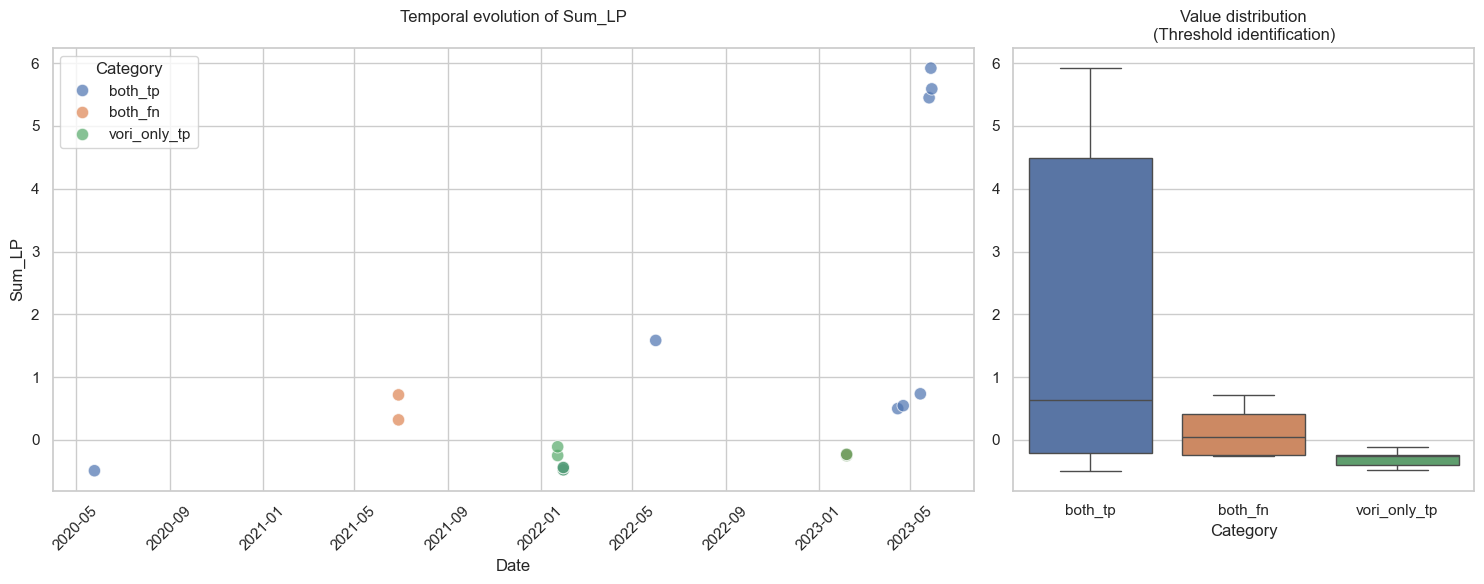

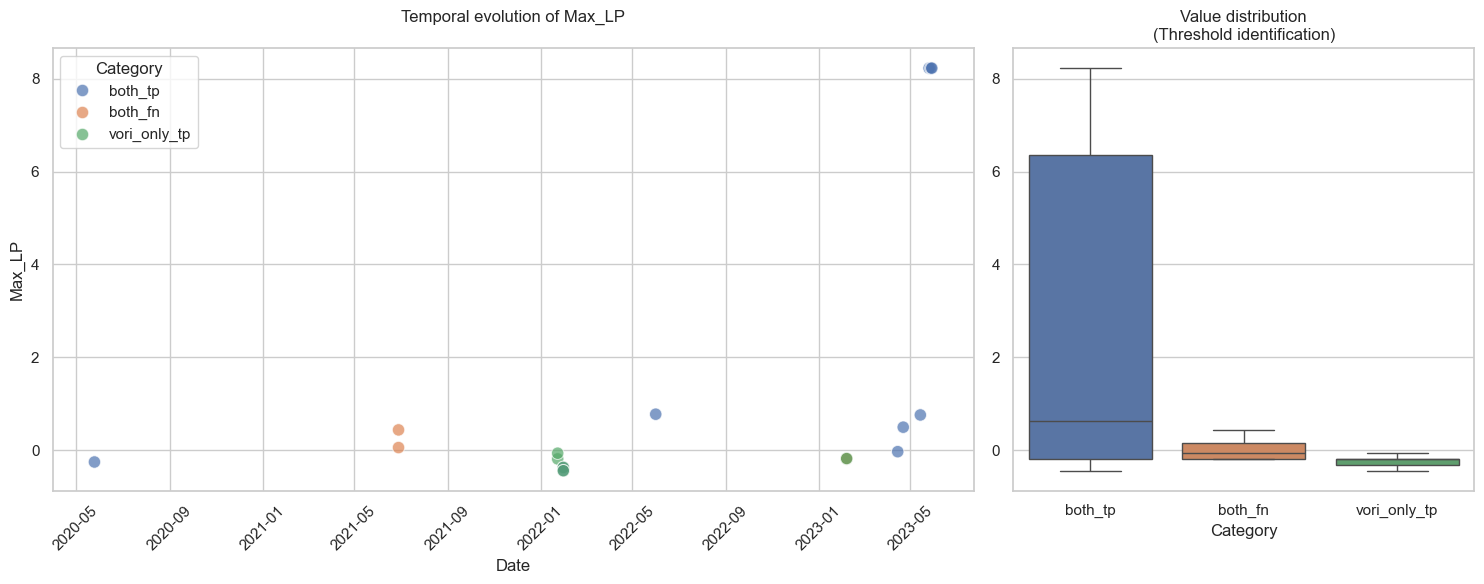

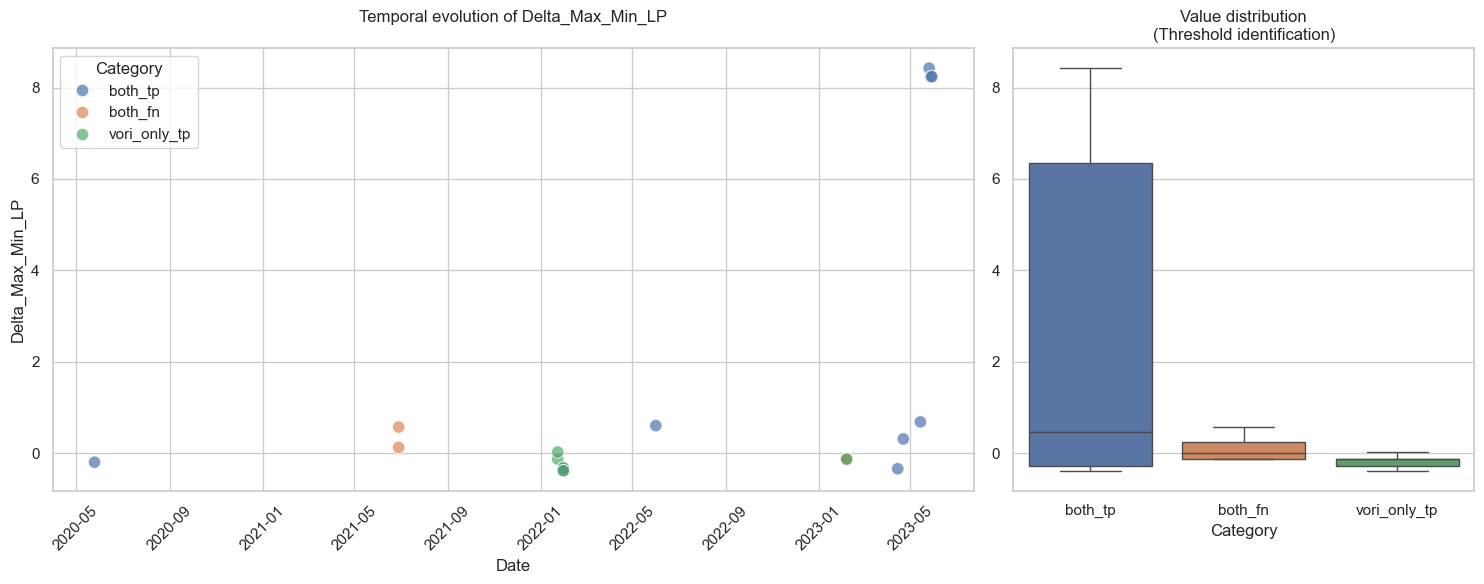

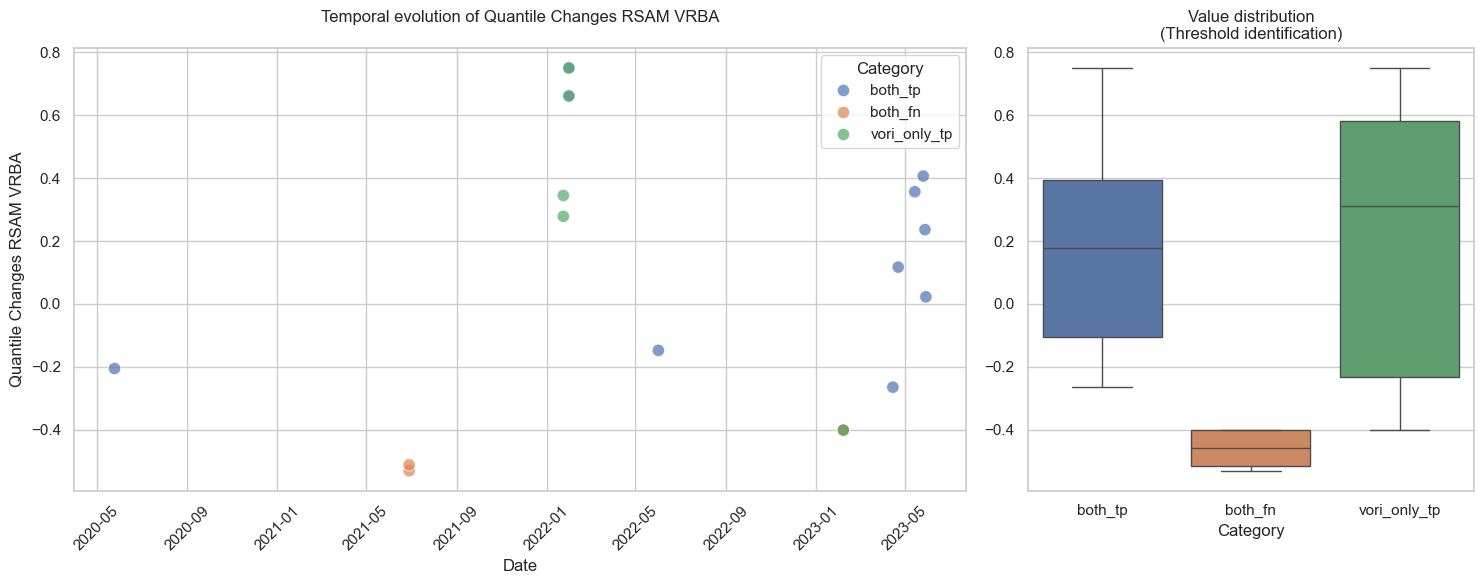

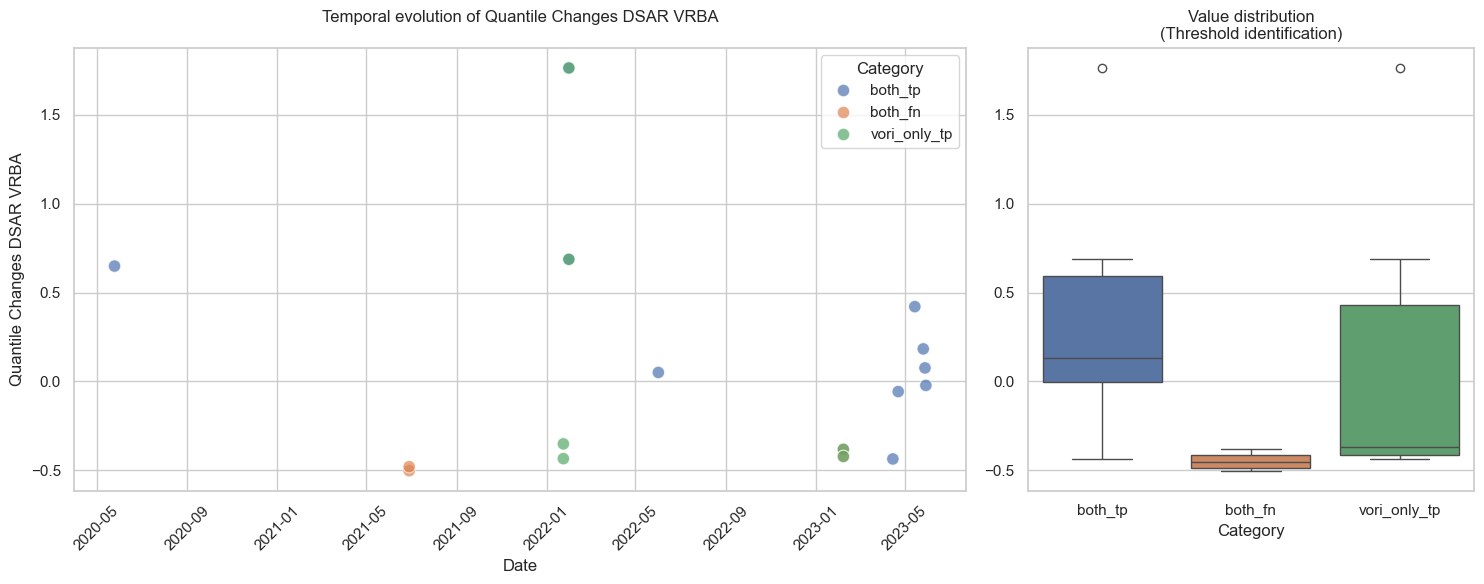

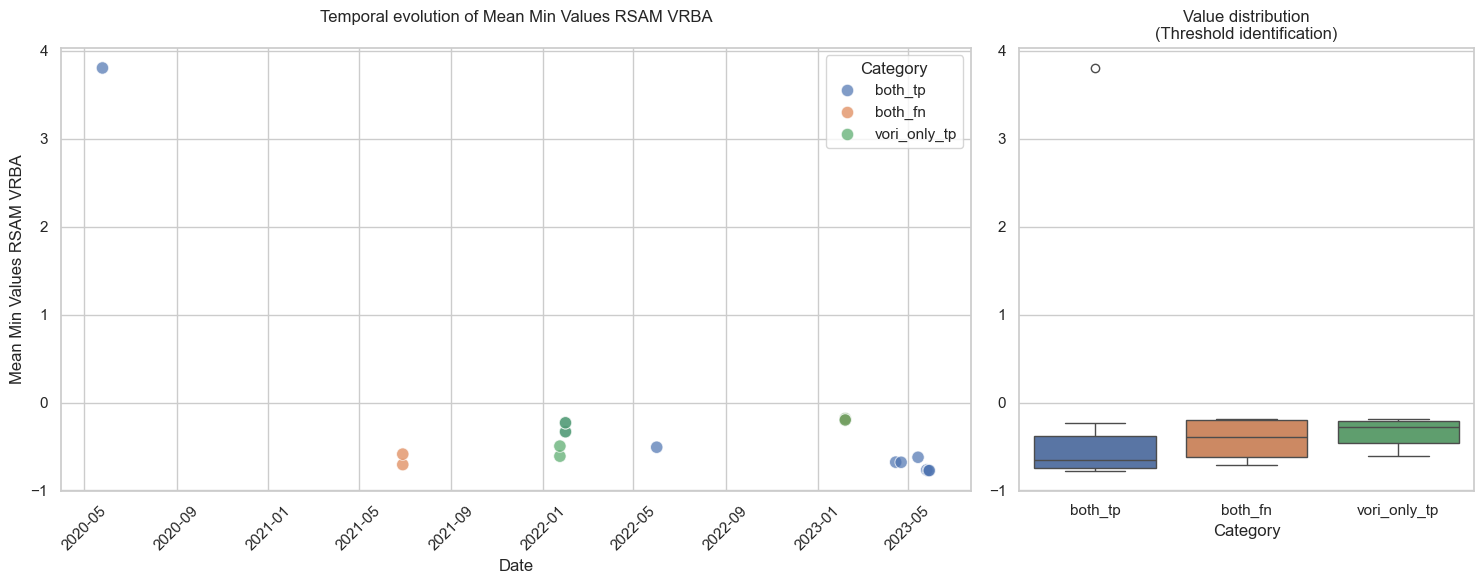

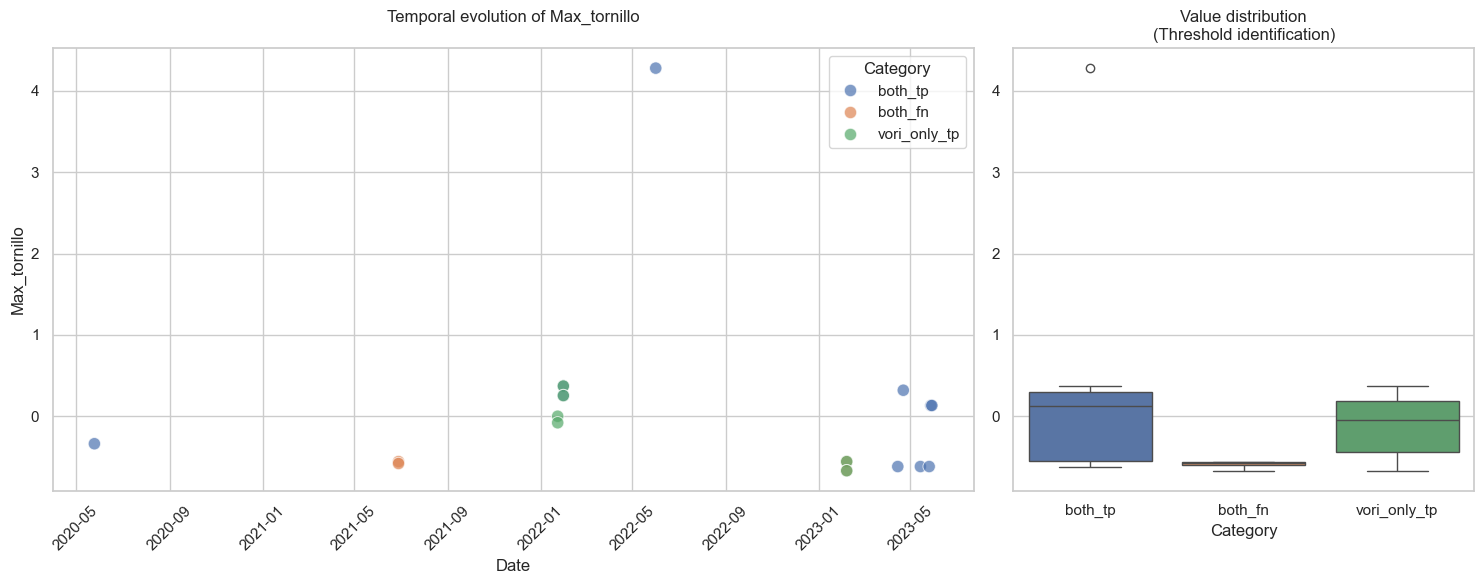

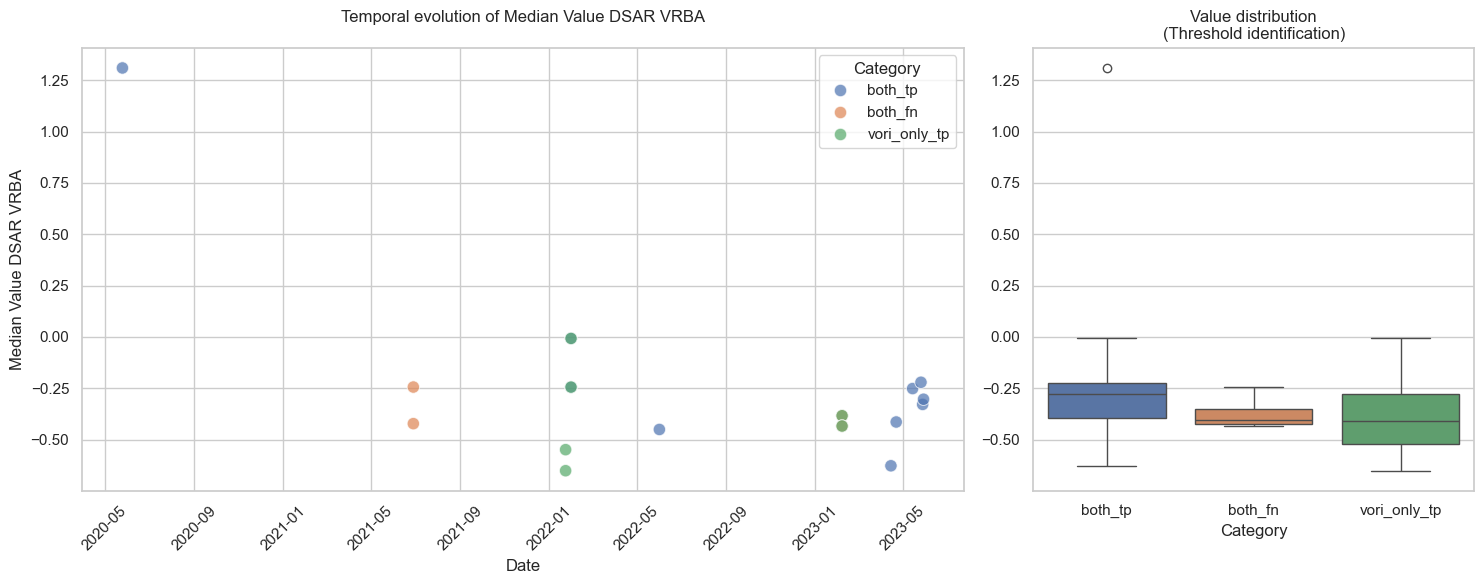

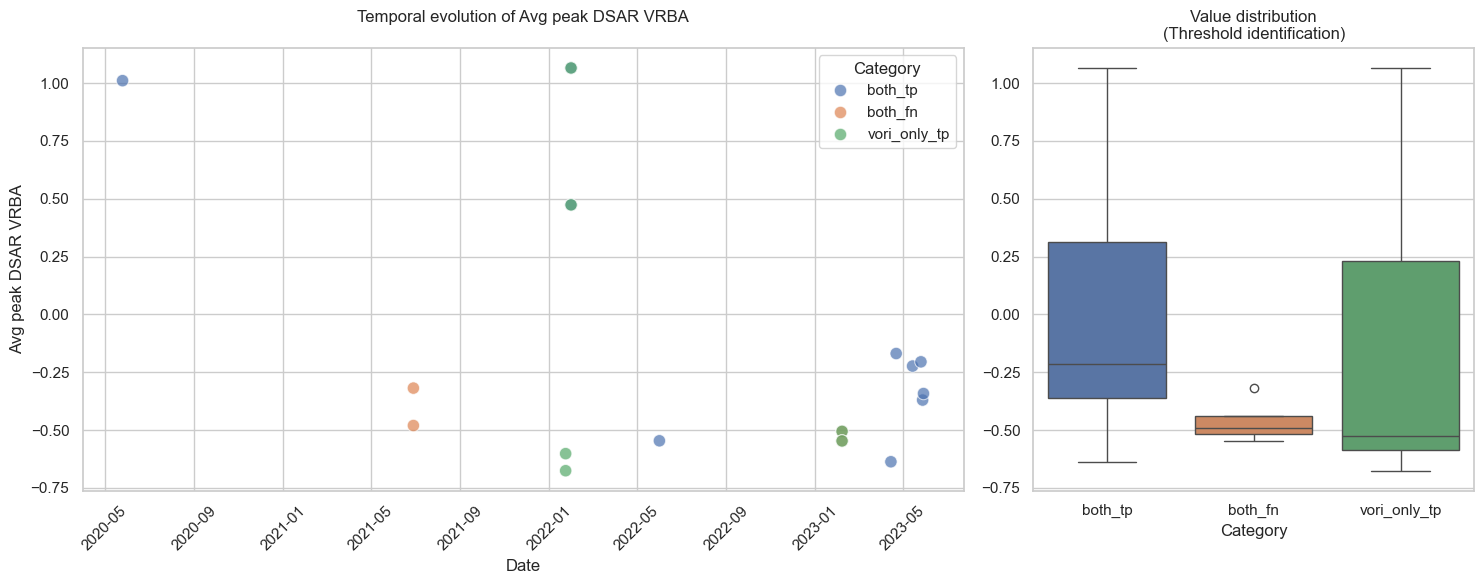

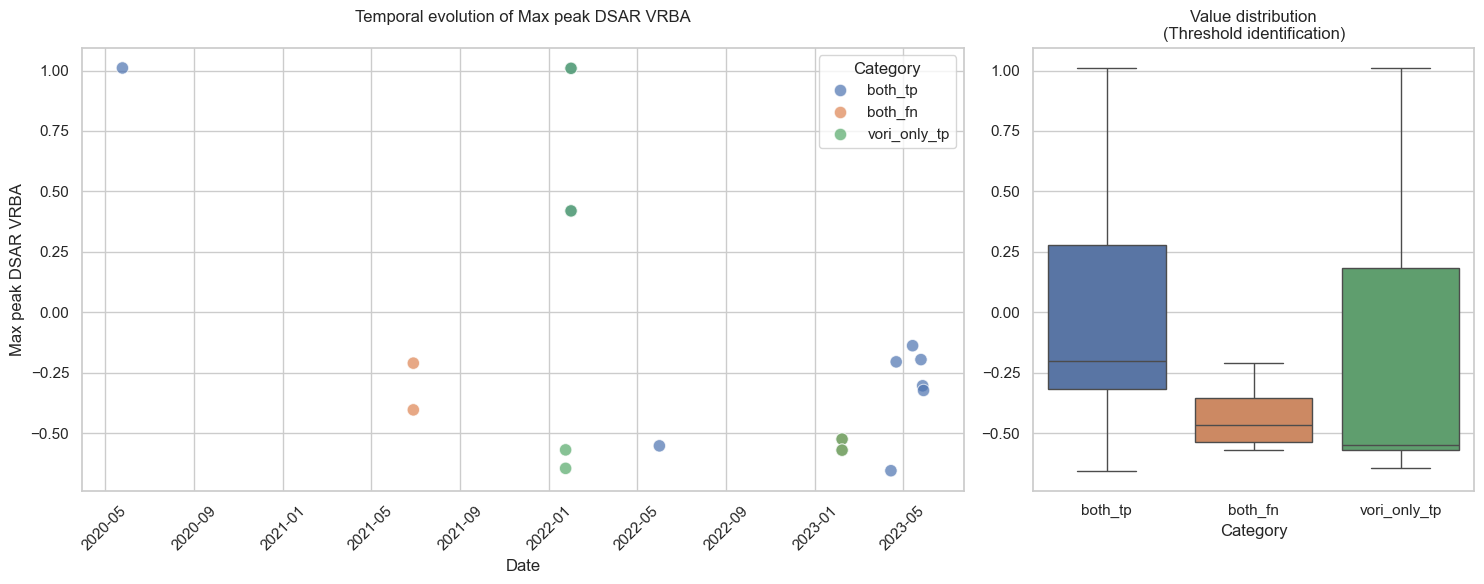

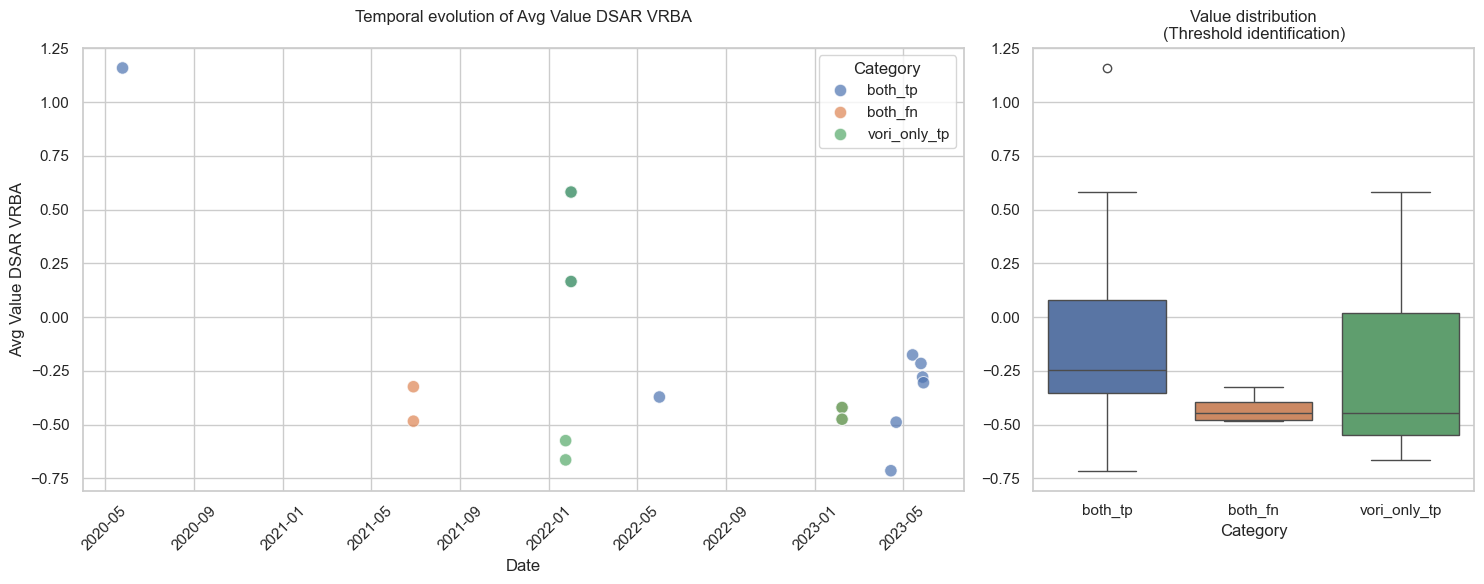

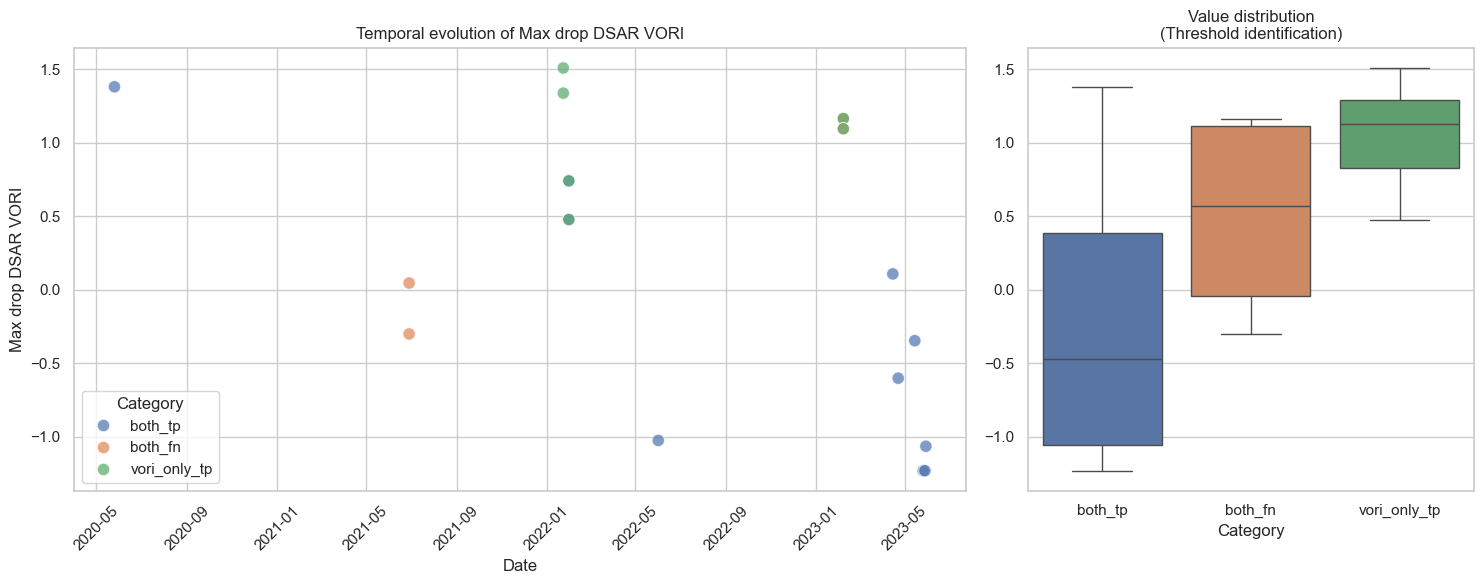

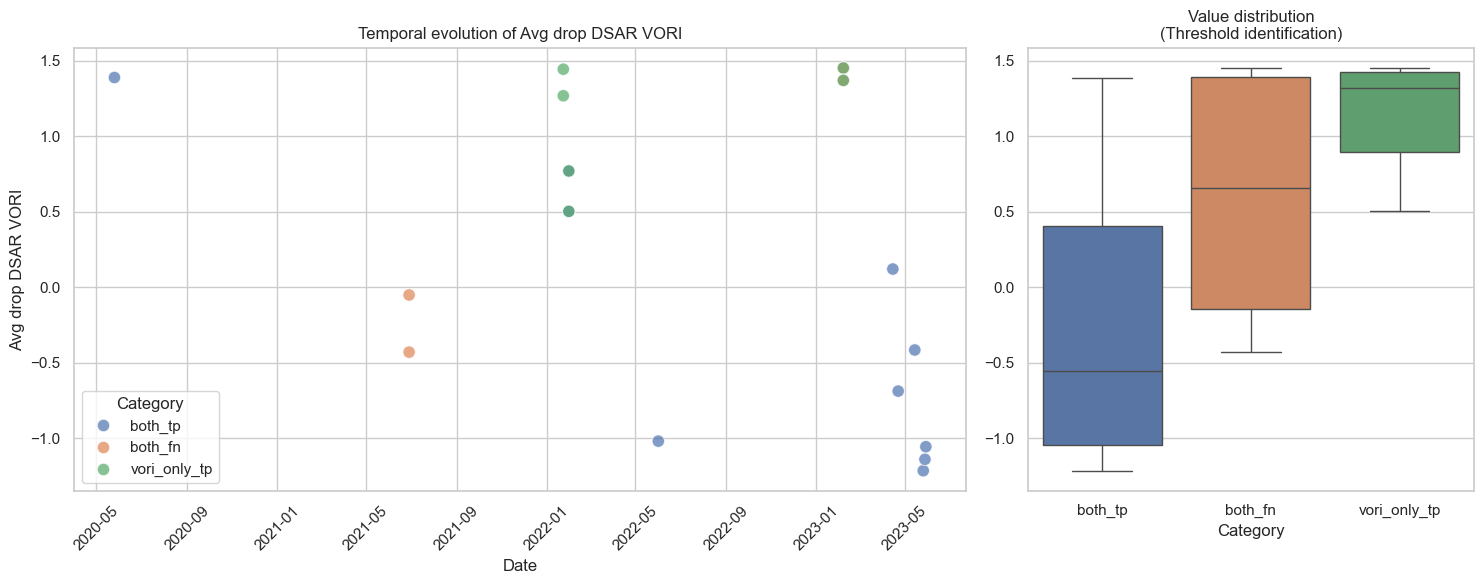

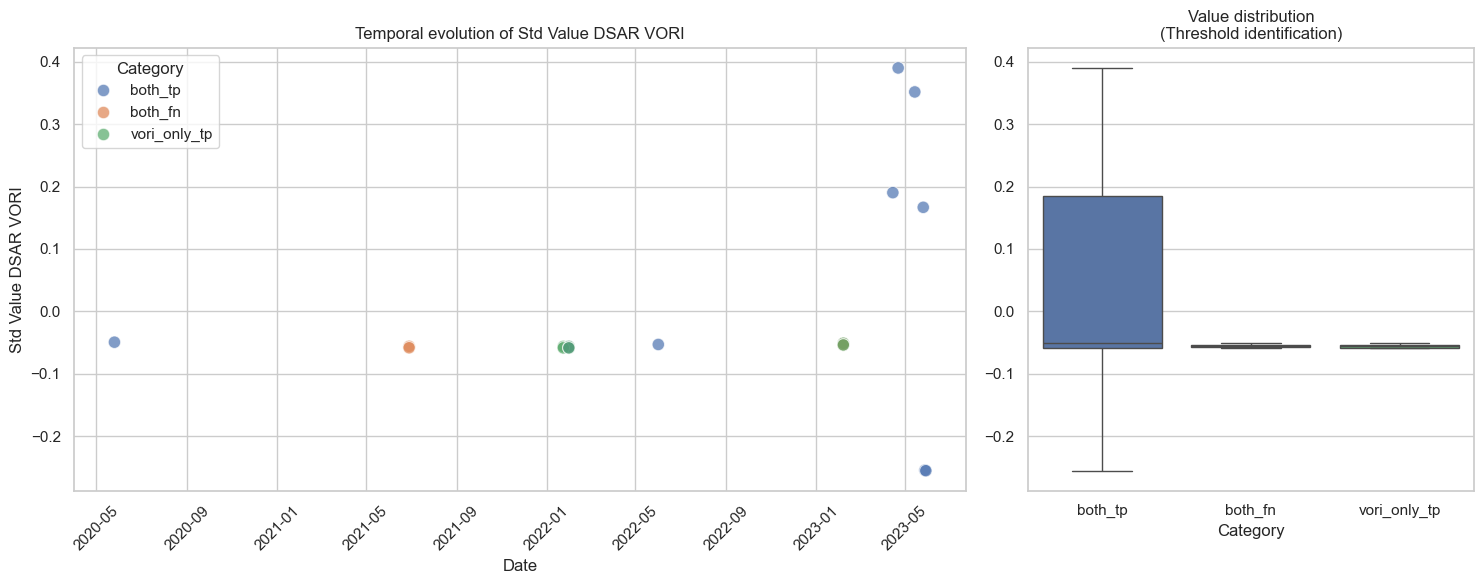

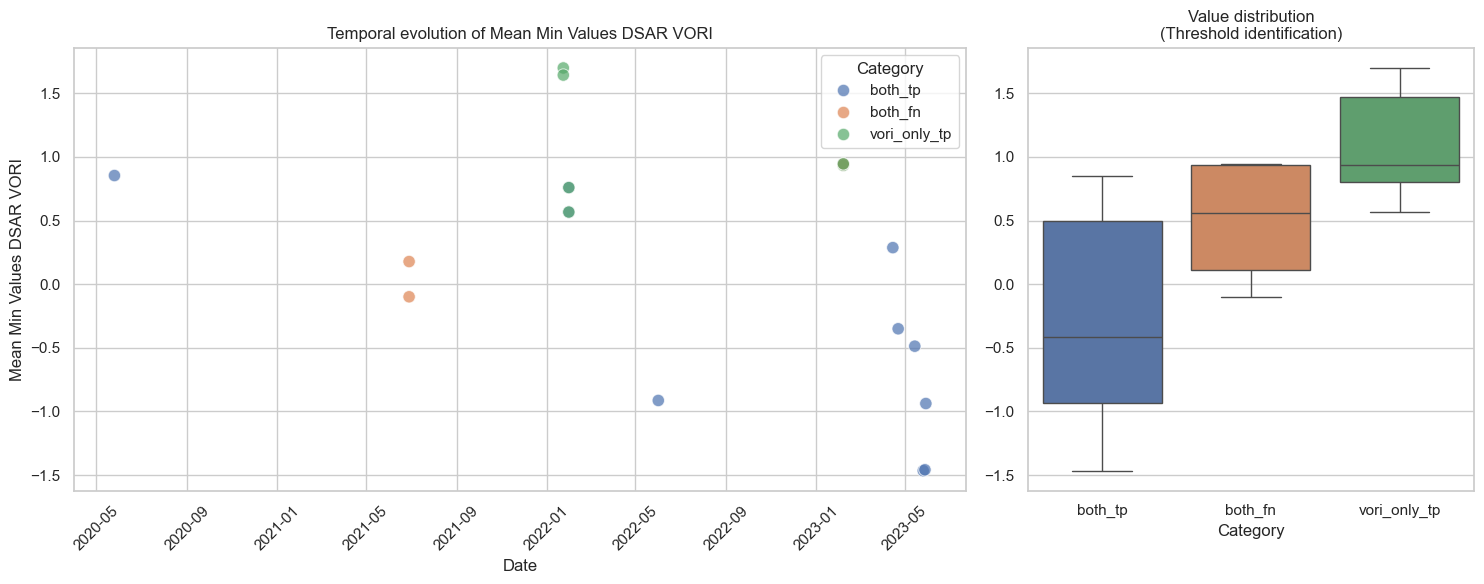

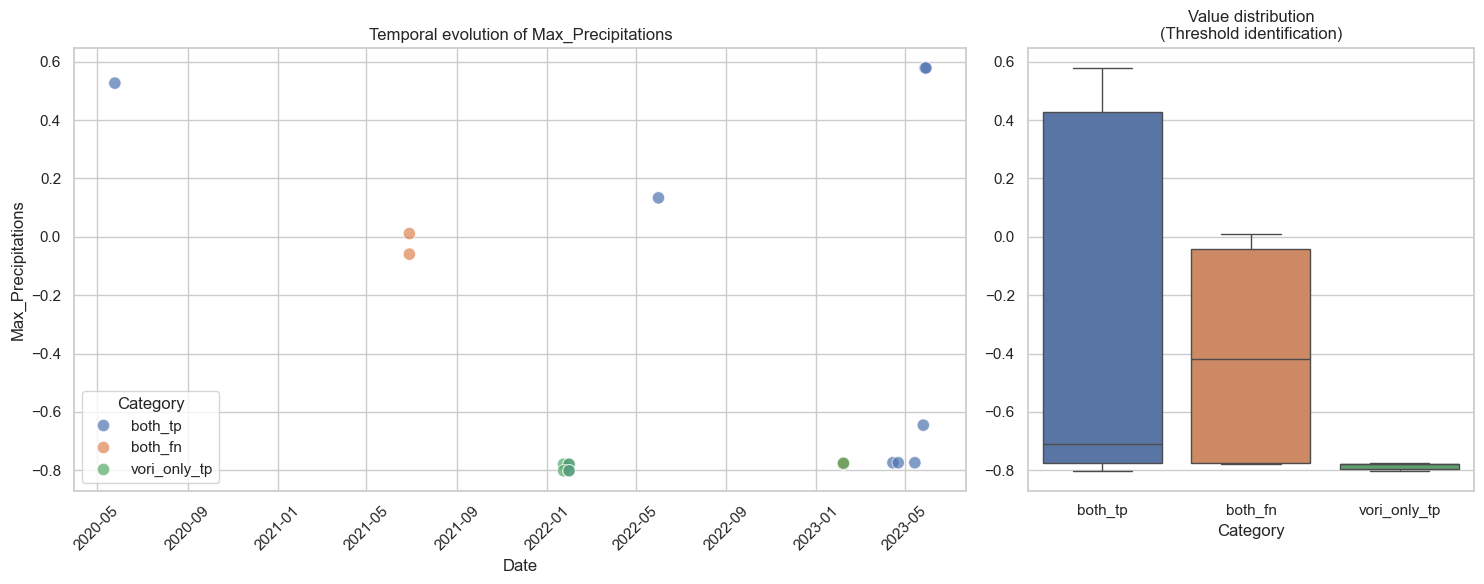

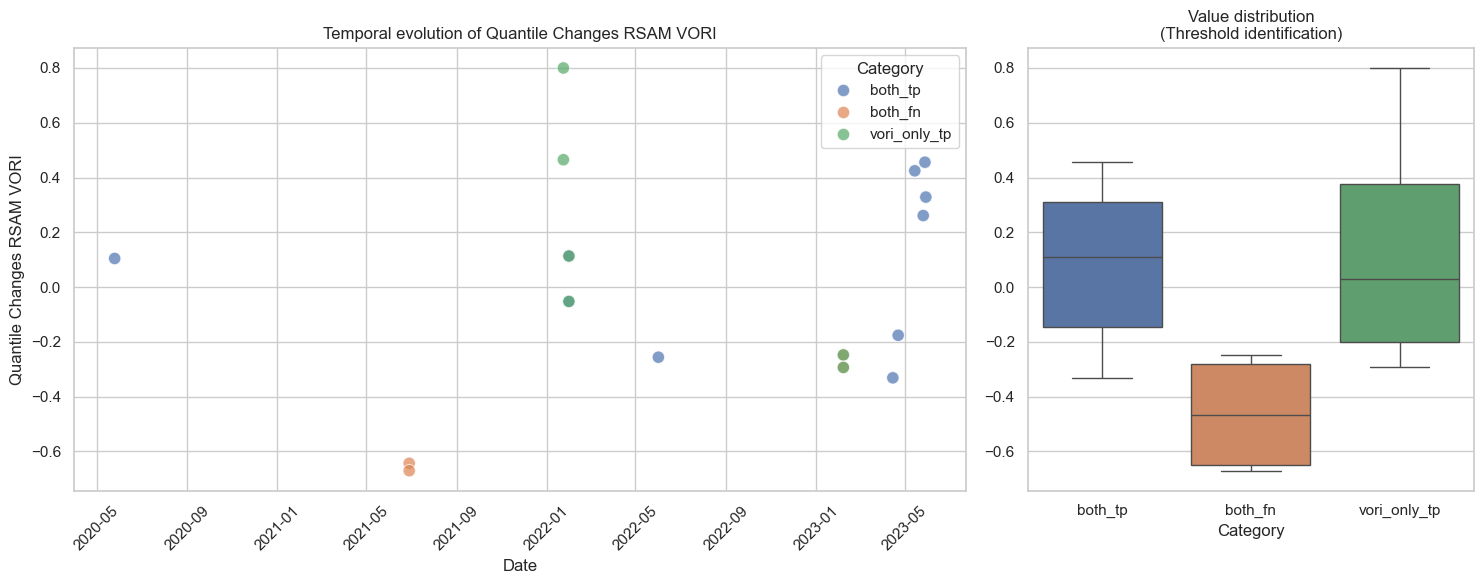

['Mean Min Values DSAR VORI', 'Avg Value DSAR VRBA', 'Quantile Changes RSAM VRBA', 'Std Value DSAR VORI', 'Max_Precipitations', 'Max peak DSAR VRBA', 'Max_tornillo', 'Quantile Changes DSAR VRBA', 'Delta_Max_Min_LP', 'Avg peak DSAR VRBA', 'Quantile Changes RSAM VORI', 'Mean Min Values RSAM VRBA', 'Sum_LP', 'Max drop DSAR VORI', 'Max_LP', 'Avg drop DSAR VORI', 'Median Value DSAR VRBA']
['Mean Min Values DSAR VORI', 'Avg Value DSAR VRBA', 'Quantile Changes RSAM VRBA', 'Std Value DSAR VORI', 'Max_Precipitations', 'Max peak DSAR VRBA', 'Max_tornillo', 'Quantile Changes DSAR VRBA', 'Delta_Max_Min_LP', 'Avg peak DSAR VRBA', 'Quantile Changes RSAM VORI', 'Mean Min Values RSAM VRBA', 'Sum_LP', 'Max drop DSAR VORI', 'Max_LP', 'Avg drop DSAR VORI', 'Median Value DSAR VRBA']


In [370]:
def plot_top_lahares_features_per_cases(summary_df, rf_features_importance, target_classes, x_val_VORI, x_val_VRBA, time_val, top_n=3):

    history = []
    # Set visual style for the thesis plots
    sns.set_theme(style="whitegrid")
    
    for target in target_classes:
        # target est maintenant ta catégorie unique (ex: 'both_tp')
        relevant_features_VORI = ["Sum_LP", "Max_LP", "Delta_Max_Min_LP", "Quantile Changes RSAM VRBA", "Quantile Changes DSAR VRBA", "Mean Min Values RSAM VRBA", "Max_tornillo", "Median Value DSAR VRBA", "Avg peak DSAR VRBA", "Max peak DSAR VRBA", "Avg Value DSAR VRBA"]#list(rf_features_importance[target]['VORI'].keys())[:top_n]+ ['Max_Precipitations']
        relevant_features_VRBA = ["Sum_LP", "Max_LP", "Delta_Max_Min_LP", "Max drop DSAR VORI", "Max_tornillo", "Max drop DSAR VORI", "Avg drop DSAR VORI", "Max drop DSAR VORI", "Std Value DSAR VORI", "Mean Min Values DSAR VORI", "Max_Precipitations", "Quantile Changes RSAM VORI"]#list(rf_features_importance[target]['VRBA'].keys())[:top_n]
        
        relevant_features = relevant_features_VORI + relevant_features_VRBA
        relevant_features = list(set(relevant_features))  # Remove duplicates if any
        print(relevant_features)
        # Consolidate all validation data into a single DataFrame to facilitate plotting
        all_data = []
        for validation_set in x_val_VORI.keys():
            
            # Extract dates for the current validation set
            dates = time_val[validation_set]

            # Combine VRBA and VORI to have all available columns in one place
            df_combined = pd.concat([x_val_VORI[validation_set], x_val_VRBA[validation_set]], axis=1)

            df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

            df_combined['Date'] = dates
            
            # Keep only the date and the specific relevant features to save memory
            cols_to_keep = ['Date'] + [f for f in relevant_features if f in df_combined.columns]
            df_combined = df_combined[cols_to_keep]
            all_data.append(df_combined)
            
        # Create the global dataset by combining all validation sets
        full_val_df = pd.concat(all_data, ignore_index=True)

        # Ensure both 'Date' columns are proper datetime64[ns] objects before merging
        full_val_df['Date'] = pd.to_datetime(full_val_df['Date'])
        
        # Isolate the summary dates and safely convert them to avoid SettingWithCopyWarning
        summary_dates = summary_df[['Date', 'Category']].copy()
        summary_dates['Date'] = pd.to_datetime(summary_dates['Date'])
        
        # Merge both columns share the same datatype
        plot_df = pd.merge(full_val_df, summary_dates, on='Date', how='inner')

        # Generate plots for each relevant feature VORI
        for feature in relevant_features_VORI:
            if feature in history:
                #print(f"Feature {feature} already plotted, skipping to avoid duplication.")
                continue
            history.append(feature)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})
            
            # Time series scatter plot to visualize chronological distribution
            sns.scatterplot(
                data=plot_df, x='Date', y=feature, hue='Category', 
                s=80, alpha=0.7, ax=ax1
            )
            ax1.set_title(f"Temporal evolution of {feature}\n")
            ax1.tick_params(axis='x', rotation=45)
            
            # Boxplot to identify potential physical thresholds between classes
            sns.boxplot(
                data=plot_df, x='Category', y=feature, hue='Category',
                ax=ax2, legend=False
            )
            ax2.set_title(f"Value distribution\n(Threshold identification)")
            ax2.set_ylabel("") # Hide the Y-axis label for a cleaner look
            
            plt.tight_layout()
            plt.savefig(f"MSc_Bryan_Rincon/Lahares features/{feature}.png")
            plt.show()
            
        # Generate plots for each relevant feature VRBA
        for feature in relevant_features_VRBA:
            if feature in history:
                #print(f"Feature {feature} already plotted, skipping to avoid duplication.")
                continue
            history.append(feature)
                
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

            sns.scatterplot(
                data=plot_df, x='Date', y=feature, hue='Category', 
                s=80, alpha=0.7, ax=ax1
            )
            ax1.set_title(f"Temporal evolution of {feature}")
            ax1.tick_params(axis='x', rotation=45)
            
            # Boxplot to identify potential physical thresholds between classes
            sns.boxplot(
                data=plot_df, x='Category', y=feature, hue='Category',
                ax=ax2, legend=False
            )
            ax2.set_title(f"Value distribution\n(Threshold identification)")
            ax2.set_ylabel("") # Hide the Y-axis label for a cleaner look
            
            plt.tight_layout()
            plt.savefig(f"MSc_Bryan_Rincon/Lahares features/{feature}.png")
            plt.show()

plot_top_lahares_features_per_cases(df_lahares_final, lahares_features_scores, lahares_category_columns, x_val_5_VORI, x_val_5_VRBA, time_5days_val, top_n=5)

It is good to notice that the due to lack of sample of lahares in the all dataset thus the analysis on the data cannot be accurate at 100% and could easily change with an higher number of examples. 
First, we see that the majority of the lahars have been detected as eruptions by both stations (9/12) showing that they seems to follow the same pattern as the others eruptions and shows strong indicators at both stations for the rf model 2019, 2020,2021, 2024. However one of these lharars,the 30-01-2022 was also detected by the model_rf 2023 as a vori_only_tp. Showing that the feautres were not exaclty look the samewith model 2023 and model 2020 and the features were reliable enough to not change decisionbetween the two.

Secondly, here the lahars 23-01-2022 was detected twice and only as false negative. It could mean these lahars have some strong caracteristics different from the others lahars and eruption in general.

Thirdly, we have 4 lahars detected only by the vori station that could signify that vori is better suited to detect the lahars in general. In the 4 find the 30-01-2022 mentioned earlier. the 23-01-2022 seems more interessting as it was detetecd two times by different model as only detected by VORI.

Two explantations could stands for this errors lahars predictions. First we could think that the models 2020 - 2022 2023 being trained on all the data from the other years of their names lack crucial information in the year not present that could have helped model to sharpen its predictions and detect the lahars easely. Thus maybe 2020 - 2022 and 2023 are crucial year and effectively their are the years with the more eruptions of all the catalogue.
The seconde explanations is maybe that the year missing is not really the problem and the explanations can be found in the features of the wrongly predict. that could explain their clear differences with the others. Why was he only detected by vori and why were they not detect by the VRBA stations.



The first explanations is actually hard to verify now has the year missing is the test set and we want no data leakage. Following the second explanations, we're going to look the the features importance of the models and try to see if could find any clear differences between the lahars that were categorised diferently. To do that, we are going to compare the lahars event on the top 3 features of all the mode to see if important features the models differentiate the lahars.

First, with Quantile Changes RSAM VORI we can for the two lahares detected both_fn have a value between 0.6 and 0.8 thus below the mean value of the feature where all the others are above.

Secondly we see that the vori_only_tp seems to tends to be below th the mean of sum_lp. Maybe saying the lack of LP has wrongly influenced VRBA not trusting them to eruptions. We even wreguaring that that two events were still found both TP with other models even if their sum_lp is low.

Thirdly, looking at the mean of the lowest value of the VORI DSAR we that the vori_only_tp have the higher values than all the others lahars . The both_fn events on the other are realy close to mean the feature where both_tp tend to be below the average. The same applies for Max drop DSAR VORI

Fourthly, the Quantiles Changes RSAM VRBA show a clear difference between both_fn and the rest. Both_fn have a value lower than the mean and the lowest when compare to the others. Same for quantile changes DSAR VRBA 

Finally in the Max_precipitations the Both Tn are really close meaning thy were not highly different for the rest Where on the onter hand Vori_only tp has all its events below the mean with a tiny box range around -0.8 and both TP that a  bit spread around.



Lahars represent only a small proportion of the dataset , which limits the robustness of any statistical interpretation. Only twelve out of the fifteen have fallen in the different validation sets of the differents models. Consequently, the observations presented below should be considered exploratory, as their are few lahar events available.

First, the majority of the lahars (9 out of 12) were classified as eruptions by both stations by the different models. This suggests that, for most events, the lahars share characteristics that are sufficiently similar to those of eruptive events for Random Forest models to identify them as positive cases. These detections were obtained by the models trained without the year 2019, 2020, 2021, and 2024 (For simplicity, Lets call the model by their missing year test set). Interestingly, the lahar that occurred on 30-01-2022 was also classified by the 2023 model as a VORI-only true positive. Although the prediction differs from the previous models, the event was still identified as an eruption by one station. This observation suggests that the feature representation learned by the 2023 model differs slightly from that of the earlier models while still capturing information associated with this lahar.

A second interesting observation concerns the lahar of 23-01-2022, which appears twice in the dataset and is classified as a false negative in both cases. Compared with the other lahars, this event seems to exhibit characteristics that make it more difficult for the models to recognize. Whether these differences originate from the recorded signals themselves or from the model training cannot be determined from the present analysis.

Another notable result is that four lahars were detected only by the VORI station. This includes the 30-01-2022 event mentioned previously, as well as the repeated detections of 23-01-2022 by different models. Although the number of examples is limited, this recurring pattern suggests that some lahars may produce signal characteristics that are more readily captured by VORI than by VRBA. However, the current dataset is too small to conclude that VORI is generally better suited for lahar detection.

Several hypotheses may explain these differences in prediction. One possibility is related to the leave-one-year-out training strategy. Since each model is trained without data from its corresponding test year, important information specific to 2020, 2022, or 2023 may be absent during training. These years also correspond to periods with relatively high eruptive activity in the catalogue, which may contain signal patterns that would otherwise improve the models' ability to recognize lahars.

An alternative explanation is that the differences arise from the intrinsic characteristics of the lahars themselves rather than from the missing training year. In this case, some lahars may simply exhibit feature values that differ from those typically associated with eruptions, leading to different predictions between the two stations. This hypothesis could also explain why certain lahars are detected only by VORI while remaining undetected by VRBA.

The first hypothesis is difficult to verify within the current evaluation framework because the excluded year constitutes the test set, and including it during training would introduce data leakage. Consequently, the following analysis focuses on the second hypothesis by examining the feature values of the differently classified lahars. More specifically, the lahars will be compared using the three most important features identified for each model to determine whether consistent differences can explain why some lahars are detected by both stations, only by VORI, or missed entirely.

It reveals several noticeable differences between the four prediction categories. One of the clearest examples is the Quantile Changes RSAM VORI feature. The two lahar events that were completely missed (both_fn) consistently exhibit the lowest values, ranging approximately between -0.6 and -0.8, whereas the events that triggered at least one positive prediction generally remain above this range. This suggests that changes in the RSAM distribution at the VORI station differ between completely missed events and the other prediction categories.

Another interesting observation concerns the Sum_LP feature. The events detected only by VORI (vori_only_tp) generally present lower values than the rest of the dataset. This indicates that these lahars are associated with reduced accumulated low-frequency activity compared with the other events. Interestingly, two of these same lahars were classified as both_tp by other yearly models, showing that a relatively low Sum_LP value does not systematically prevent successful detection. This suggests that other features may compensate for this lower LP activity depending on the model and the training year.

The DSAR-related features at the VORI station also exhibit distinct patterns. Both the Mean Minimum Values DSAR VORI and the Maximum Drop DSAR VORI reach their highest values for the vori_only_tp events. In contrast, the two both_fn events remain close to the overall average, while the both_tp events generally display lower values. Although the limited number of lahars prevents drawing firm conclusions, these observations suggest that variations in the DSAR signal at VORI differ depending on the prediction category and may contribute to the distinction between isolated detections and completely missed events.

A similar pattern can be observed at the VRBA station. The Quantile Changes of both the RSAM and DSAR signals show that the both_fn events consistently occupy the lowest part of the feature distributions, separating them from the remaining lahars. This recurring behavior indicates that these two missed events share signal characteristics that differ from the other prediction categories for these particular features.

Finally, the Maximum Precipitations feature does not appear to define a clear separation between all categories. The both_fn events remain grouped within a relatively narrow range, while the vori_only_tp events are also concentrated around similar negative values. In contrast, the both_tp events are distributed over a much broader range of precipitation values. These observations suggest that precipitation alone is unlikely to explain the different prediction outcomes for the lahars and that its influence should be interpreted together with the seismic and acoustic features rather than as an isolated indicator.

An additional observation is that the two both_fn events remain remarkably close to each other across nearly all of the analyzed features. While the other lahar categories generally spread at minimum once in feature values, these two missed events consistently cluster together. This suggests that they share a similar feature profile, which may explain why they were classified identically by the models.

## Lahar Detection

In [ ]:



for key in train_test_years_splits.keys():
    train_years = set(train_test_years_splits.keys()) - {key}
    print(f" One Class SVM Training for Datasets {train_years} without Year: {key} ")
    # Select the target column for Lahars (Class 1) and the eruption type column (Class 0 = No eruption, Class 1 = Eruption)
    lahares_col = target_columns[2] 
    type_col = target_columns[0]

    no_lahares_VRBA_complete = y_train_5_VRBA[key][lahares_col] == 0
    no_lahares_VRBA = (y_train_5_VRBA[key][lahares_col] == 0) & (y_train_5_VRBA[key][type_col] == 1)

    X_train_normal_complete_VRBA = x_train_5_VRBA[key][no_lahares_VRBA_complete]
    X_train_normal_VRBA = x_train_5_VRBA[key][no_lahares_VRBA]

    no_lahares_VORI_complete = y_train_5_VORI[key][lahares_col] == 0
    no_lahares_VORI = (y_train_5_VORI[key][lahares_col] == 0) & (y_train_5_VORI[key][type_col] == 1)

    X_train_normal_complete_VORI = x_train_5_VORI[key][no_lahares_VORI_complete]
    X_train_normal_VORI = x_train_5_VORI[key][no_lahares_VORI]

    print(f"Training OCSVM on {len(X_train_normal_VORI)} Normal Eruptions and no Lahars only...")

    # Initialize the One-Class SVM
    # 'nu' is a crucial parameter: it is the upper bound on the fraction of training 
    # errors (how many normal eruptions we expect it to falsely flag as anomalies).
    # Since we pre-filtered our data to be "clean", we set this quite low (e.g., 5%).
    ocsvm_VRBA_full_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    ocsvm_VORI_full_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

    ocsvm_VRBA_eruption_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    ocsvm_VORI_eruption_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    
    # Fit the model with the normal windows data (no Lahars)
    ocsvm_VORI_full_training_set.fit(X_train_normal_complete_VORI)
    ocsvm_VRBA_full_training_set.fit(X_train_normal_complete_VRBA)

    ocsvm_VORI_eruption_training_set.fit(X_train_normal_VORI)
    ocsvm_VRBA_eruption_training_set.fit(X_train_normal_VRBA)

    # Predict on the Validation Set (which contains BOTH Normal and Lahars)
    y_pred_full_VORI = ocsvm_VORI_full_training_set.predict(x_val_5_VORI[key])
    y_pred_full_VRBA = ocsvm_VRBA_full_training_set.predict(x_val_5_VRBA[key])

    y_pred_val_eruption_VORI = ocsvm_VORI_eruption_training_set.predict(x_val_5_VORI[key])
    y_pred_val_eruption_VRBA = ocsvm_VRBA_eruption_training_set.predict(x_val_5_VRBA[key])
    
    
   

    print("-" * 60)

 One Class SVM Training for Datasets {2020, 2021, 2022, 2023, 2024} without Year: 2019 
Training OCSVM on 713 Normal Eruptions and no Lahars only...


ValueError: Input X contains NaN.
OneClassSVM does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
for key in train_test_years_splits.keys():     
    #  Output Remapping 
    # Scikit-learn's OCSVM outputs:
    #   1 for "Inliers" (Normal)
    #  -1 for "Outliers" (Anomalies / Lahars)
    # We must remap this to match your true labels (0 = Normal, 1 = Lahar)
    y_pred_val_mapped = np.where(y_pred_full_VORI == -1, 1, 0)
    y_pred_val_mapped_VRBA = np.where(y_pred_full_VRBA == -1, 1, 0)
    
    # Extract the true validation labels
    y_true_val_VORI = y_val_5_VORI[key][lahares_col]
    y_true_val_VRBA = y_val_5_VRBA[key][lahares_col]

    # Evaluate the Novelty Detector
    print(f"\n--- OCSVM Results for VORI (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VORI, y_pred_val_mapped))
    
    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VORI, y_pred_val_mapped, zero_division=0))

    print(f"\n--- OCSVM Results for VRBA (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VRBA, y_pred_val_mapped_VRBA))

    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VRBA, y_pred_val_mapped_VRBA, zero_division=0))


--- OCSVM Results for VORI (Training Year {2019, 2020, 2021, 2022, 2023} without Year: 2019) ---
Confusion Matrix:


ValueError: Found input variables with inconsistent numbers of samples: [219, 189]

In [ ]:
for key in train_test_years_splits.keys():    
    #  Output Remapping 
    # Scikit-learn's OCSVM outputs:
    #   1 for "Inliers" (Normal)
    #  -1 for "Outliers" (Anomalies / Lahars)
    # We must remap this to match your true labels (0 = Normal, 1 = Lahar)
    y_pred_val_mapped = np.where(y_pred_val_eruption_VORI == -1, 1, 0)
    y_pred_val_mapped_VRBA = np.where(y_pred_val_eruption_VRBA == -1, 1, 0)
    
    # Extract the true validation labels
    y_true_val_VORI = y_val_5_VORI[key][lahares_col]
    y_true_val_VRBA = y_val_5_VRBA[key][lahares_col]

    # Evaluate the Novelty Detector
    print(f"\n--- OCSVM Results for VORI (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VORI, y_pred_val_mapped))
    
    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VORI, y_pred_val_mapped, zero_division=0))

    print(f"\n--- OCSVM Results for VRBA (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VRBA, y_pred_val_mapped_VRBA))

    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VRBA, y_pred_val_mapped_VRBA, zero_division=0))

    print("-" * 60)

In [ ]:
for key in train_test_years_splits.keys():
    train_years = set(train_test_years_splits.keys()) - {key}
    lahares_col = target_columns[2] 
    no_lahares_VRBA_complete = y_train_5_VRBA[key][lahares_col] == 1
    print(f"(Total Lahars) in VRBA training set {train_years}: {no_lahares_VRBA_complete.sum()}")




In [ ]:

def tune_and_evaluate_ocsvm(X_train, y_train, groups_train, X_val, y_val,
                            lahar_col, type_col, mode_name, station_name, train_mode):
    print(f"\n--- Tuning OCSVM | {station_name} | {mode_name} ---")

    nu_values = [0.01, 0.05, 0.10, 0.15, 0.20]
    gamma_values = ['scale', 'auto', 0.1, 0.01]

    sgkf_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    best_mean_f2 = -1
    best_params = {'nu': 0.05, 'gamma': 'scale'}

    # Print fold lahar distribution once (independent of hyperparams)
    print("  Fold lahar distribution:")
    for fold_idx, (_, val_idx) in enumerate(
        sgkf_inner.split(X_train, y_train[lahar_col], groups_train)
    ):
        n = y_train[lahar_col].iloc[val_idx].sum()
        status = "SKIPPED (no lahars)" if n == 0 else f"{n} lahar(s)"
        print(f"    Fold {fold_idx + 1} — {status}")

    for nu_val in nu_values:
        for gamma_val in gamma_values:
            fold_scores = []

            for train_idx, val_idx in sgkf_inner.split(X_train, y_train[lahar_col], groups_train):
                X_fold_train = X_train.iloc[train_idx]
                y_fold_train = y_train.iloc[train_idx]
                X_fold_val = X_train.iloc[val_idx]
                y_fold_val_lahar = y_train[lahar_col].iloc[val_idx]

                if y_fold_val_lahar.sum() == 0:
                    continue

                if train_mode == 'eruption':
                    mask = (y_fold_train[lahar_col] == 0) & (y_fold_train[type_col] == 1)
                else:
                    mask = (y_fold_train[lahar_col] == 0)

                ocsvm = OneClassSVM(kernel='rbf', gamma=gamma_val, nu=nu_val)
                ocsvm.fit(X_fold_train[mask])

                y_pred = ocsvm.predict(X_fold_val)
                y_pred_mapped = np.where(y_pred == -1, 1, 0)

                f2 = fbeta_score(y_fold_val_lahar, y_pred_mapped, beta=2, pos_label=1, zero_division=0)
                fold_scores.append(f2)

            if len(fold_scores) == 0:
                mean_f2 = 0.0
            else:
                mean_f2 = np.mean(fold_scores)

            if mean_f2 > best_mean_f2:
                best_mean_f2 = mean_f2
                best_params = {'nu': nu_val, 'gamma': gamma_val}

    print(f"Best params: nu={best_params['nu']}, gamma={best_params['gamma']} (CV F2={best_mean_f2:.4f})")

    if train_mode == 'eruption':
        final_mask = (y_train[lahar_col] == 0) & (y_train[type_col] == 1)
    else:
        final_mask = (y_train[lahar_col] == 0)

    best_ocsvm = OneClassSVM(kernel='rbf', gamma=best_params['gamma'], nu=best_params['nu'])
    best_ocsvm.fit(X_train[final_mask])

    y_pred_final = best_ocsvm.predict(X_val)
    y_pred_final_mapped = np.where(y_pred_final == -1, 1, 0)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val[lahar_col], y_pred_final_mapped))
    print("\nClassification Report:")
    print(classification_report(y_val[lahar_col], y_pred_final_mapped, zero_division=0))

    return best_ocsvm


for key in train_test_years_splits.keys():
    train_years = set(train_test_years_splits.keys()) - {key}
    print(f"\n{'='*80}")
    print(f" Training on {train_years} | Held-out year: {key}")
    print(f"{'='*80}")

    lahares_col = target_columns[2]
    type_col = target_columns[0]

    groups_train_VRBA = y_train_5_VRBA[key]['group_id']
    groups_train_VORI = y_train_5_VORI[key]['group_id']

    model_VORI_full = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VORI[key], y_train=y_train_5_VORI[key], groups_train=groups_train_VORI,
        X_val=x_val_5_VORI[key], y_val=y_val_5_VORI[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Full Set", station_name="VORI", train_mode='complete'
    )

    model_VRBA_full = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VRBA[key], y_train=y_train_5_VRBA[key], groups_train=groups_train_VRBA,
        X_val=x_val_5_VRBA[key], y_val=y_val_5_VRBA[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Full Set", station_name="VRBA", train_mode='complete'
    )

    model_VORI_eruption = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VORI[key], y_train=y_train_5_VORI[key], groups_train=groups_train_VORI,
        X_val=x_val_5_VORI[key], y_val=y_val_5_VORI[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Eruption Only", station_name="VORI", train_mode='eruption'
    )

    model_VRBA_eruption = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VRBA[key], y_train=y_train_5_VRBA[key], groups_train=groups_train_VRBA,
        X_val=x_val_5_VRBA[key], y_val=y_val_5_VRBA[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Eruption Only", station_name="VRBA", train_mode='eruption'
    )

    print("-" * 80)

In [ ]:
train_test_years_splits.keys()

dict_keys([2019, 2020, 2021, 2022, 2023, 2024])

### Correlation

In [389]:
from sklearn.model_selection import StratifiedGroupKFold

## Prepare training and validation datasets for each test year and feature set
x_train_corr_5_VORI = {}
x_train_corr_5_VRBA = {}

y_train_corr_5_VORI = {}
y_train_corr_5_VRBA = {}

x_val_corr_5_VORI = {}
x_val_corr_5_VRBA = {}

y_val_corr_5_VORI = {}
y_val_corr_5_VRBA = {}

    # coverage_train = {}
    # coverage_val = {}

# Stratified Group split: preserves both group integrity and eruption/non-eruption distribution
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for key in train_test_years_splits.keys():
    print(f"\nProcessing test year: {key} with Stratified Group K-Fold")
    Rincon_features_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_eruption_features_{key}.csv')
    
    # Use the first fold for train/val split (80/20 equivalent)
    X_full = Rincon_features_df
    y_strat = Rincon_features_df['Stratification']
    groups = Rincon_features_df['group_id']
    
    train_idx, val_idx = next(sgkf.split(X_full, y_strat, groups))

    train = Rincon_features_df.iloc[train_idx].copy()
    val = Rincon_features_df.iloc[val_idx].copy()

    train_corr_idx, val_corr_idx = next(sgkf.split(train, train['Stratification'], train['group_id']))

    train_corr = train.iloc[train_corr_idx].copy()
    val_corr = train.iloc[val_corr_idx].copy()

    print(f'training size: {len(train_corr)} | validation size: {len(val_corr)} ')
    
    # coverage_train[key] = train[coverage_features]
    # coverage_val[key] = val[coverage_features]

    # train = train.drop(columns=drop_columns)
    # val = val.drop(columns=drop_columns)
    train_corr = train_corr.drop(columns=drop_columns)
    val_corr = val_corr.drop(columns=drop_columns)

    # Identify binary columns to exclude from scaling
    binary_columns_train = get_binary_columns(train_corr)
    others_columns_train = list(set(train_corr.columns) - set(binary_columns_train))

    # Scale only the non-binary features
    scaler = StandardScaler()
    train_corr[others_columns_train] = scaler.fit_transform(train_corr[others_columns_train])
    val_corr[others_columns_train] = scaler.transform(val_corr[others_columns_train])
    
    # Prepare separate datasets for VORI and VRBA features
    x_train_corr_5_VORI[key] = train_corr[VORI_features + common_features + temporal_features]
    y_train_corr_5_VORI[key] = train_corr[target_columns]

    x_val_corr_5_VORI[key] = val_corr[VORI_features + common_features + temporal_features]
    y_val_corr_5_VORI[key] = val_corr[target_columns]

    x_train_corr_5_VRBA[key] = train_corr[VRBA_features + common_features + temporal_features]
    y_train_corr_5_VRBA[key] = train_corr[target_columns]

    x_val_corr_5_VRBA[key] = val_corr[VRBA_features + common_features + temporal_features]
    y_val_corr_5_VRBA[key] = val_corr[target_columns]
        


Processing test year: 2019 with Stratified Group K-Fold
training size: 1220 | validation size: 286 

Processing test year: 2020 with Stratified Group K-Fold
training size: 1289 | validation size: 110 

Processing test year: 2021 with Stratified Group K-Fold
training size: 1380 | validation size: 114 

Processing test year: 2022 with Stratified Group K-Fold
training size: 1090 | validation size: 137 

Processing test year: 2023 with Stratified Group K-Fold
training size: 887 | validation size: 131 

Processing test year: 2024 with Stratified Group K-Fold
training size: 1334 | validation size: 155 


#### Random Forest Classifier optimization

In [392]:
# The Recall is prioritize to detect the maximum number of eruptions
f2_scorer = make_scorer(fbeta_score, beta=2)

# Define the hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 500],             
    'max_depth': [3, 5, 7, 10],                       
    'min_samples_split': [2, 5, 10, 20],                  
    'min_samples_leaf': [1, 2, 4, 8],                    
    'max_features': ['sqrt', 'log2', 0.5, 0.8],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample'] 
}

sgkf_search = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

best_models_corr_VORI = {}
best_models_corr_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\nOptimizing Random Forest for test year: {key}")
    
    # # VORI model optimization
    # # 3 days observation window
    # rf_3_VORI = RandomForestClassifier(random_state=42)
    # random_search_VORI = RandomizedSearchCV(
    #     estimator=rf_3_VORI,
    #     param_distributions=param_grid,
    #     n_iter=200,  # Number of parameter settings that are sampled
    #     scoring=f2_scorer,
    #     cv=3,  # 3-fold cross-validation
    #     verbose=1,
    #     n_jobs=-1,  # Use all available cores
    #     random_state=42
    # )
    # # random_search_VORI.fit(x_train_VORI[key], y_train_VORI[key]['Type'])
    # # best_models_VORI[key] = random_search_VORI.best_estimator_
    # # print(f"Best parameters for VORI 3 days (test year {key}): {random_search_VORI.best_params_}")

    # 5 days observation window
    rf_5_VORI = RandomForestClassifier(random_state=42)
    random_search_VORI = RandomizedSearchCV(
        estimator=rf_5_VORI,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=sgkf_search,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    groups_train = y_train_corr_5_VORI[key]['group_id']

    random_search_VORI.fit(x_train_corr_5_VORI[key], y_train_corr_5_VORI[key]['Type'], groups=groups_train)
    best_models_corr_VORI[key] = random_search_VORI.best_estimator_
    print(f"Best parameters for VORI 5 days (test year {key}): {random_search_VORI.best_params_}")

    # # VRBA model optimization
    # rf_3_VRBA = RandomForestClassifier(random_state=42)
    # random_search_VRBA = RandomizedSearchCV(
    #     estimator=rf_3_VRBA,
    #     param_distributions=param_grid,
    #     n_iter=200,  # Number of parameter settings that are sampled
    #     scoring=f2_scorer,
    #     cv=3,  # 3-fold cross-validation
    #     verbose=1,
    #     n_jobs=-1,  # Use all available cores
    #     random_state=42
    # )
    # random_search_VRBA.fit(x_train_VRBA[key], y_train_VRBA[key]['Type'])
    # best_models_VRBA[key] = random_search_VRBA.best_estimator_
    # print(f"Best parameters for VRBA 3 days (test year {key}): {random_search_VRBA.best_params_}")

    rf_5_VRBA = RandomForestClassifier(random_state=42)
    random_search_VRBA = RandomizedSearchCV(
        estimator=rf_5_VRBA,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=sgkf_search,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    groups_train = y_train_corr_5_VRBA[key]['group_id']
    random_search_VRBA.fit(x_train_corr_5_VRBA[key], y_train_corr_5_VRBA[key]['Type'], groups=groups_train)
    best_models_corr_VRBA[key] = random_search_VRBA.best_estimator_
    print(f"Best parameters for VRBA 5 days (test year {key}): {random_search_VRBA.best_params_}")

    


Optimizing Random Forest for test year: 2019
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2019): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': False}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 5 days (test year 2019): {'n_estimators': 10, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': False}

Optimizing Random Forest for test year: 2020
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2020): {'n_estimators': 10, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 

In [396]:
best_features_corr_5days_VORI, best_features_corr_5days_VRBA = select_important_features({}, {}, best_models_corr_VORI, best_models_corr_VRBA, x_train_corr_5_VORI, x_train_corr_5_VRBA)

all_summaries = []

# Random Forest + No Feature Selection
summary_rf = get_crossval_summary_normalized(best_models_corr_VORI, None, x_train_corr_5_VORI, x_val_corr_5_VORI, y_train_corr_5_VORI, y_val_corr_5_VORI,
    best_models_corr_VRBA, None, x_train_corr_5_VRBA, x_val_corr_5_VRBA, y_train_corr_5_VRBA, y_val_corr_5_VRBA,
    train_test_years_splits,
    best_features=None , model_name="RF_NO_FS")
all_summaries.append(summary_rf)

# Random Forest + SelectFromModel
summary_rf_sfm = get_crossval_summary_normalized(best_models_corr_VORI, best_features_corr_5days_VORI, x_train_corr_5_VORI, x_val_corr_5_VORI, y_train_corr_5_VORI, y_val_corr_5_VORI,
    best_models_corr_VRBA, best_features_corr_5days_VRBA, x_train_corr_5_VRBA, x_val_corr_5_VRBA, y_train_corr_5_VRBA, y_val_corr_5_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_SFM")
all_summaries.append(summary_rf_sfm)


leaderboard = pd.concat(all_summaries, ignore_index=True)
# leaderboard = pd.read_csv("leaderboard_summary.csv")

leaderboard


# # Trier par Recall pour voir le modèle qui rate le moins d'événements
# leaderboard_sorted = leaderboard.sort_values(by=['Recall VRBA'], ascending=[True, False])
# print(leaderboard_sorted)


FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2019

[ STATION VORI ]
Features kept: 29 out of 86
Top 20 selected features:
Sum_LP                          0.116074
Max_LP                          0.069771
Delta_Max_Min_LP                0.055040
Max_Precipitations              0.033097
Sum_Precipitations              0.032807
Last_LP                         0.032741
Mean Min Values RSAM VORI       0.030244
Delta_Max_Min_Precipitations    0.026604
Max drop DSAR VORI              0.024089
Median Value RSAM VORI          0.023655
Std drop RSAM VORI              0.023262
Max peak RSAM VORI              0.021367
Avg Value RSAM VORI             0.021237
Avg drop DSAR VORI              0.021074
season                          0.019702
Median Value DSAR VORI          0.019278
Avg drop RSAM VORI              0.019032
Max_tornillo                    0.018072
Avg peak DSAR VORI              0.017886
Avg peak RSAM VORI              0.017842
dtype: float64

[ STATION VRBA ]
Features kept: 21 out of 

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
0,RF_NO_FS,0.620667,0.574139,0.616460,0.557860,35.666667,59.333333,38.666667,21.833333,61.646013,38.353987,65.603489,34.396511,0.612904,0.511276,0.69382,0.573772,41.000000,49.666667,48.333333,16.500000,69.381964,30.618036,57.365311,42.634689,47.091568,16.063591,14.554445,22.290396,43.414927,20.446128,22.188562,13.950384
1,RF_SFM,0.621354,0.547259,0.654252,0.566012,37.500000,57.333333,40.666667,20.000000,65.425163,34.574837,63.616876,36.383124,0.649513,0.562125,0.72108,0.611926,42.333333,53.333333,44.666667,15.166667,72.107985,27.892015,61.000531,38.999469,53.420012,15.886864,12.005150,18.687973,43.439661,18.822254,20.177215,17.560870


In [ ]:
def remove_correlated_features(df_train, feature_importances, threshold=0.85):
    """
    Supprime les features redondantes en gardant celle avec la plus haute importance.
    
    df_train: DataFrame d'entraînement.
    feature_importances: Dictionnaire avec les scores d'importance {nom_feature: score}.
    threshold: Seuil de corrélation (ex: 0.85).
    """
    # Matrice de corrélation absolue
    corr_matrix = df_train.corr().abs()
    
    # Isoler le triangle supérieur pour ne pas traiter les paires en double
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    features_to_drop = set()
    
    # Parcourir chaque colonne
    for col in upper.columns:
        # Trouver les variables qui lui sont fortement corrélées
        highly_correlated = upper.index[upper[col] > threshold].tolist()
        
        for row in highly_correlated:
            # Si l'une des deux est déjà marquée pour suppression, on l'ignore
            if col in features_to_drop or row in features_to_drop:
                continue
            
            # Récupérer les scores d'importance (0 par défaut si non trouvé)
            score_col = feature_importances.get(col, 0)
            score_row = feature_importances.get(row, 0)
            
            # Ajouter la moins importante à la liste de suppression
            if score_col > score_row:
                features_to_drop.add(row)
            else:
                features_to_drop.add(col)
                
    print(f"Nombre de features supprimées : {len(features_to_drop)}")
    print(f"Features supprimées : {list(features_to_drop)}")
    
    # Retourner le DataFrame nettoyé
    df_clean = df_train.drop(columns=list(features_to_drop))
    
    return df_clean, list(features_to_drop)

# --- EXEMPLE D'UTILISATION ---
x_train_5_VORI_cleaned = {}
x_train_5_VRBA_cleaned = {}

for key in train_test_years_splits.keys():
    print(f"\nTraitement de l'année de test : {key}")
    
    # Récupérer les importances des features pour cette année
    rf_importances_dict = {}
    for i, feature in enumerate(best_features_corr_5days_VORI[key]):
        rf_importances_dict[feature] = best_models_corr_VORI[key].feature_importances_[i]

    best_features_corr_5days_VORI[key]
    
    # Nettoyer les features corrélées pour VORI
    x_train_5_VORI_cleaned[key], dropped_cols_VORI = remove_correlated_features(x_train_corr_5_VORI[key], rf_importances_dict, threshold=0.85)
    
    # Nettoyer les features corrélées pour VRBA
    rf_importances_dict_vrba = {}
    for i, feature in enumerate(best_features_corr_5days_VRBA[key]):
        rf_importances_dict_vrba[feature] = best_models_corr_VRBA[key].feature_importances_[i]
    x_train_5_VRBA_cleaned[key], dropped_cols_VRBA = remove_correlated_features(x_train_corr_5_VRBA[key], rf_importances_dict_vrba, threshold=0.85)



Traitement de l'année de test : 2019


AttributeError: 'list' object has no attribute 'get'

Now that we have the bests models for each station, we are going to do feature selection to see if it is possible to get a better performance with less features. 

In [ ]:
len(best_features_corr_5days_VORI[key]) == len(best_models_corr_VORI[key].feature_importances_)

False

In [403]:
len(best_models_corr_VORI[key].feature_importances_)

86

In [398]:
type(best_models_corr_VORI[2019].feature_importances_)

numpy.ndarray

[5.38572801e-04 9.55086022e-03 1.32997477e-02 9.79732524e-03
 2.98134655e-03 4.19657302e-03 3.79444824e-03 1.78422602e-02
 2.13671907e-02 5.35260949e-03 9.52071983e-04 5.17729834e-03
 6.67444236e-03 6.50533434e-03 3.03725864e-03 3.11602470e-03
 3.35003775e-03 1.90324108e-02 1.78323580e-02 2.32621353e-02
 1.75555810e-02 2.12373459e-02 1.31597320e-02 2.36554359e-02
 1.31856556e-02 3.02435814e-02 9.55314272e-04 3.85550502e-03
 4.41186578e-03 5.36024688e-03 3.11884663e-03 4.57060627e-03
 4.36222058e-03 1.78863124e-02 1.46177461e-02 5.04867364e-03
 6.45073961e-04 6.17376558e-03 7.58709621e-03 8.08681578e-03
 5.26664021e-03 6.26562078e-03 6.20600764e-03 2.10739001e-02
 2.40887439e-02 7.50892893e-03 1.06588308e-02 1.17872773e-02
 8.70899327e-03 1.92782056e-02 9.00056982e-03 1.72936905e-02
 1.38795073e-04 2.85886098e-04 0.00000000e+00 6.21935772e-05
 1.74453469e-03 1.86396230e-03 3.77080130e-03 3.56837807e-04
 1.41730421e-03 1.29926494e-03 1.40219168e-03 1.33243734e-03
 7.09384293e-04 1.344651